# Sensitivity charts

## Mappings from dashboard json exports to chart labels and number formatting

In [1]:
import json
from pathlib import Path

# Per-metric display format (string templates)
format_val = {
  # Envelope (spread)
  "median_W":           "{:.1f}",     # absolute width (units of variable)
  "mean_W":             "{:.1f}",     # mean daily width — consistent with CI95 whiskers
  "p90_W":              "{:.1f}",
  "RW_med":             "{:.0%}",     # relative width (median)
  "RW_high":            "{:.0%}",     # on event days
  "RW_low":             "{:.0%}",
  "Peak_ratio":         "{:.2f}",

  # Central shift (displacement)
  "CS_abs":             "{:.1f}",     # absolute shift
  "CS_rel":             "{:.1%}",     # relative shift
  "Signed_C_shift":     "{:+.1%}",    # signed relative shift

  # Coverage
  "Coverage_frac":      "{:.0%}",
  "coverage100":        "{:.0%}",
  "Outside_upper":      "{:.0%}",
  "Outside_lower":      "{:.0%}",

  # Event contrast
  "Event_contrast":     "{:+.0%}",    # RW_high ˆ' RW_low (relative units)
  "Event_ratio":        "{:.2f}",

  # Duration-curve signature
  "RA_5":               "{:.0%}",
  "RA_50":              "{:.0%}",
  "RA_95":              "{:.0%}",

  # Optional shift detail (from your table)
  "delta_mean":         "{:+.0f}",
  "median_delta":       "{:+.0f}",
  "median_delta_pct":   "{:+.0%}",
  "delta_min":          "{:+.0f}",
  "delta_p50":          "{:+.0f}",
  "delta_p90":          "{:+.0f}",
  "delta_max":          "{:+.0f}",
  "delta_event_pairs_mean": "{:+.0f}",
  "delta_non_event_pairs_mean": "{:+.0f}",
  "normalized_mean_delta": "{:+.0%}",

  # Bias metrics
  "PBIAS%": "{:+.0f}%",
  "Bias(obs-pred)": "{:+.0f}",

  # Alias/legacy keys (if used)
  "relative_width":      "{:.0%}",
  "relative_width_high": "{:.0%}",
  "relative_width_low":  "{:.0%}",
  "relative_width_event": "{:.0%}",
  "relative_width_nonevent": "{:.0%}",
  "relative_width_event_contrast": "{:+.0%}",
  "event_ratio": "{:.2f}Ã--",

  # __baseline__ event/nonevent ensemble spread
  "bl_event_ratio":          "{:.2f}Ã--",
  "bl_RW_event":             "{:.0%}",
  "bl_RW_nonevent":          "{:.0%}",
  "bl_median_W_event":       "{:.1f}",
  "bl_median_W_nonevent":    "{:.1f}",
  "bl_mean_W_event":         "{:.1f}",
  "bl_mean_W_nonevent":      "{:.1f}",
  "bl_p90_W_event":          "{:.1f}",
  "bl_p90_W_nonevent":       "{:.1f}",

  # Full-range (max−min) width
  "bl_median_W_full":          "{:.1f}",
  "bl_median_W_full_event":    "{:.1f}",
  "bl_median_W_full_nonevent": "{:.1f}",

  # Absolute width event ratio
  "bl_abs_W_event_ratio":    "{:.1f}Ã--",

  # Mean-based relative width (all / event / non-event)
  "bl_RW_mean_all":          "{:.0%}",
  "bl_RW_mean_event":        "{:.0%}",
  "bl_RW_mean_nonevent":     "{:.0%}",

  # (max-min)/median metrics
  "bl_median_maxmin_over_median":          "{:.0%}",
  "bl_mean_maxmin_over_median":            "{:.0%}",
  "bl_median_maxmin_over_median_event":    "{:.0%}",
  "bl_median_maxmin_over_median_nonevent": "{:.0%}",
  "bl_mean_maxmin_over_median_event":      "{:.0%}",
  "bl_mean_maxmin_over_median_nonevent":   "{:.0%}",
}

# Single source of truth for label selection.
#
# Each key is the technical metric name expected in the exported stats JSON.
# `label` is what you pass in semantic_labels.
# Add `path` only when that metric name appears in multiple places in the export JSON.
# Example: "path": ("overlay_comparison", "__baseline__", "relative_width")
semantic_label_map = {
  # Width & spread
  "median_W": {"path": ("overlay_comparison", "__baseline__", "median_W"), "label": "Model raw width median (W)"},
  # mean_W: all-days mean of daily (max-min) width — consistent with CI95(Δ) mean-based tests
  # To revert bars to median: set CH1_USE_MEAN = False in the Chart 1 config cell.
  "mean_W": {"path": ("overlay_comparison", "__baseline__", "mean_W"), "label": "Model raw width mean (W)"},
  "p90_W": {"path": ("overlay_comparison", "__baseline__", "p90_W"), "label": "Model raw width p90 (W)"},
  "RW_med": {"path": ("overlay_comparison", "__baseline__", "relative_width"), "label": "Model relative width median((p95-p05)/p50)"},
  "RW_high": {"path": ("overlay_comparison", "__baseline__", "relative_width_event"), "label": "Relative width (high-flow days)"},
  "RW_low": {"path": ("overlay_comparison", "__baseline__", "relative_width_nonevent"), "label": "Relative width (baseflow days)"},

  # Shift & coverage
  "Coverage_frac": {"label": "Coverage fraction (overlay inside envelope)"},
  "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (vs. BASE)"},
  "mean_delta_pct": {"path": ("overlay_comparison", "BASE", "delta_mean_pct"), "label": "Percent of mean shift (vs. BASE)"},
  "median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Median shift (vs. BASE)"},
  "median_delta_pct": {"path": ("overlay_comparison", "BASE", "median_delta_pct"), "label": "Median percent shift (vs. BASE)"},
  "delta_max": {"label": "Shift in max (baseline - overlay)"},
  "delta_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_event_pairs_mean"), "label": "Mean shift (high-flow days)"},
  "delta_non_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_non_event_pairs_mean"), "label": "Mean shift (baseflow days)"},
  "cliffs_delta": {"path": ("overlay_comparison", "BASE", "cliffs_delta"), "label": "Cliff's delta (distribution-free effect size)"},
  "delta_min": {"label": "Shift in min (baseline - overlay)"},
  "delta_p50": {"label": "Shift in p50 (baseline - overlay)"},
  "delta_p90": {"label": "Shift in p90 (baseline - overlay)"},
  "normalized_mean_delta": {"label": "Normalized mean shift (delta / baseline mean)"},
  "coverage100": {"path": ("same_day", "coverage100"), "label": "Min/Max Coverage (observations inside envelope)"}, 


  # BIAS
  "PBIAS%": {"path": ("same_day", "PBIAS%"), "label": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)"},
  "Bias(obs-pred)": {"path": ("same_day", "Bias(obs-pred)"), "label": "Mean bias (observed - simulated)"},


  # Event contrast (if used)
  "relative_width_event_contrast": {"label": "Flow contrast (high / low)"},
  "event_ratio": {"label": "Flow ratio (high-flow / baseflow)"},
  "relative_width_high": {"label": "Relative width high decile"},
  "relative_width_low": {"label": "Relative width low decile"},

  # __baseline__ ensemble event/nonevent spread
  "bl_event_ratio": {"path": ("overlay_comparison", "__baseline__", "event_ratio"), "label": "high-flow ratio (ensemble spread)"},
  "bl_RW_event": {"path": ("overlay_comparison", "__baseline__", "relative_width_event"), "label": "Ensemble RW (high-flow days)"},
  "bl_RW_nonevent": {"path": ("overlay_comparison", "__baseline__", "relative_width_nonevent"), "label": "Ensemble RW (baseflow days)"},
  "bl_median_W_event": {"path": ("overlay_comparison", "__baseline__", "median_W_event"), "label": "Ensemble median W (high-flow days)"},
  "bl_median_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "median_W_nonevent"), "label": "Ensemble median W (baseflow days)"},
  "bl_mean_W_event": {"path": ("overlay_comparison", "__baseline__", "mean_W_event"), "label": "Ensemble mean W (high-flow days)"},
  "bl_mean_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "mean_W_nonevent"), "label": "Ensemble mean W (baseflow days)"},
  "bl_p90_W_event": {"path": ("overlay_comparison", "__baseline__", "p90_W_event"), "label": "Ensemble p90 W (high-flow days)"},
  "bl_p90_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "p90_W_nonevent"), "label": "Ensemble p90 W (baseflow days)"},

  # Absolute width event ratio
  "bl_abs_W_event_ratio": {"path": ("overlay_comparison", "__baseline__", "abs_width_event_ratio"), "label": "Absolute width flow ratio (ensemble)"},

  # Full-range (max−min) absolute width
  "bl_median_W_full": {"path": ("overlay_comparison", "__baseline__", "median_W_full"), "label": "Full-range width median (max−min)"},
  "bl_median_W_full_event": {"path": ("overlay_comparison", "__baseline__", "median_W_full_event"), "label": "Full-range width (high-flow days)"},
  "bl_median_W_full_nonevent": {"path": ("overlay_comparison", "__baseline__", "median_W_full_nonevent"), "label": "Full-range width (baseflow days)"},

  # Mean-based relative width
  "bl_RW_mean_all": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean"), "label": "Mean relative width (all days)"},
  "bl_RW_mean_event": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean_event"), "label": "Mean relative width (high-flow days)"},
  "bl_RW_mean_nonevent": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean_nonevent"), "label": "Mean relative width (baseflow days)"},

  # (max-min)/median metrics
  "bl_median_maxmin_over_median": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median"), "label": "Median (max-min/median) (all days)"},
  "bl_mean_maxmin_over_median": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median"), "label": "Mean (max-min/median) (all days)"},
  "bl_median_maxmin_over_median_event": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median_event"), "label": "Median (max-min/median) (high-flow days)"},
  "bl_median_maxmin_over_median_nonevent": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median_nonevent"), "label": "Median (max-min/median) (baseflow days)"},
  "bl_mean_maxmin_over_median_event": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_event"), "label": "Mean (max-min/median) (high-flow days)"},
  "bl_mean_maxmin_over_median_nonevent": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_nonevent"), "label": "Mean (max-min/median) (baseflow days)"},

}


### helper functions to convert data according to mappings

In [2]:
# Backwards-compatible flat view if you still want a technical-name -> label lookup elsewhere.
semantic_label = {
    technical_name: spec["label"]
    for technical_name, spec in semantic_label_map.items()
}

def _is_scalar_metric_value(value):
    """Return True for JSON scalar metric values that can be stored in the example dict."""
    return isinstance(value, (int, float)) and not isinstance(value, bool)


def _normalise_export_spec(export_spec):
    """
    Accept one export item in one of two forms:
      - {"path": ..., "scenario": ..., "variable": ...}
      - (path, scenario, variable)
    
    Variable can be omitted from the dict if the JSON file contains
    dashboard_state.variable, but scenario must always be supplied because it is
    not part of the current export payload.
    """
    if isinstance(export_spec, dict):
        path = export_spec.get("path")
        scenario = export_spec.get("scenario")
        variable = export_spec.get("variable")
    elif isinstance(export_spec, (tuple, list)) and len(export_spec) == 3:
        path, scenario, variable = export_spec
    else:
        raise TypeError(
            "Each export spec must be either a dict with keys 'path', 'scenario', 'variable' "
            "or a 3-item tuple/list of (path, scenario, variable)."
        )

    if not path:
        raise ValueError(f"Invalid export spec {export_spec!r}: missing file path.")
    if not scenario:
        raise ValueError(
            f"Invalid export spec {export_spec!r}: missing scenario. "
            "Scenario is not stored in the current JSON export, so it must be provided explicitly."
        )

    return Path(path), str(scenario), variable


def _load_stat_export(export_spec, *, verbose=True):
    """Load one JSON export file and return its payload plus resolved identifiers."""
    path, scenario, variable = _normalise_export_spec(export_spec)
    if verbose:
        print(f"Loading stats export: {path}")

    if not path.exists():
        raise FileNotFoundError(f"Stats export file does not exist: {path}")

    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if not isinstance(payload, dict):
        raise ValueError(f"Stats export {path} does not contain a top-level JSON object.")

    dashboard_state = payload.get("metadata", {}).get("dashboard_state") or payload.get("dashboard_state") or {}
    if variable is None:
        variable = dashboard_state.get("variable")

    if not variable:
        raise ValueError(
            f"Could not determine variable for {path}. "
            "Provide it explicitly in the export spec or ensure the payload has dashboard_state.variable."
        )

    stats = payload.get("stats")
    if not isinstance(stats, dict):
        raise ValueError(f"Stats export {path} is missing a 'stats' dictionary.")

    if verbose:
        print(f"  scenario={scenario}, variable={variable}")
    return {
        "path": path,
        "scenario": str(scenario),
        "variable": str(variable),
        "payload": payload,
        "stats": stats,
    }


def _normalise_semantic_entry(technical_name, entry):
    """Normalise one semantic_label_map entry to {'label': ..., 'path': ...}."""
    if isinstance(entry, str):
        spec = {"label": entry, "path": None}
    elif isinstance(entry, dict):
        label = entry.get("label")
        if not label or not isinstance(label, str):
            raise ValueError(
                f"semantic_label_map[{technical_name!r}] must define a string 'label'."
            )
        path = entry.get("path")
        if path is not None:
            if not isinstance(path, (tuple, list)) or not path or not all(isinstance(part, str) for part in path):
                raise ValueError(
                    f"semantic_label_map[{technical_name!r}]['path'] must be a non-empty tuple/list of strings."
                )
            path = tuple(path)
        spec = {"label": label, "path": path}
    else:
        raise TypeError(
            f"semantic_label_map[{technical_name!r}] must be either a label string or a dict with 'label' and optional 'path'."
        )

    return spec


def _normalise_semantic_label_map(semantic_label_map):
    """Return a validated semantic_label_map with uniform dict entries."""
    normalised = {}
    reverse_semantic_label = {}
    duplicate_labels = {}

    for technical_name, entry in semantic_label_map.items():
        spec = _normalise_semantic_entry(technical_name, entry)
        label = spec["label"]
        if label in reverse_semantic_label and reverse_semantic_label[label] != technical_name:
            duplicate_labels.setdefault(label, set()).update([reverse_semantic_label[label], technical_name])
        reverse_semantic_label[label] = technical_name
        normalised[technical_name] = spec

    if duplicate_labels:
        raise ValueError(
            "semantic_label_map contains duplicate labels mapped to different technical names: "
            f"{ {label: sorted(names) for label, names in duplicate_labels.items()} }"
        )

    return normalised


def _find_metric_matches(node, technical_name, path=()):
    """
    Recursively search the exported stats dictionary for a technical metric key.

    Returns a list of (path_tuple, value) matches so ambiguous metrics can be
    reported clearly instead of silently choosing the wrong number.
    """
    matches = []

    if isinstance(node, dict):
        for key, value in node.items():
            next_path = path + (str(key),)
            if key == technical_name and _is_scalar_metric_value(value):
                matches.append((next_path, value))
            matches.extend(_find_metric_matches(value, technical_name, next_path))

    elif isinstance(node, list):
        for index, value in enumerate(node):
            matches.extend(_find_metric_matches(value, technical_name, path + (str(index),)))

    return matches


_TECHNICAL_FALLBACK_PATHS = {
    # Chart 3 compatibility: some exports no longer populate same_day,
    # but still expose equivalent diagnostics under other sections.
    "coverage100": [
        ("measured_vs_series", "vs_mean_coverage100"),
        ("overlay_comparison", "BASE", "coverage_fraction"),
    ],
    "Bias(obs-pred)": [
        ("overlay_full_series", "BASE", "Bias(obs-pred)"),
    ],
}


def _try_extract_from_path(stats_dict, path):
    """Try to resolve one explicit path; return (found, value)."""
    current = stats_dict
    for part in tuple(path):
        if not isinstance(current, dict) or part not in current:
            return False, float('nan')
        current = current[part]
    if current is None:
        return True, 0
    if not _is_scalar_metric_value(current):
        return False, float('nan')
    return True, current


def _extract_metric_value(stats_dict, technical_name, explicit_path=None, *, verbose=True):
    """Extract one metric value from the exported stats dictionary."""
    if explicit_path is not None:
        explicit_path = tuple(explicit_path)
        found_explicit, explicit_value = _try_extract_from_path(stats_dict, explicit_path)
        if found_explicit:
            if verbose:
                print(f"    using semantic_label_map path {explicit_path} -> {explicit_value}")
            return explicit_value

        fallback_paths = _TECHNICAL_FALLBACK_PATHS.get(technical_name, [])
        for fallback_path in fallback_paths:
            found_fallback, fallback_value = _try_extract_from_path(stats_dict, fallback_path)
            if found_fallback:
                if verbose:
                    print(
                        f"    explicit path {explicit_path} missing for '{technical_name}'; "
                        f"using fallback path {tuple(fallback_path)} -> {fallback_value}"
                    )
                return fallback_value

        if verbose:
            print(f"    explicit path {explicit_path} for '{technical_name}' not found, returning NaN")
        return float('nan')

    matches = _find_metric_matches(stats_dict, technical_name)
    if not matches:
        if verbose:
            print(f"    metric '{technical_name}' not found anywhere in the stats export, returning NaN")
        return float('nan')
    if len(matches) > 1:
        pretty_paths = [" -> ".join(path) for path, _ in matches]
        raise ValueError(
            f"Metric '{technical_name}' matched more than one location in the stats export: {pretty_paths}. "
            "Add a 'path' entry to semantic_label_map for this metric."
        )

    metric_path, metric_value = matches[0]
    if verbose:
        print(f"    found {technical_name} at {' -> '.join(metric_path)} = {metric_value}")
    return metric_value


def _format_metric_value(value, fmt, technical_name):
    """Render one numeric value with the metric format string."""
    try:
        return fmt.format(value)
    except Exception as exc:
        raise ValueError(
            f"Could not format value {value!r} for metric '{technical_name}' with format {fmt!r}."
        ) from exc


def _build_requested_metric_specs(semantic_labels, semantic_label_map, format_map):
    """Resolve requested labels to technical names, formats, and optional paths."""
    reverse_semantic_label = {
        spec["label"]: technical_name
        for technical_name, spec in semantic_label_map.items()
    }

    requested_specs = []
    for requested_label in semantic_labels:
        if requested_label in reverse_semantic_label:
            technical_name = reverse_semantic_label[requested_label]
            output_label = requested_label
        elif requested_label in semantic_label_map:
            technical_name = requested_label
            output_label = semantic_label_map[requested_label]["label"]
        else:
            available = sorted(reverse_semantic_label.keys())
            raise KeyError(
                f"Unknown semantic label or technical name: {requested_label!r}. "
                f"Available semantic labels include: {available}"
            )

        if technical_name not in format_map:
            raise KeyError(
                f"No format string found in format_val for technical metric '{technical_name}'. "
                "Add it to format_val before building the metrics dictionary."
            )

        requested_specs.append(
            {
                "technical_name": technical_name,
                "output_label": output_label,
                "format": format_map[technical_name],
                "path": semantic_label_map[technical_name].get("path"),
            }
        )

    return requested_specs


def build_metrics_dict_from_stat_exports(
    export_specs,
    semantic_labels,
    *,
    semantic_label_map=None,
    format_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=True,
):
    """
    Build a dict with the same structure as the earlier manual 'metrics' blocks from a
    list of dashboard JSON exports.

    Parameters
    ----------
    export_specs : list
        One item per scenario-variable combination. Recommended form:
            {"path": <json_path>, "scenario": "WASTE", "variable": "TP"}
        A tuple/list of (path, scenario, variable) also works.

    semantic_labels : list[str]
        Labels you want in the output dictionary, using the labels defined in
        semantic_label_map, for example:
            ["Median width", "Coverage", "Mean Î""]
        Technical keys are also accepted directly.

    semantic_label_map : dict, optional
        Mapping of technical metric names to config dicts with:
            - 'label': display label used in semantic_labels
            - 'path' : optional explicit path inside the exported stats dict
        A plain string value is also accepted as shorthand for {'label': <string>}.

    format_map : dict, optional
        Mapping of technical metric names to format strings. If a technical name
        has no format entry, the function raises a helpful error.

    scenario_order / variable_order : list, optional
        If omitted, the function uses the order in which scenarios and variables
        appear in export_specs.

    include_technical_names : bool, default False
        If True, each output metric also gets a '__technical_name' field.

    format_mode : {'metadata', 'values'}, default 'metadata'
        'metadata' keeps numeric values and adds '__format'.
        'values' applies the format string to each extracted value and omits '__format'.

    verbose : bool, default True
        Print progress information while reading files and extracting metrics.

    Returns
    -------
    dict
        A dictionary shaped like:
            {
                "metrics": {
                    "Median width": {
                        "__format": "{:.1f}",
                        "WASTE": {"TP": 12.8, "TN": 17.6},
                        ...
                    },
                    ...
                }
            }
    """
    if semantic_label_map is None:
        semantic_label_map = globals()["semantic_label_map"]
    semantic_label_map = _normalise_semantic_label_map(semantic_label_map)

    if format_map is None:
        format_map = format_val

    valid_format_modes = {"metadata", "values"}
    if format_mode not in valid_format_modes:
        raise ValueError(
            f"format_mode must be one of {sorted(valid_format_modes)}, got {format_mode!r}."
        )

    if not export_specs:
        raise ValueError("export_specs is empty. Provide one export spec per scenario-variable combination.")
    if not semantic_labels:
        raise ValueError("semantic_labels is empty. Provide at least one label to extract.")

    loaded_exports = []
    seen_scenarios = []
    seen_variables = []

    if verbose:
        print(f"Preparing to read {len(export_specs)} stats export files...")

    for export_spec in export_specs:
        loaded = _load_stat_export(export_spec, verbose=verbose)
        loaded_exports.append(loaded)
        if loaded["scenario"] not in seen_scenarios:
            seen_scenarios.append(loaded["scenario"])
        if loaded["variable"] not in seen_variables:
            seen_variables.append(loaded["variable"])

    scenario_order = list(scenario_order) if scenario_order is not None else seen_scenarios
    variable_order = list(variable_order) if variable_order is not None else seen_variables

    if verbose:
        print(f"Scenarios discovered: {scenario_order}")
        print(f"Variables discovered: {variable_order}")

    requested_specs = _build_requested_metric_specs(
        semantic_labels,
        semantic_label_map,
        format_map,
    )

    result = {"metrics": {}}
    for spec in requested_specs:
        output_label = spec["output_label"]
        metric_block = {}
        if format_mode == "metadata":
            metric_block["__format"] = spec["format"]
        if include_technical_names:
            metric_block["__technical_name"] = spec["technical_name"]
        for scenario in scenario_order:
            metric_block[scenario] = {}
        result["metrics"][output_label] = metric_block

    for loaded in loaded_exports:
        scenario = loaded["scenario"]
        variable = loaded["variable"]
        stats_dict = loaded["stats"]

        if scenario not in scenario_order:
            raise ValueError(
                f"Scenario '{scenario}' from {loaded['path']} is not present in scenario_order {scenario_order}."
            )
        if variable not in variable_order:
            raise ValueError(
                f"Variable '{variable}' from {loaded['path']} is not present in variable_order {variable_order}."
            )

        if verbose:
            print(f"Reading metrics for scenario={scenario}, variable={variable}")

        for spec in requested_specs:
            raw_value = _extract_metric_value(
                stats_dict,
                spec["technical_name"],
                explicit_path=spec["path"],
                verbose=verbose,
            )
            if format_mode == "values":
                final_value = _format_metric_value(
                    raw_value,
                    spec["format"],
                    spec["technical_name"],
                )
            else:
                final_value = raw_value
            result["metrics"][spec["output_label"]][scenario][variable] = final_value

    missing_entries = []
    for output_label in result["metrics"]:
        for scenario in scenario_order:
            for variable in variable_order:
                if variable not in result["metrics"][output_label][scenario]:
                    missing_entries.append((output_label, scenario, variable))

    if missing_entries:
        preview = ", ".join([f"{label}/{scenario}/{variable}" for label, scenario, variable in missing_entries[:8]])
        suffix = " ..." if len(missing_entries) > 8 else ""
        raise ValueError(
            "The assembled metrics dictionary is incomplete. Missing entries: "
            f"{preview}{suffix}"
        )

    if verbose:
        print("Finished building metrics dictionary.")
        print(f"Built {len(result['metrics'])} metrics across {len(scenario_order)} scenarios and {len(variable_order)} variables.")

    return result

## Different CHART layouts

### Horizontal stacking of metrics

In [3]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

def plot_nested_sensitivity_bars(
    stats_data,
    stats_order=None,
    variables_order=None,       # list of variable names; None -> auto-discover from stats_data
    scenarios_order=None,       # list of scenario names; None -> auto-discover from stats_data
    title="Sensitivity metrics (nested bar chart)",
    y_label="Value",
    figsize=(14, 7),
    abbreviations=None,
    value_format=None,          # callable: (v) or (v, stat) -> str
    annotate_decimals=1,        # used only if neither per-metric nor format_map nor value_format is provided
    small_value_threshold=0.1,   # reformat labels below this magnitude
    small_value_decimals=2,      # decimals used when the threshold applies
    format_map=None,            # optional: dict {metric_key: format_string}
    bar_alpha=0.85,
    annotate_rotation=45,
    scenario_label_rotation=0,
    scenario_spacing=0.06,
    bar_width=0.12,
    metric_group_padding="auto",
    min_metric_group_padding=0.14,
    max_metric_group_padding=0.34,
    metric_padding_per_char=0.010,
    metric_padding_reference_chars=16,
    bottom_margin_for_labels=0.24,
    stat_label_map=None,        # optional: {metric_key: display_label}
    annot_fs=16,                # 2x  default (8)
    scenario_fs=16,             # 2x  default (8)
    tick_fs=20,                 # 2x  default (10)
    x_tick_fs=None,             # override tick_fs for x-axis labels; None = use tick_fs
    y_tick_fs=None,             # override tick_fs for y-axis labels; None = use tick_fs
    label_fs=22,                # 2x  default (11)
    title_fs=24,                # 2x  default (12)
    subtitle=None,
    subtitle_fs=None,
    subtitle_y=0.005,
    legend_fs=20,               # 2x  default (10)
    label_offset_scale=0.03,
    label_separation_scale=0.08,
    label_x_nudge_scale=0.22,
    top_margin_scale=0.22,
    inside_legend_top_margin_scale=0.72,
    scenario_label_y_scale=0.08,
    edge_bar_padding=0.75,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.98, 0.98),

    annotation_formatter=None,   # optional callable: (value, stat, scenario, variable, default_text) -> str | None

    info_box_lines=None,          # list of strings to display in an info box on the chart
    info_box_x=0.875,             # horizontal position in axes coords (0-1); 0.875 = centre of 4th quarter
    info_box_y=0.60,              # vertical position in axes coords (0-1); below the legend area
    info_box_fs=None,             # font size (defaults to legend_fs)
    info_box_title=None,          # optional title line rendered in bold above the values

    # split-panel parameters 
    split_variable_panels=False,         # when True, one subplot per variable rendered side by side
    split_panel_figsize=None,            # figsize for the combined figure; None ' auto-scale from figsize
    split_panel_wspace=0.3,              # horizontal whitespace between panels (passed to subplots_adjust)
    split_panel_suptitle_y=1.01,         # y position for the shared suptitle (>1 puts it above the axes)
    split_panel_suptitle_fs=None,        # font size for suptitle; None ' uses title_fs
    split_panel_variable_title=True,     # show variable name as each panel's title
    split_panel_variable_title_fs=None,  # font size for the panel variable title; None ' label_fs
    split_panel_variable_title_bg=False, # add a coloured background box (matching bar colour) behind the variable name
    split_panel_variable_title_pad=4.0,  # padding (points) for the background box
    split_panel_left_y_label_only=True,  # only the leftmost panel gets the y-axis label
    split_panel_per_panel_y_labels=None,  # dict {variable: y_label} for per-panel y-axis labels (split mode)
    split_panel_legend_panel=0,          # panel index that receives the legend; -1 ' figure-level, None ' no legend
    split_panel_legend_side="right",     # side for figure-level legend: "right" or "bottom"
    split_panel_legend_bbox=None,        # bbox_to_anchor override for figure-level legend
    split_panel_tight_rect=None,         # tight_layout rect for the split figure; None ' tight_layout_rect
    split_panel_stack_vertical=True,     # when True, stack panels top-to-bottom instead of side by side

    y_stretch=1.0,                        # vertical stretch factor: >1 makes chart taller, amplifying bar differences

    #   Error bar parameters  
    error_data=None,             # dict {metric_label: {scenario: {variable: error_value}}}
    error_bar_color="black",     # color for error bar whiskers and caps
    error_bar_capsize=3,         # cap width in points
    error_bar_linewidth=1.0,     # whisker line width
    error_bar_legend_label=None,  # str: label for whisker legend entry (e.g. "= 95% CI")
    error_bar_legend_fs=None,     # font size for the whisker legend in split-panel mode
    #   Post-layout pixel margins
    top_margin_px=20,             # px breathing room above highest annotation/whisker
    bottom_margin_px=20,          # px breathing room below lowest scenario label
    info_box_top_margin_px=0,     # extra px added to top margin when info_box is enabled
):
    """
    stats_data["metrics"][<STAT>][SCENARIO][VAR] -> float

    Scenarios and variables are auto-discovered from stats_data["metrics"] when
    scenarios_order / variables_order are not provided, so the function works for
    any variable set (TP/TN, TP/TKN, ...).

    Optional per-metric meta-keys inside each <STAT> block:
      - "__format": format string, e.g., "{:.0%}", "{:.1f}", "{:.2f}x"
      - "__label" : short display label for the x-axis; overrides stat_label_map for this stat

    Split-panel mode (split_variable_panels=True):
      Creates one subplot per variable side by side, each with its own independent y-axis
      scale. The main title is rendered as a shared suptitle. A single legend is placed
      either inside one of the panels (split_panel_legend_panel >= 0), as a figure-level
      legend (split_panel_legend_panel == -1), or suppressed entirely
      (split_panel_legend_panel is None). Panel titles are labelled "(A) - VAR",
      "(B) " VAR", etc. Set split_panel_variable_title_bg=True to render the
      variable name portion with a coloured background matching the bar colour.
      All other visual parameters are shared across panels; pass split_panel_*
      parameters to control layout.
    """
    metrics = stats_data.get("metrics", {})
    if not isinstance(metrics, dict) or not metrics:
        raise ValueError("stats_data must contain a non-empty dict at 'metrics'.")

    _first_block = next(
        (v for v in metrics.values() if isinstance(v, dict)),
        {}
    )
    if scenarios_order is not None:
        scenarios = list(scenarios_order)
    else:
        scenarios = [k for k in _first_block if not k.startswith("__")]

    if variables_order is not None:
        variables = list(variables_order)
    else:
        _first_scenario_data = _first_block.get(scenarios[0], {}) if scenarios else {}
        variables = [k for k in _first_scenario_data if not k.startswith("__")]

    if not scenarios:
        raise ValueError("No scenarios found in stats_data and none provided via scenarios_order.")
    if not variables:
        raise ValueError("No variables found in stats_data and none provided via variables_order.")

    if abbreviations is None:
        abbreviations = {sc: sc for sc in scenarios}

    if value_format is not None and not callable(value_format):
        raise TypeError("value_format must be a callable, e.g. lambda v: '...'. You passed a non-callable.")

    _eff_x_tick_fs = x_tick_fs if x_tick_fs is not None else tick_fs
    _eff_y_tick_fs = y_tick_fs if y_tick_fs is not None else tick_fs

    if value_format is None:
        fmt_str_default = "{:." + str(int(max(0, annotate_decimals))) + "f}"
        def _format_value(v, stat=None):
            return fmt_str_default.format(v)
    else:
        _orig_fmt = value_format
        def _format_value(v, stat=None):
            try:
                return _orig_fmt(v)
            except TypeError:
                return _orig_fmt(v, stat)

    def _format_small_value_text(raw_value, default_text):
        if (
            small_value_threshold is None
            or small_value_decimals is None
            or small_value_decimals < 0
            or not math.isfinite(raw_value)
            or abs(raw_value) >= small_value_threshold
        ):
            return default_text
        return f"{raw_value:.{int(small_value_decimals)}f}"

    def _validate_stat(stat_name, block):
        missing = []
        for sc in scenarios:
            if sc not in block:
                missing.append(f"scenario '{sc}'")
            else:
                for var in variables:
                    if var not in block[sc]:
                        missing.append(f"{sc}->{var!r}")
        if missing:
            raise ValueError(f"Metric '{stat_name}' is missing: {', '.join(missing)}")

    for s, block in metrics.items():
        if not isinstance(block, dict):
            raise ValueError(f"Metric '{s}' must map to a dict.")
        _validate_stat(s, block)

    if stats_order is None:
        stats = list(metrics.keys())
    else:
        if not isinstance(stats_order, (list, tuple)):
            raise TypeError("stats_order must be a list/tuple of metric keys.")
        extra = [s for s in stats_order if s not in metrics]
        if extra:
            raise ValueError(f"stats_order contains unknown metric keys: {extra}")
        stats = list(stats_order)

    stat_labels = []
    for s in stats:
        block = metrics[s]
        if isinstance(block, dict) and "__label" in block:
            stat_labels.append(block["__label"])
        elif isinstance(stat_label_map, dict) and s in stat_label_map:
            stat_labels.append(stat_label_map[s])
        else:
            stat_labels.append(s)

    n_stats = len(stats)
    bars_per_subgroup = len(variables)
    subgroup_width = bars_per_subgroup * bar_width
    group_inner = len(scenarios) * subgroup_width + (len(scenarios) - 1) * scenario_spacing

    if metric_group_padding in (None, "auto"):
        inter_group_padding = []
        for i in range(max(0, n_stats - 1)):
            left_len = len(str(stat_labels[i]))
            right_len = len(str(stat_labels[i + 1]))
            label_pressure = max(left_len, right_len) - metric_padding_reference_chars
            padding = min_metric_group_padding + max(0.0, label_pressure) * metric_padding_per_char * (_eff_x_tick_fs / 20.0)
            inter_group_padding.append(min(max_metric_group_padding, max(min_metric_group_padding, padding)))
    else:
        inter_group_padding = [float(metric_group_padding)] * max(0, n_stats - 1)

    group_left_positions = []
    cursor = 0.0
    for i in range(n_stats):
        group_left_positions.append(cursor)
        if i < n_stats - 1:
            cursor += group_inner + inter_group_padding[i]

    _known_colors = {
        "TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c",
        "TON": "#d62728", "PP": "#9467bd",
    }
    var_to_color = {
        v: _known_colors.get(v, plt.cm.tab10((i % 10) / 10))
        for i, v in enumerate(variables)
    }

    legend_kwargs = dict(
        title="Variables",
        frameon=True,
        handlelength=1.2,
        fontsize=legend_fs,
        title_fontsize=legend_fs,
    )


    # "- error bar helper 
    def _get_error(err_data, stat, scenario, var):
        if err_data is None:
            return None
        block = err_data.get(stat)
        if block is None:
            return None
        sc_block = block.get(scenario)
        if sc_block is None:
            return None
        val = sc_block.get(var)
        if val is None or (isinstance(val, float) and math.isnan(val)):
            return None
        return val

    # "-- Split-panel mode "------------------------------------------------------
    def _even_ticks(max_val, target_ticks=5):
        """Return (nice_top, tick_list) with evenly spaced ticks.

        Picks a step from {1, 2, 5} x 10^n that yields ~target_ticks
        intervals, then rounds max_val up to the next multiple of step.
        All ticks are exact multiples of step -> guaranteed equal spacing.
        """
        if max_val <= 0:
            return (1.0, [0.0, 1.0])
        raw_step = max_val / max(1, target_ticks)
        exp = math.floor(math.log10(raw_step)) if raw_step > 0 else 0
        base = 10 ** exp
        frac = raw_step / base
        if frac <= 1.0:
            step = base
        elif frac <= 2.0:
            step = 2 * base
        elif frac <= 5.0:
            step = 5 * base
        else:
            step = 10 * base
        nice_top = step * math.ceil(max_val / step)
        n = round(nice_top / step)
        ticks = [round(i * step, 10) for i in range(n + 1)]
        return (nice_top, ticks)

    class _BracketHandler:
        """Legend handler that draws a ] bracket matching the actual whisker style."""
        def __init__(self, color="black", lw=1.0):
            self._color = color
            self._lw = lw
        def legend_artist(self, legend, orig_handle, fontsize, handlebox):
            from matplotlib.lines import Line2D
            x0, y0 = handlebox.xdescent, handlebox.ydescent
            w, h = handlebox.width, handlebox.height
            # Vertical stem on right (full height)
            stem = Line2D([x0 + w, x0 + w], [y0, y0 + h],
                          color=self._color, lw=self._lw, solid_capstyle="butt")
            # Top cap (horizontal, half-length)
            cap_top = Line2D([x0 + w * 0.75, x0 + w], [y0 + h, y0 + h],
                             color=self._color, lw=self._lw, solid_capstyle="butt")
            # Bottom cap (horizontal, half-length)
            cap_bot = Line2D([x0 + w * 0.75, x0 + w], [y0, y0],
                             color=self._color, lw=self._lw, solid_capstyle="butt")
            handlebox.add_artist(stem)
            handlebox.add_artist(cap_top)
            handlebox.add_artist(cap_bot)
            return stem


    if split_variable_panels:
        n_panels = len(variables)

        # Per-panel layout: each panel shows only one variable, so subgroup_width = bar_width
        _sp_subgroup_width = bar_width
        _sp_group_inner = len(scenarios) * _sp_subgroup_width + (len(scenarios) - 1) * scenario_spacing

        # Recompute group_left_positions for single-variable panels (same padding logic)
        _sp_inter_group_padding = []
        for i in range(max(0, n_stats - 1)):
            left_len = len(str(stat_labels[i]))
            right_len = len(str(stat_labels[i + 1]))
            label_pressure = max(left_len, right_len) - metric_padding_reference_chars
            padding = min_metric_group_padding + max(0.0, label_pressure) * metric_padding_per_char * (_eff_x_tick_fs / 20.0)
            _sp_inter_group_padding.append(min(max_metric_group_padding, max(min_metric_group_padding, padding)))

        _sp_group_left_positions = []
        _sp_cursor = 0.0
        for i in range(n_stats):
            _sp_group_left_positions.append(_sp_cursor)
            if i < n_stats - 1:
                _sp_cursor += _sp_group_inner + _sp_inter_group_padding[i]

        if split_panel_stack_vertical:
            _sp_figsize = split_panel_figsize or (figsize[0], figsize[1] * max(1, n_panels))
            _sp_figsize = (_sp_figsize[0], _sp_figsize[1] * y_stretch)
            fig, _sp_axes = plt.subplots(n_panels, 1, figsize=_sp_figsize)
        else:
            _sp_figsize = split_panel_figsize or (figsize[0] * max(1, n_panels) * 0.65, figsize[1])
            _sp_figsize = (_sp_figsize[0], _sp_figsize[1] * y_stretch)
            fig, _sp_axes = plt.subplots(1, n_panels, figsize=_sp_figsize)
        if n_panels == 1:
            _sp_axes = [_sp_axes]

        # Vertical compression factor: when each panel is shorter than the
        # reference single-panel height, annotations (fixed font-size) take
        # up more data-coordinate space.  Scale margins to compensate.
        if split_panel_stack_vertical:
            _sp_panel_h = _sp_figsize[1] / max(1, n_panels)
            _sp_ref_h = figsize[1]              # reference single-panel height
            _sp_vscale = min(2.5, max(1.0, _sp_ref_h / max(0.5, _sp_panel_h)))
        else:
            _sp_vscale = 1.0

        for _pi, _var in enumerate(variables):
            _ax = _sp_axes[_pi]
            _ax._sp_max_whisker_y = 0.0  # track highest whisker top

            # Compute global max for this panel's variable only
            _sp_all_values = [
                float(metrics[stat][scenario][_var])
                for stat in stats
                for scenario in scenarios
                if not math.isnan(float(metrics[stat][scenario][_var]))
            ]
            _sp_global_max = max(_sp_all_values) if _sp_all_values else 1.0
            if error_data:
                _sp_err_tops = [
                    float(metrics[stat][scenario][_var]) + abs(_get_error(error_data, stat, scenario, _var) or 0)
                    for stat in stats for scenario in scenarios
                    if not math.isnan(float(metrics[stat][scenario][_var]))
                ]
                if _sp_err_tops:
                    _sp_global_max = max(_sp_global_max, max(_sp_err_tops))
            _sp_label_base_offset = label_offset_scale * max(1.0, _sp_global_max) * _sp_vscale / max(1.0, y_stretch)
            _sp_min_label_gap = label_separation_scale * max(1.0, _sp_global_max) * _sp_vscale / max(1.0, y_stretch)
            _sp_max_label_y = _sp_global_max

            for i, stat in enumerate(stats):
                block = metrics[stat]
                per_metric_fmt = None
                if "__format" in block:
                    per_metric_fmt = block["__format"]
                elif isinstance(format_map, dict) and stat in format_map:
                    per_metric_fmt = format_map[stat]

                group_left = _sp_group_left_positions[i]
                for j, scenario in enumerate(scenarios):
                    subgroup_left = group_left + j * (_sp_subgroup_width + scenario_spacing)
                    x = subgroup_left   # single bar per subgroup (k=0)
                    y = float(block[scenario][_var])
                    if math.isnan(y):
                        continue
                    _ax.bar(x, y, width=bar_width, color=var_to_color[_var], alpha=bar_alpha)
                    _eb = _get_error(error_data, stat, scenario, _var)
                    if _eb is not None:
                        _eb_abs = abs(_eb)
                        _eb_lo = min(_eb_abs, y) if y >= 0 else _eb_abs
                        _eb_xr = x + bar_width / 2  # right edge of bar
                        _eb_cap_w = bar_width * 0.03  # left-only cap length
                        _ax.vlines(_eb_xr, y - _eb_lo, y + _eb_abs,
                                   colors=error_bar_color, linewidths=error_bar_linewidth)
                        _ax.hlines([y - _eb_lo, y + _eb_abs],
                                   _eb_xr - _eb_cap_w, _eb_xr,
                                   colors=error_bar_color, linewidths=error_bar_linewidth)
                        _ax._sp_max_whisker_y = max(_ax._sp_max_whisker_y, y + _eb_abs)

                    if isinstance(per_metric_fmt, str):
                        try:
                            label_txt = per_metric_fmt.format(y)
                        except Exception:
                            label_txt = str(y)
                    else:
                        label_txt = _format_value(y, stat)
                    label_txt = _format_small_value_text(y, label_txt)

                    if annotation_formatter is not None:
                        _af_result = annotation_formatter(y, stat, scenario, _var, label_txt)
                        if _af_result is not None:
                            label_txt = str(_af_result)

                    _y_top = y  # annotation sits on bar top, not whisker top
                    label_y = _y_top + _sp_label_base_offset
                    if label_y < _sp_max_label_y + _sp_min_label_gap and label_y > _sp_max_label_y:
                        label_y = _sp_max_label_y + _sp_min_label_gap
                    _ax.text(
                        x, label_y, label_txt,
                        ha="center", va="bottom",
                        rotation=annotate_rotation,
                        fontsize=annot_fs,
                    )
                    _sp_max_label_y = max(_sp_max_label_y, label_y)

                    subgroup_center = subgroup_left
                    _sc_txt = _ax.text(
                        subgroup_center,
                        -scenario_label_y_scale * max(1.0, _sp_global_max) * _sp_vscale,
                        abbreviations.get(scenario, scenario),
                        ha="center", va="top",
                        rotation=scenario_label_rotation,
                        fontsize=scenario_fs,
                    )
                    _sc_txt._is_scenario_label = True

            _sp_xticks = [_sp_group_left_positions[i] + (_sp_group_inner - bar_width) / 2 for i in range(n_stats)]
            _ax.set_xticks(_sp_xticks)
            _ax.set_xticklabels(stat_labels, fontsize=_eff_x_tick_fs)

            if split_panel_stack_vertical and not split_panel_per_panel_y_labels:
                pass  # shared y-label placed after the panel loop
            elif split_panel_stack_vertical and split_panel_per_panel_y_labels and _var in split_panel_per_panel_y_labels:
                _ax.set_ylabel(split_panel_per_panel_y_labels[_var], fontsize=label_fs)
            elif _pi == 0 or not split_panel_left_y_label_only:
                _panel_y_label = y_label
                if split_panel_per_panel_y_labels and _var in split_panel_per_panel_y_labels:
                    _panel_y_label = split_panel_per_panel_y_labels[_var]
                _ax.set_ylabel(_panel_y_label, fontsize=label_fs)

            if split_panel_variable_title:
                _p_title_fs = split_panel_variable_title_fs or label_fs
                _panel_letter = chr(65 + _pi)          # A, B, C, -¦
                if split_panel_variable_title_bg:
                    from matplotlib.offsetbox import (
                        AnchoredOffsetbox, HPacker, TextArea, DrawingArea,
                    )
                    # Solid colour swatch (no transparency) + white-bg variable label
                    _swatch_h = _p_title_fs * 0.9          # swatch height ‰ˆ font height
                    _swatch_w = _swatch_h * 1.2            # slightly wider than tall
                    _swatch_da = DrawingArea(_swatch_w, _swatch_h, 0, 0)
                    _swatch_da.add_artist(Rectangle(
                        (0, 0), _swatch_w, _swatch_h,
                        facecolor=var_to_color[_var], edgecolor="none",
                    ))
                    _prefix_area = TextArea(
                        f"({_panel_letter}) - ",
                        textprops=dict(fontsize=_p_title_fs, fontweight="bold"),
                    )
                    _var_area = TextArea(
                        f" {_var} ",
                        textprops=dict(fontsize=_p_title_fs, fontweight="bold"),
                    )
                    _title_pack = HPacker(
                        children=[_prefix_area, _swatch_da, _var_area],
                        pad=0, sep=split_panel_variable_title_pad, align="center",
                    )
                    _title_box = AnchoredOffsetbox(
                        loc="lower center",
                        child=_title_pack,
                        bbox_to_anchor=(0.5, 1.01),
                        bbox_transform=_ax.transAxes,
                        frameon=False,
                        pad=0,
                    )
                    # White background behind variable text
                    _var_area.get_children()[0].set_bbox(dict(
                        boxstyle=f"round,pad={split_panel_variable_title_pad / 72:.3f}",
                        facecolor="white",
                        edgecolor="#cccccc",
                        linewidth=0.6,
                    ))
                    _ax.add_artist(_title_box)
                    _ax.set_title("", fontsize=_p_title_fs)  # clear default title
                else:
                    _ax.set_title(
                        f"({_panel_letter}) - {_var}",
                        fontsize=_p_title_fs, fontweight="bold",
                    )

            _ax.tick_params(axis="y", labelsize=_eff_y_tick_fs)

            _sp_plot_right = (
                _sp_group_left_positions[-1] + _sp_group_inner - bar_width
                if _sp_group_left_positions else 0.0
            )
            _sp_edge_pad = edge_bar_padding * bar_width
            _ax.set_xlim(-_sp_edge_pad, _sp_plot_right + _sp_edge_pad)

            _sp_nice_top, _sp_even_ticks = _even_ticks(_sp_global_max)
            _sp_bot_pad = bottom_margin_for_labels * max(1.0, _sp_global_max) * _sp_vscale
            if split_panel_stack_vertical:
                _sp_bot_pad *= 1.8

            # Initial generous ylim so all annotations render fully
            _sp_top_ref = max(_sp_nice_top, _sp_max_label_y)
            _ax.set_ylim(bottom=-_sp_bot_pad, top=_sp_top_ref * 3.0)
            # Store per-panel state for post-layout tightening
            _ax._sp_nice_top = _sp_nice_top
            _ax._sp_bot_pad = _sp_bot_pad
            _ax._sp_even_ticks = [t for t in _sp_even_ticks if t >= 0]

            _ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
            _ax.set_axisbelow(True)

        # "-- Shared legend (skipped when split_panel_legend_panel is None) "--
        if split_panel_legend_panel is not None:
            _sp_leg_handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
            _sp_leg_labels = list(variables)
            if error_bar_legend_label and error_data:
                _wh_shared = Line2D([0], [0], color="none")
                _sp_leg_handles.append(_wh_shared)
                _sp_leg_labels.append(error_bar_legend_label)
            if split_panel_legend_panel == -1:
                _sp_leg_bbox = split_panel_legend_bbox
                if _sp_leg_bbox is None:
                    if split_panel_legend_side == "bottom":
                        _sp_leg_bbox = (0.5, -0.02)
                        _sp_leg_loc = "upper center"
                    else:
                        _sp_leg_bbox = (1.01, 0.98)
                        _sp_leg_loc = "upper left"
                else:
                    _sp_leg_loc = "upper left"
                _hmap = {_wh_shared: _wh_bracket_shared} if error_bar_legend_label and error_data else {}
                fig.legend(
                    _sp_leg_handles, _sp_leg_labels,
                    loc=_sp_leg_loc,
                    bbox_to_anchor=_sp_leg_bbox,
                    handler_map=_hmap,
                    **legend_kwargs,
                )
            else:
                _sp_leg_ax_idx = min(max(0, split_panel_legend_panel), n_panels - 1)
                _hmap2 = {_wh_shared: _wh_bracket_shared} if error_bar_legend_label and error_data else {}
                _sp_axes[_sp_leg_ax_idx].legend(
                    _sp_leg_handles, _sp_leg_labels,
                    loc=legend_loc,
                    bbox_to_anchor=legend_bbox,
                    handler_map=_hmap2,
                    **legend_kwargs,
                )


        # "-- Per-panel whisker legend (independent of split_panel_legend_panel) "--
        if error_bar_legend_label and error_data:
            _wh_handle = Line2D([0], [0], color="none")  # placeholder for bracket handler
            _wh_bracket_handler = _BracketHandler(color=error_bar_color, lw=1.5)
            _wh_legend_fs = error_bar_legend_fs if error_bar_legend_fs is not None else legend_fs * 0.75
            for _wh_ax in _sp_axes:
                if split_panel_stack_vertical:
                    _wh_leg = _wh_ax.legend(
                        [_wh_handle], [error_bar_legend_label],
                        loc="lower right",
                        bbox_to_anchor=(1.0, 1.0),
                        fontsize=_wh_legend_fs,
                        framealpha=0.85,
                        edgecolor="#cccccc",
                        handlelength=2.0,
                        handler_map={_wh_handle: _wh_bracket_handler},
                    )
                    _wh_leg.get_frame().set_linewidth(1.5)
                else:
                    _wh_leg = _wh_ax.legend(
                        [_wh_handle], [error_bar_legend_label],
                        loc="upper right",
                        fontsize=_wh_legend_fs,
                        framealpha=0.85,
                        edgecolor="#cccccc",
                        handlelength=2.0,
                        handler_map={_wh_handle: _wh_bracket_handler},
                    )
                    _wh_leg.get_frame().set_linewidth(1.5)

        # "-- Shared suptitle "--
        _sp_suptitle_fs = split_panel_suptitle_fs or title_fs
        fig.suptitle(title, fontsize=_sp_suptitle_fs, y=split_panel_suptitle_y)

        # "-- Layout "--
        _sp_tight_rect = split_panel_tight_rect or list(tight_layout_rect)
        if split_panel_stack_vertical:
            # Leave left margin for shared y-label
            if not split_panel_per_panel_y_labels:
                _sp_tight_rect = list(_sp_tight_rect)
                _sp_tight_rect[0] = max(_sp_tight_rect[0], 0.05)
            fig.subplots_adjust(hspace=split_panel_wspace)
        else:
            fig.subplots_adjust(wspace=split_panel_wspace)
        plt.tight_layout(rect=_sp_tight_rect)

        # --- Post-layout pass: pixel-space overflow calculation ---
        # Two iterations: first shrinks from generous ylim, second fine-tunes.
        for _pass_i in range(2):
            fig.canvas.draw()
            _post_renderer = fig.canvas.get_renderer()
            for _post_ax in _sp_axes:
                _post_nice_top = getattr(_post_ax, '_sp_nice_top', 0)
                _post_bot_pad = getattr(_post_ax, '_sp_bot_pad', 0)
                _ax_bbox = _post_ax.get_window_extent(_post_renderer)
                _ax_h_px = _ax_bbox.height
                if _ax_h_px < 1:
                    continue
                # Find highest content top in display (pixel) coords
                _max_content_top_px = _ax_bbox.y0
                for _txt in _post_ax.texts:
                    _tbb = _txt.get_window_extent(_post_renderer)
                    _max_content_top_px = max(_max_content_top_px, _tbb.y1)
                # Check whisker tops using stored data-coord max + transform
                _wh_max_y = getattr(_post_ax, "_sp_max_whisker_y", 0.0)
                if _wh_max_y > 0:
                    _wh_top_px = _post_ax.transData.transform((0, _wh_max_y))[1]
                    _max_content_top_px = max(_max_content_top_px, _wh_top_px)
                # How many pixels does content overshoot the axes top?
                _margin_px = top_margin_px
                if info_box_lines and info_box_top_margin_px > 0:
                    _margin_px += info_box_top_margin_px
                _overflow_px = _max_content_top_px - _ax_bbox.y1 + _margin_px
                _cur_bot, _cur_top = _post_ax.get_ylim()
                _cur_range = _cur_top - _cur_bot
                #print(f'  pass={_pass_i} ax_top_px={_ax_bbox.y1:.0f} content_top_px={_max_content_top_px:.0f} overflow_px={_overflow_px:.1f} ylim=({_cur_bot:.2f},{_cur_top:.2f}) nice_top={_post_nice_top:.2f}')
                if _overflow_px > 0:
                    # Expand data range to absorb overflow
                    _extra_du = _overflow_px * (_cur_range / _ax_h_px)
                    _post_ax.set_ylim(bottom=-_post_bot_pad, top=_cur_top + _extra_du)
                    #print(f'    -> EXPAND by {_extra_du:.2f} to {_cur_top + _extra_du:.2f}')
                else:
                    # Shrink: remove excess slack above highest content
                    _slack_px = _ax_bbox.y1 - _max_content_top_px - _margin_px
                    _shrink_du = _slack_px * (_cur_range / _ax_h_px)
                    _new_top = _cur_top - _shrink_du
                    _post_ax.set_ylim(bottom=-_post_bot_pad, top=_new_top)
                    #print(f'    -> SHRINK by {_shrink_du:.2f} to {_new_top:.2f}')
                # --- Bottom margin: pixel-based (re-measure after top adjust) ---
                fig.canvas.draw()
                _ax_bbox2 = _post_ax.get_window_extent(fig.canvas.get_renderer())
                _ax_h_px2 = _ax_bbox2.height
                _cur_bot2, _cur_top2 = _post_ax.get_ylim()
                _cur_range2 = _cur_top2 - _cur_bot2
                _min_label_bot_px = _ax_bbox2.y1  # start high
                for _txt in _post_ax.texts:
                    if getattr(_txt, "_is_scenario_label", False):
                        _tbb = _txt.get_window_extent(fig.canvas.get_renderer())
                        _min_label_bot_px = min(_min_label_bot_px, _tbb.y0)
                if _min_label_bot_px < _ax_bbox2.y1 and _ax_h_px2 > 1:  # found labels
                    _bot_slack_px = _min_label_bot_px - _ax_bbox2.y0 - bottom_margin_px
                    if abs(_bot_slack_px) > 2:
                        _bot_adjust_du = _bot_slack_px * (_cur_range2 / _ax_h_px2)
                        _post_ax.set_ylim(bottom=_cur_bot2 + _bot_adjust_du, top=_cur_top2)
                # Show only even ticks that fit within visible ylim
                _final_top = _post_ax.get_ylim()[1]
                _vis_ticks = [t for t in getattr(_post_ax, '_sp_even_ticks', [0, _post_nice_top]) if t <= _final_top + 1e-9]
                _post_ax.set_yticks(_vis_ticks)

        # "-- Shared y-label for vertical stacking "--
        if split_panel_stack_vertical and not split_panel_per_panel_y_labels:
            fig.text(0.02, 0.5, y_label, va="center", ha="center",
                     rotation="vertical", fontsize=label_fs)

        # "-- Shared subtitle "--
        if subtitle:
            _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
            fig.text(0.5, subtitle_y, subtitle, ha="center", va="bottom",
                     fontsize=_sub_fs, style="italic", color="#444444")

        # "-- Info box per panel (if provided) "--
        # In split-panel mode, distribute info_box_lines across panels by
        # matching lines whose text starts with the panel's variable name.
        # Lines that match get the variable prefix stripped (it's redundant
        # because the panel title already shows the variable).
        if info_box_lines:
            from matplotlib.offsetbox import TextArea, VPacker, AnchoredOffsetbox
            _ib_fs = info_box_fs if info_box_fs is not None else legend_fs
            for _pi, _var in enumerate(variables):
                _panel_lines = []
                for _ib_entry in info_box_lines:
                    if isinstance(_ib_entry, (list, tuple)) and len(_ib_entry) == 2:
                        _ib_txt, _ib_clr = _ib_entry
                    else:
                        _ib_txt, _ib_clr = str(_ib_entry), "black"
                    # Match lines that start with "VAR:" or "VAR " (case-sensitive)
                    if _ib_txt.startswith(f"{_var}:") or _ib_txt.startswith(f"{_var} "):
                        _stripped = _ib_txt[len(_var):].lstrip(": ")
                        _panel_lines.append((_stripped, _ib_clr))
                if not _panel_lines:
                    continue
                _ib_areas = []
                if info_box_title:
                    _ib_areas.append(TextArea(info_box_title, textprops=dict(fontsize=_ib_fs, weight="bold")))
                for _p_txt, _p_clr in _panel_lines:
                    _ib_areas.append(TextArea(_p_txt, textprops=dict(fontsize=_ib_fs, color=_p_clr)))
                _ib_pack = VPacker(children=_ib_areas, pad=0, sep=2, align="left")
                _ib_anchor = AnchoredOffsetbox(
                    loc="upper left", child=_ib_pack,
                    bbox_to_anchor=(info_box_x, info_box_y),
                    bbox_transform=_sp_axes[_pi].transAxes,
                    frameon=True, pad=0.4,
                )
                _ib_anchor.patch.set(facecolor="white", alpha=0.8, edgecolor="gray",
                                     boxstyle="round,pad=0.4")
                _sp_axes[_pi].add_artist(_ib_anchor)

        return fig, _sp_axes[0]

    # "-- Normal single-panel mode "----------------------------------------------
    fig, ax = plt.subplots(figsize=(figsize[0], figsize[1] * y_stretch))

    all_values = [
        float(metrics[stat][scenario][var])
        for stat in stats
        for scenario in scenarios
        for var in variables
        if not math.isnan(float(metrics[stat][scenario][var]))
    ]
    global_max = max(all_values) if all_values else 1.0
    if error_data:
        _err_tops = [
            float(metrics[stat][scenario][var]) + abs(_get_error(error_data, stat, scenario, var) or 0)
            for stat in stats for scenario in scenarios for var in variables
            if not math.isnan(float(metrics[stat][scenario][var]))
        ]
        if _err_tops:
            global_max = max(global_max, max(_err_tops))
    label_base_offset = label_offset_scale * max(1.0, global_max)
    min_label_gap = label_separation_scale * max(1.0, global_max)
    max_label_y = global_max

    for i, stat in enumerate(stats):
        block = metrics[stat]
        per_metric_fmt = None
        if "__format" in block:
            per_metric_fmt = block["__format"]
        elif isinstance(format_map, dict) and stat in format_map:
            per_metric_fmt = format_map[stat]

        group_left = group_left_positions[i]
        for j, scenario in enumerate(scenarios):
            subgroup_left = group_left + j * (subgroup_width + scenario_spacing)
            subgroup_entries = []

            for k, var in enumerate(variables):
                x = subgroup_left + k * bar_width
                y = float(block[scenario][var])
                if math.isnan(y):
                    continue
                ax.bar(x, y, width=bar_width, color=var_to_color[var], alpha=bar_alpha)
                _eb_sp = _get_error(error_data, stat, scenario, var)
                if _eb_sp is not None:
                    _eb_sp_abs = abs(_eb_sp)
                    _eb_sp_lo = min(_eb_sp_abs, y) if y >= 0 else _eb_sp_abs
                    _eb_xr = x + bar_width / 2  # right edge of bar
                    _eb_cap_w = bar_width * 0.03  # left-only cap length
                    ax.vlines(_eb_xr, y - _eb_sp_lo, y + _eb_sp_abs,
                              colors=error_bar_color, linewidths=error_bar_linewidth)
                    ax.hlines([y - _eb_sp_lo, y + _eb_sp_abs],
                              _eb_xr - _eb_cap_w, _eb_xr,
                              colors=error_bar_color, linewidths=error_bar_linewidth)

                if isinstance(per_metric_fmt, str):
                    try:
                        label_txt = per_metric_fmt.format(y)
                    except Exception:
                        label_txt = str(y)
                else:
                    label_txt = _format_value(y, stat)
                label_txt = _format_small_value_text(y, label_txt)

                if annotation_formatter is not None:
                    _af_result = annotation_formatter(y, stat, scenario, var, label_txt)
                    if _af_result is not None:
                        label_txt = str(_af_result)

                subgroup_entries.append({
                    "k": k,
                    "x": x,
                    "y": y,
                    "label": label_txt,
                })

            last_label_y = -math.inf
            for lane, entry in enumerate(sorted(subgroup_entries, key=lambda item: item["y"])):
                _entry_err = _get_error(error_data, stat, scenario, variables[entry["k"]]) or 0
                label_y = entry["y"] + label_base_offset  # annotation on bar top
                if label_y - last_label_y < min_label_gap:
                    label_y = last_label_y + min_label_gap
                x_nudge = (lane - (len(subgroup_entries) - 1) / 2) * label_x_nudge_scale * bar_width
                ax.text(
                    entry["x"] + x_nudge,
                    label_y,
                    entry["label"],
                    ha="center",
                    va="bottom",
                    rotation=annotate_rotation,
                    fontsize=annot_fs,
                )
                last_label_y = label_y
                max_label_y = max(max_label_y, label_y)

            subgroup_center = subgroup_left + (subgroup_width - bar_width) / 2
            ax.text(
                subgroup_center,
                -scenario_label_y_scale * max(1.0, global_max),
                abbreviations.get(scenario, scenario),
                ha="center",
                va="top",
                rotation=scenario_label_rotation,
                fontsize=scenario_fs,
            )

    xticks = [group_left_positions[i] + (group_inner - bar_width) / 2 for i in range(n_stats)]
    ax.set_xticks(xticks)
    ax.set_xticklabels(stat_labels, fontsize=_eff_x_tick_fs)

    ax.set_ylabel(y_label, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=_eff_y_tick_fs)

    plot_left = 0.0
    plot_right = group_left_positions[-1] + group_inner - bar_width if group_left_positions else 0.0
    edge_pad = edge_bar_padding * bar_width
    ax.set_xlim(plot_left - edge_pad, plot_right + edge_pad)

    handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
    labels = list(variables)
    if error_bar_legend_label and error_data:
        _wh_ns = Line2D([0], [0], color="none")
        handles.append(_wh_ns)
        labels.append(error_bar_legend_label)
    for full_name, abbr in abbreviations.items():
        handles.append(Line2D([0], [0], color="none"))
        #labels.append(f"{abbr} = {full_name}")
    _hmap_ns = {_wh_ns: _BracketHandler(color=error_bar_color, lw=1.5)} if error_bar_legend_label and error_data else {}
    ax.legend(handles, labels, loc=legend_loc, bbox_to_anchor=legend_bbox, handler_map=_hmap_ns, **legend_kwargs)

    _nice_top, _even_tick_list = _even_ticks(global_max)
    _even_tick_list = [t for t in _even_tick_list if t >= 0]
    top_reference = max(_nice_top, max_label_y)
    top_pad = 0.08 * top_reference  # small headroom for annotations
    bottom_pad = bottom_margin_for_labels * max(1.0, global_max)
    ax.set_ylim(bottom=-bottom_pad, top=top_reference + top_pad)
    ax.set_yticks(_even_tick_list)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout(rect=list(tight_layout_rect))
    if subtitle:
        _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(0.5, subtitle_y, subtitle, ha="center", va="bottom",
                 fontsize=_sub_fs, style="italic", color="#444444")
    # "-- optional info box "--
    if info_box_lines:
        from matplotlib.offsetbox import TextArea, VPacker, AnchoredOffsetbox
        _ib_fs = info_box_fs if info_box_fs is not None else legend_fs
        _ib_areas = []
        if info_box_title:
            _ib_areas.append(TextArea(info_box_title, textprops=dict(fontsize=_ib_fs, weight="bold")))
        for _ib_entry in info_box_lines:
            if isinstance(_ib_entry, (list, tuple)) and len(_ib_entry) == 2:
                _ib_txt, _ib_clr = _ib_entry
            else:
                _ib_txt, _ib_clr = str(_ib_entry), "black"
            _ib_areas.append(TextArea(_ib_txt, textprops=dict(fontsize=_ib_fs, color=_ib_clr)))
        _ib_pack = VPacker(children=_ib_areas, pad=0, sep=2, align="left")
        _ib_anchor = AnchoredOffsetbox(
            loc="upper left", child=_ib_pack,
            bbox_to_anchor=(info_box_x, info_box_y),
            bbox_transform=ax.transAxes,
            frameon=True, pad=0.4,
        )
        _ib_anchor.patch.set(facecolor="white", alpha=0.8, edgecolor="gray",
                             boxstyle="round,pad=0.4")
        ax.add_artist(_ib_anchor)

    return fig, ax

### Vertical stacking of metrics

In [4]:
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter

def _normalise_three_metric_specs(metric_specs):
    """Return ordered metric configs for the simplified comparison plot."""
    if metric_specs is None:
        metric_specs = [
            {"title": "Min/Max Coverage (observations inside envelope)"},
            {"title": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)"},
            {"title": "Mean bias (observed - simulated)"},
        ]

    if len(metric_specs) != 3:
        raise ValueError("metric_specs must contain exactly 3 metric definitions.")

    normalised_specs = []
    for spec in metric_specs:
        if isinstance(spec, str):
            spec = {"title": spec}
        elif isinstance(spec, dict) and isinstance(spec.get("title"), str):
            spec = dict(spec)
        else:
            raise TypeError(
                "Each metric spec must be either a label string or a dict containing a string 'title'."
            )

        source_title = spec.get("source_title", spec["title"])
        if not isinstance(source_title, str) or not source_title.strip():
            raise ValueError("Each metric spec 'source_title' must be a non-empty string when provided.")

        sign_multiplier = spec.get("sign_multiplier", 1.0)
        try:
            sign_multiplier = float(sign_multiplier)
        except (TypeError, ValueError) as exc:
            raise ValueError(
                "Each metric spec 'sign_multiplier' must be numeric when provided."
            ) from exc

        spec["source_title"] = source_title
        spec["sign_multiplier"] = sign_multiplier
        normalised_specs.append(spec)

    return normalised_specs


def _resolve_three_metric_y_labels(normalised_specs, default_y_label, y_labels):
    """Return one y-axis label per subplot."""
    if y_labels is None:
        return [default_y_label] * len(normalised_specs)

    if isinstance(y_labels, str):
        return [y_labels] * len(normalised_specs)

    if isinstance(y_labels, dict):
        resolved = []
        for spec in normalised_specs:
            label = y_labels.get(spec["title"], y_labels.get(spec["source_title"], default_y_label))
            resolved.append("" if label is None else str(label))
        return resolved

    if isinstance(y_labels, (list, tuple)):
        if len(y_labels) != len(normalised_specs):
            raise ValueError(
                f"y_labels must have exactly {len(normalised_specs)} entries, got {len(y_labels)}."
            )
        return ["" if label is None else str(label) for label in y_labels]

    raise TypeError("y_labels must be None, a string, a dict, or a list/tuple of labels.")


def _build_implied_observed_metric_block(
    pbias_block,
    mean_bias_block,
    scenarios,
    variables,
    *,
    metric_fmt="{:.2g}",
    min_abs_pbias=None,
):
    """Infer mean observed baseline from mean bias and percent bias.

    Since
        PBIAS = 100 * sum(sim - obs) / sum(obs)
    and
        mean_bias = mean(sim - obs) = sum(sim - obs) / n,
    the implied mean observed baseline is
        mean(obs) = 100 * mean_bias / PBIAS
    for the same aligned sample set.
    """
    implied_block = {"__format": metric_fmt}
    for scenario in scenarios:
        implied_block[scenario] = {}
        for variable in variables:
            pbias_value = float(pbias_block[scenario][variable])
            mean_bias_value = float(mean_bias_block[scenario][variable])
            if (
                not math.isfinite(pbias_value)
                or abs(pbias_value) < 1e-12
                or (min_abs_pbias is not None and abs(pbias_value) < min_abs_pbias)
                or not math.isfinite(mean_bias_value)
            ):
                implied_value = float("nan")
            else:
                implied_value = 100.0 * mean_bias_value / pbias_value
            implied_block[scenario][variable] = implied_value
    return implied_block


def _format_small_value_text(raw_value, default_text, *, threshold=None, decimals=None):
    """Preserve the default format except for small magnitudes that need extra precision."""
    if (
        threshold is None
        or decimals is None
        or decimals < 0
        or not math.isfinite(raw_value)
        or abs(raw_value) >= threshold
    ):
        return default_text

    magnitude_text = f"{abs(raw_value):.{decimals}f}".rstrip("0").rstrip(".")
    if not magnitude_text:
        magnitude_text = "0"

    if raw_value < 0:
        return f"-{magnitude_text}"
    if default_text.startswith("+"):
        return f"+{magnitude_text}"
    return magnitude_text


def _format_implied_observed_annotation(
    implied_value,
    metric_fmt,
    *,
    prefix="obs~",
    fallback_text="obs~n/a",
    small_value_threshold=None,
    small_value_decimals=None,
):
    """Format the implied observed baseline annotation shown inside the mean-bias panel."""
    if not math.isfinite(implied_value):
        return fallback_text

    default_text = metric_fmt.format(implied_value)
    value_text = _format_small_value_text(
        implied_value,
        default_text,
        threshold=small_value_threshold,
        decimals=small_value_decimals,
    )
    return f"{prefix}{value_text}"


def _format_implied_observed_sidebox_value(
    implied_value,
    metric_fmt,
    *,
    fallback_text="n/a",
    small_value_threshold=None,
    small_value_decimals=None,
):
    """Format the compact observed-mean labels shown in the side box."""
    if not math.isfinite(implied_value):
        return fallback_text

    default_text = metric_fmt.format(abs(implied_value))
    value_text = _format_small_value_text(
        abs(implied_value),
        default_text,
        threshold=small_value_threshold,
        decimals=small_value_decimals,
    )
    return str(value_text).lstrip("+-")


def _build_implied_observed_annotation_legend_lines(
    *,
    prefix="obs~",
    fallback_text="obs~n/a",
    min_abs_pbias=None,
):
    """Build default legend text explaining implied observed annotations."""
    prefix_text = str(prefix or "obs~")
    example_prefix = prefix_text if prefix_text.endswith("~") else f"{prefix_text} "
    lines = [f"{example_prefix}x = implied mean observed baseline"]

    if fallback_text:
        fallback_line = f"{fallback_text} = annotation unavailable"
        if min_abs_pbias is not None:
            fallback_line = f"{fallback_text} = hidden when |PBIAS| < {min_abs_pbias:g}%"
        lines.append(fallback_line)
    elif min_abs_pbias is not None:
        lines.append(f"Hidden when |PBIAS| < {min_abs_pbias:g}%")

    return lines


def build_three_metric_stats(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=False,
):
    """Build the stats dict consumed by the simplified comparison plot."""
    normalised_specs = _normalise_three_metric_specs(metric_specs)
    semantic_labels = [spec["source_title"] for spec in normalised_specs]
    raw_stats = build_metrics_dict_from_stat_exports(
        export_specs,
        semantic_labels,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        include_technical_names=include_technical_names,
        format_mode=format_mode,
        verbose=verbose,
    )

    transformed_stats = {"metrics": {}}
    for spec in normalised_specs:
        source_block = raw_stats["metrics"][spec["source_title"]]
        metric_block = {}
        for key, value in source_block.items():
            if key.startswith("__"):
                metric_block[key] = value
                continue

            metric_block[key] = {
                variable: float(raw_value) * spec["sign_multiplier"]
                for variable, raw_value in value.items()
            }

        if spec["source_title"] != spec["title"]:
            metric_block["__source_title"] = spec["source_title"]
        if spec["sign_multiplier"] != 1.0:
            metric_block["__sign_multiplier"] = spec["sign_multiplier"]

        transformed_stats["metrics"][spec["title"]] = metric_block

    return transformed_stats


def plot_three_metric_comparison(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    title="Three metric comparison",
    y_label="Value",
    y_labels=None,
    shared_y_label=None,
    show_individual_y_labels=True,
    shared_y_label_x=0.02,
    shared_y_label_fs=None,
    show_implied_observed_panel=False,
    show_implied_observed_annotations=False,
    show_implied_observed_annotation_legend=False,
    implied_observed_title="Implied mean observed baseline",
    implied_observed_y_label="implied mean observed",
    implied_observed_format="{:.2g}",
    implied_observed_annotation_prefix="obs~",
    implied_observed_annotation_fs=None,
    implied_observed_annotation_offset_points=14,
    implied_observed_annotation_legend_title="~obs annotations",
    implied_observed_annotation_legend_lines=None,
    implied_observed_annotation_legend_fs=None,
    implied_observed_annotation_legend_loc="lower right",
    implied_observed_annotation_legend_bbox=(0.98, 0.24),
    implied_observed_min_abs_pbias=None,
    implied_observed_low_pbias_text="obs~n/a",
    third_metric_small_value_threshold=3.0,
    third_metric_small_value_decimals=2,
    figsize=(12, 9),
    abbreviations=None,
    scenario_short=None,
    var_color=None,
    bar_width=0.18,
    group_padding=0.5,
    bar_alpha=0.85,
    annot_fs=18,
    tick_fs=20,
    title_fs=24,
    title_fontweight="normal",
    subtitle=None,
    subtitle_fs=None,
    subtitle_y=0.005,
    label_fs=22,
    legend_fs=20,
    height_scale=0.85,
    annotate_rotation=35,
    scenario_label_rotation=0,
    y_ticks_between_zero_and_extreme=None,
    format_mode="metadata",
    verbose=False,
    label_offset_scale=0.03,
    annotation_offset_points=6,
    signed_annotation_offset_points=2,
    top_margin_scale=0.22,
    top_margin_px=12, # pixels to pad above highest and below lowest content (including annotations and whiskers)
    bottom_margin_scale=0.24,
    title_pad=8,
    subplot_h_pad=1.0,
    positive_bar_h_pad_scale=1.6,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.82, 0.94),
    title_clearance_scale=0.05,
    signed_positive_axis_fraction=0.22,
    signed_negative_axis_fraction=0.22,
    error_data=None,
    error_bar_metric_titles=None,
    error_bar_color="black",
    error_bar_linewidth=1.0,
    error_bar_legend_label=None,
    error_bar_legend_fs=None,
    error_bar_legend_loc=None,
    error_bar_legend_bbox=None,
    error_bar_legend_min_margin=0.01,
    show_implied_observed_sidebox=False,
    implied_observed_sidebox_title="Observed mean",
    implied_observed_sidebox_title_fs=None,
    implied_observed_sidebox_value_fs=None,
    implied_observed_sidebox_label_fs=None,
    implied_observed_sidebox_gap=0.012,
    implied_observed_sidebox_bbox=None,
    implied_observed_sidebox_shift_zero_mode="auto",
    chart_3_error_bar_legend_bbox=None,
    chart_3_error_bar_legend_min_margin=None,
):
    """Build three metric blocks from dashboard exports and plot them as stacked subplots."""
    if format_mode != "metadata":
        raise ValueError(
            "plot_three_metric_comparison requires format_mode='metadata' so the plot can keep numeric values "
            "and use '__format' for annotations."
        )

    if chart_3_error_bar_legend_bbox is not None:
        error_bar_legend_bbox = chart_3_error_bar_legend_bbox
    if chart_3_error_bar_legend_min_margin is not None:
        error_bar_legend_min_margin = chart_3_error_bar_legend_min_margin

    if y_ticks_between_zero_and_extreme is not None:
        try:
            y_ticks_between_zero_and_extreme = int(y_ticks_between_zero_and_extreme)
        except (TypeError, ValueError) as exc:
            raise ValueError("y_ticks_between_zero_and_extreme must be a non-negative integer or None.") from exc
        if y_ticks_between_zero_and_extreme < 0:
            raise ValueError("y_ticks_between_zero_and_extreme must be a non-negative integer or None.")

    normalised_specs = _normalise_three_metric_specs(metric_specs)

    if scenario_order is None:
        scenario_order = list(dict.fromkeys(s["scenario"] for s in export_specs))
    if variable_order is None:
        variable_order = list(dict.fromkeys(s["variable"] for s in export_specs))

    stats = build_three_metric_stats(
        export_specs,
        metric_specs=normalised_specs,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        format_mode=format_mode,
        verbose=verbose,
    )

    metrics = stats["metrics"]
    scenarios = list(scenario_order)
    variables = list(variable_order)
    resolved_y_labels = _resolve_three_metric_y_labels(normalised_specs, y_label, y_labels)

    plot_entries = [
        {
            "title": spec["title"],
            "metric_block": metrics[spec["title"]],
            "y_label": resolved_y_labels[index],
        }
        for index, spec in enumerate(normalised_specs)
    ]

    implied_metric_block = None
    if show_implied_observed_panel or show_implied_observed_annotations:
        implied_metric_block = _build_implied_observed_metric_block(
            metrics[normalised_specs[1]["title"]],
            metrics[normalised_specs[2]["title"]],
            scenarios,
            variables,
            metric_fmt=implied_observed_format,
            min_abs_pbias=implied_observed_min_abs_pbias,
        )
        stats["metrics"][implied_observed_title] = implied_metric_block

    if show_implied_observed_panel and implied_metric_block is not None:
        plot_entries.append(
            {
                "title": implied_observed_title,
                "metric_block": implied_metric_block,
                "y_label": implied_observed_y_label,
            }
        )

    if scenario_short is None:
        scenario_short = abbreviations or {sc: sc for sc in scenarios}

    if var_color is None:
        known_colors = {"TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c", "TON": "#d62728", "PP": "#9467bd"}
        var_color = {v: known_colors.get(v, plt.cm.tab10((i % 10) / 10)) for i, v in enumerate(variables)}

    if error_bar_metric_titles is None:
        error_bar_metric_titles = set()
    elif isinstance(error_bar_metric_titles, str):
        error_bar_metric_titles = {str(error_bar_metric_titles)}
    else:
        error_bar_metric_titles = {str(metric_title) for metric_title in error_bar_metric_titles}

    active_error_metric_titles = {
        entry["title"] for entry in plot_entries if entry["title"] in error_bar_metric_titles
    }

    show_implied_observed_sidebox = bool(
        show_implied_observed_sidebox and implied_metric_block is not None and len(plot_entries) >= 3
    )
    observed_sidebox_panel_index = 2 if show_implied_observed_sidebox else None

    if isinstance(implied_observed_sidebox_shift_zero_mode, bool):
        implied_observed_sidebox_shift_zero_mode = "always" if implied_observed_sidebox_shift_zero_mode else "never"
    implied_observed_sidebox_shift_zero_mode = str(implied_observed_sidebox_shift_zero_mode).strip().lower()
    if implied_observed_sidebox_shift_zero_mode not in {"auto", "always", "never"}:
        raise ValueError(
            "implied_observed_sidebox_shift_zero_mode must be 'auto', 'always', or 'never'."
        )

    def _get_error(metric_title, scenario, variable):
        if error_data is None:
            return None
        metric_block = error_data.get(metric_title)
        if metric_block is None:
            return None
        scenario_block = metric_block.get(scenario)
        if scenario_block is None:
            return None
        error_value = scenario_block.get(variable)
        if error_value is None:
            return None
        error_value = float(error_value)
        if not math.isfinite(error_value):
            return None
        return error_value

    def _pick_nice_tick_step(side_limit, intermediate_tick_count):
        if side_limit <= 0:
            return None
        target_tick_count = max(1, intermediate_tick_count + 1)
        raw_step = side_limit / target_tick_count
        exp = math.floor(math.log10(raw_step)) if raw_step > 0 else 0
        candidate_steps = []
        for exp_offset in (-1, 0, 1):
            base = 10 ** (exp + exp_offset)
            for multiplier in (1.0, 2.0, 2.5, 5.0, 10.0):
                candidate_steps.append(multiplier * base)

        best_step = raw_step
        best_score = None
        for step in sorted({round(step, 12) for step in candidate_steps if step > 0}):
            tick_count = int(math.floor((side_limit + step * 1e-9) / step))
            if tick_count < 1:
                continue
            score = (
                abs(tick_count - target_tick_count),
                abs(math.log10(step / raw_step)) if raw_step > 0 else 0.0,
                -step,
            )
            if best_score is None or score < best_score:
                best_score = score
                best_step = step
        return best_step

    def _resolve_side_tick_total(side_limit, axis_span, axis_height_px=None):
        if side_limit <= 0:
            return 0

        requested_total = max(1, y_ticks_between_zero_and_extreme + 1)
        if axis_height_px is None or axis_height_px <= 1 or axis_span <= 1e-9:
            return requested_total

        side_height_px = axis_height_px * side_limit / axis_span
        min_interval_px = max(52.0, tick_fs * 2.5)
        max_fit_total = max(1, int(math.floor((side_height_px + 1e-9) / min_interval_px)))
        if max_fit_total >= requested_total + 1:
            return requested_total + 1
        return min(requested_total, max_fit_total)

    def _format_chart3_axis_tick(value, _pos=None):
        if abs(float(value)) < 1e-12:
            return "0"
        return f"{float(value):.15g}"

    def _apply_chart3_y_tick_formatter(ax):
        if y_ticks_between_zero_and_extreme is not None:
            ax.yaxis.set_major_formatter(FuncFormatter(_format_chart3_axis_tick))

    def _has_meaningful_positive_tick_space(ax, lower_bound, upper_bound, visible_ticks):
        positive_ticks = [float(tick) for tick in visible_ticks if float(tick) > 1e-9]
        if not positive_ticks or upper_bound <= 1e-9:
            return False

        axis_span = max(1e-9, upper_bound - lower_bound)
        axis_height_px = None
        try:
            axis_height_px = float(ax.get_window_extent(fig.canvas.get_renderer()).height)
        except Exception:
            axis_height_px = None
        positive_capacity = _resolve_side_tick_total(upper_bound, axis_span, axis_height_px=axis_height_px)
        return positive_capacity > 1

    def _build_zero_centered_ticks(lower_bound, upper_bound, *, include_positive, include_negative, axis_height_px=None):
        if y_ticks_between_zero_and_extreme is None:
            return None

        axis_span = max(1e-9, upper_bound - lower_bound)
        ticks = [0.0]
        if include_negative and lower_bound < 0:
            negative_total = _resolve_side_tick_total(abs(lower_bound), axis_span, axis_height_px=axis_height_px)
            negative_step = _pick_nice_tick_step(abs(lower_bound), max(0, negative_total - 1)) if negative_total else None
            if negative_step is not None:
                negative_count = int(math.floor((abs(lower_bound) + negative_step * 1e-9) / negative_step))
                negative_ticks = [-round(i * negative_step, 10) for i in range(negative_count, 0, -1)]
                ticks = negative_ticks + ticks

        if include_positive and upper_bound > 0:
            positive_total = _resolve_side_tick_total(upper_bound, axis_span, axis_height_px=axis_height_px)
            positive_step = _pick_nice_tick_step(upper_bound, max(0, positive_total - 1)) if positive_total else None
            if positive_step is not None:
                positive_count = int(math.floor((upper_bound + positive_step * 1e-9) / positive_step))
                ticks.extend(round(i * positive_step, 10) for i in range(1, positive_count + 1))

        deduped_ticks = []
        for tick in ticks:
            if tick < lower_bound - 1e-9 or tick > upper_bound + 1e-9:
                continue
            tick = 0.0 if abs(tick) < 1e-12 else tick
            if deduped_ticks and abs(tick - deduped_ticks[-1]) < 1e-9:
                continue
            deduped_ticks.append(tick)

        return deduped_ticks or [0.0]

    class _BracketHandler:
        """Legend handler that draws a ] bracket matching the whisker style."""
        def __init__(self, color="black", lw=1.0):
            self._color = color
            self._lw = lw

        def legend_artist(self, legend, orig_handle, fontsize, handlebox):
            from matplotlib.lines import Line2D
            x0, y0 = handlebox.xdescent, handlebox.ydescent
            w, h = handlebox.width, handlebox.height
            stem = Line2D([x0 + w, x0 + w], [y0, y0 + h],
                          color=self._color, lw=self._lw, solid_capstyle="butt")
            cap_top = Line2D([x0 + w * 0.75, x0 + w], [y0 + h, y0 + h],
                             color=self._color, lw=self._lw, solid_capstyle="butt")
            cap_bot = Line2D([x0 + w * 0.75, x0 + w], [y0, y0],
                             color=self._color, lw=self._lw, solid_capstyle="butt")
            handlebox.add_artist(stem)
            handlebox.add_artist(cap_top)
            handlebox.add_artist(cap_bot)
            return stem

    subgroup_width = len(variables) * bar_width
    group_width = subgroup_width + group_padding

    def group_left(i_scn):
        return i_scn * group_width

    def bar_x(i_scn, i_var):
        return group_left(i_scn) + i_var * bar_width

    def group_center(i_scn):
        return group_left(i_scn) + (subgroup_width - bar_width) / 2

    panel_count = len(plot_entries)
    effective_figsize = (figsize[0], figsize[1] * panel_count / max(1, len(normalised_specs)))
    fig, axes = plt.subplots(panel_count, 1, figsize=effective_figsize, sharex=True)
    if panel_count == 1:
        axes = [axes]

    positive_content_ratios = []
    implied_metric_fmt = implied_observed_format
    if implied_metric_block is not None:
        implied_metric_fmt = implied_metric_block.get("__format", implied_observed_format)

    for idx, plot_entry in enumerate(plot_entries):
        metric_label = plot_entry["title"]
        metric_block = plot_entry["metric_block"]
        metric_fmt = metric_block.get("__format", "{:.1f}")
        ax = axes[idx]
        panel_show_error_bars = metric_label in active_error_metric_titles and error_data is not None

        raw_values = [float(metric_block[scenario][variable]) for scenario in scenarios for variable in variables]
        scaled_values = [value * height_scale for value in raw_values]
        finite_raw_values = [value for value in raw_values if math.isfinite(value)]

        if not finite_raw_values:
            ax._chart3_tick_include_positive = True
            ax._chart3_tick_include_negative = True
            ax.set_axisbelow(True)
            ax.set_ylim(bottom=-1.0, top=1.0)
            if y_ticks_between_zero_and_extreme is not None:
                ax.set_yticks(
                    _build_zero_centered_ticks(
                        -1.0,
                        1.0,
                        include_positive=True,
                        include_negative=True,
                    )
                )
            ax.axhline(0, color="black", linewidth=0.8)
            ax.text(
                0.5,
                0.5,
                "No data in selected exports",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=max(10, tick_fs - 2),
                color="#666666",
            )
            xticks = [group_center(i) for i in range(len(scenarios))]
            ax.set_xticks(xticks)
            ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=scenario_label_rotation)
            ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
            if idx == observed_sidebox_panel_index and show_implied_observed_sidebox:
                ax.set_title(metric_label, fontsize=title_fs, pad=title_pad, loc="left")
            else:
                ax.set_title(metric_label, fontsize=title_fs, pad=title_pad)
            ax.set_ylabel(plot_entry["y_label"] if show_individual_y_labels else "", fontsize=label_fs)
            _apply_chart3_y_tick_formatter(ax)
            ax.tick_params(axis="y", labelsize=tick_fs)
            positive_content_ratios.append(0.5)
            continue

        y_min_raw = min(finite_raw_values)
        y_max_raw = max(finite_raw_values)
        signed = y_min_raw < 0
        if signed:
            ax.axhline(0, color="black", linewidth=0.8)

        annotation_offset_points_effective = signed_annotation_offset_points if signed else annotation_offset_points

        positive_bar_top = max([scaled for raw, scaled in zip(raw_values, scaled_values) if raw >= 0] or [0.0])
        negative_bar_bottom = min([scaled for raw, scaled in zip(raw_values, scaled_values) if raw < 0] or [0.0])
        if panel_show_error_bars:
            for scenario in scenarios:
                for variable in variables:
                    raw_value = float(metric_block[scenario][variable])
                    if not math.isfinite(raw_value):
                        continue
                    error_value = _get_error(metric_label, scenario, variable)
                    if error_value is None:
                        continue
                    error_abs = abs(error_value)
                    error_lo = error_abs
                    scaled_value = raw_value * height_scale
                    positive_bar_top = max(positive_bar_top, scaled_value + error_abs * height_scale)
                    negative_bar_bottom = min(negative_bar_bottom, scaled_value - error_lo * height_scale)

        top_pad = top_margin_scale * max(1.0, y_max_raw, positive_bar_top)
        title_clearance = max(
            title_clearance_scale * max(1.0, y_max_raw, positive_bar_top),
            label_offset_scale * max(1.0, y_max_raw),
        )
        bottom_pad = bottom_margin_scale * max(1.0, abs(min(0.0, y_min_raw, negative_bar_bottom)))

        if idx == observed_sidebox_panel_index and show_implied_observed_annotations and not show_implied_observed_sidebox:
            top_pad += max(4, implied_observed_annotation_offset_points) * max(1.0, label_offset_scale * max(1.0, y_max_raw))
            bottom_pad += max(4, implied_observed_annotation_offset_points) * max(1.0, label_offset_scale * max(1.0, abs(y_min_raw)))

        needed_positive = max(0.0, positive_bar_top) + top_pad + title_clearance
        needed_negative = abs(min(0.0, negative_bar_bottom)) + bottom_pad

        if signed:
            min_upper_from_fraction = needed_negative * signed_positive_axis_fraction / max(1e-6, 1.0 - signed_positive_axis_fraction)
            min_lower_from_fraction = needed_positive * signed_negative_axis_fraction / max(1e-6, 1.0 - signed_negative_axis_fraction)
            upper_bound = max(needed_positive, min_upper_from_fraction)
            lower_bound = -max(needed_negative, min_lower_from_fraction)
        else:
            upper_bound = needed_positive
            lower_bound = -bottom_pad

        ax._chart3_tick_include_positive = (y_max_raw > 0.0) or not signed
        ax._chart3_tick_include_negative = y_min_raw < 0.0

        ax.set_ylim(bottom=lower_bound, top=upper_bound)
        if y_ticks_between_zero_and_extreme is not None:
            ax.set_yticks(
                _build_zero_centered_ticks(
                    lower_bound,
                    upper_bound,
                    include_positive=(y_max_raw > 0.0) or not signed,
                    include_negative=y_min_raw < 0.0,
                )
            )

        axis_span = upper_bound - lower_bound
        positive_content_ratios.append((upper_bound / axis_span) if axis_span else 0.0)

        for i_scn, scenario in enumerate(scenarios):
            for i_var, variable in enumerate(variables):
                raw_value = float(metric_block[scenario][variable])
                if not math.isfinite(raw_value):
                    continue
                scaled_value = raw_value * height_scale
                x = bar_x(i_scn, i_var)
                ax.bar(x, scaled_value, width=bar_width, color=var_color[variable], alpha=bar_alpha)
                if panel_show_error_bars:
                    error_value = _get_error(metric_label, scenario, variable)
                    if error_value is not None:
                        error_abs = abs(error_value)
                        error_lo = error_abs
                        error_abs_scaled = error_abs * height_scale
                        error_lo_scaled = error_lo * height_scale
                        whisker_x = x + bar_width / 2
                        whisker_cap_w = bar_width * 0.03
                        ax.vlines(
                            whisker_x,
                            scaled_value - error_lo_scaled,
                            scaled_value + error_abs_scaled,
                            colors=error_bar_color,
                            linewidths=error_bar_linewidth,
                        )
                        ax.hlines(
                            [scaled_value - error_lo_scaled, scaled_value + error_abs_scaled],
                            whisker_x - whisker_cap_w,
                            whisker_x,
                            colors=error_bar_color,
                            linewidths=error_bar_linewidth,
                        )

                annotation_text = _format_small_value_text(
                    raw_value,
                    metric_fmt.format(raw_value),
                    threshold=(third_metric_small_value_threshold if idx == 2 else None),
                    decimals=(third_metric_small_value_decimals if idx == 2 else None),
                )

                if raw_value >= 0:
                    ax.annotate(
                        annotation_text,
                        (x, scaled_value),
                        xytext=(0, annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=annot_fs,
                        clip_on=False,
                    )
                else:
                    ax.annotate(
                        annotation_text,
                        (x, scaled_value),
                        xytext=(0, -annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=annot_fs,
                        clip_on=False,
                    )

                if idx == observed_sidebox_panel_index and show_implied_observed_annotations and implied_metric_block is not None and not show_implied_observed_sidebox:
                    implied_value = float(implied_metric_block[scenario][variable])
                    implied_text = _format_implied_observed_annotation(
                        implied_value,
                        implied_metric_fmt,
                        prefix=implied_observed_annotation_prefix,
                        fallback_text=implied_observed_low_pbias_text,
                        small_value_threshold=third_metric_small_value_threshold,
                        small_value_decimals=third_metric_small_value_decimals,
                    )
                    implied_fontsize = implied_observed_annotation_fs if implied_observed_annotation_fs is not None else max(8, annot_fs - 3)
                    implied_offset = annotation_offset_points_effective + implied_observed_annotation_offset_points
                    if raw_value >= 0:
                        ax.annotate(
                            implied_text,
                            (x, scaled_value),
                            xytext=(0, implied_offset),
                            textcoords="offset points",
                            ha="center",
                            va="bottom",
                            fontsize=implied_fontsize,
                            color="#555555",
                            clip_on=False,
                        )
                    else:
                        ax.annotate(
                            implied_text,
                            (x, scaled_value),
                            xytext=(0, -implied_offset),
                            textcoords="offset points",
                            ha="center",
                            va="top",
                            fontsize=implied_fontsize,
                            color="#555555",
                            clip_on=False,
                        )

        xticks = [group_center(i) for i in range(len(scenarios))]
        ax.set_xticks(xticks)
        ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=scenario_label_rotation)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        if idx == observed_sidebox_panel_index and show_implied_observed_sidebox:
            ax.set_title(metric_label, fontsize=title_fs, pad=title_pad, loc="left")
        else:
            ax.set_title(metric_label, fontsize=title_fs, pad=title_pad)
        ax.set_ylabel(plot_entry["y_label"] if show_individual_y_labels else "", fontsize=label_fs)
        _apply_chart3_y_tick_formatter(ax)
        ax.tick_params(axis="y", labelsize=tick_fs)

    handles = [Rectangle((0, 0), 1, 1, color=var_color[variable]) for variable in variables]
    legend_kwargs = dict(title="Variables", fontsize=legend_fs, title_fontsize=legend_fs, frameon=True)
    variables_legend = fig.legend(handles, variables, loc=legend_loc, bbox_to_anchor=legend_bbox, **legend_kwargs)
    annotation_legend = None

    if show_implied_observed_annotation_legend and show_implied_observed_annotations and not show_implied_observed_sidebox:
        annotation_legend_lines = implied_observed_annotation_legend_lines
        if annotation_legend_lines is None:
            annotation_legend_lines = _build_implied_observed_annotation_legend_lines(
                prefix=implied_observed_annotation_prefix,
                fallback_text=implied_observed_low_pbias_text,
                min_abs_pbias=implied_observed_min_abs_pbias,
            )
        annotation_legend_lines = [str(line) for line in annotation_legend_lines if str(line).strip()]
        if annotation_legend_lines:
            annotation_legend_fs = (
                implied_observed_annotation_legend_fs
                if implied_observed_annotation_legend_fs is not None
                else max(8, legend_fs - 2)
            )
            annotation_handles = [Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none") for _ in annotation_legend_lines]
            fig.add_artist(variables_legend)
            annotation_legend = fig.legend(
                annotation_handles,
                annotation_legend_lines,
                loc=implied_observed_annotation_legend_loc,
                bbox_to_anchor=implied_observed_annotation_legend_bbox,
                title=implied_observed_annotation_legend_title,
                fontsize=annotation_legend_fs,
                title_fontsize=annotation_legend_fs,
                frameon=True,
                handlelength=0.0,
                handletextpad=0.0,
                borderaxespad=0.0,
                labelspacing=0.8,
            )

    show_error_bar_legend = bool(error_bar_legend_label) and bool(active_error_metric_titles)
    if show_error_bar_legend:
        show_error_bar_legend = any(
            _get_error(metric_title, scenario, variable) is not None
            for metric_title in active_error_metric_titles
            for scenario in scenarios
            for variable in variables
        )

    whisker_handle = None
    whisker_handler = None
    whisker_legend_fs = None
    whisker_legend_loc = None
    whisker_legend_bbox = error_bar_legend_bbox
    if show_error_bar_legend:
        whisker_handle = Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none")
        whisker_handler = _BracketHandler(color=error_bar_color, lw=max(1.5, error_bar_linewidth))
        whisker_legend_fs = error_bar_legend_fs if error_bar_legend_fs is not None else max(8, legend_fs - 2)
        whisker_legend_loc = error_bar_legend_loc
        if whisker_legend_loc is None:
            whisker_legend_loc = "lower right" if "right" in str(legend_loc).lower() else "lower left"

    dynamic_h_pad = subplot_h_pad + positive_bar_h_pad_scale * max(positive_content_ratios[:-1] or [0.0])
    fig.suptitle(title, fontsize=title_fs + 1, fontweight=title_fontweight)
    layout_rect = list(tight_layout_rect)
    if shared_y_label is not None:
        layout_rect[0] = max(layout_rect[0], min(0.12, shared_y_label_x + 0.04))
    plt.tight_layout(rect=layout_rect, h_pad=dynamic_h_pad)

    if top_margin_px and top_margin_px > 0:
        _main_axes = axes.ravel().tolist() if hasattr(axes, "ravel") else ([axes] if not isinstance(axes, (list, tuple)) else list(axes))
        fig.canvas.draw()
        _renderer = fig.canvas.get_renderer()
        for _headroom_pass in range(2):
            _adjusted_any = False
            for _main_ax in _main_axes:
                _ax_bbox = _main_ax.get_window_extent(_renderer)
                _max_content_top_px = float(_ax_bbox.y0)
                _min_content_bottom_px = float(_ax_bbox.y1)
                _artists = list(_main_ax.patches) + list(_main_ax.lines) + list(_main_ax.collections) + list(_main_ax.texts)
                for _artist in _artists:
                    if not _artist.get_visible():
                        continue
                    try:
                        _artist_bbox = _artist.get_window_extent(_renderer)
                    except Exception:
                        continue
                    if _artist_bbox is None:
                        continue
                    _max_content_top_px = max(_max_content_top_px, float(_artist_bbox.y1))
                    _min_content_bottom_px = min(_min_content_bottom_px, float(_artist_bbox.y0))
                _cur_bottom, _cur_top = _main_ax.get_ylim()
                _new_bottom, _new_top = _cur_bottom, _cur_top
                _target_top_px = float(_ax_bbox.y1) - float(top_margin_px)
                _top_overflow_px = _max_content_top_px - _target_top_px
                if _top_overflow_px > 0.5:
                    _data_y0 = _main_ax.transData.inverted().transform((_ax_bbox.x0, _ax_bbox.y0))[1]
                    _data_y1 = _main_ax.transData.inverted().transform((_ax_bbox.x0, _ax_bbox.y0 + _top_overflow_px))[1]
                    _extra_top = max(0.0, float(_data_y1 - _data_y0))
                    if _extra_top > 0:
                        _new_top = _cur_top + _extra_top
                _target_bottom_px = float(_ax_bbox.y0) + float(top_margin_px)
                _bottom_overflow_px = _target_bottom_px - _min_content_bottom_px
                if _bottom_overflow_px > 0.5:
                    _data_y0 = _main_ax.transData.inverted().transform((_ax_bbox.x0, _ax_bbox.y0))[1]
                    _data_y1 = _main_ax.transData.inverted().transform((_ax_bbox.x0, _ax_bbox.y0 - _bottom_overflow_px))[1]
                    _extra_bottom = max(0.0, float(_data_y0 - _data_y1))
                    if _extra_bottom > 0:
                        _new_bottom = _cur_bottom - _extra_bottom
                if abs(_new_bottom - _cur_bottom) > 1e-12 or abs(_new_top - _cur_top) > 1e-12:
                    _main_ax.set_ylim(bottom=_new_bottom, top=_new_top)
                    _adjusted_any = True
            if not _adjusted_any:
                break
            fig.canvas.draw()
            _renderer = fig.canvas.get_renderer()

    if y_ticks_between_zero_and_extreme is not None:
        _main_axes = axes.ravel().tolist() if hasattr(axes, "ravel") else ([axes] if not isinstance(axes, (list, tuple)) else list(axes))
        fig.canvas.draw()
        _renderer = fig.canvas.get_renderer()
        for _main_ax in _main_axes:
            _cur_bottom, _cur_top = _main_ax.get_ylim()
            _ax_bbox = _main_ax.get_window_extent(_renderer)
            _refined_ticks = _build_zero_centered_ticks(
                _cur_bottom,
                _cur_top,
                include_positive=bool(getattr(_main_ax, "_chart3_tick_include_positive", _cur_top > 0)),
                include_negative=bool(getattr(_main_ax, "_chart3_tick_include_negative", _cur_bottom < 0)),
                axis_height_px=float(_ax_bbox.height),
            )
            if _refined_ticks is not None:
                _main_ax.set_yticks(_refined_ticks)

    if show_implied_observed_sidebox:
        lower_panel_ax = axes[observed_sidebox_panel_index]
        lower_panel_bbox = lower_panel_ax.get_position()
        if implied_observed_sidebox_bbox is None:
            sidebox_x0 = lower_panel_bbox.x1 + implied_observed_sidebox_gap
            sidebox_x1 = 0.98
            implied_sidebox_rect = [
                sidebox_x0,
                lower_panel_bbox.y0,
                max(0.04, sidebox_x1 - sidebox_x0),
                lower_panel_bbox.height,
            ]
        else:
            implied_sidebox_rect = list(implied_observed_sidebox_bbox)

        observed_sidebox_ax = fig.add_axes(implied_sidebox_rect)
        observed_sidebox_ax.patch.set_facecolor("white")
        observed_sidebox_ax.patch.set_edgecolor("#cccccc")
        observed_sidebox_ax.patch.set_linewidth(1.0)
        for spine in observed_sidebox_ax.spines.values():
            spine.set_visible(False)

        observed_sidebox_ax.grid(False)
        observed_sidebox_ax.tick_params(axis="y", left=False, labelleft=False, length=0)
        observed_sidebox_ax.set_yticks([])

        fig.canvas.draw()
        left_lower, left_upper = lower_panel_ax.get_ylim()
        visible_lower_panel_ticks = [
            float(tick)
            for tick in lower_panel_ax.get_yticks()
            if math.isfinite(tick) and (left_lower - 1e-9) <= float(tick) <= (left_upper + 1e-9)
        ]
        has_meaningful_positive_tick_space = _has_meaningful_positive_tick_space(
            lower_panel_ax,
            left_lower,
            left_upper,
            visible_lower_panel_ticks,
        )
        sidebox_shift_candidate = (
            implied_observed_sidebox_shift_zero_mode == "always"
            or (
                implied_observed_sidebox_shift_zero_mode == "auto"
                and not has_meaningful_positive_tick_space
            )
        )

        left_span = max(1e-9, left_upper - left_lower)
        sidebox_label_band_height = 0.1 * left_span
        sidebox_value_pad = 0.04 * left_span
        sidebox_zero_fraction_from_bottom = 0.2
        sidebox_lower = left_lower
        sidebox_upper = left_upper
        sidebox_shift = 0.0

        observed_box_variables = []
        observed_box_values = []
        for variable in variables:
            implied_value = float("nan")
            for scenario in scenarios:
                candidate = float(implied_metric_block[scenario][variable])
                if math.isfinite(candidate):
                    implied_value = candidate
                    break
            if math.isfinite(implied_value):
                observed_box_variables.append(variable)
                observed_box_values.append(implied_value)

        if observed_box_variables:
            finite_observed_values = [value for value in observed_box_values if math.isfinite(value)]
            if sidebox_shift_candidate and finite_observed_values:
                required_upper = max(finite_observed_values) + sidebox_value_pad
                max_shift = max(0.0, -left_lower - sidebox_label_band_height)
                target_lower = -max(sidebox_label_band_height, sidebox_zero_fraction_from_bottom * left_span)
                visual_shift = max(0.0, target_lower - left_lower)
                overflow_shift = max(0.0, required_upper - left_upper)
                sidebox_shift = min(max_shift, max(visual_shift, overflow_shift))
                sidebox_lower = left_lower + sidebox_shift
                sidebox_upper = left_upper + sidebox_shift

            sidebox_label_y = max(sidebox_lower + 0.02 * left_span, -0.4 * sidebox_label_band_height)
            draw_shifted_zero_marker = sidebox_shift > 1e-9

            x_positions = list(range(len(observed_box_variables)))
            observed_sidebox_ax.set_ylim(sidebox_lower, sidebox_upper)
            observed_sidebox_ax.set_xlim(-0.7, len(observed_box_variables) - 0.3)
            observed_sidebox_ax.bar(
                x_positions,
                observed_box_values,
                width=0.58,
                color=[var_color[variable] for variable in observed_box_variables],
                alpha=bar_alpha,
            )
            observed_value_fs = (
                implied_observed_sidebox_value_fs
                if implied_observed_sidebox_value_fs is not None
                else max(10, annot_fs - 1)
            )
            observed_label_fs = (
                implied_observed_sidebox_label_fs
                if implied_observed_sidebox_label_fs is not None
                else max(10, annot_fs - 1)
            )
            for x_pos, observed_value in zip(x_positions, observed_box_values):
                label_text = _format_implied_observed_sidebox_value(
                    observed_value,
                    implied_metric_fmt,
                    fallback_text="n/a",
                    small_value_threshold=third_metric_small_value_threshold,
                    small_value_decimals=third_metric_small_value_decimals,
                )
                if observed_value >= 0:
                    observed_sidebox_ax.annotate(
                        label_text,
                        (x_pos, observed_value),
                        xytext=(0, max(4, annotation_offset_points)),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=observed_value_fs,
                        clip_on=False,
                    )
                else:
                    observed_sidebox_ax.annotate(
                        label_text,
                        (x_pos, observed_value),
                        xytext=(0, -max(4, annotation_offset_points)),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=observed_value_fs,
                        clip_on=False,
                    )

            if draw_shifted_zero_marker and sidebox_lower < 0 < sidebox_upper:
                zero_line_left = x_positions[0] - 0.22
                zero_line_right = x_positions[-1] + 0.22
                observed_sidebox_ax.hlines(
                    0,
                    zero_line_left,
                    zero_line_right,
                    colors="#666666",
                    linewidth=0.8,
                )
                sidebox_x_left, _ = observed_sidebox_ax.get_xlim()
                zero_label_x = 0.5 * (sidebox_x_left + zero_line_left)
                observed_sidebox_ax.text(
                    zero_label_x,
                    0,
                    "0",
                    ha="center",
                    va="center",
                    fontsize=max(9, observed_label_fs - 1),
                    color="#555555",
                )

            observed_sidebox_ax.set_xticks([])
            for x_pos, variable in zip(x_positions, observed_box_variables):
                observed_sidebox_ax.text(
                    x_pos,
                    sidebox_label_y,
                    variable,
                    ha="center",
                    va="top",
                    fontsize=observed_label_fs,
                    color="#333333",
                )
        else:
            observed_sidebox_ax.set_ylim(sidebox_lower, sidebox_upper)
            observed_sidebox_ax.set_xlim(-0.5, 0.5)
            observed_sidebox_ax.set_xticks([])
            observed_sidebox_ax.text(
                0.5,
                0.5,
                "n/a",
                transform=observed_sidebox_ax.transAxes,
                ha="center",
                va="center",
                fontsize=max(10, annot_fs - 1),
                color="#666666",
            )

        observed_sidebox_ax.tick_params(axis="x", bottom=False, top=False, length=0, pad=0)
        observed_sidebox_ax.set_title(
            implied_observed_sidebox_title,
            fontsize=(
                implied_observed_sidebox_title_fs
                if implied_observed_sidebox_title_fs is not None
                else max(10, legend_fs - 1)
            ),
            pad=6,
        )

    if show_error_bar_legend:
        if whisker_legend_bbox is None:
            if show_implied_observed_sidebox and observed_sidebox_panel_index is not None:
                lower_panel_bbox = axes[observed_sidebox_panel_index].get_position()
                whisker_legend_bbox = (lower_panel_bbox.x1, lower_panel_bbox.y1 + error_bar_legend_min_margin)
            elif annotation_legend is not None:
                fig.canvas.draw()
                ann_bbox_disp = annotation_legend.get_window_extent(fig.canvas.get_renderer())
                ann_bbox_fig = ann_bbox_disp.transformed(fig.transFigure.inverted())
                anchor_x = legend_bbox[0] if isinstance(legend_bbox, (list, tuple)) and len(legend_bbox) >= 1 else 0.98
                whisker_legend_bbox = (anchor_x, ann_bbox_fig.y1 + error_bar_legend_min_margin)
            else:
                anchor_x = legend_bbox[0] if isinstance(legend_bbox, (list, tuple)) and len(legend_bbox) >= 1 else 0.98
                anchor_y = max(0.05, (legend_bbox[1] - 0.18) if isinstance(legend_bbox, (list, tuple)) and len(legend_bbox) >= 2 else 0.25)
                whisker_legend_bbox = (anchor_x, anchor_y)
        fig.add_artist(variables_legend)
        if annotation_legend is not None:
            fig.add_artist(annotation_legend)
        fig.legend(
            [whisker_handle],
            [error_bar_legend_label],
            loc=whisker_legend_loc,
            bbox_to_anchor=whisker_legend_bbox,
            fontsize=whisker_legend_fs,
            frameon=True,
            framealpha=0.85,
            edgecolor="#cccccc",
            handlelength=2.0,
            borderaxespad=0.0,
            handler_map={whisker_handle: whisker_handler},
        )

    if shared_y_label is not None:
        fig.supylabel(
            shared_y_label,
            x=shared_y_label_x,
            fontsize=(shared_y_label_fs if shared_y_label_fs is not None else label_fs),
        )
    if subtitle:
        subtitle_font_size = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(
            0.5,
            subtitle_y,
            subtitle,
            ha="center",
            va="bottom",
            fontsize=subtitle_font_size,
            style="italic",
            color="#444444",
        )
    return fig, axes, stats

In [5]:
def _normalise_selector_token(value):
    """Normalise exported variable tokens so mappings stay robust."""
    import re
    
    return re.sub(r"[^0-9a-z]+", "-", str(value).strip().lower()).strip("-")


def _extract_run_and_variable_from_stats_filename(filename):
    """Extract the run number and exported variable token from a stats filename."""
    import re
    
    match = re.search(r"run-(\d+)_var-(.+?)_reach", filename)
    if not match:
        return None, None
    return int(match.group(1)), _normalise_selector_token(match.group(2))


def _normalise_run_to_scenario(run_to_scenario):
    """Validate and normalise the run -> scenario mapping."""
    if not isinstance(run_to_scenario, dict):
        raise TypeError("run_to_scenario must be a dict mapping run_number -> scenario.")

    if not run_to_scenario:
        raise ValueError("run_to_scenario is empty")

    normalised = {}
    for run_id, scenario in run_to_scenario.items():
        if not scenario:
            raise ValueError(f"run_to_scenario[{run_id}] is missing a scenario value.")
        normalised[int(run_id)] = str(scenario)

    return normalised


def _normalise_variable_map(variable_map):
    """Validate and normalise the exported-variable -> output-variable mapping."""
    if not isinstance(variable_map, dict):
        raise TypeError(
            "variable_map must be a dict mapping exported variable tokens to output variable names."
        )

    if not variable_map:
        raise ValueError("variable_map is empty")

    return {
        _normalise_selector_token(export_variable): str(output_variable)
        for export_variable, output_variable in variable_map.items()
    }


def build_export_specs_from_folder(
    folder_path,
    run_to_scenario,
    variable_map,
    *,
    file_pattern="run-*.json",
    strict=False,
    verbose=True,
):
    """
    Generate export specs from a folder of dashboard stats JSON files.
    
    Each filename is parsed as:
        run-<RUN>_var-<EXPORTED_VARIABLE>_reach-...json
    
    The caller provides two flat mappings:
        - run_to_scenario : run number -> scenario
        - variable_map    : exported variable token -> output chart variable
    
    Expected mapping shape
    ----------------------
    run_to_scenario = {
        200: "WASTE",
        201: "SOIL",
        202: "WASTE+SOIL",
    }
    
    variable_map = {
        "tot-pkg": "TP",
        "kjeldahl-outkg": "TKN",
    }
    
    Returns a list of dicts shaped like:
        {"path": <json_path>, "scenario": <scenario>, "variable": <output_variable>}
    """
    folder = Path(folder_path)
    if not folder.is_dir():
        raise NotADirectoryError(f"Folder not found: {folder}")

    normalised_run_to_scenario = _normalise_run_to_scenario(run_to_scenario)
    normalised_variable_map = _normalise_variable_map(variable_map)

    json_files = sorted(folder.glob(file_pattern))
    if not json_files:
        raise FileNotFoundError(f"No files matching '{file_pattern}' found in {folder}")

    if verbose:
        print(f"Found {len(json_files)} JSON files in {folder}")

    export_specs = []
    failures = []

    for json_path in json_files:
        run_id, export_variable = _extract_run_and_variable_from_stats_filename(json_path.name)
        if run_id is None or export_variable is None:
            message = f"Could not parse run/variable from filename: {json_path.name}"
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        scenario = normalised_run_to_scenario.get(run_id)
        if scenario is None:
            message = f"Run {run_id} from {json_path.name} is not present in run_to_scenario."
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        output_variable = normalised_variable_map.get(export_variable)
        if output_variable is None:
            available = sorted(normalised_variable_map.keys())
            message = (
                f"Export variable '{export_variable}' from {json_path.name} is not mapped. "
                f"Available variable_map keys: {available}"
            )
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        export_specs.append({
            "path": str(json_path),
            "scenario": scenario,
            "variable": output_variable,
        })

        if verbose:
            print(
                f"run-{run_id}: export_variable={export_variable}",
                f"scenario={scenario}, variable={output_variable}"
            )

    matched_runs = {
        _extract_run_and_variable_from_stats_filename(Path(spec["path"]).name)[0]
        for spec in export_specs
    }
    missing_runs = sorted(set(normalised_run_to_scenario) - matched_runs)
    if missing_runs and verbose:
        print(f"  Note: no matched files were exported for runs: {missing_runs}")

    if failures:
        raise ValueError("Could not build export specs from folder:\n- " + "\n- ".join(failures))

    if verbose:
        print(f"\nBuilt {len(export_specs)} export specs")

    return export_specs


In [6]:
import re

TITLE_METADATA_PART_OPTIONS = {
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
}

DEFAULT_TITLE_METADATA_PARTS = [
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
]

CHEMICAL_TITLE_ALIASES = {
    "nitrogeno-kjeldahl": "TKN",
    "kjeldahl": "TKN",
    "nitratos": "Nitrate",
    "nitrato": "Nitrate",
    "nitrogeno-total": "Total N",
    "total-nitrogen": "Total N",
    "fosforo-total": "Total P",
}

EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "P50",
    "p75": "P75",
    "p90": "P90",
    "abs": "abs threshold",
}

VIEW_TITLE_ALIASES = {
    "all": "all days",
    "events": "events",
    "non_events": "non-events",
    "non-event": "non-events",
    "non-events": "non-events",
}

MEASURED_POLICY_TITLE_ALIASES = {
    "drop": "nonnum drop",
    "keep": "nonnum keep",
    "coerce": "nonnum coerce",
}


def _normalise_title_label_rules(title_folder_label_map):
    """Accept dict shorthand or a list of rule objects for title labels.

    Mapping a token to ``None`` (dict shorthand) or setting ``"label": None``
    (rule-dict format) suppresses that token entirely - no default fallback.

    Rule-dict format also supports:
    - ``"order": N``  - controls position in the subtitle
      (lower N appears first; unordered tokens keep their natural path order
      after all ordered ones).
    """
    if title_folder_label_map is None:
        return []

    if isinstance(title_folder_label_map, dict):
        rules = []
        for token, label in title_folder_label_map.items():
            if label is None:
                rules.append({"token": str(token), "label": None})
            else:
                rules.append({"token": str(token), "label": str(label)})
        return rules

    if not isinstance(title_folder_label_map, list):
        raise TypeError(
            "title_folder_label_map must be either a dict or a list of rule dictionaries."
        )

    normalised_rules = []
    for rule in title_folder_label_map:
        if not isinstance(rule, dict):
            raise TypeError("Each title rule must be a dict.")
        label = rule.get("label")
        if label is not None and not isinstance(label, str):
            raise ValueError(
                "Each title rule 'label' must be a string or None (to hide)."
            )

        match_keys = [
            key for key in ("token", "contains", "regex")
            if isinstance(rule.get(key), str) and rule.get(key).strip()
        ]
        if len(match_keys) != 1:
            raise ValueError(
                "Each title rule must define exactly one of 'token', 'contains', or 'regex'."
            )

        normalised_rule = {
            match_keys[0]: rule[match_keys[0]],
            "label": label.strip() if isinstance(label, str) else None,
        }
        if "order" in rule and rule["order"] is not None:
            normalised_rule["order"] = int(rule["order"])
        normalised_rules.append(normalised_rule)

    return normalised_rules


def _match_title_rule(token, title_rules):
    """Return ``(label, order)`` for the first matching rule, or ``None``.

    *label* is ``None`` when the token should be hidden (no fallback).
    *order* is an ``int`` when the rule specifies one, otherwise ``None``.
    """
    for rule in title_rules:
        matched = False
        if "token" in rule and token == rule["token"]:
            matched = True
        elif "contains" in rule and rule["contains"] in token:
            matched = True
        elif "regex" in rule and re.search(rule["regex"], token):
            matched = True
        if matched:
            return rule["label"], rule.get("order")
    return None


def _prettify_title_token(token):
    """Convert a folder token into a short human-readable label."""
    token = str(token).strip()
    if not token:
        return None

    if token.startswith("runs_"):
        run_numbers = re.findall(r"\d+", token)
        if run_numbers:
            return "runs " + "/".join(run_numbers)

    pretty = token.replace("__", " ").replace("_", " ").replace("-", " ")
    pretty = re.sub(r"\s+", " ", pretty).strip()
    return pretty.title() if pretty else None


def _extract_folder_title_tokens(batch_folder):
    """Extract meaningful folder tokens from a dashboard stats batch folder path."""
    folder = Path(batch_folder)
    parts = list(folder.parts)
    dashboard_index = next(
        (index for index, part in enumerate(parts) if str(part).lower() == "dashboard_stats"),
        None,
    )

    relevant_parts = parts[dashboard_index + 1 :] if dashboard_index is not None else parts[-3:]
    if not relevant_parts:
        return []

    tokens = [str(part) for part in relevant_parts[:-1] if str(part).strip()]
    final_part = str(relevant_parts[-1]).strip()
    if final_part:
        tokens.append(final_part.split("__", 1)[0])
    return tokens


def _build_folder_title_label(batch_folder, title_folder_label_map=None):
    """Build a semantic label from folder path segments and optional translation rules.

    Supports ``order`` for explicit positioning and ``None`` labels to hide tokens.
    """
    title_rules = _normalise_title_label_rules(title_folder_label_map)
    _INF = float("inf")
    entries = []  # list of (order, natural_index, label)
    for natural_index, token in enumerate(_extract_folder_title_tokens(batch_folder)):
        match = _match_title_rule(token, title_rules)
        if match is not None:
            label, order = match
            if label is None:
                continue  # explicitly hidden - no fallback
        else:
            label = _prettify_title_token(token)
            order = None
        if label and label not in [e[2] for e in entries]:
            entries.append((order if order is not None else _INF, natural_index, label))
    entries.sort(key=lambda e: (e[0], e[1]))
    labels = [e[2] for e in entries]
    return ", ".join(labels) if labels else Path(batch_folder).name


def _translate_title_value(value, aliases, fallback=None):
    """Translate a metadata value with alias lookup and a simple fallback."""
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None

    token = _normalise_selector_token(text)
    if token in aliases:
        return aliases[token]
    if callable(fallback):
        return fallback(text)
    return text


def _translate_measured_chemical(chemical_name):
    """Return a compact chemistry label for measured selection summaries."""
    return _translate_title_value(
        chemical_name,
        CHEMICAL_TITLE_ALIASES,
        fallback=lambda text: text.title(),
    )


def _summarise_measured_selection(measured_selection):
    """Summarise enabled measured chemistry and station choices for chart titles."""
    if not isinstance(measured_selection, dict):
        return None

    enabled_entries = [
        entry for entry in measured_selection.values()
        if isinstance(entry, dict) and entry.get("enabled")
    ]
    if not enabled_entries:
        return None

    chemistry_labels = []
    station_sets = []
    for entry in enabled_entries:
        chemical = _translate_measured_chemical(entry.get("chemical"))
        if chemical and chemical not in chemistry_labels:
            chemistry_labels.append(chemical)

        stations = tuple(
            str(station).strip()
            for station in (entry.get("stations") or [])
            if str(station).strip()
        )
        if stations and stations not in station_sets:
            station_sets.append(stations)

    if not chemistry_labels:
        return None

    summary = f"measured: {' + '.join(chemistry_labels)}"
    if len(station_sets) == 1:
        station_label = "Station" if len(station_sets[0]) == 1 else "Stations"
        summary = f"{summary}; {station_label}: {' + '.join(station_sets[0])}"
    elif len(station_sets) > 1:
        summary = f"{summary}; Stations: mixed"

    return summary


def _normalise_title_metadata_parts(title_metadata_parts=None):
    """Validate title metadata part selection while preserving order."""
    parts = DEFAULT_TITLE_METADATA_PARTS if title_metadata_parts is None else list(title_metadata_parts)
    invalid_parts = [part for part in parts if part not in TITLE_METADATA_PART_OPTIONS]
    if invalid_parts:
        raise ValueError(
            f"Unknown title metadata parts: {invalid_parts}. Valid options are {sorted(TITLE_METADATA_PART_OPTIONS)}."
        )

    deduplicated = []
    for part in parts:
        if part not in deduplicated:
            deduplicated.append(part)
    return deduplicated


def _format_title_sample_size(value):
    """Format a numeric sample size compactly for titles."""
    if value is None:
        return None
    if isinstance(value, (int, float)) and float(value).is_integer():
        return f"n={int(value)}"
    return f"n={value}"


def build_semantic_chart_title(
    batch_folder,
    export_specs,
    chart_descriptor,
    *,
    title_metadata_parts=None,
    title_folder_label_map=None,
    verbose=False,
):
    """Build a short semantic chart title from folder tokens and one example JSON export."""
    selected_parts = _normalise_title_metadata_parts(title_metadata_parts)
    if not export_specs:
        return chart_descriptor

    loaded_export = _load_stat_export(export_specs[0], verbose=False)
    payload = loaded_export["payload"]
    metadata = payload.get("metadata") or {}
    dashboard_state = metadata.get("dashboard_state") or payload.get("dashboard_state") or {}
    stats_dict = loaded_export["stats"]
    event_context = stats_dict.get("event_context") or {}

    extracted_values = {
        "folder_label": _build_folder_title_label(
            batch_folder,
            title_folder_label_map=title_folder_label_map,
        ),
        "reach": f"R{dashboard_state.get('reach')}" if dashboard_state.get("reach") is not None else None,
        "event_threshold": _translate_title_value(
            dashboard_state.get("event_threshold"),
            EVENT_THRESHOLD_TITLE_ALIASES,
            fallback=lambda text: text.upper(),
        ),
        "view": _translate_title_value(
            event_context.get("view") or dashboard_state.get("event_view"),
            VIEW_TITLE_ALIASES,
            fallback=lambda text: text.replace("_", " "),
        ),
        "n": _format_title_sample_size(stats_dict.get("n")),
        "measured_nonnum_policy": _translate_title_value(
            dashboard_state.get("measured_nonnum_policy"),
            MEASURED_POLICY_TITLE_ALIASES,
            fallback=lambda text: f"nonnum {text}",
        ),
        "measured_selection": _summarise_measured_selection(
            dashboard_state.get("measured_selection")
        ),
    }

    folder_label = None
    compact_parts = []
    measured_selection_summary = None
    for part_name in selected_parts:
        value = extracted_values.get(part_name)
        if not value:
            continue
        if part_name == "folder_label":
            folder_label = value
        elif part_name == "measured_selection":
            measured_selection_summary = value
        else:
            compact_parts.append(value)

    subtitle_segments = []
    if folder_label:
        subtitle_segments.append(folder_label)
    if compact_parts:
        subtitle_segments.append(", ".join(compact_parts))
    if measured_selection_summary:
        subtitle_segments.append(measured_selection_summary)

    title = chart_descriptor if chart_descriptor else ""
    subtitle = " | ".join(seg for seg in subtitle_segments if seg) if subtitle_segments else None
    if verbose:
        print(f"Semantic title for {Path(batch_folder).name}: {title}")
        print(f"  subtitle: {subtitle}")
    return title, subtitle


In [7]:




#How the auto-subtitle construction works and an annotated example showin how to control it:


# 
# title_metadata_parts is a list" its ORDER determines the subtitle
# segment order, and its PRESENCE controls which parts appear at all.
# Valid keys: "folder_label", "reach", "event_threshold", "view",
#             "n", "measured_nonnum_policy", "measured_selection"

title_metadata_parts = [
    "folder_label",           # represents interpolation error
    "view",                   # represents event vs non-event vs all days
    "event_threshold",        # defines event definition (e.g. P75, abs)
    "measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")
    "n",                      # number of measurements considere by above filter and mapping
    "reach",                  # represents the reach being analysed (e.g. 13)
    #"measured_nonnum_policy", 
]
# Subtitle template:  folder_label | view, reach, event_threshold, n | measured_selection



# Each extracted value is translated through its own alias dict.
# You can override any of them before the chart cells run.

# 1) folder tokens ' human labels  (used by "folder_label"); order will be folowed; set None to skip a segment entirely with no fallback
title_folder_label_map = {
    # exact-match shorthand  (token: label)
    "runs_187_200_202":      "Soil interpol. err.: rel. median",
    "runs_205_200_204":      "Soil interpol. err.: abs. median",
    "runs_189_200_203":      "Soil interpol. err.: rel. RMSE",
    "runs_188_200_201":      "Soil interpol. err.: P75",
    "runs_153_155_157":      "Original TFM (rel. RMSE)",
    "drop_mdl":              "drop-below-DL",
    "half_mdl":              "half-DL",
    "non-event-days":        "non-event-days",
    "event-days":            "event-days",
}
# or use a list of rule-dicts for contains / regex matching:
# title_folder_label_map = [
#     {"contains": "188",  "label": "P75 soil uncertainty"},
#     {"regex":    r"^runs_153", "label": "original TFM"},
# ]

# 2) event threshold tokens ' labels  (used by "event_threshold")
EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "event thresh.: P50",
    "p75": "event thresh.: P75",
    "p90": "event thresh.: P90",
    "abs": "event thresh.: abs",
}

# 3) view tokens at labels  (used by "view")
VIEW_TITLE_ALIASES = {
    "all":        "all days",
    "events":     "event days",
    "non_events": "non-event days",
    "non-event":  "non-event days",
    "non-events": "non-event days",
}

# 4) measured nonnum policy tokens ' labels  (used by "measured_nonnum_policy")
MEASURED_POLICY_TITLE_ALIASES = {
    "drop":   "nonnum drop",
    "keep":   "nonnum keep",
    "coerce": "nonnum coerce",
}

# 5) chemistry tokens ' labels  (used inside "measured_selection")
CHEMICAL_TITLE_ALIASES = {
    "nitrogeno-kjeldahl": "TKN",
    "nitratos":           "Nitrate",
    "nitrogeno-total":    "TN",
    "fosforo-total":      "TP",
}




# The resulting subtitle is: `folder_label | compact_part1, compact_part2, -¦ | measured_selection`

# So to **reorder**, just rearrange `title_metadata_parts`. To **rename** what appears, modify the corresponding alias dict or `title_folder_label_map`. To **hide** a part, remove it from the list.

**How the pieces compose at runtime:**

| `extracted_values` key | Source | Alias dict | Subtitle placement |
|---|---|---|---|
| `folder_label` | folder path tokens | `title_folder_label_map` | own segment (first `\|` block) |
| `reach` | `dashboard_state["reach"]` | formatted as `R{n}` | compact group |
| `event_threshold` | `dashboard_state["event_threshold"]` | `EVENT_THRESHOLD_TITLE_ALIASES` | compact group |
| `view` | `event_context["view"]` | `VIEW_TITLE_ALIASES` | compact group |
| `n` | `stats["n"]` | formatted as `n={v}` | compact group |
| `measured_nonnum_policy` | `dashboard_state["measured_nonnum_policy"]` | `MEASURED_POLICY_TITLE_ALIASES` | compact group |
| `measured_selection` | `dashboard_state["measured_selection"]` | `CHEMICAL_TITLE_ALIASES` (internal) | own segment (last `\|` block) |

# Charts

In [8]:

#format only coverage as percent:
value_format_map = {
  "Coverage fraction": (lambda v: f"{v*100:.1f}%")
}

In [9]:

# Extends semantic_label_map with explicit metric paths needed for width-by-event metrics.
# These metrics appear at multiple locations in the JSON, so explicit paths prevent ambiguity.
example_semantic_label_map = {
    **semantic_label_map,
    # RW_high / RW_low now point to __baseline__ (ensemble spread) via semantic_label_map.
    # No overrides needed here unless you want to switch to BASE overlay deviations.
}


In [10]:
# # Example usage: declare one or more batch export folders to process in one pass.
# # Each folder will generate the full set of three charts.

# batch_folders = [
    
#     # 188 - csv_p75_absolute_relative_error
#         # TN + TP (half_mdl, all days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#         # TN + TP (half_mdl, non_event)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\non-event\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#         # TN + TP (half_mdl, event)
# ]

# run_to_scenario = {
#     # shared WASTE baseline
#     200: "WASTE",

#     # 188 group
#     188: "SOIL",
#     201: "WASTE+SOIL",

#     # 205 group
#     205: "SOIL",
#     204: "WASTE+SOIL",

#     # 187 group
#     187: "SOIL",
#     202: "WASTE+SOIL",

#     # 189 group
#     189: "SOIL",
#     203: "WASTE+SOIL",

#     # orig TFM
#     157: "WASTE",
#     153: "SOIL",
#     155: "WASTE+SOIL",
# }

# variable_map = {
#     "tot-nkg": "TN",
#     "tot-pkg": "TP",
#     "kjeldahl-outkg": "TKN",
# }

# chart_scenario_order = ["WASTE", "SOIL", "WASTE+SOIL"]
# chart_variable_order = ["TP", "TN"]
# chart_abbreviations = {"WASTE": "WASTE", "SOIL": "SOIL", "WASTE+SOIL": "W+S"}



In [11]:
# "-- Batch-folder builder "------------------------------------------------------
# Mirrors the folder hierarchy produced by the combinatorial wrapper in
# notebook 03: batch_folder_exports / {chm} / {policy} / {view} / {mode} / runs_-¦
#
# Pass an *ordered* dict of axis ' values.  The dict iteration order controls
# which axis varies fastest in the returned list (last key = innermost loop).
# The on-disk hierarchy is always chm/policy/view/mode regardless of dict order.

import itertools, re

BATCH_EXPORT_ROOT = Path(
    r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM"
    r"\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM"
    r"\config\outputs\dashboard_stats\batch_folder_exports"
)

# Maps global_chm_uncert ' sorted (run_a, run_b, run_c) newest run numbers
SCENARIO_RUNS = {
    "csv_p75_absolute_relative_error":    (188, 200, 201),
    "csv_median_absolute_relative_error": (204, 200, 205),
    "csv_median_relative_error":          (187, 200, 202),
    "rmse_rel_center":                    (189, 200, 203),
}

_POLICY_FOLDER_MAP = {"half_mdl": "half_mdl", "drop": "drop_mdl"}


def build_batch_folders(
    axes: dict,
    *,
    batch_root: Path = BATCH_EXPORT_ROOT,
    scenario_runs: dict = SCENARIO_RUNS,
    variables: tuple = ("TOT_Nkg", "TOT_Pkg"),
    loop_order=None,
) -> list:
    """Build an ordered list of batch-export folder Paths.

    Parameters
    ----------
    axes : dict[str, list[str]]
        Keys from {"global_chm_uncert", "policy", "event_view", "compare_mode"}.
        Values are the desired values for that axis.
        Dict iteration order controls which axis varies fastest (last = innermost).
    batch_root : Path
        Root of the batch_folder_exports tree.
    scenario_runs : dict
        Maps global_chm_uncert key ' tuple of sorted run numbers.
    variables : tuple
        SWAT variable names used to build the leaf folder token.
    loop_order : list[str] | tuple[str] | None
        Optional explicit axis iteration order. Use this to switch between
        alternating compare_mode output and compare_mode blocks without
        changing the on-disk folder hierarchy.

    Returns
    -------
    list[Path]
    """
    def _sanitize(v):
        return re.sub(r"[^0-9A-Za-z]+", "_", v).strip("_").lower() or "var"

    vars_token = "_".join(_sanitize(v) for v in variables)

    def _runs_folder(chm):
        nums = sorted(scenario_runs[chm])
        return f"runs_{'_'.join(str(n) for n in nums)}__vars_{vars_token}"

    def _policy_folder(p):
        return _POLICY_FOLDER_MAP.get(p.lower(), p.lower())

    axis_keys = list(axes.keys())
    if loop_order is not None:
        loop_order = list(loop_order)
        unknown = [k for k in loop_order if k not in axes]
        missing = [k for k in axes if k not in loop_order]
        if unknown or missing:
            raise ValueError(
                f"loop_order must reference each axis exactly once. Unknown={unknown}, missing={missing}."
            )
        axis_keys = loop_order
    axis_values = [axes[k] for k in axis_keys]

    result = []
    for combo in itertools.product(*axis_values):
        combo_dict = dict(zip(axis_keys, combo))
        chm    = combo_dict["global_chm_uncert"]
        policy = combo_dict["policy"]
        view   = combo_dict["event_view"]
        mode   = combo_dict["compare_mode"]

        path = (
            batch_root
            / chm
            / _policy_folder(policy)
            / view
            / mode
            / _runs_folder(chm)
        )
        result.append(path)

    return result


BATCH_FOLDER_ORDER_PRESETS = {
    "alternate_compare_mode": ["global_chm_uncert", "compare_mode", "policy", "event_view"],
    "compare_mode_blocks": ["compare_mode", "global_chm_uncert", "policy", "event_view"],
}

# "-- Build batch_folders from the new hierarchy "--------------------------------
# Set batch_folder_order_preset="compare_mode_blocks" to render all conc
# folders first and all load folders afterwards across the configured groups.
batch_folder_order_preset = "compare_mode_blocks" # "alternate_compare_mode"  # defined above
if batch_folder_order_preset not in BATCH_FOLDER_ORDER_PRESETS:
    raise ValueError(
        f"Unknown batch_folder_order_preset={batch_folder_order_preset!r}. Choose one of {sorted(BATCH_FOLDER_ORDER_PRESETS)}"
    )

##### THIS IS THE MAIN CONFIGURATION POINT: specify which batch folders to process by setting the axes and their values below. #####
batch_folders = build_batch_folders({
    "global_chm_uncert":  ["csv_p75_absolute_relative_error", ], #"csv_median_absolute_relative_error",],# "csv_median_relative_error", "rmse_rel_center"],
    "compare_mode":       ["conc", "load"],
    "policy":             ["half_mdl",], # "drop"],
    "event_view":         ["all", "events", "non_events"],
}, loop_order=BATCH_FOLDER_ORDER_PRESETS[batch_folder_order_preset])

# "-- Append legacy / non-hierarchy folders if needed "---------------------------

# batch_folders += [
#     # orig TFM
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_153_155_157__vars_tot_nkg_tot_pkg"),
# ]


run_to_scenario = {
    # shared WASTE baseline
    200: "WASTE",

    # 188 group
    188: "SOIL",
    201: "WASTE+SOIL",

    # 205 group
    205: "SOIL",
    204: "WASTE+SOIL",

    # 187 group
    187: "SOIL",
    202: "WASTE+SOIL",

    # 189 group
    189: "SOIL",
    203: "WASTE+SOIL",

    # orig TFM
    157: "WASTE",
    153: "SOIL",
    155: "WASTE+SOIL",
}

variable_map = {
    "tot-nkg": "TN",
    "tot-pkg": "TP",
    "kjeldahl-outkg": "TKN",
}

chart_scenario_order = ["WASTE", "SOIL", "WASTE+SOIL"]
chart_variable_order = ["TP", "TN"]
chart_abbreviations = {"WASTE": "WASTE", "SOIL": "SOIL", "WASTE+SOIL": "W+S"}

save_individual_chart_images = False

# "-- Split-panel chart options "-------------------------------------------------
# Set split_variable_panels=True to show one subplot per variable side by side.
# All chart calls below automatically use these settings.
chart_split_variable_panels = True      # True ' TP and TN panels side by side
chart_split_panel_figsize = (28, 8)      # figsize for the combined two-panel figure
chart_split_panel_wspace = 0.30          # horizontal whitespace between the two panels
chart_split_panel_suptitle_y = 1.01      # y position of the shared suptitle (>1 = above axes)
chart_split_panel_suptitle_fs = None     # suptitle font size; None ' title_fs from each call
chart_split_panel_variable_title = True  # show variable name (TP / TN) as each panel title
chart_split_panel_variable_title_fs = None  # panel title font size; None ' label_fs
chart_split_panel_variable_title_bg = True   # coloured background box behind variable name
chart_split_panel_variable_title_pad = 4.0   # padding (pt) for the background box
chart_split_panel_left_y_label_only = False  # only the left panel carries the y-axis label
chart_split_panel_legend_panel = None        # 0=left panel, -1=figure legend, None=no legend
chart_split_panel_legend_side = "right"  # side for figure-level legend: "right" or "bottom"
chart_split_panel_tight_rect = None      # tight_layout rect override for the split figure
chart_split_panel_stack_vertical = True  # True = stack panels top-to-bottom instead of side by side
saved_chart_root = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\sensitivity_chart_exports")
saved_chart_dpi = 220


# # "-- Title builder configuration "--
# # Which metadata parts to include in each chart title (in order).
# title_metadata_parts = [
#     "folder_label",
#     "reach",
#     "event_threshold",
#     "view",
#     "n",
#     "measured_nonnum_policy",
#     "measured_selection",
# ]

# # Map raw folder tokens to human-readable labels.
# title_folder_label_map = {
#     "drop_mdl": "drop-MDL",
#     "half_mdl": "half-MDL",
#     "non-event-days": "non-events",
#     "runs_188_200_201": "soil uncertainty = P75",
#     "runs_205_200_204": "soil uncertainty = |median relative error|",
#     "runs_187_200_202": "soil uncertainty = median relative error",
#     "runs_189_200_203": "soil uncertainty = RMSE rel. center",
#     "runs_153_155_157": "original TFM",
# }

print(f"Configured {len(batch_folders)} batch folder(s).")
for folder in batch_folders:
    print(f"  - {folder.name}")

# "-- Chart 1 & 2 folder filter "-------------------------------------------------
# Charts 1 and 2 yield identical results for half_mdl vs drop_mdl, so we keep
# only one policy to avoid duplicate charts.  Set to None to disable.
ch12_single_policy = "half_mdl"          # "half_mdl", "drop", or None
# Drop event / non-event view folders for charts 1 & 2 (keep only "all" days).
ch12_all_days_only = True                # True ' keep only view="all"

_POLICY_FOLDER_NAMES = set(_POLICY_FOLDER_MAP.values())  # {"half_mdl", "drop_mdl"}

def _filter_batch_folders_for_ch12(folders, *, single_policy=None, all_days_only=True):
    """Return the subset of *folders* relevant to charts 1 & 2."""
    result = []
    for f in folders:
        parts = set(f.parts)
        # "-- policy filter "--
        if single_policy is not None:
            target = _POLICY_FOLDER_MAP.get(single_policy, single_policy)
            if any(p in _POLICY_FOLDER_NAMES and p != target for p in parts):
                continue
        # "-- event-view filter "--
        if all_days_only:
            if parts & {"events", "non_events", "non-event", "non-event-days"}:
                continue
        result.append(f)
    return result

_ch12_batch_folders = _filter_batch_folders_for_ch12(
    batch_folders,
    single_policy=ch12_single_policy,
    all_days_only=ch12_all_days_only,
)
print(f"\nChart 1 & 2 folders ({len(_ch12_batch_folders)} of {len(batch_folders)}):")
for folder in _ch12_batch_folders:
    print(f"  - ...{str(folder)[-80:]}")

Configured 6 batch folder(s).
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg

Chart 1 & 2 folders (2 of 6):
  - ...absolute_relative_error\half_mdl\all\conc\runs_188_200_201__vars_tot_nkg_tot_pkg
  - ...absolute_relative_error\half_mdl\all\load\runs_188_200_201__vars_tot_nkg_tot_pkg


In [12]:
from contextlib import redirect_stdout
import io

def _ordered_present_values(actual_values, preferred_order=None):
    """Keep discovered order unless a preferred order is provided."""
    actual_values = list(actual_values)
    if preferred_order is None:
        return actual_values

    preferred_present = [value for value in preferred_order if value in actual_values]
    extras = [value for value in actual_values if value not in preferred_present]
    return preferred_present + extras


def _save_chart_figure(fig, folder_label, chart_slug, *, save_enabled=False, output_root=None, dpi=220):
    """Optionally save one chart figure to a per-folder output directory."""
    if not save_enabled:
        return None

    if output_root is None:
        raise ValueError("output_root must be provided when save_enabled=True")

    output_dir = Path(output_root) / folder_label
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{chart_slug}.png"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart image: {output_path}")
    return output_path


def _capture_stdout(callable_obj, *args, **kwargs):
    """Run a callable and return (result, captured_stdout)."""
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        result = callable_obj(*args, **kwargs)
    return result, buffer.getvalue()

def _resolve_batch_folder_compare_mode(batch_folder):
    """Return the compare_mode path segment for one batch-export folder."""
    batch_folder = Path(batch_folder)
    if len(batch_folder.parts) < 2:
        raise ValueError(f"Cannot resolve compare_mode from batch folder path: {batch_folder}")
    return str(batch_folder.parts[-2]).strip().lower()

def _print_graph_group_separator(group_key, *, chart_label=None, width=88):
    """Print a dashed separator before each new graph group in notebook output."""
    group_label_map = {
        "conc": "Concentration graphs",
        "load": "Load graphs",
    }
    group_label = group_label_map.get(str(group_key).strip().lower(), str(group_key))
    separator = "-" * int(width)
    if chart_label:
        print(f"\n{separator}\n{chart_label}: {group_label}\n{separator}")
    else:
        print(f"\n{separator}\n{group_label}\n{separator}")


# "-- Chart 1a: Median-based relative width (existing) "--
ch1a_semantic_labels = [
    "Model relative width median((p95-p05)/p50)",
    "Relative width (high-flow days)",
    "Relative width (baseflow days)",
    "high-flow ratio (ensemble spread)",
]

# "-- Chart 1b: Absolute width (event vs non-event) "--
ch1b_semantic_labels = [
    "Model raw width median (W)",
    "Ensemble median W (high-flow days)",
    "Ensemble median W (baseflow days)",
    #"Absolute width flow ratio (ensemble)",
]

# "-- Chart 1c: Mean-based relative width "--
ch1c_semantic_labels = [
    "Mean relative width (all days)",
    "Mean relative width (high-flow days)",
    "Mean relative width (baseflow days)",
]

# "-- Chart 1d: Median (max-min)/median metrics "--
ch1d_semantic_labels = [
    "Median (max-min/median) (all days)",
    "Median (max-min/median) (high-flow days)",
    "Median (max-min/median) (baseflow days)",
]

# "-- Chart 1e: Mean (max-min)/median metrics "--
ch1e_semantic_labels = [
    "Mean (max-min/median) (all days)",
    "Mean (max-min/median) (high-flow days)",
    "Mean (max-min/median) (baseflow days)",
]

# "-- Chart 1b-mean: Mean absolute width (mean W) metrics "--
# Used when CH1_USE_MEAN = True in the Chart 1 config cell.
# To revert to median bars, flip CH1_USE_MEAN = False; this list stays unchanged.
ch1b_mean_semantic_labels = [
    "Model raw width mean (W)",
    "Ensemble mean W (high-flow days)",
    "Ensemble mean W (baseflow days)",
]

# Combined list for backward-compatibility references
ch1_semantic_labels = (ch1a_semantic_labels + ch1b_semantic_labels + ch1c_semantic_labels
                       + ch1d_semantic_labels + ch1e_semantic_labels + ch1b_mean_semantic_labels)

ch2_semantic_labels = [
    "Mean shift (vs. BASE)",
    "Median shift (vs. BASE)",
    "Mean shift (high-flow days)",
    "Mean shift (baseflow days)",
]


# "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (vs. BASE)"},
#"mean_delta_pct": {"path": ("overlay_comparison", "BASE", "delta_mean_pct"), "label": "Percent of mean shift (vs. BASE)"},
#"median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Median shift (vs. BASE)"},
#"median_delta_pct": {"path": ("overlay_comparison", "BASE", "median_delta_pct"), "label": "Median percent shift (vs. BASE)"},


chart_results_by_folder = {}

In [13]:
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

# Significance / comparison tables  - reusable engine for Charts 1, 2, 3

# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

#

# The engine works in two tiers:

#   Tier 1 (always available): differences, ratios, and ranges from bar values.

#   Tier 2 (after JSON re-export with extended_stats): Welch t-test, CI, Cohen's d.

#

# Comparison modes (pass any subset to `comparison_modes`):

#   "scenarios"  - pairwise across scenarios, fixed variable + metric

#   "variables"  - pairwise across variables, fixed scenario + metric

#   "metrics"    - pairwise across metrics (groups), fixed scenario + variable

#

# Customisation:  change `SIGNIFICANCE_METRICS` to pick which test statistics

# appear in the table columns.  The defaults are chosen for scientific export.

# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

import pandas as pd

import numpy as np

import itertools as _itertools

from typing import List, Dict, Optional, Tuple, Sequence

# ── Global CI switch ─────────────────────────────────────────────────────────
# True  → error bars, forest plots, and significance tests use CI₉₅(n_eff)
# False → they use CI₉₅(n_raw), ignoring autocorrelation correction
# Both CI variants are always reported in the significance table.
USE_NEFF_CI: bool = True


# "-- Column registry "------------------------------------------------------------

# Master catalogue of every column the engine can produce.

# Each entry: (display_name, format_function_or_string).

# The user-facing *selection and order* lives in SIGNIFICANCE_METRICS (config cell).

_SIG_COLUMN_REGISTRY: Dict[str, Dict] = {
    # ── Shared ────────────────────────────────────────────────
    "value_A":  {"header": "Value A",        "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},
    "value_B":  {"header": "Value B",        "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},
    "fmt_A":    {"header": "A (fmt)",        "fmt": str},
    "fmt_B":    {"header": "B (fmt)",        "fmt": str},
    "diff":     {"header": "\u0394 (A\u2212B)",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "rel_diff": {"header": "\u0394 rel",         "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "sd_A":     {"header": "SD(A)",          "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},
    "sd_B":     {"header": "SD(B)",          "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},
    "n_A":      {"header": "n(A)",           "fmt": lambda v: str(int(v)) if np.isfinite(v) else ""},
    "n_B":      {"header": "n(B)",           "fmt": lambda v: str(int(v)) if np.isfinite(v) else ""},
    "cohens_d": {"header": "Cohen\u2019s d",    "fmt": lambda v: f"{v:.2f}" if np.isfinite(v) else ""},
    "hedges_g": {"header": "Hedges\u2019 g",    "fmt": lambda v: f"{v:.2f}" if np.isfinite(v) else ""},
    "cliffs_delta": {"header": "Cliff\u2019s \u03b4",  "fmt": lambda v: f"{v:+.3f}" if np.isfinite(v) else ""},
    # ── n\u1d49\u1da0\u1da0 group (autocorrelation-corrected) ─────────
    "n_eff_A":  {"header": "n\u1d49\u1da0\u1da0(A)",    "fmt": lambda v: f"{v:.0f}" if np.isfinite(v) else ""},
    "n_eff_B":  {"header": "n\u1d49\u1da0\u1da0(B)",    "fmt": lambda v: f"{v:.0f}" if np.isfinite(v) else ""},
    "t_stat":   {"header": "t (n\u1d49\u1da0\u1da0)",   "fmt": lambda v: f"{v:.2f}"  if np.isfinite(v) else ""},
    "p_value":  {"header": "p (n\u1d49\u1da0\u1da0)",   "fmt": lambda v: f"{v:.4f}"  if np.isfinite(v) else ""},
    "ci95_lo":  {"header": "CI\u2089\u2085(n\u1d49\u1da0\u1da0) lo",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "ci95_hi":  {"header": "CI\u2089\u2085(n\u1d49\u1da0\u1da0) hi",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    # ── raw n group (no autocorrelation correction) ───────────
    "t_stat_raw":   {"header": "t (n)",      "fmt": lambda v: f"{v:.2f}"  if np.isfinite(v) else ""},
    "p_value_raw":  {"header": "p (n)",      "fmt": lambda v: f"{v:.4f}"  if np.isfinite(v) else ""},
    "ci95_raw_lo":  {"header": "CI\u2089\u2085(n) lo",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "ci95_raw_hi":  {"header": "CI\u2089\u2085(n) hi",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "ci95_rel_lo":     {"header": "CI\u2089\u2085(\u0394rel,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "ci95_rel_hi":     {"header": "CI\u2089\u2085(\u0394rel,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "ci95_rel_raw_lo": {"header": "CI\u2089\u2085(\u0394rel,n) lo", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "ci95_rel_raw_hi": {"header": "CI\u2089\u2085(\u0394rel,n) hi", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "paired_diff":      {"header": "\u0394 paired", "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "paired_ci95_lo":  {"header": "CI\u2089\u2085(pair,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "paired_ci95_hi":  {"header": "CI\u2089\u2085(pair,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},
    "paired_ci95_rel_lo": {"header": "CI\u2089\u2085(\u0394rel pair,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "paired_ci95_rel_hi": {"header": "CI\u2089\u2085(\u0394rel pair,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},
    "paired_t_stat":  {"header": "t paired", "fmt": lambda v: f"{v:.2f}" if np.isfinite(v) else ""},
    "paired_p_value": {"header": "p paired", "fmt": lambda v: f"{v:.4f}" if np.isfinite(v) else ""},
    "paired_n_eff":   {"header": "n\u1d49\u1da0\u1da0 paired", "fmt": lambda v: f"{v:.0f}" if np.isfinite(v) else ""},
    "paired_n":       {"header": "n paired", "fmt": lambda v: str(int(v)) if np.isfinite(v) else ""},
    "paired_rho1":    {"header": "\u03c1\u2081 paired", "fmt": lambda v: f"{v:.3f}" if np.isfinite(v) else ""},
    # ── CI around Hedges' g (Nakagawa & Cuthill 2007) ───
    "ci_g_lo":      {"header": "CI\u2089\u2085(g,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:+.2f}" if np.isfinite(v) else ""},
    "ci_g_hi":      {"header": "CI\u2089\u2085(g,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:+.2f}" if np.isfinite(v) else ""},
    "ci_g_raw_lo":  {"header": "CI\u2089\u2085(g,n) lo", "fmt": lambda v: f"{v:+.2f}" if np.isfinite(v) else ""},
    "ci_g_raw_hi":  {"header": "CI\u2089\u2085(g,n) hi", "fmt": lambda v: f"{v:+.2f}" if np.isfinite(v) else ""},
    # ── Per-bar CI (CI around each bar’s own mean) ────────
    "ci_bar_neff_A_lo": {"header": "CI\u2089\u2085\u0305x(A,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_neff_A_hi": {"header": "CI\u2089\u2085\u0305x(A,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_neff_B_lo": {"header": "CI\u2089\u2085\u0305x(B,n\u1d49\u1da0\u1da0) lo", "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_neff_B_hi": {"header": "CI\u2089\u2085\u0305x(B,n\u1d49\u1da0\u1da0) hi", "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_raw_A_lo":  {"header": "CI\u2089\u2085\u0305x(A,n) lo",  "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_raw_A_hi":  {"header": "CI\u2089\u2085\u0305x(A,n) hi",  "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_raw_B_lo":  {"header": "CI\u2089\u2085\u0305x(B,n) lo",  "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
    "ci_bar_raw_B_hi":  {"header": "CI\u2089\u2085\u0305x(B,n) hi",  "fmt": lambda v: f"{v:.3g}" if np.isfinite(v) else ""},
}

# Fallback SIGNIFICANCE_METRICS (overridden by config cell below)

SIGNIFICANCE_METRICS: List[str] = list(_SIG_COLUMN_REGISTRY.keys())

# "-- Extended-stats key conventions "--------------------------------------------

# Maps a metric technical_name to the JSON keys holding its SD and n.

# For Chart 1 baseline metrics the SD/n keys live in __baseline__; for Chart 2

# overlay deltas they live in the overlay entry.  This mapping is extensible.

_EXTENDED_STATS_KEY_MAP: Dict[str, Dict[str, Optional[str]]] = {

    # Chart 1 - baseline (max-min)/median

    "bl_median_maxmin_over_median":          {"sd": "sd_maxmin_over_median",      "n": "n_maxmin_over_median",      "rho1": "rho1_maxmin_over_median"},

    "bl_median_maxmin_over_median_event":    {"sd": "sd_maxmin_over_median_event",    "n": "n_maxmin_over_median_event",    "rho1": "rho1_maxmin_over_median_event"},

    "bl_median_maxmin_over_median_nonevent": {"sd": "sd_maxmin_over_median_nonevent", "n": "n_maxmin_over_median_nonevent", "rho1": "rho1_maxmin_over_median_nonevent"},

    "bl_mean_maxmin_over_median":            {"sd": "sd_maxmin_over_median",      "n": "n_maxmin_over_median",      "rho1": "rho1_maxmin_over_median"},

    "bl_mean_maxmin_over_median_event":      {"sd": "sd_maxmin_over_median_event",    "n": "n_maxmin_over_median_event",    "rho1": "rho1_maxmin_over_median_event"},

    "bl_mean_maxmin_over_median_nonevent":   {"sd": "sd_maxmin_over_median_nonevent", "n": "n_maxmin_over_median_nonevent", "rho1": "rho1_maxmin_over_median_nonevent"},

    # Chart 1 - baseline absolute width

    "median_W":             {"sd": "sd_W",          "n": "n_W",          "rho1": "rho1_W"},

    "p90_W":                {"sd": None,            "n": None,           "rho1": None},  # p90 has no dedicated SD/n

    "bl_median_W_event":    {"sd": "sd_W_event",    "n": "n_W_event",    "rho1": "rho1_W_event"},

    "bl_median_W_nonevent": {"sd": "sd_W_nonevent", "n": "n_W_nonevent", "rho1": "rho1_W_nonevent"},

    # Mean-W variants: share the same SD/n/rho1 JSON keys as their median counterparts.
    # The SD of the daily W distribution is independent of whether mean or median is plotted.
    "mean_W":               {"sd": "sd_W",          "n": "n_W",          "rho1": "rho1_W"},
    "bl_mean_W_event":      {"sd": "sd_W_event",    "n": "n_W_event",    "rho1": "rho1_W_event"},
    "bl_mean_W_nonevent":   {"sd": "sd_W_nonevent", "n": "n_W_nonevent", "rho1": "rho1_W_nonevent"},

    "bl_abs_W_event_ratio": {"sd": None, "n": None, "rho1": None},  # ratio - no direct SD
    "bl_median_W_full":          {"sd": "sd_W_full",          "n": "n_W_full",          "rho1": "rho1_W_full"},
    "bl_median_W_full_event":    {"sd": "sd_W_full_event",    "n": "n_W_full_event",    "rho1": "rho1_W_full_event"},
    "bl_median_W_full_nonevent": {"sd": "sd_W_full_nonevent", "n": "n_W_full_nonevent", "rho1": "rho1_W_full_nonevent"},

    # Chart 2 - overlay shift stats

    "cliffs_delta":               {"sd": None, "n": None, "rho1": None},  # non-parametric, no SD/n
    "delta_mean":                 {"sd": "sd_delta",          "n": "n_delta",          "rho1": "rho1_delta"},

    "median_delta":               {"sd": "sd_delta",          "n": "n_delta",          "rho1": "rho1_delta"},

    "delta_event_pairs_mean":     {"sd": "sd_delta_event",    "n": "n_delta_event",    "rho1": "rho1_delta_event"},

    "delta_non_event_pairs_mean": {"sd": "sd_delta_nonevent", "n": "n_delta_nonevent", "rho1": "rho1_delta_nonevent"},

    # Chart 3 - same_day pairwise

    "Bias(obs-pred)": {"sd": "sd_bias", "n": "n_bias", "rho1": "rho1_bias"},

    "PBIAS%":         {"sd": None,      "n": None,     "rho1": None},       # derived %, no direct SD

    "coverage100":    {"sd": None,      "n": None,     "rho1": None},       # fraction, no direct SD

}

def _welch_t_test(mean_a, sd_a, n_a, mean_b, sd_b, n_b,
                  rho1_a=np.nan, rho1_b=np.nan):
    """Welch's two-sample t-test from summary statistics.

    When lag-1 autocorrelation (rho1_a, rho1_b) is available, the test
    uses *effective* sample sizes to correct for temporal autocorrelation:

        n_eff = n * (1 - rho1) / (1 + rho1)     (Zwiers & von Storch, 1995)

    This is necessary because consecutive daily values in hydrological time
    series are strongly autocorrelated (typical rho1 ~ 0.9-0.99), which
    inflates the apparent precision of the sample mean.  Without the
    correction, SE is underestimated, t is inflated, and p-values and CIs
    are anti-conservative.

    Hedges' g applies a small-sample bias correction to Cohen's d:

        g = d * J,   J = 1 - 3 / (4*df - 1)     (Hedges, 1981)

    Returns
    -------
    (t_stat, p_value, ci95_lo, ci95_hi, cohens_d, hedges_g, n_eff_a, n_eff_b)
    All NaN when inputs are insufficient.

    References
    ----------
    Zwiers, F. W. & von Storch, H. (1995). J. Climate, 8(2), 336-351.
    Cohen, J. (1988). Statistical Power Analysis (2nd ed.). Erlbaum.
    Hedges, L. V. (1981). J. Educ. Stat., 6(2), 107-128.
    """
    nan8 = (np.nan,) * 16
    if any(not np.isfinite(x) for x in [mean_a, sd_a, mean_b, sd_b]):
        return nan8
    n_a, n_b = int(n_a), int(n_b)
    if n_a < 2 or n_b < 2:
        return nan8

    # --- effective sample sizes (Zwiers & von Storch, 1995) ---
    def _neff(n, rho1):
        if np.isfinite(rho1) and 0 < rho1 < 1:
            return max(2.0, n * (1 - rho1) / (1 + rho1))
        return float(n)
    nea = _neff(n_a, rho1_a)
    neb = _neff(n_b, rho1_b)

    diff = mean_a - mean_b
    se_a = sd_a ** 2 / nea
    se_b = sd_b ** 2 / neb
    se_diff = np.sqrt(se_a + se_b)
    if se_diff < 1e-15:
        return nan8
    t_stat = diff / se_diff

    # Welch-Satterthwaite degrees of freedom (using n_eff)
    df_num = (se_a + se_b) ** 2
    df_den = (se_a ** 2 / (nea - 1)) + (se_b ** 2 / (neb - 1))
    df = df_num / df_den if df_den > 0 else 1.0

    try:
        from scipy.stats import t as t_dist
        p_value = 2.0 * t_dist.sf(abs(t_stat), df)
        t_crit = t_dist.ppf(0.975, df)
    except ImportError:
        p_value = np.nan
        t_crit = 1.96  # fallback

    ci95_lo = diff - t_crit * se_diff
    ci95_hi = diff + t_crit * se_diff

    # CI with raw n (no autocorrelation correction)
    se_a_raw = sd_a ** 2 / n_a
    se_b_raw = sd_b ** 2 / n_b
    se_diff_raw = np.sqrt(se_a_raw + se_b_raw)
    df_num_raw = (se_a_raw + se_b_raw) ** 2
    df_den_raw = (se_a_raw ** 2 / (n_a - 1)) + (se_b_raw ** 2 / (n_b - 1))
    df_raw = df_num_raw / df_den_raw if df_den_raw > 0 else 1.0
    try:
        t_crit_raw = t_dist.ppf(0.975, df_raw)
    except Exception:
        t_crit_raw = 1.96
    ci95_raw_lo = diff - t_crit_raw * se_diff_raw
    ci95_raw_hi = diff + t_crit_raw * se_diff_raw
    t_stat_raw = diff / se_diff_raw if se_diff_raw > 1e-15 else np.nan
    try:
        p_value_raw = 2.0 * t_dist.sf(abs(t_stat_raw), df_raw)
    except Exception:
        p_value_raw = np.nan

    # Cohen's d (point estimate uses raw pooled SD, unaffected by autocorrelation)
    pooled_sd = np.sqrt((sd_a ** 2 + sd_b ** 2) / 2.0)
    cohens_d = diff / pooled_sd if pooled_sd > 1e-15 else np.nan
    # Hedges' g bias correction (Hedges, 1981)
    J = 1 - 3 / (4 * df - 1) if df > 1 else 1.0
    hedges_g = cohens_d * J if np.isfinite(cohens_d) else np.nan

    # --- CI around g (Nakagawa & Cuthill 2007, Table 3) ---
    # SE(d) = sqrt((n1+n2)/(n1*n2) + d^2/(2*(n1+n2)))
    # SE(g) = J * SE(d)    CI(g) = g +/- t_crit * SE(g)
    def _ci_g(d_val, g_val, n1, n2, J_val, t_cr):
        if not (np.isfinite(d_val) and n1 > 1 and n2 > 1):
            return np.nan, np.nan
        se_d = np.sqrt((n1 + n2) / (n1 * n2) + d_val ** 2 / (2 * (n1 + n2)))
        se_g = J_val * se_d
        return g_val - t_cr * se_g, g_val + t_cr * se_g

    ci_g_lo, ci_g_hi = _ci_g(cohens_d, hedges_g, nea, neb, J, t_crit)
    # Same with raw n (for the non-corrected column pair)
    J_raw = 1 - 3 / (4 * df_raw - 1) if df_raw > 1 else 1.0
    ci_g_raw_lo, ci_g_raw_hi = _ci_g(cohens_d, cohens_d * J_raw, float(n_a), float(n_b), J_raw, t_crit_raw)

    return (t_stat, p_value, ci95_lo, ci95_hi, ci95_raw_lo, ci95_raw_hi,
            t_stat_raw, p_value_raw, cohens_d, hedges_g, nea, neb,
            ci_g_lo, ci_g_hi, ci_g_raw_lo, ci_g_raw_hi)
def _one_sample_t_test(mean_a, sd_a, n_a, mu0=0.0,
                       rho1_a=np.nan):
    """One-sample t-test from summary statistics against reference mean mu0.

    Uses n_eff when rho1_a is available (same rationale as _welch_t_test).

    Returns
    -------
    (t_stat, p_value, ci95_lo, ci95_hi, cohens_d, hedges_g, n_eff_a)
    """
    nan7 = (np.nan,) * 15
    if any(not np.isfinite(x) for x in [mean_a, sd_a, n_a]):
        return nan7
    n_a = int(n_a)
    if n_a < 2:
        return nan7

    # effective sample size
    if np.isfinite(rho1_a) and 0 < rho1_a < 1:
        nea = max(2.0, n_a * (1 - rho1_a) / (1 + rho1_a))
    else:
        nea = float(n_a)

    se = sd_a / np.sqrt(nea)
    if se < 1e-15:
        return nan7
    diff = mean_a - mu0
    t_stat = diff / se
    df = nea - 1

    try:
        from scipy.stats import t as t_dist
        p_value = 2.0 * t_dist.sf(abs(t_stat), df)
        t_crit = t_dist.ppf(0.975, df)
    except ImportError:
        p_value = np.nan
        t_crit = 1.96

    ci95_lo = diff - t_crit * se
    ci95_hi = diff + t_crit * se

    # CI with raw n
    se_raw = sd_a / np.sqrt(float(n_a))
    df_raw = float(n_a) - 1
    try:
        t_crit_raw = t_dist.ppf(0.975, df_raw)
    except Exception:
        t_crit_raw = 1.96
    ci95_raw_lo = diff - t_crit_raw * se_raw
    ci95_raw_hi = diff + t_crit_raw * se_raw
    t_stat_raw = diff / se_raw if se_raw > 1e-15 else np.nan
    try:
        p_value_raw = 2.0 * t_dist.sf(abs(t_stat_raw), df_raw)
    except Exception:
        p_value_raw = np.nan
    cohens_d = diff / sd_a if sd_a > 1e-15 else np.nan
    J = 1 - 3 / (4 * df - 1) if df > 1 else 1.0
    hedges_g = cohens_d * J if np.isfinite(cohens_d) else np.nan

    # CI(g) for one-sample: SE(d) = sqrt(1/n + d^2/(2*n))
    def _ci_g_1s(d_val, g_val, n_val, J_val, t_cr):
        if not (np.isfinite(d_val) and n_val > 1):
            return np.nan, np.nan
        se_d = np.sqrt(1.0 / n_val + d_val ** 2 / (2 * n_val))
        se_g = J_val * se_d
        return g_val - t_cr * se_g, g_val + t_cr * se_g

    ci_g_lo, ci_g_hi = _ci_g_1s(cohens_d, hedges_g, nea, J, t_crit)
    J_raw = 1 - 3 / (4 * df_raw - 1) if df_raw > 1 else 1.0
    ci_g_raw_lo, ci_g_raw_hi = _ci_g_1s(cohens_d, cohens_d * J_raw, float(n_a), J_raw, t_crit_raw)

    return (t_stat, p_value, ci95_lo, ci95_hi, ci95_raw_lo, ci95_raw_hi,
            t_stat_raw, p_value_raw, cohens_d, hedges_g, nea,
            ci_g_lo, ci_g_hi, ci_g_raw_lo, ci_g_raw_hi)


_PAIRABLE_SERIES_PATHS = {
    # Chart 1: mean-based ensemble-width metrics only.
    "mean_W": ("overlay_comparison", "__baseline__", "mean_W"),
    "bl_mean_W_event": ("overlay_comparison", "__baseline__", "mean_W_event"),
    "bl_mean_W_nonevent": ("overlay_comparison", "__baseline__", "mean_W_nonevent"),
    "bl_RW_mean_all": ("overlay_comparison", "__baseline__", "relative_width_mean"),
    "bl_RW_mean_event": ("overlay_comparison", "__baseline__", "relative_width_mean_event"),
    "bl_RW_mean_nonevent": ("overlay_comparison", "__baseline__", "relative_width_mean_nonevent"),
    "bl_mean_maxmin_over_median": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median"),
    "bl_mean_maxmin_over_median_event": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_event"),
    "bl_mean_maxmin_over_median_nonevent": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_nonevent"),
    # Chart 2: mean shift series against BASE.
    "delta_mean": ("overlay_comparison", "BASE", "delta_mean"),
    "delta_event_pairs_mean": ("overlay_comparison", "BASE", "delta_event_pairs_mean"),
    "delta_non_event_pairs_mean": ("overlay_comparison", "BASE", "delta_non_event_pairs_mean"),
    # Chart 3: paired observed-simulated residuals.
    "Bias(obs-pred)": ("same_day", "Bias(obs-pred)"),
}


def _empty_paired_test_result():
    return {
        "paired_diff": np.nan,
        "paired_ci95_lo": np.nan,
        "paired_ci95_hi": np.nan,
        "paired_ci95_rel_lo": np.nan,
        "paired_ci95_rel_hi": np.nan,
        "paired_t_stat": np.nan,
        "paired_p_value": np.nan,
        "paired_n_eff": np.nan,
        "paired_n": np.nan,
        "paired_rho1": np.nan,
    }


def _paired_series_from_payload(payload, technical_name):
    path = _PAIRABLE_SERIES_PATHS.get(technical_name)
    if not path:
        return None
    current = (payload or {}).get("stats", {}).get("paired_series", {})
    for part in path:
        if not isinstance(current, dict) or part not in current:
            return None
        current = current[part]
    if not isinstance(current, dict):
        return None
    idx = current.get("index")
    vals = current.get("values")
    if not isinstance(idx, list) or not isinstance(vals, list) or len(idx) != len(vals):
        return None
    try:
        series = pd.Series(np.asarray(vals, dtype=float), index=[str(v) for v in idx])
    except Exception:
        return None
    series = series[np.isfinite(series.to_numpy(dtype=float))]
    return series if len(series) else None


def extract_paired_series_for_chart(export_specs, technical_names):
    """Extract daily paired-test source series from stats exports when available."""
    result = {}
    wanted = [tn for tn in set(technical_names or []) if tn in _PAIRABLE_SERIES_PATHS]
    if not wanted:
        return result
    for spec in export_specs or []:
        try:
            loaded = _load_stat_export(spec, verbose=False)
        except Exception:
            continue
        for tn in wanted:
            series = _paired_series_from_payload(loaded.get("payload", {}), tn)
            if series is not None:
                result[(loaded["scenario"], loaded["variable"], tn)] = series
    return result


def _paired_t_test_from_series(series_a, series_b):
    out = _empty_paired_test_result()
    if not isinstance(series_a, pd.Series) or not isinstance(series_b, pd.Series):
        return out
    try:
        joined = pd.concat(
            [series_a.rename("A"), series_b.rename("B")],
            axis=1,
            join="inner",
        ).dropna()
    except Exception:
        return out
    if joined.shape[0] < 2:
        return out
    diff = (joined["A"] - joined["B"]).to_numpy(dtype=float)
    diff = diff[np.isfinite(diff)]
    n = int(diff.size)
    if n < 2:
        return out
    mean_diff = float(np.nanmean(diff))
    sd_diff = float(np.nanstd(diff, ddof=1))
    if not np.isfinite(sd_diff) or sd_diff < 1e-15:
        return out
    try:
        rho1 = pd.Series(diff).autocorr(lag=1) if n >= 3 else np.nan
        rho1 = float(rho1) if np.isfinite(rho1) else np.nan
    except Exception:
        rho1 = np.nan
    if np.isfinite(rho1) and 0 < rho1 < 1:
        n_eff = max(2.0, n * (1 - rho1) / (1 + rho1))
    else:
        n_eff = float(n)
    se = sd_diff / np.sqrt(n_eff)
    if not np.isfinite(se) or se < 1e-15:
        return out
    t_stat = mean_diff / se
    df = n_eff - 1
    try:
        from scipy.stats import t as t_dist
        p_value = 2.0 * t_dist.sf(abs(t_stat), df)
        t_crit = t_dist.ppf(0.975, df)
    except Exception:
        p_value = np.nan
        t_crit = 1.96
    out.update({
        "paired_diff": mean_diff,
        "paired_ci95_lo": mean_diff - t_crit * se,
        "paired_ci95_hi": mean_diff + t_crit * se,
        "paired_t_stat": t_stat,
        "paired_p_value": p_value,
        "paired_n_eff": n_eff,
        "paired_n": n,
        "paired_rho1": rho1,
    })
    return out


def _try_get_extended(stats_dict, technical_name, section_path, key_map=None):
    """Try to extract SD, n, and rho1 for a given metric from the raw JSON stats dict.

    Returns (sd, n, rho1) - all NaN when not available.
    """
    if key_map is None:
        key_map = _EXTENDED_STATS_KEY_MAP
    ext_keys = key_map.get(technical_name, {})
    sd_key = ext_keys.get("sd")
    n_key = ext_keys.get("n")
    rho1_key = ext_keys.get("rho1")
    if sd_key is None or n_key is None:
        return np.nan, np.nan, np.nan

    # Navigate to the section that contains the extended keys
    current = stats_dict
    for part in section_path:
        if isinstance(current, dict) and part in current:
            current = current[part]
        else:
            return np.nan, np.nan, np.nan

    sd_val = current.get(sd_key, np.nan)
    n_val = current.get(n_key, np.nan)
    rho1_val = current.get(rho1_key, np.nan) if rho1_key else np.nan
    if sd_val is None:
        sd_val = np.nan
    if n_val is None:
        n_val = np.nan
    if rho1_val is None:
        rho1_val = np.nan

    return float(sd_val), float(n_val), float(rho1_val)
def extract_extended_stats_for_chart(

    export_specs,

    metric_technical_names,

    *,

    section_paths=None,

    extended_key_map=None,

    verbose=False,

):

    """Read raw JSON exports and extract (sd, n, rho1) for each (scenario, variable, metric).

    Parameters

    ----------

    export_specs : list

        Same export specs used by build_metrics_dict_from_stat_exports.

    metric_technical_names : list[str]

        Technical metric names (keys in semantic_label_map).

    section_paths : dict[str, tuple], optional

        Maps each technical_name to the JSON path prefix where its extended

        stats live.  Defaults to educated guesses based on known conventions.

    extended_key_map : dict, optional

        Override for _EXTENDED_STATS_KEY_MAP.

    Returns

    -------

    dict  {(scenario, variable, technical_name): {"sd": float, "n": float}}

    """

    if section_paths is None:

        section_paths = {}

    if extended_key_map is None:

        extended_key_map = _EXTENDED_STATS_KEY_MAP

    # Default section paths based on metric name conventions

    _default_sections = {}

    for tn in metric_technical_names:

        if tn in section_paths:

            _default_sections[tn] = section_paths[tn]

        elif tn.startswith("bl_"):

            _default_sections[tn] = ("overlay_comparison", "__baseline__")

        elif tn in ("median_W", "p90_W", "RW_med", "RW_high", "RW_low"):

            _default_sections[tn] = ("overlay_comparison", "__baseline__")

        elif tn in ("delta_mean", "median_delta", "delta_event_pairs_mean", "delta_non_event_pairs_mean"):

            _default_sections[tn] = ("overlay_comparison", "BASE")

        elif tn in ("Bias(obs-pred)", "PBIAS%", "coverage100"):

            _default_sections[tn] = ("same_day",)

        else:

            _default_sections[tn] = ()

    result = {}

    for spec in export_specs:

        loaded = _load_stat_export(spec, verbose=False)

        scenario = loaded["scenario"]

        variable = loaded["variable"]

        stats_dict = loaded["stats"]

        for tn in metric_technical_names:

            section = _default_sections.get(tn, ())

            sd, n, rho1 = _try_get_extended(stats_dict, tn, section, key_map=extended_key_map)

            result[(scenario, variable, tn)] = {"sd": sd, "n": n, "rho1": rho1}

            if verbose and np.isfinite(sd):

                print(f"  ext stats {scenario}/{variable}/{tn}: sd={sd:.4f}, n={n}")

    return result

def build_comparison_rows(

    metrics_dict,

    *,

    comparison_modes=("scenarios",),

    scenarios=None,

    variables=None,

    metric_labels=None,

    extended_stats=None,

    metric_label_to_technical=None,

    value_format_map=None,

    paired_series=None,

    include_baseline_zero_for_mean_groups=True,

):

    """Build comparison rows from a chart's metrics dict.

    Parameters

    ----------

    metrics_dict : dict

        The {"metrics": {label: {scenario: {variable: float}}}} dict

        used by the chart.

    comparison_modes : tuple of str

        Any subset of ("scenarios", "variables", "metrics").

    scenarios, variables : list, optional

        Ordered lists; auto-discovered if None.

    metric_labels : list, optional

        Which metric labels to include; all if None.

    extended_stats : dict, optional

        Output of extract_extended_stats_for_chart.

    metric_label_to_technical : dict, optional

        Maps metric display label ' technical name for extended stats lookup.

    value_format_map : dict, optional

        Maps metric label ' format string for display.

    include_baseline_zero_for_mean_groups : bool

        If True, add one-sample rows vs BASE reference (0 shift) for

        mean-shift groups.

    Returns

    -------

    list[dict]  - one row per comparison pair.

    """

    mets = metrics_dict.get("metrics", metrics_dict)

    if metric_labels is None:

        metric_labels = [k for k in mets if not str(k).startswith("__")]

    if scenarios is None:

        for label in metric_labels:

            block = mets[label]

            scenarios = [k for k in block if not str(k).startswith("__")]

            break

    if variables is None:

        for label in metric_labels:

            block = mets[label]

            for sc in scenarios:

                if sc in block:

                    variables = [k for k in block[sc] if not str(k).startswith("__")]

                    break

            break

    ext = extended_stats or {}

    paired_lookup = paired_series or {}

    label_to_tech = metric_label_to_technical or {}

    fmt_map = value_format_map or {}

    rows = []

    def _get_ext(scenario, variable, metric_label):

        tn = label_to_tech.get(metric_label, metric_label)

        entry = ext.get((scenario, variable, tn), {})

        return entry.get("sd", np.nan), entry.get("n", np.nan), entry.get("rho1", np.nan)

    def _metric_sign_multiplier(metric_label):
        block = mets.get(metric_label, {})
        if isinstance(block, dict):
            try:
                return float(block.get("__sign_multiplier", 1.0))
            except Exception:
                return 1.0
        return 1.0

    def _get_paired_series(scenario, variable, metric_label):
        tn = label_to_tech.get(metric_label, metric_label)
        series = paired_lookup.get((scenario, variable, tn))
        if not isinstance(series, pd.Series):
            return None
        sign = _metric_sign_multiplier(metric_label)
        return series * sign if sign != 1.0 else series

    def _fmt_val(value, metric_label):

        fmt = fmt_map.get(metric_label)

        if fmt:

            try:

                return fmt.format(value)

            except Exception:

                pass

        if abs(value) < 0.01 and value != 0:

            return f"{value:.4g}"

        return f"{value:.3g}"

    def _per_bar_ci_cols(value, sd, n_eff, n_raw, suffix):
        """Return dict with per-bar CI columns for group *suffix* (A or B)."""
        from scipy.stats import t as t_dist
        out = {}
        for tag, nn in [("neff", n_eff)]:#, ("raw", n_raw)]:
            if np.isfinite(sd) and np.isfinite(nn) and nn > 1:
                se = sd / np.sqrt(nn)
                tc = t_dist.ppf(0.975, nn - 1)
                out[f"ci_bar_{tag}_{suffix}_lo"] = value - tc * se
                out[f"ci_bar_{tag}_{suffix}_hi"] = value + tc * se
            else:
                out[f"ci_bar_{tag}_{suffix}_lo"] = np.nan
                out[f"ci_bar_{tag}_{suffix}_hi"] = np.nan
        return out

    def _add_row(metric_label, group_a_label, group_b_label, val_a, val_b,

                 sd_a, n_a, sd_b, n_b, comparison_type,

                 rho1_a=np.nan, rho1_b=np.nan,

                 scenario_a=None, variable_a=None, scenario_b=None, variable_b=None):

        diff = val_a - val_b

        rel_diff = diff / abs(val_b) if abs(val_b) > 1e-15 else np.nan

        (t_stat, p_val, ci_lo, ci_hi, ci_raw_lo, ci_raw_hi, t_raw, p_raw,
         d, g, nea, neb, cig_lo, cig_hi, cig_raw_lo, cig_raw_hi) = _welch_t_test(
            val_a, sd_a, n_a, val_b, sd_b, n_b,
            rho1_a=rho1_a, rho1_b=rho1_b)

        paired_cols = _empty_paired_test_result()
        if comparison_type == "scenario":
            series_a = _get_paired_series(scenario_a, variable_a, metric_label)
            series_b = _get_paired_series(scenario_b, variable_b, metric_label)
            paired_cols = _paired_t_test_from_series(series_a, series_b)
            if abs(val_b) > 1e-15:
                paired_cols["paired_ci95_rel_lo"] = paired_cols["paired_ci95_lo"] / abs(val_b)
                paired_cols["paired_ci95_rel_hi"] = paired_cols["paired_ci95_hi"] / abs(val_b)

        rows.append({

            "metric": metric_label,

            "comparison": comparison_type,

            "group_A": group_a_label,

            "group_B": group_b_label,

            "value_A": val_a,

            "value_B": val_b,

            #"fmt_A": _fmt_val(val_a, metric_label),

            #"fmt_B": _fmt_val(val_b, metric_label),

            "diff": diff,

            "rel_diff": rel_diff,

            "sd_A": sd_a,

            "sd_B": sd_b,

            "n_A": n_a,

            "n_B": n_b,

            "t_stat": t_stat,

            "p_value": p_val,

            #"cohens_d": d,

            "hedges_g": g,
            "cliffs_delta": np.nan,  # from JSON (needs raw vectors)

            "n_eff_A": nea,

            "n_eff_B": neb,

            "ci95_lo": ci_lo,

            "ci95_hi": ci_hi,

            #"ci95_raw_lo": ci_raw_lo,

            #"ci95_raw_hi": ci_raw_hi,

            "ci95_rel_lo":     ci_lo     / abs(val_b) if abs(val_b) > 1e-15 else np.nan,

            "ci95_rel_hi":     ci_hi     / abs(val_b) if abs(val_b) > 1e-15 else np.nan,

            #"ci95_rel_raw_lo": ci_raw_lo / abs(val_b) if abs(val_b) > 1e-15 else np.nan,

            #"ci95_rel_raw_hi": ci_raw_hi / abs(val_b) if abs(val_b) > 1e-15 else np.nan,

            #"t_stat_raw": t_raw,

            "p_value_raw": p_raw,

            **paired_cols,

            "ci_g_lo": cig_lo,

            "ci_g_hi": cig_hi,

            #"ci_g_raw_lo": cig_raw_lo,

            #"ci_g_raw_hi": cig_raw_hi,

            # per-bar CI (around each bar's own mean)
            **_per_bar_ci_cols(val_a, sd_a, nea, n_a, "A"),
            **_per_bar_ci_cols(val_b, sd_b, neb, n_b, "B"),

        })

    for label in metric_labels:

        block = mets[label]

        # "-- Scenario comparison: fixed variable + metric "--

        if "scenarios" in comparison_modes:

            for var in variables:

                for sc_a, sc_b in _itertools.combinations(scenarios, 2):

                    val_a = float(block[sc_a][var])

                    val_b = float(block[sc_b][var])

                    sd_a, n_a, rho1_a = _get_ext(sc_a, var, label)

                    sd_b, n_b, rho1_b = _get_ext(sc_b, var, label)

                    _add_row(

                        label,

                        f"{sc_a} / {var}",

                        f"{sc_b} / {var}",

                        val_a, val_b, sd_a, n_a, sd_b, n_b,

                        "scenario",

                        rho1_a=rho1_a, rho1_b=rho1_b,

                        scenario_a=sc_a, variable_a=var,

                        scenario_b=sc_b, variable_b=var,

                    )

        # "-- Variable comparison: fixed scenario + metric "--

        if "variables" in comparison_modes:

            for sc in scenarios:

                for var_a, var_b in _itertools.combinations(variables, 2):

                    val_a = float(block[sc][var_a])

                    val_b = float(block[sc][var_b])

                    sd_a, n_a, rho1_a = _get_ext(sc, var_a, label)

                    sd_b, n_b, rho1_b = _get_ext(sc, var_b, label)

                    _add_row(

                        label,

                        f"{sc} / {var_a}",

                        f"{sc} / {var_b}",

                        val_a, val_b, sd_a, n_a, sd_b, n_b,

                        "variable",

                        rho1_a=rho1_a, rho1_b=rho1_b,

                    )

        # "-- Metric comparison: fixed scenario + variable "--

        if "metrics" in comparison_modes:

            for sc in scenarios:

                for var in variables:

                    for lab_a, lab_b in _itertools.combinations(metric_labels, 2):

                        if lab_a == label:

                            val_a = float(block[sc][var])

                            val_b = float(mets[lab_b][sc][var])

                            sd_a, n_a, rho1_a = _get_ext(sc, var, lab_a)

                            sd_b, n_b, rho1_b = _get_ext(sc, var, lab_b)

                            _add_row(

                                f"{lab_a} vs {lab_b}",

                                f"{sc} / {var}",

                                f"{sc} / {var}",

                                val_a, val_b, sd_a, n_a, sd_b, n_b,

                                "metric",

                                rho1_a=rho1_a, rho1_b=rho1_b,

                            )

        if include_baseline_zero_for_mean_groups and str(label).startswith("Mean shift"):

            for sc in scenarios:

                for var in variables:

                    val_a = float(block[sc][var])

                    sd_a, n_a, rho1_a = _get_ext(sc, var, label)

                    (t_stat, p_val, ci_lo, ci_hi, ci_raw_lo, ci_raw_hi, t_raw, p_raw, d, g, nea, cig_lo, cig_hi, cig_raw_lo, cig_raw_hi) = _one_sample_t_test(val_a, sd_a, n_a, mu0=0.0, rho1_a=rho1_a)

                    rows.append({

                        "metric": label,

                        "comparison": "baseline_zero",

                        "group_A": f"{sc} / {var}",

                        "group_B": "BASE reference (0 shift)",

                        "value_A": val_a,

                        "value_B": 0.0,

                        "fmt_A": _fmt_val(val_a, label),

                        "fmt_B": "0",

                        "diff": val_a,

                        "rel_diff": np.nan,

                        "sd_A": sd_a,

                        "sd_B": np.nan,

                        "n_A": n_a,

                        "n_B": np.nan,

                        "t_stat": t_stat,

                        "p_value": p_val,

                        "cohens_d": d,

                        "hedges_g": g,

                        "n_eff_A": nea,

                        "n_eff_B": np.nan,

                        "ci95_lo": ci_lo,

                        "ci95_hi": ci_hi,

                         #"ci95_raw_lo": ci_raw_lo,

                         #"ci95_raw_hi": ci_raw_hi,

                         "ci95_rel_lo":     np.nan,

                         "ci95_rel_hi":     np.nan,

                         #"ci95_rel_raw_lo": np.nan,

                         #"ci95_rel_raw_hi": np.nan,

                         #"t_stat_raw": t_raw,

                         #"p_value_raw": p_raw,

                         "ci_g_lo": cig_lo,

                         "ci_g_hi": cig_hi,

                         #"ci_g_raw_lo": cig_raw_lo,

                         "ci_g_raw_hi": cig_raw_hi,

                         # per-bar CI (only A has data in baseline_zero)
                         **_per_bar_ci_cols(val_a, sd_a, nea, n_a, "A"),
                         **{f"ci_bar_{t}_{s}": np.nan for t in ("neff","raw") for s in ("B_lo","B_hi")},

                    })

    return rows

def format_significance_table(

    rows,

    *,

    columns=None,

    drop_nan_columns=True,

    p_value_stars=True,

    title=None,

    subtitle=None,

):

    """Convert comparison rows into a styled pandas DataFrame.

    Parameters

    ----------

    rows : list[dict]

    columns : list[str], optional

        Which columns to show.  Defaults to SIGNIFICANCE_METRICS.

    drop_nan_columns : bool

        If True, drop columns where every value is NaN (e.g. tier-2 when

        extended_stats are not yet in JSON).

    p_value_stars : bool

        Add a 'sig' column with *, **, *** notation.

    title, subtitle : str, optional

        Displayed above the table (via print).

    Returns

    -------

    pd.DataFrame

    """

    if not rows:

        if title:

            print(f"\n{title}")

        if subtitle:

            print(f"  {subtitle}")

        print("  (no comparisons)")

        return pd.DataFrame()

    df = pd.DataFrame(rows)

    # Select display columns

    base_cols = ["metric", "comparison", "group_A", "group_B"]

    if columns is None:

        columns = SIGNIFICANCE_METRICS

    display_cols = base_cols + [c for c in columns if c in df.columns]

    df = df[display_cols].copy()

    if p_value_stars and "p_value" in df.columns:

        def _stars(p):

            if not np.isfinite(p):

                return ""

            if p < 0.001:

                return "***"

            if p < 0.01:

                return "**"

            if p < 0.05:

                return "*"

            return "ns"

        df.insert(df.columns.get_loc("p_value") + 1, "sig (n\u1d49\u1da0\u1da0)", df["p_value"].apply(_stars))

        if "p_value_raw" in df.columns:
            df.insert(df.columns.get_loc("p_value_raw") + 1, "sig (n)", df["p_value_raw"].apply(_stars))
        if "paired_p_value" in df.columns:
            df.insert(df.columns.get_loc("paired_p_value") + 1, "sig (paired)", df["paired_p_value"].apply(_stars))

    if drop_nan_columns:

        numeric_cols = df.select_dtypes(include=[np.number]).columns

        all_nan_cols = [c for c in numeric_cols if df[c].isna().all()]

        df = df.drop(columns=all_nan_cols)

        # Also drop 'sig' if p_value was dropped

        for _sigcol in ["sig (n\u1d49\u1da0\u1da0)", "sig (n)", "sig (paired)"]:
            if _sigcol in df.columns:
                if _sigcol == "sig (paired)":
                    _pcol = "paired_p_value"
                else:
                    _pcol = "p_value" if "n\u1d49\u1da0\u1da0" in _sigcol else "p_value_raw"
                if _pcol in all_nan_cols:
                    df = df.drop(columns=[_sigcol])

    # "-- per-column formatting using _SIG_COLUMN_REGISTRY "------------------

    for c in df.columns:

        entry = _SIG_COLUMN_REGISTRY.get(c)

        if entry and c in df.select_dtypes(include=[np.number]).columns:

            df[c] = df[c].apply(entry["fmt"])

    # "-- rename columns to display headers "---------------------------------

    rename_map = {c: _SIG_COLUMN_REGISTRY[c]["header"]

                  for c in df.columns if c in _SIG_COLUMN_REGISTRY}

    base_headers = {"metric": "Metric", "comparison": "Comparison",

                    "group_A": "Group A", "group_B": "Group B"}

    rename_map.update({k: v for k, v in base_headers.items() if k in df.columns})

    df = df.rename(columns=rename_map)

    if title:

        print(f"\n{'"-' * 88}")

        print(f"  {title}")

    if subtitle:

        print(f"  {subtitle}")

    if title or subtitle:

        print(f"{'"-' * 88}")

    return df

def build_event_regime_rows(
    generated_specs,
    batch_folder,
    run_to_scenario_map,
    variable_label_map,
    *,
    scenarios=None,
    variables=None,
):
    """Build Welch t-test rows comparing Chart 3 metrics between event and non-event days.

    Part A: loads sibling events/ and non_events/ folders for the same
    batch configuration and compares Bias(obs-pred) across regimes.

    Part B: reads overlay_comparison event/nonevent shift data already
    present in the all-days JSON to compare ensemble-vs-BASE deviation
    across regimes.

    Only produces rows when the batch_folder corresponds to a view=all
    directory with existing sibling event/non_events folders.
    """
    batch_folder = Path(batch_folder)
    # Path hierarchy: .../chm/policy/VIEW/mode/runs_folder
    view_name = batch_folder.parent.parent.name.lower()
    if view_name != "all":
        return []

    above_view = batch_folder.parent.parent.parent   # .../chm/policy
    mode       = batch_folder.parent.name            # conc or load
    runs       = batch_folder.name                   # runs_...

    event_folder    = above_view / "events" / mode / runs
    nonevent_folder = above_view / "non_events" / mode / runs

    rows = []

    def _ok(v, s, n):
        return (v is not None and s is not None and n is not None
                and np.isfinite(float(v)) and np.isfinite(float(s))
                and int(n) >= 2)

    def _regime_row(metric_label, sc, var, ev_val, ev_sd, ev_n, nev_val, nev_sd, nev_n,
                    rho1_ev=np.nan, rho1_nev=np.nan):
        ev_val, ev_sd, ev_n = float(ev_val), float(ev_sd), int(ev_n)
        nev_val, nev_sd, nev_n = float(nev_val), float(nev_sd), int(nev_n)
        diff = ev_val - nev_val
        rel_diff = diff / abs(nev_val) if abs(nev_val) > 1e-15 else np.nan
        (t_stat, p_val, ci_lo, ci_hi, ci_raw_lo, ci_raw_hi, t_raw, p_raw,
         d, g, nea, neb, cig_lo, cig_hi, cig_raw_lo, cig_raw_hi) = _welch_t_test(
            ev_val, ev_sd, ev_n, nev_val, nev_sd, nev_n,
            rho1_a=rho1_ev, rho1_b=rho1_nev)
        return {
            "metric": metric_label,
            "comparison": "event_regime",
            "group_A": f"{sc} / {var} / event",
            "group_B": f"{sc} / {var} / non-event",
            "value_A": ev_val, "value_B": nev_val,
            "fmt_A": f"{ev_val:.3g}", "fmt_B": f"{nev_val:.3g}",
            "diff": diff, "rel_diff": rel_diff,
            "sd_A": ev_sd, "sd_B": nev_sd,
            "n_A": ev_n, "n_B": nev_n,
            "t_stat": t_stat, "p_value": p_val, "cohens_d": d,
            "hedges_g": g, "cliffs_delta": np.nan, "n_eff_A": nea, "n_eff_B": neb,
            "ci95_lo": ci_lo, "ci95_hi": ci_hi, "ci95_raw_lo": ci_raw_lo, "ci95_raw_hi": ci_raw_hi, "t_stat_raw": t_raw, "p_value_raw": p_raw,
            "ci95_rel_lo":     ci_lo     / abs(nev_val) if abs(nev_val) > 1e-15 else np.nan,
            "ci95_rel_hi":     ci_hi     / abs(nev_val) if abs(nev_val) > 1e-15 else np.nan,
            "ci95_rel_raw_lo": ci_raw_lo / abs(nev_val) if abs(nev_val) > 1e-15 else np.nan,
            "ci95_rel_raw_hi": ci_raw_hi / abs(nev_val) if abs(nev_val) > 1e-15 else np.nan,
            "ci_g_lo": cig_lo, "ci_g_hi": cig_hi, "ci_g_raw_lo": cig_raw_lo, "ci_g_raw_hi": cig_raw_hi,
        }

    # Part A: Bias(obs-pred) from sibling event/nonevent view exports
    if event_folder.exists() and nonevent_folder.exists():
        try:
            ev_specs, _ = _capture_stdout(
                build_export_specs_from_folder,
                event_folder, run_to_scenario_map, variable_label_map,
                verbose=False)
            nev_specs, _ = _capture_stdout(
                build_export_specs_from_folder,
                nonevent_folder, run_to_scenario_map, variable_label_map,
                verbose=False)
        except Exception:
            ev_specs, nev_specs = [], []

        def _index_by_sc_var(specs):
            idx = {}
            for spec in specs:
                loaded = _load_stat_export(spec, verbose=False)
                idx[(loaded["scenario"], loaded["variable"])] = loaded
            return idx

        ev_idx  = _index_by_sc_var(ev_specs)
        nev_idx = _index_by_sc_var(nev_specs)

        for (sc, var) in ev_idx:
            if (sc, var) not in nev_idx:
                continue
            if scenarios and sc not in scenarios:
                continue
            if variables and var not in variables:
                continue

            ev_same  = ev_idx[(sc, var)]["stats"].get("same_day", {})
            nev_same = nev_idx[(sc, var)]["stats"].get("same_day", {})

            ev_val  = ev_same.get("Bias(obs-pred)")
            ev_sd   = ev_same.get("sd_bias")
            ev_n    = ev_same.get("n_bias")
            nev_val = nev_same.get("Bias(obs-pred)")
            nev_sd  = nev_same.get("sd_bias")
            nev_n   = nev_same.get("n_bias")

            ev_rho1 = ev_same.get("rho1_bias", np.nan)
            nev_rho1 = nev_same.get("rho1_bias", np.nan)

            if _ok(ev_val, ev_sd, ev_n) and _ok(nev_val, nev_sd, nev_n):
                rows.append(_regime_row(
                    "Mean bias (event vs non-event days)",
                    sc, var, ev_val, ev_sd, ev_n, nev_val, nev_sd, nev_n,
                    rho1_ev=ev_rho1, rho1_nev=nev_rho1))

    # Part B: Overlay shift event vs nonevent (all-days JSON)
    for spec in generated_specs:
        loaded = _load_stat_export(spec, verbose=False)
        sc, var = loaded["scenario"], loaded["variable"]
        if scenarios and sc not in scenarios:
            continue
        if variables and var not in variables:
            continue

        oc = loaded["stats"].get("overlay_comparison", {}).get("BASE", {})
        ev_mean  = oc.get("delta_event_pairs_mean")
        ev_sd    = oc.get("sd_delta_event")
        ev_n     = oc.get("n_delta_event")
        ev_rho1  = oc.get("rho1_delta_event", np.nan)
        nev_mean = oc.get("delta_non_event_pairs_mean")
        nev_sd   = oc.get("sd_delta_nonevent")
        nev_n    = oc.get("n_delta_nonevent")
        nev_rho1 = oc.get("rho1_delta_nonevent", np.nan)

        if _ok(ev_mean, ev_sd, ev_n) and _ok(nev_mean, nev_sd, nev_n):
            rows.append(_regime_row(
                "Ensemble shift (event vs non-event)",
                sc, var, ev_mean, ev_sd, ev_n, nev_mean, nev_sd, nev_n,
                rho1_ev=ev_rho1, rho1_nev=nev_rho1))

    return rows

def display_chart_significance_tables(

    metrics_dict,

    generated_specs,

    *,

    chart_title="",

    chart_subtitle="",

    comparison_modes=("scenarios", "variables"),

    scenarios=None,

    variables=None,

    metric_labels=None,

    metric_label_to_technical=None,

    extended_key_map=None,

    section_paths=None,

    value_format_map=None,

    display_mode="print",

    extra_comparison_rows=None,

    forest_plot=False,

):

    """One-call helper: extract extended stats, build comparisons, display table.

    Call this right after each chart's plt.show() to get a matching table.

    Parameters

    ----------

    metrics_dict : dict

        The same {"metrics": ...} dict passed to the chart function.

    generated_specs : list

        Export specs for the current batch folder.

    chart_title, chart_subtitle : str

        Echoed above the table to match the chart they follow.

    comparison_modes : tuple

        Which comparison types to include.

    metric_label_to_technical : dict, optional

        Maps chart metric labels to technical_name for extended stats lookup.

    display_mode : {"print", "dataframe", "both"}

        "print" ' print table; "dataframe" ' return it silently; "both" ' both.

    Returns

    -------

    pd.DataFrame

    """

    # Resolve metric labels

    mets = metrics_dict.get("metrics", metrics_dict)

    if metric_labels is None:

        metric_labels = [k for k in mets if not str(k).startswith("__")]

    # Build reverse label ' technical name if not provided

    if metric_label_to_technical is None:

        metric_label_to_technical = {}

        _rev = {v.get("label", v) if isinstance(v, dict) else v: k

                for k, v in (globals().get("semantic_label_map") or {}).items()}

        _rev2 = {v.get("label", v) if isinstance(v, dict) else v: k

                 for k, v in (globals().get("example_semantic_label_map") or {}).items()}

        _rev.update(_rev2)

        for ml in metric_labels:

            if ml in _rev:

                metric_label_to_technical[ml] = _rev[ml]

    # Extract extended stats from raw JSON

    tech_names = list(set(metric_label_to_technical.values()))

    ext_stats = {}

    if tech_names and generated_specs:

        try:

            ext_stats = extract_extended_stats_for_chart(

                generated_specs, tech_names,

                section_paths=section_paths,

                extended_key_map=extended_key_map,

                verbose=False,

            )

        except Exception:

            pass

    paired_stats = {}

    if tech_names and generated_specs:

        try:

            paired_stats = extract_paired_series_for_chart(generated_specs, tech_names)

        except Exception:

            paired_stats = {}

    rows = build_comparison_rows(

        metrics_dict,

        comparison_modes=comparison_modes,

        scenarios=scenarios,

        variables=variables,

        metric_labels=metric_labels,

        extended_stats=ext_stats,

        paired_series=paired_stats,

        metric_label_to_technical=metric_label_to_technical,

        value_format_map=value_format_map,

    )

    if extra_comparison_rows:
        rows.extend(extra_comparison_rows)

    df = format_significance_table(

        rows,

        title=chart_title,

        subtitle=chart_subtitle,

    )

    if display_mode in ("print", "both") and not df.empty:

        from IPython.display import display as _ipy_display

        _ipy_display(df)

    # ── Forest plot ──
    if forest_plot and rows:
        plot_forest_comparison(
            rows,
            title=f"Forest plot (CI₉₅ n_eff): {chart_title}" if USE_NEFF_CI else (f"Forest plot (CI₉₅ n_raw): {chart_title}" if chart_title else "Forest plot (CI₉₅ n_raw)"),
            subtitle=chart_subtitle,
            use_neff_ci=USE_NEFF_CI,
        )

    return df

def build_error_data_from_extended_stats(

    export_specs,

    metric_labels,

    *,

    metric_label_to_technical=None,

    section_paths=None,

    extended_key_map=None,

    error_mode="sd",

):

    """Reshape extended stats into error_data dict for plot_nested_sensitivity_bars.

    Parameters

    ----------

    export_specs : list

        Same export specs used by build_metrics_dict_from_stat_exports.

    metric_labels : list[str]

        Display labels of the metrics shown on the chart.

    error_mode : {"sd", "se", "ci95", "se_neff", "ci95_neff"}

        "sd" ' raw standard deviation, "se" ' SD/sqrt(n), "ci95" ' 1.96*SE.

    Returns

    -------

    dict  {metric_label: {scenario: {variable: error_value}}}

    """

    if metric_label_to_technical is None:

        metric_label_to_technical = {}

        _rev = {v.get("label", v) if isinstance(v, dict) else v: k

                for k, v in (globals().get("semantic_label_map") or {}).items()}

        _rev2 = {v.get("label", v) if isinstance(v, dict) else v: k

                 for k, v in (globals().get("example_semantic_label_map") or {}).items()}

        _rev.update(_rev2)

        for ml in metric_labels:

            if ml in _rev:

                metric_label_to_technical[ml] = _rev[ml]

    tech_names = list(set(metric_label_to_technical.values()))

    if not tech_names or not export_specs:

        return {}

    try:

        ext_stats = extract_extended_stats_for_chart(

            export_specs, tech_names,

            section_paths=section_paths,

            extended_key_map=extended_key_map,

            verbose=False,

        )

    except Exception:

        return {}

    # Reverse map: technical_name ' list of display labels

    tech_to_labels = {}

    for label, tech in metric_label_to_technical.items():

        tech_to_labels.setdefault(tech, []).append(label)

    result = {}

    for (scenario, variable, tech_name), entry in ext_stats.items():

        sd = entry.get("sd", float("nan"))

        n = entry.get("n", float("nan"))

        rho1 = entry.get("rho1", float("nan"))

        if not np.isfinite(sd):

            continue

        # Compute n_eff when rho1 is available (Zwiers & von Storch, 1995)

        if np.isfinite(rho1) and 0 < rho1 < 1 and np.isfinite(n) and n > 1:

            n_eff = max(2.0, n * (1 - rho1) / (1 + rho1))

        else:

            n_eff = n

        if error_mode == "se":

            if np.isfinite(n) and n > 1:

                error_val = sd / np.sqrt(n)

            else:

                continue

        elif error_mode == "se_neff":

            if np.isfinite(n_eff) and n_eff > 1:

                error_val = sd / np.sqrt(n_eff)

            else:

                continue

        elif error_mode == "ci95":

            if np.isfinite(n) and n > 1:

                error_val = 1.96 * sd / np.sqrt(n)

            else:

                continue

        elif error_mode == "ci95_neff":

            if np.isfinite(n_eff) and n_eff > 1:

                error_val = 1.96 * sd / np.sqrt(n_eff)

            else:

                continue

        else:  # sd

            error_val = sd

        for label in tech_to_labels.get(tech_name, []):

            result.setdefault(label, {}).setdefault(scenario, {})[variable] = error_val

    return result


def plot_forest_comparison(
    rows,
    *,
    title="",
    subtitle="",
    figsize=None,
    annotate_hedges_g=True,
    comparison_filter=None,
    group_by_comparison=True,
    use_neff_ci=True,
):
    """Forest plot of pairwise differences with CI95.

    Reads the raw comparison rows produced by build_comparison_rows and
    displays each difference as a point + horizontal CI bar against a
    vertical zero-reference line.  Significant comparisons (p < 0.05) are
    coloured blue; non-significant ones are grey.

    Parameters
    ----------
    rows : list[dict]
        Output of build_comparison_rows (before DataFrame formatting).
    title, subtitle : str
        Displayed above the figure.
    figsize : tuple, optional
        (width, height); auto-scaled from row count if None.
    annotate_hedges_g : bool
        Annotate each point with "g = X.XX" and significance stars.
    comparison_filter : list[str], optional
        Only show these comparison types (e.g. ["scenario", "variable"]).
        None = show all valid rows.
    group_by_comparison : bool
        If True, add thin grey separator lines between comparison groups.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # ── filter to rows with valid CI data ──
    valid = [
        r for r in rows
        if np.isfinite(r.get("hedges_g", np.nan))
        and np.isfinite(r.get("ci_g_lo", np.nan))
        and np.isfinite(r.get("ci_g_hi", np.nan))
    ]
    if comparison_filter:
        valid = [r for r in valid if r["comparison"] in comparison_filter]

    if not valid:
        if title:
            print(f"\n{title}")
        print("  (no valid comparisons for forest plot)")
        return

    # ── build concise y-axis labels ──
    _COMP_HEADER = {
        "scenario":       "Scenario comparison",
        "variable":       "Variable comparison",
        "metric":         "Metric comparison",
        "baseline_zero":  "vs BASE reference (0)",
        "event_regime":   "Event vs non-event",
    }
    for r in valid:
        ga = r["group_A"]
        gb = r["group_B"]
        metric_short = r["metric"]
        if len(metric_short) > 45:
            metric_short = metric_short[:42] + "..."
        # Build a compact two-line label
        if r["comparison"] == "scenario":
            # "WASTE / TN  vs  SOIL / TN" -> condense
            parts_a = ga.split(" / ")
            parts_b = gb.split(" / ")
            if len(parts_a) == 2 and len(parts_b) == 2 and parts_a[1] == parts_b[1]:
                r["_label"] = f"{parts_b[0]} vs {parts_a[0]}  ({parts_a[1]})\n{metric_short}"
            else:
                r["_label"] = f"{gb}  vs  {ga}\n{metric_short}"
        elif r["comparison"] == "variable":
            parts_a = ga.split(" / ")
            parts_b = gb.split(" / ")
            if len(parts_a) == 2 and len(parts_b) == 2 and parts_a[0] == parts_b[0]:
                r["_label"] = f"{parts_b[1]} vs {parts_a[1]}  ({parts_a[0]})\n{metric_short}"
            else:
                r["_label"] = f"{gb}  vs  {ga}\n{metric_short}"
        elif r["comparison"] == "baseline_zero":
            parts_a = ga.split(" / ")
            ga_short = f"{parts_a[0]}  ({parts_a[1]})" if len(parts_a) == 2 else ga
            r["_label"] = f"0 vs {ga_short}\n{metric_short}"
        elif r["comparison"] == "event_regime":
            r["_label"] = f"{gb}\nvs {ga}"
        else:
            r["_label"] = f"{gb}  vs  {ga}\n{metric_short}"

    n_rows = len(valid)
    if figsize is None:
        figsize = (10, max(3.5, 0.55 * n_rows + 1.5))

    fig, ax = plt.subplots(figsize=figsize)
    y_positions = list(range(n_rows - 1, -1, -1))

    SIG_COLOR = "#2166ac"   # blue
    NS_COLOR  = "#888888"   # grey

    for idx, (r, y) in enumerate(zip(valid, y_positions)):
        # x-axis = Hedges' g with CI(g)
        g_val = r.get("hedges_g", np.nan)
        if use_neff_ci:
            lo, hi = r.get("ci_g_lo", np.nan), r.get("ci_g_hi", np.nan)
        else:
            lo, hi = r.get("ci_g_raw_lo", np.nan), r.get("ci_g_raw_hi", np.nan)
        diff = g_val  # point estimate on g-axis
        p = r.get("p_value" if use_neff_ci else "p_value_raw", np.nan)
        if not np.isfinite(p): p = r.get("p_value", np.nan)  # fallback
        c = SIG_COLOR if (np.isfinite(p) and p < 0.05) else NS_COLOR

        # CI bar
        ax.plot([lo, hi], [y, y], color=c, linewidth=2.2, solid_capstyle="round")
        # CI endpoints (small ticks)
        ax.plot([lo, hi], [y, y], "|", color=c, markersize=8)
        # Point estimate
        ax.plot(diff, y, "D", color=c, markersize=5.5, zorder=5,
                markeredgecolor="white", markeredgewidth=0.6)

        # Annotation: g value [CI] + stars
        if annotate_hedges_g:
            g = r.get("hedges_g", np.nan)
            if np.isfinite(g) and np.isfinite(lo) and np.isfinite(hi):
                stars = ""
                if np.isfinite(p):
                    if p < 0.001: stars = "***"
                    elif p < 0.01: stars = "**"
                    elif p < 0.05: stars = "*"
                ax.annotate(
                    f"{g:.2f} [{lo:.2f}, {hi:.2f}]{stars}",
                    (hi, y), textcoords="offset points",
                    xytext=(6, 0), fontsize=6.5, va="center", color=c,
                )

    # Zero reference
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

    # Group separators
    if group_by_comparison and n_rows > 1:
        current_type = valid[0]["comparison"]
        group_start = 0
        for idx in range(1, n_rows):
            if valid[idx]["comparison"] != current_type:
                y_sep = (y_positions[idx - 1] + y_positions[idx]) / 2
                ax.axhline(y_sep, color="#cccccc", linewidth=0.5, linestyle="-")
                # Group header annotation
                header = _COMP_HEADER.get(current_type, current_type)
                ax.annotate(
                    header, (0.01, (y_positions[group_start] + 0.45) ),
                    xycoords=("axes fraction", "data"),
                    fontsize=7, color="#999999", fontstyle="italic",
                )
                current_type = valid[idx]["comparison"]
                group_start = idx
        # last group header
        header = _COMP_HEADER.get(current_type, current_type)
        ax.annotate(
            header, (0.01, (y_positions[group_start] + 0.45)),
            xycoords=("axes fraction", "data"),
            fontsize=7, color="#999999", fontstyle="italic",
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels([r["_label"] for r in valid], fontsize=7.5)
    ax.set_xlabel(f"Hedges' g  (CI₉₅ {'nᵉᶠᶠ' if use_neff_ci else 'n'})", fontsize=9)
    # Cohen benchmark shading
    for thresh, lbl in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
        for sign in [1, -1]:
            ax.axvline(sign * thresh, color="#dddddd", linewidth=0.6,
                       linestyle=":", zorder=0)
        ax.annotate(lbl, xy=(thresh, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(0, 3), textcoords="offset points",
                    fontsize=6, color="#bbbbbb", ha="center", va="bottom")

    ax.annotate(
        "← B larger          A larger →",
        xy=(0.5, 0), xycoords="axes fraction",
        xytext=(0, -32), textcoords="offset points",
        fontsize=7.5, color="#666666", ha="center", va="top",
    )
    ax.margins(y=0.04)

    # Legend
    sig_patch = mpatches.Patch(color=SIG_COLOR, label="p < 0.05")
    ns_patch  = mpatches.Patch(color=NS_COLOR, label="not significant")
    ax.legend(handles=[sig_patch, ns_patch], fontsize=7.5, loc="lower right",
              framealpha=0.85)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    full_title = title
    if subtitle:
        full_title += f"\n{subtitle}"
    if full_title:
        ax.set_title(full_title, fontsize=9.5, pad=10)

    plt.tight_layout()
    plt.show()

print("Significance table engine loaded.")


Significance table engine loaded.


In [14]:
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••
#  SIGNIFICANCE TABLE - COLUMN CONFIGURATION
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••
# Edit this list to change column selection and order for ALL significance
# tables.  Each entry is a key from _SIG_COLUMN_REGISTRY (defined above).
#
# Available columns (Tier 1 - always available):
#   value_A    - bar numeric value for group A
#   value_B    - bar numeric value for group B
#   fmt_A      - bar value, pre-formatted string (from JSON)
#   fmt_B      - bar value, pre-formatted string (from JSON)
#   diff       - A ˆ' B  (absolute difference)
#   rel_diff   - (A ˆ' B)/|B|  as percentage
#
# Available columns (Tier 2 - require extended_stats in JSON, else auto-hidden):
#   sd_A       - standard deviation of daily values for A
#   sd_B       - standard deviation of daily values for B
#   n_A        - sample size A
#   n_B        - sample size B
#   t_stat     - Welch t-statistic
#   p_value    - two-tailed p-value  (auto-generates a "sig" column with stars)
#   cohens_d   - Cohen's d effect size
#   ci95_lo    - 95% CI lower bound of the mean difference
#   ci95_hi    - 95% CI upper bound of the mean difference
#
# To customise:  reorder lines, comment/uncomment, or remove entries.
# "-------------------------------------------------------------------------------

SIGNIFICANCE_METRICS: List[str] = [
    # ── effect size ───────────────────────────────────────────
    "hedges_g",
    "cliffs_delta",
    "cohens_d",
    # ── CI on Hedges' g  (nᵉᶠᶠ vs raw n) ─────────────────────
    "ci_g_lo",
    "ci_g_hi",
    "ci_g_raw_lo",
    "ci_g_raw_hi",
    # ── CI on mean difference  (nᵉᶠᶠ vs raw n) ───────────────
    "ci95_lo",
    "ci95_hi",
    "ci95_raw_lo",
    "ci95_raw_hi",
    "ci95_rel_lo",
    "ci95_rel_hi",
    "ci95_rel_raw_lo",
    "ci95_rel_raw_hi",
    "paired_diff",
    "paired_ci95_lo",
    "paired_ci95_hi",
    "paired_ci95_rel_lo",
    "paired_ci95_rel_hi",
    # ── CI on each bar's mean  (nᵉᶠᶠ vs raw n) ──────────────
    "ci_bar_neff_A_lo",
    "ci_bar_neff_A_hi",
    "ci_bar_neff_B_lo",
    "ci_bar_neff_B_hi",
    "ci_bar_raw_A_lo",
    "ci_bar_raw_A_hi",
    "ci_bar_raw_B_lo",
    "ci_bar_raw_B_hi",
    # ── Welch t / p  (nᵉᶠᶠ vs raw n) ─────────────────────────
    "t_stat",
    "p_value",       # auto-adds sig (nᵉᶠᶠ) stars column
    "t_stat_raw",
    "p_value_raw",   # auto-adds sig (n) stars column
    "paired_t_stat",
    "paired_p_value",
    # ── sample sizes ─────────────────────────────────────────
    "n_eff_A",
    "n_eff_B",
    "n_A",
    "n_B",
    "paired_n_eff",
    "paired_n",
    "paired_rho1",
    # ── values & difference ──────────────────────────────────
    "diff",
    "rel_diff",
    "value_A",
    "value_B",
    "sd_A",
    "sd_B",
]

print(f"Significance columns configured: {len(SIGNIFICANCE_METRICS)} selected")


Significance columns configured: 37 selected


### Multi-folder chart execution

The next chart cells run each chart once for every folder listed in `batch_folders`.

- Each figure title includes the current folder name.
- If `save_individual_chart_images = True`, each chart is also saved separately per folder.

### How to interpret the reported comparison metrics

Scenario differences are interpreted with three complementary statistics: the actual metric value, $\mathrm{CI}_{95}(\Delta)$, and Hedges' $g$. The reported value in original units, for example kg day$^{-1}$ for loads, mg L$^{-1}$ for concentrations, or dimensionless spread metrics, remains the primary evidence because it preserves the hydrological magnitude of the response. Pairwise contrasts are then summarized as $\Delta = \bar{x}_A - \bar{x}_B$ with a 95% confidence interval computed using the autocorrelation-corrected effective sample size, $n_{\mathrm{eff}} = n(1-\hat{\rho}_1)/(1+\hat{\rho}_1)$, following Zwiers and von Storch (1995) and Yue and Wang (2004). If $\mathrm{CI}_{95}(\Delta)$ excludes 0, the direction of the contrast is well supported; if it overlaps 0, the apparent separation is weak relative to day-to-day variability and serial dependence. This makes $\mathrm{CI}_{95}(\Delta)$ more informative for pairwise interpretation than relying on p-values alone or visually comparing separate error bars (Cumming and Finch, 2005; Cumming and Fidler, 2009).

Hedges' $g$ complements the raw difference by standardizing it against pooled within-group variability with a small-sample bias correction (Hedges and Olkin, 1985). It is therefore especially useful when comparing TN against TP, or high-flow against baseflow subsets, because these groups differ strongly in natural scale and variance. In this workflow, $g$ is interpreted as a measure of practical separation, not as a replacement for the actual metric value: a contrast may be large in kg day$^{-1}$ yet still have a modest $g$ if event-driven variability is also large. Reporting actual values, $\mathrm{CI}_{95}(\Delta)$, and Hedges' $g$ together therefore distinguishes hydrologically important shifts from merely precise ones, and supports a more defensible interpretation of source effects across scenarios and flow regimes (Cohen, 1988; Sawilowsky, 2009; Wasserstein and Lazar, 2016).


----------------------------------------------------------------------------------------
Chart 1: Concentration graphs
----------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------
Chart 1: Load graphs
----------------------------------------------------------------------------------------


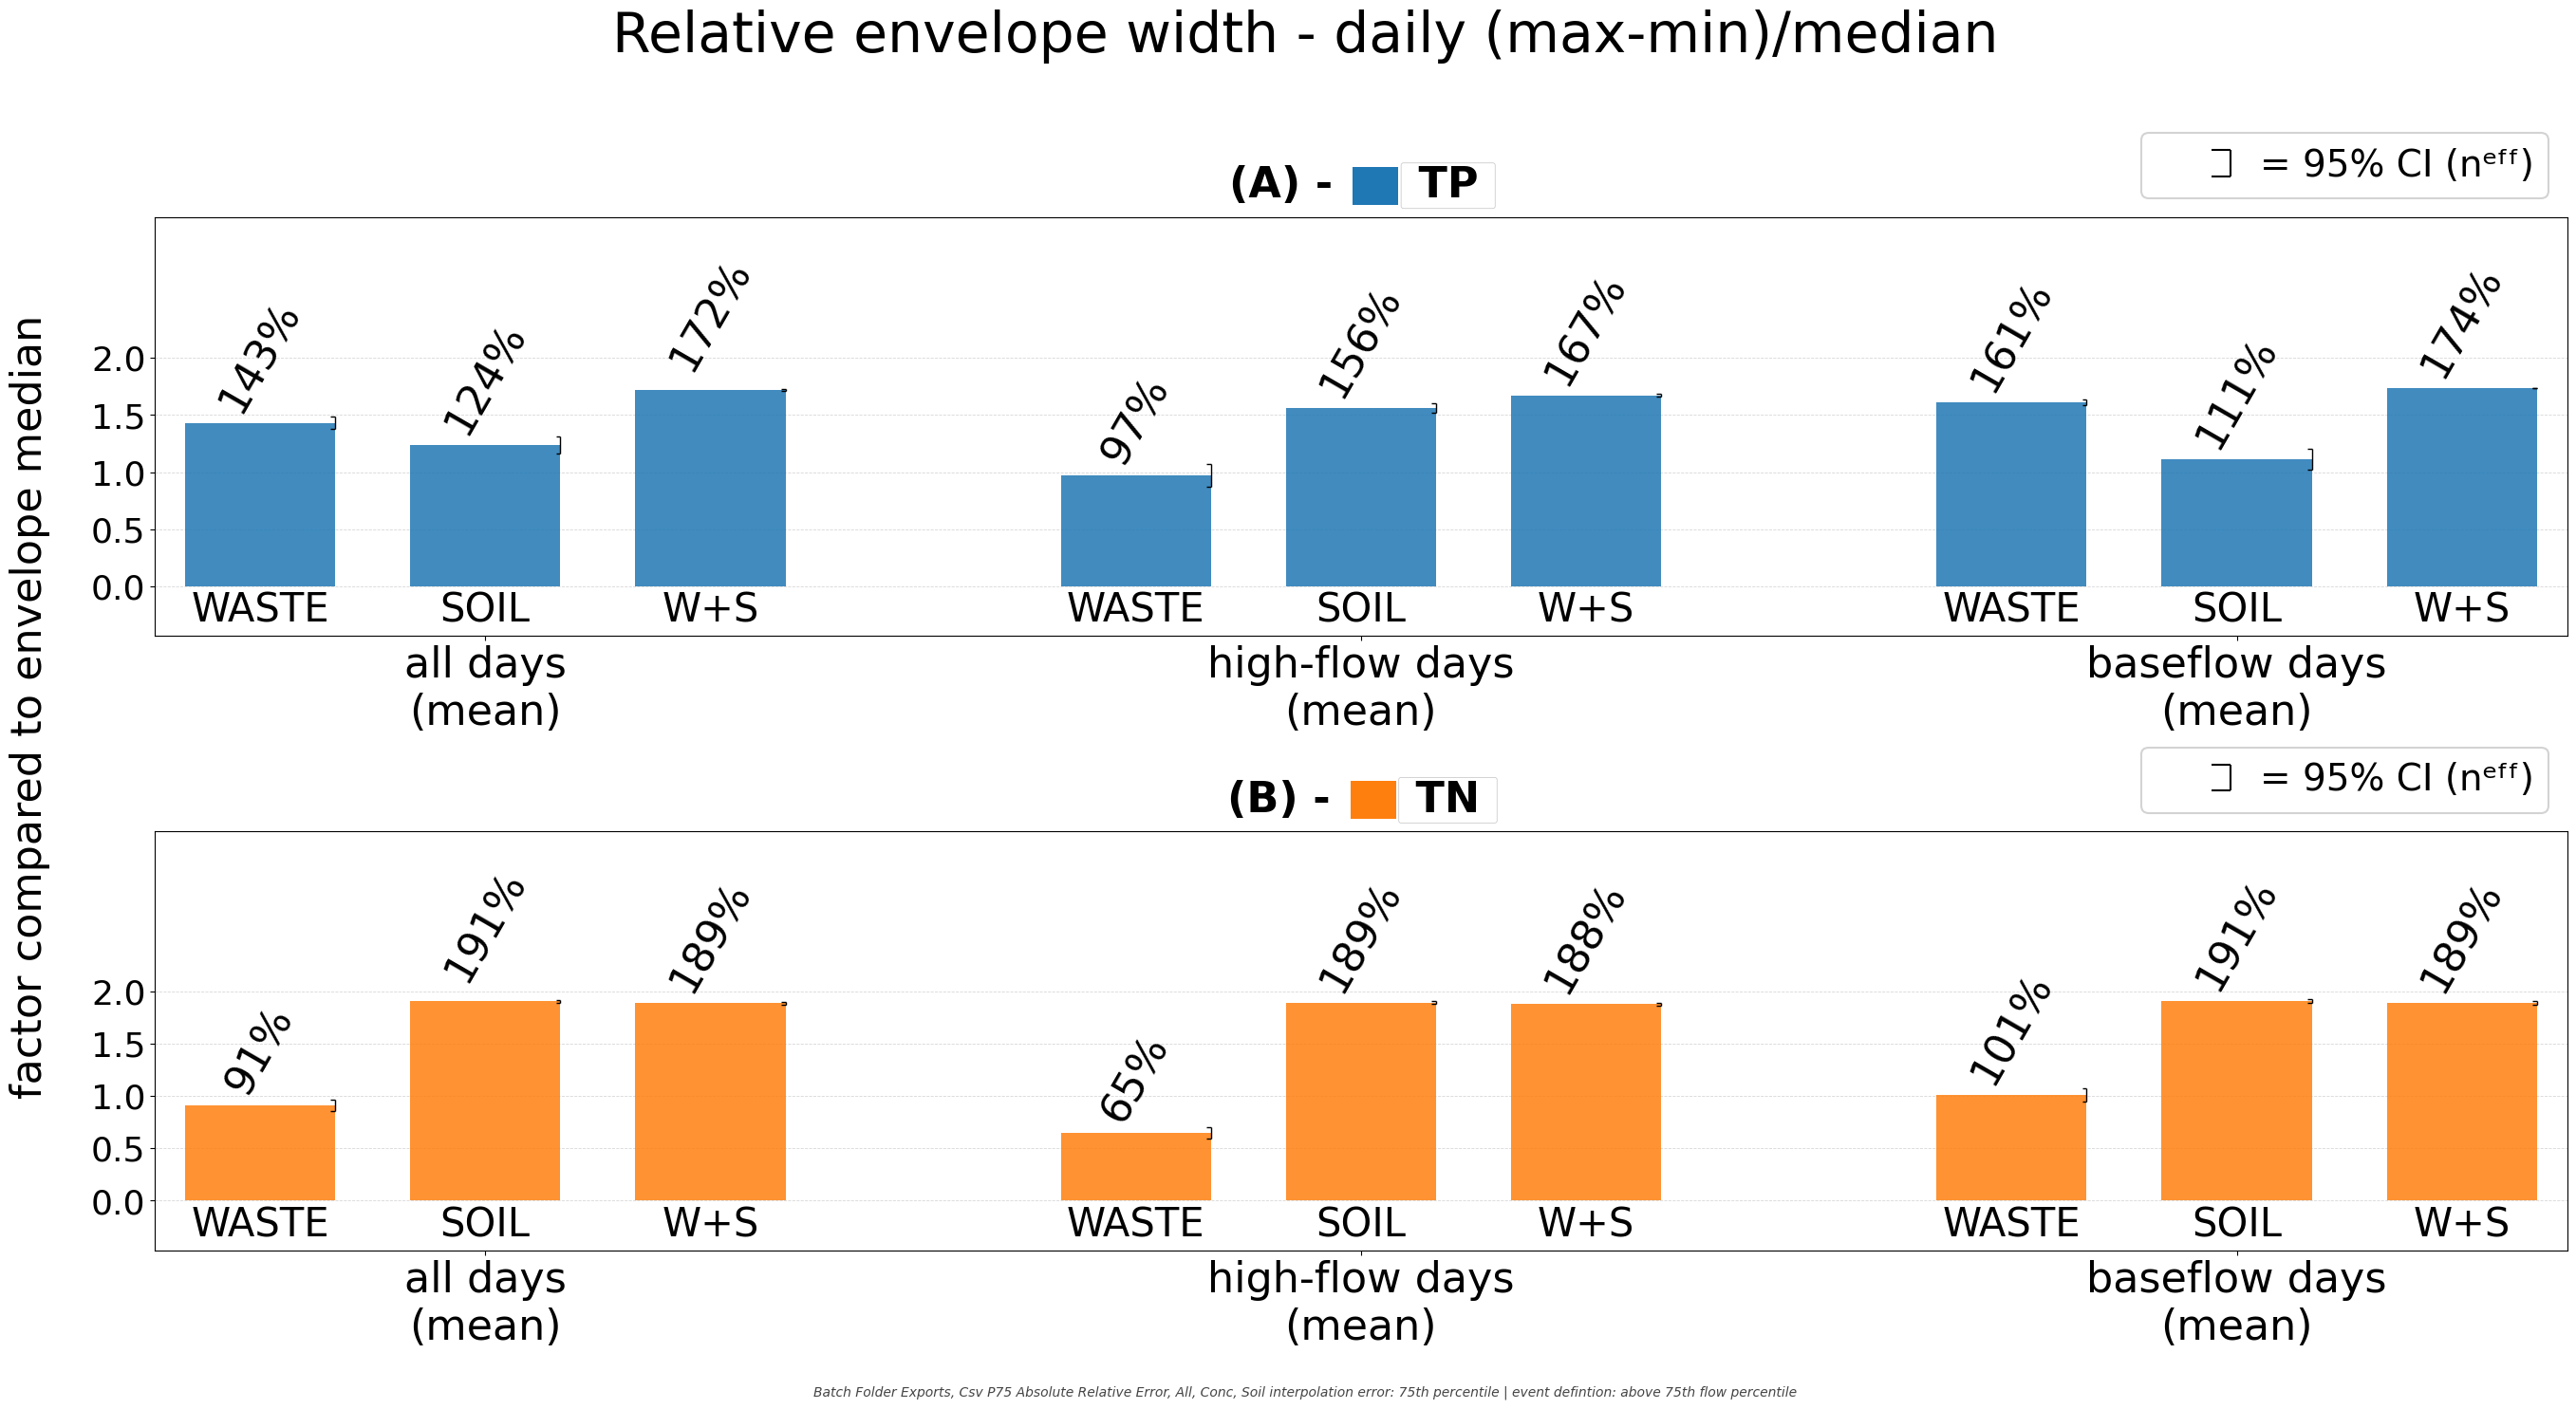


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Relative envelope width - daily (max-min)/median
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Mean (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,0.36,+0.19,+0.53,+0.102,+0.289,+8.2%,...,369,210,14245,14234,+0.195,+15.8%,1.43,1.24,0.5,0.579
1,Mean (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,-0.81,-0.96,-0.65,-0.339,-0.236,-19.7%,...,369,357,14245,14245,-0.287,-16.7%,1.43,1.72,0.5,0.0584
2,Mean (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-1.17,-1.35,-0.98,-0.561,-0.403,-32.6%,...,210,357,14234,14245,-0.482,-28.1%,1.24,1.72,0.579,0.0584
3,Mean (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-3.79,-4.19,-3.38,-1.05,-0.936,-55.1%,...,170,103,14245,14234,-0.993,-52.1%,0.913,1.91,0.361,0.0803
4,Mean (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-3.74,-4.13,-3.35,-1.03,-0.919,-54.6%,...,170,113,14245,14245,-0.975,-51.6%,0.913,1.89,0.361,0.0695
5,Mean (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,0.24,-0.03,+0.51,-0.00228,+0.0382,-0.1%,...,103,113,14234,14245,+0.018,+1.0%,1.91,1.89,0.0803,0.0695
6,Mean (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,1.19,+1.00,+1.39,+0.445,+0.594,+48.7%,...,369,170,14245,14245,+0.52,+56.9%,1.43,0.913,0.5,0.361
7,Mean (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,-1.61,-1.88,-1.34,-0.749,-0.588,-39.3%,...,210,103,14234,14234,-0.669,-35.1%,1.24,1.91,0.579,0.0803
8,Mean (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-2.61,-2.88,-2.34,-0.183,-0.154,-9.7%,...,357,113,14245,14245,-0.168,-8.9%,1.72,1.89,0.0584,0.0695
9,Mean (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-1.24,-1.48,-0.99,-0.701,-0.485,-44.9%,...,152,149,3930,3919,-0.593,-38.0%,0.969,1.56,0.629,0.247


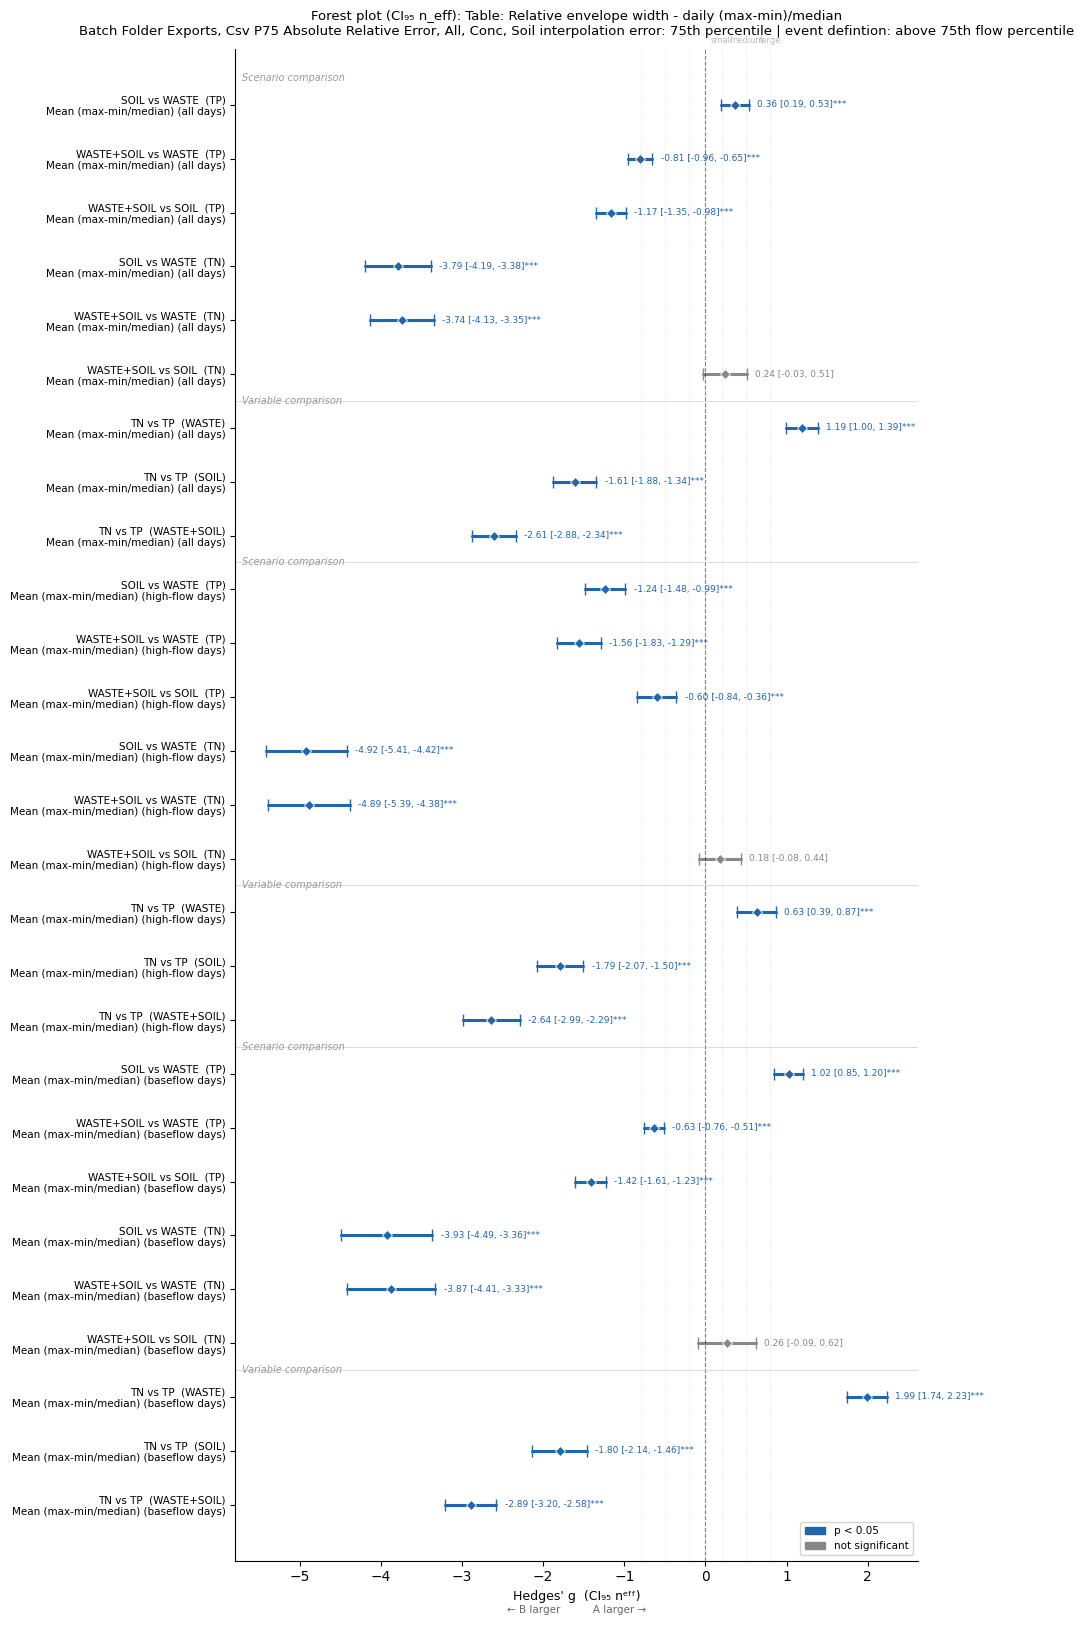

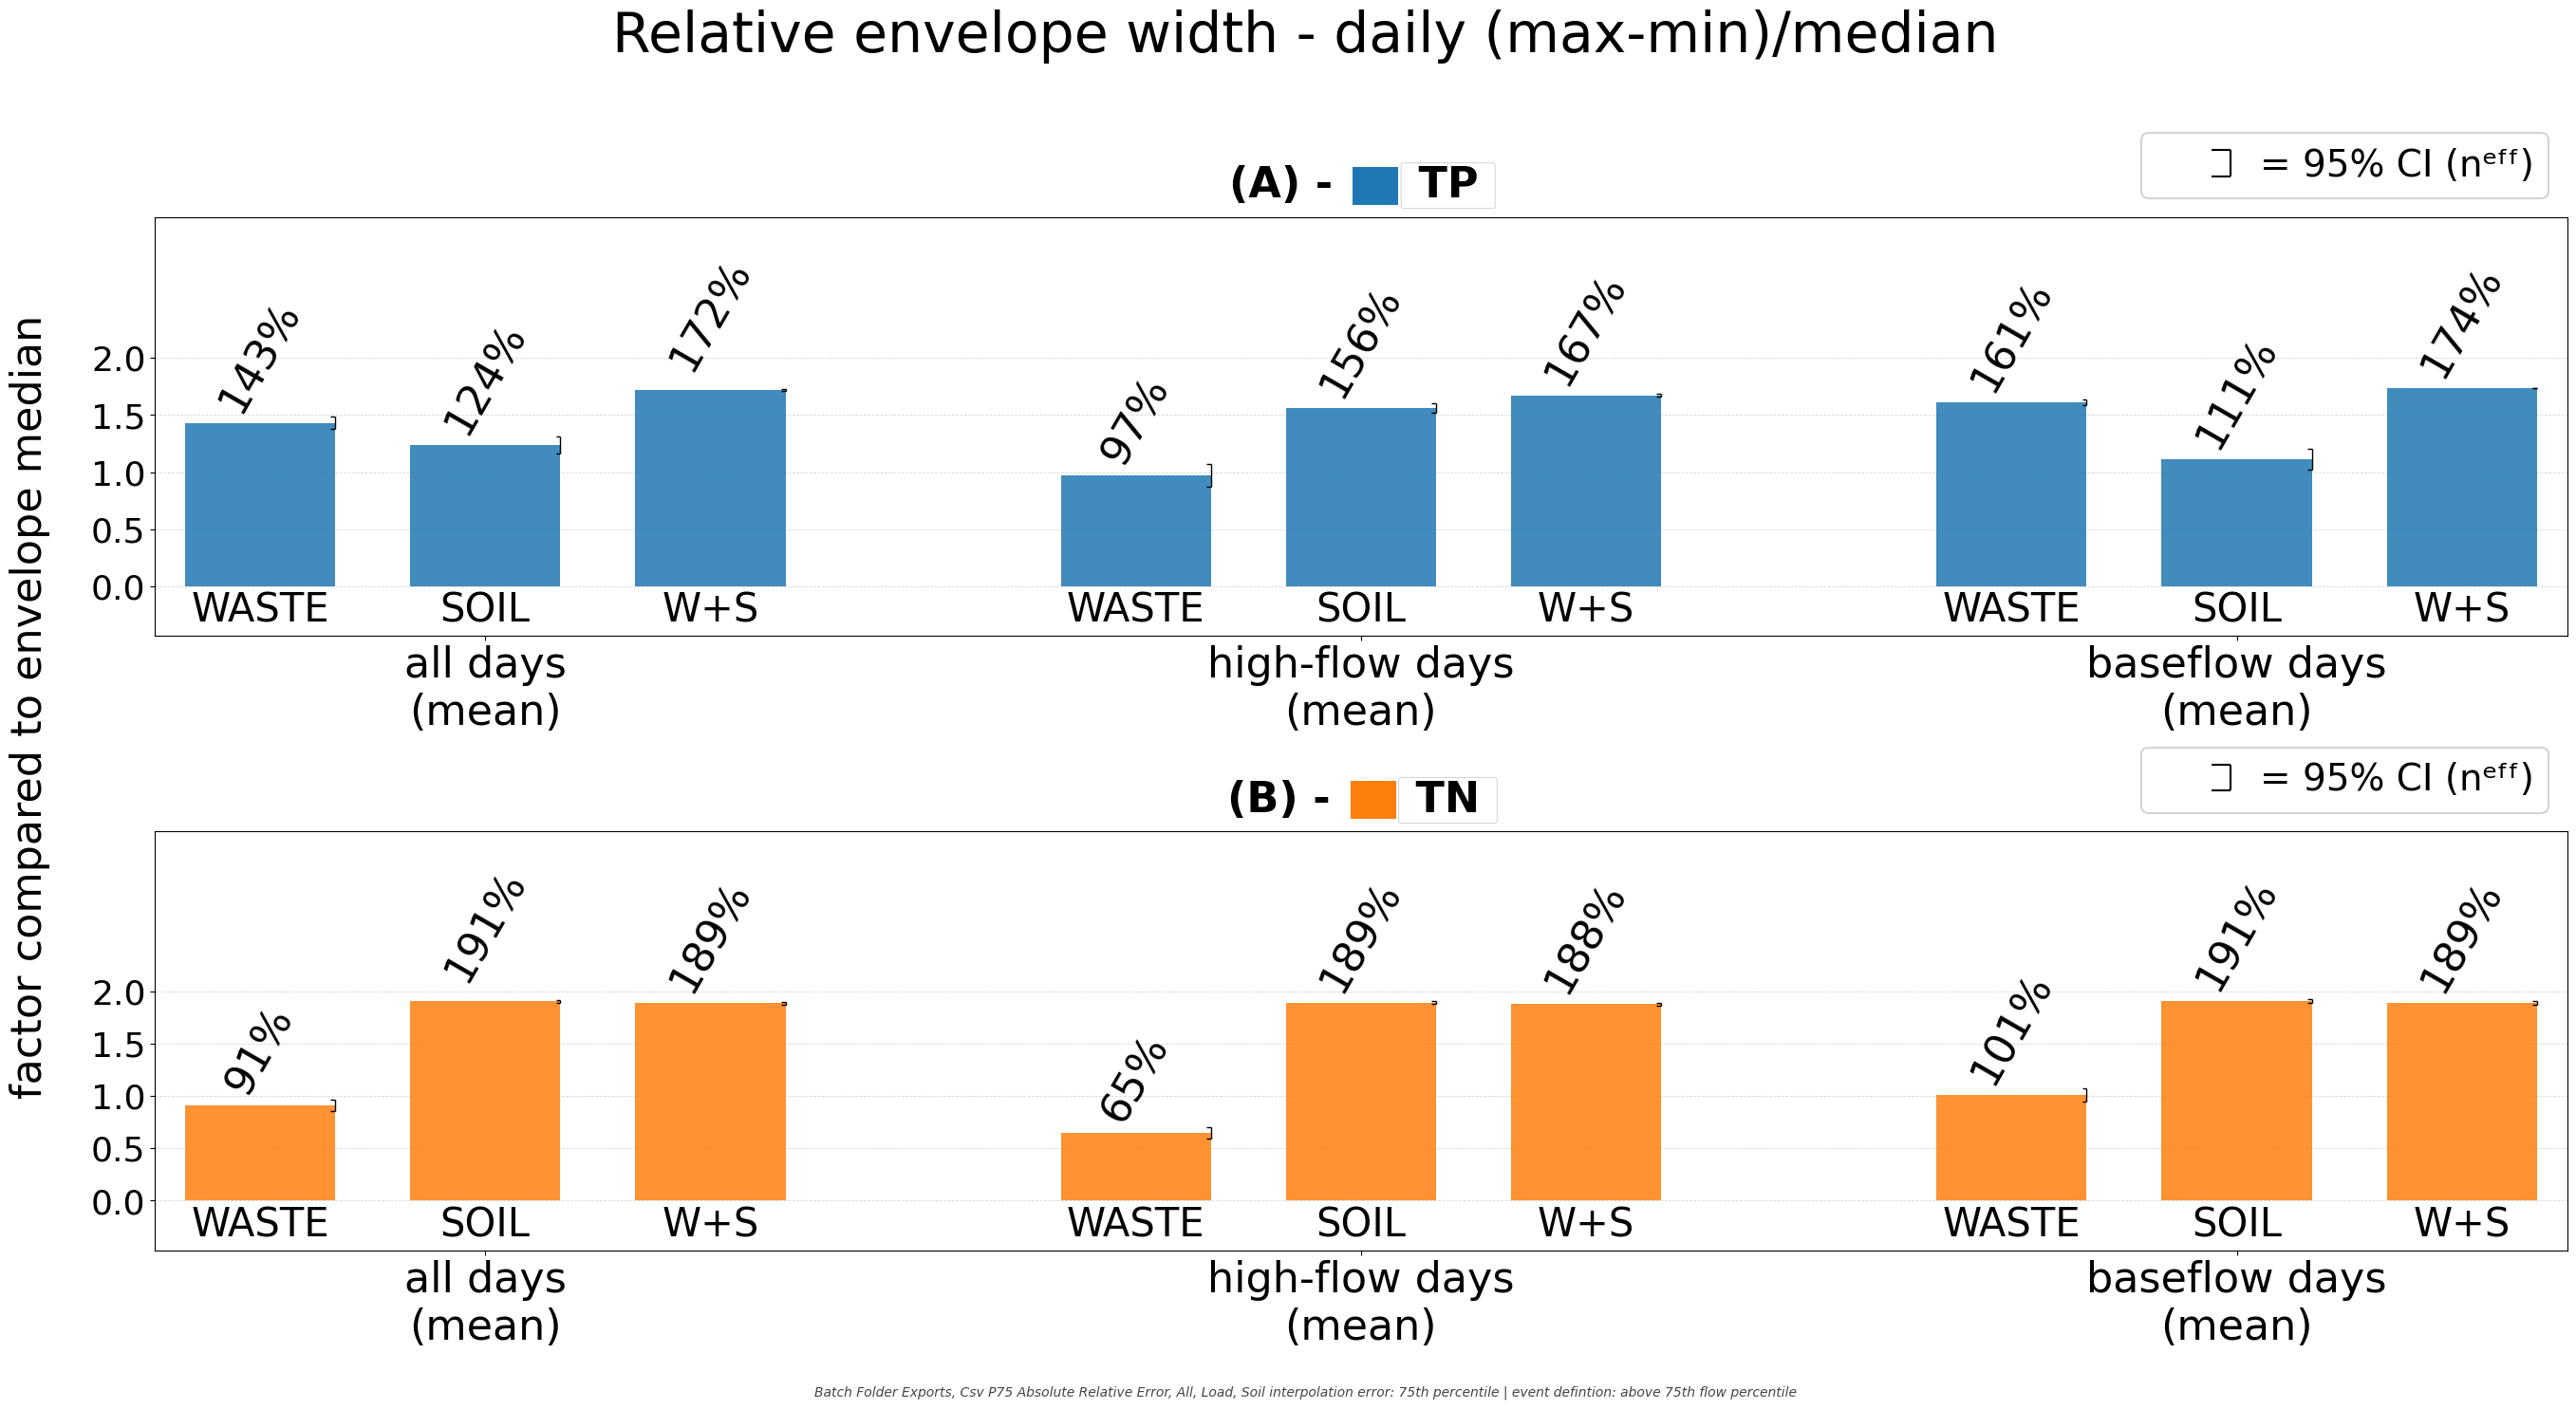


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Relative envelope width - daily (max-min)/median
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Mean (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,0.36,+0.19,+0.53,+0.102,+0.289,+8.2%,...,369,210,14245,14234,+0.195,+15.8%,1.43,1.24,0.5,0.579
1,Mean (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,-0.81,-0.96,-0.65,-0.339,-0.236,-19.7%,...,369,357,14245,14245,-0.287,-16.7%,1.43,1.72,0.5,0.0584
2,Mean (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-1.17,-1.35,-0.98,-0.561,-0.403,-32.6%,...,210,357,14234,14245,-0.482,-28.1%,1.24,1.72,0.579,0.0584
3,Mean (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-3.79,-4.19,-3.38,-1.05,-0.936,-55.1%,...,170,103,14245,14234,-0.993,-52.1%,0.913,1.91,0.361,0.0803
4,Mean (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-3.74,-4.13,-3.35,-1.03,-0.919,-54.6%,...,170,113,14245,14245,-0.975,-51.6%,0.913,1.89,0.361,0.0695
5,Mean (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,0.24,-0.03,+0.51,-0.00228,+0.0382,-0.1%,...,103,113,14234,14245,+0.018,+1.0%,1.91,1.89,0.0803,0.0695
6,Mean (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,1.19,+1.00,+1.39,+0.445,+0.594,+48.7%,...,369,170,14245,14245,+0.52,+56.9%,1.43,0.913,0.5,0.361
7,Mean (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,-1.61,-1.88,-1.34,-0.749,-0.588,-39.3%,...,210,103,14234,14234,-0.669,-35.1%,1.24,1.91,0.579,0.0803
8,Mean (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-2.61,-2.88,-2.34,-0.183,-0.154,-9.7%,...,357,113,14245,14245,-0.168,-8.9%,1.72,1.89,0.0584,0.0695
9,Mean (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-1.24,-1.48,-0.99,-0.701,-0.485,-44.9%,...,152,149,3930,3919,-0.593,-38.0%,0.969,1.56,0.629,0.247


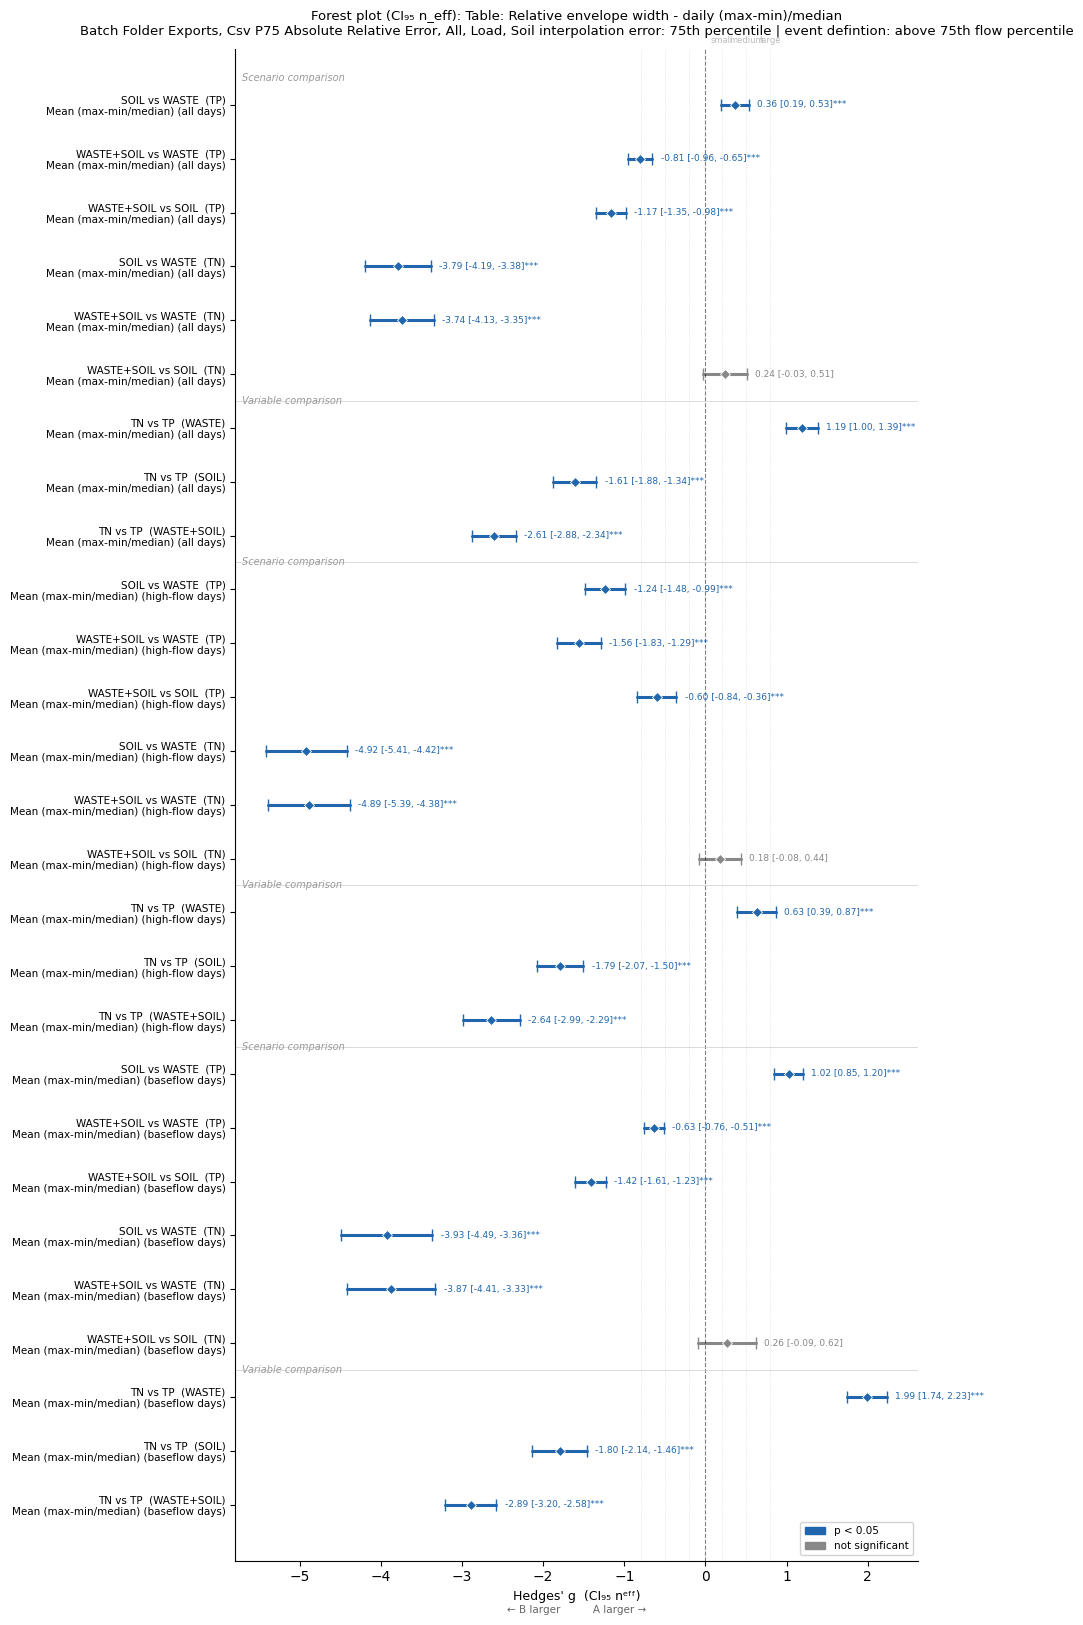

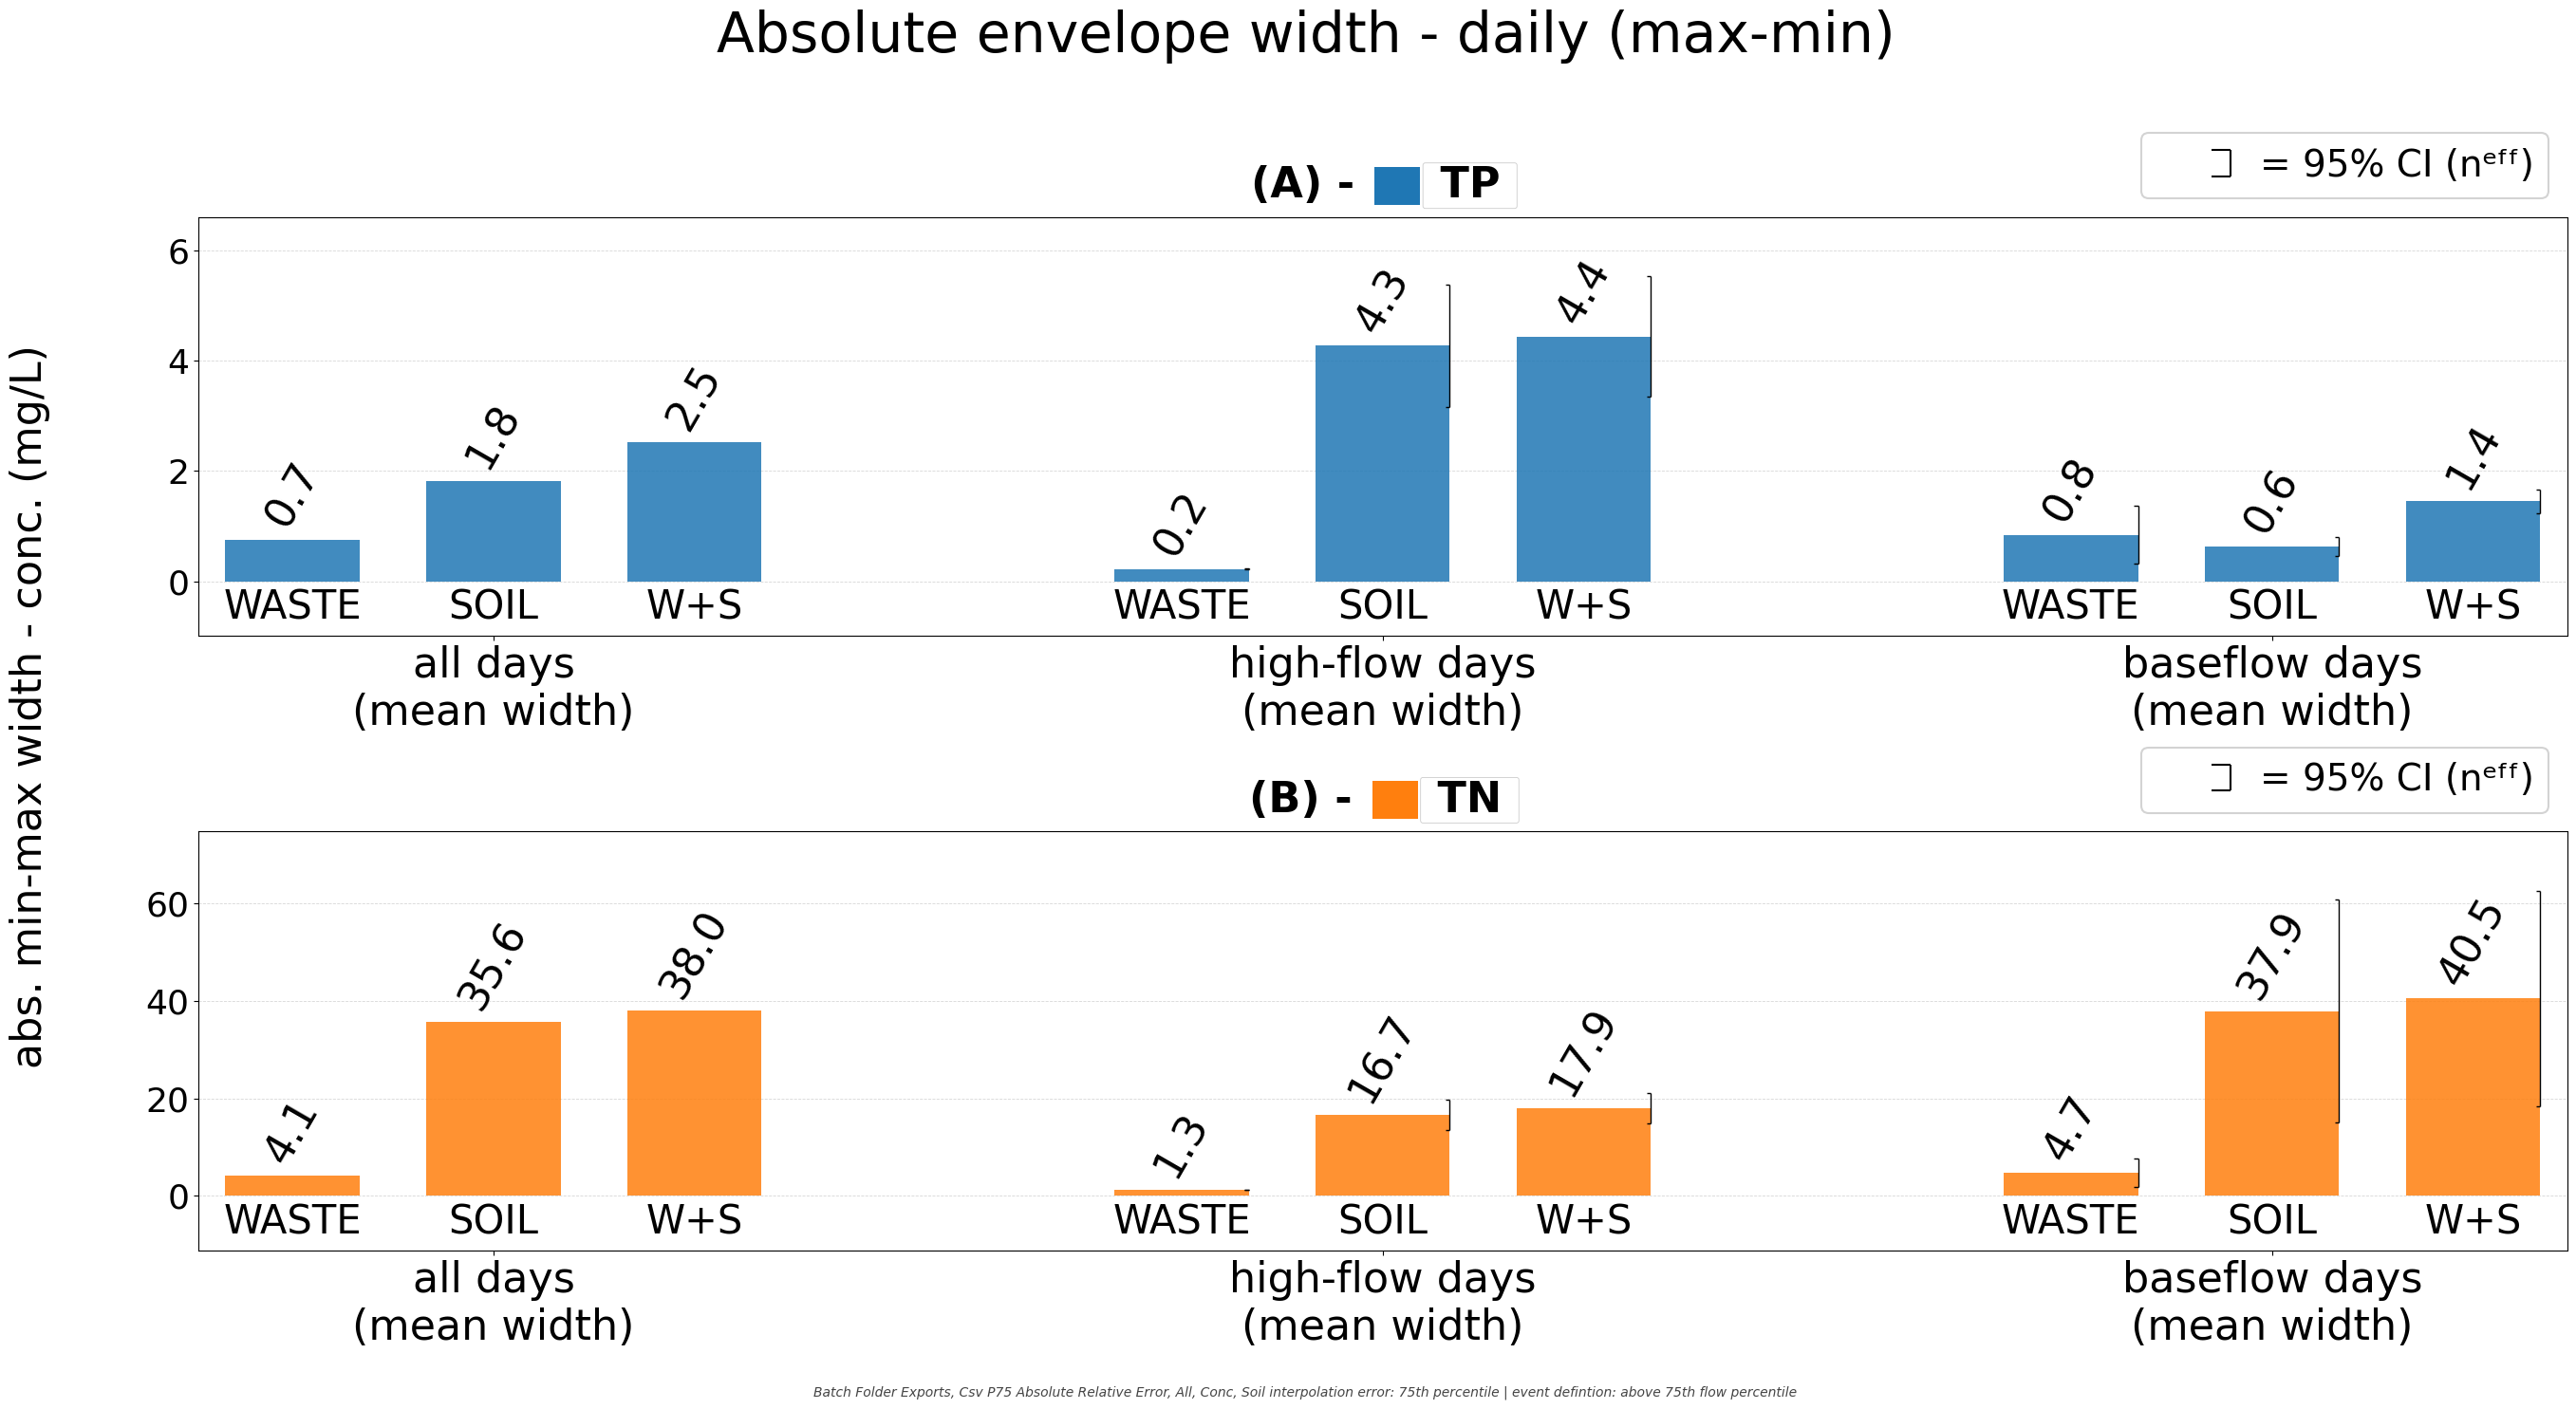


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - daily (max-min)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Model raw width mean (W),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-1.07,-58.8%,0.747,1.81,,
1,Model raw width mean (W),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-1.78,-70.4%,0.747,2.52,,
2,Model raw width mean (W),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.709,-28.1%,1.81,2.52,,
3,Model raw width mean (W),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-31.5,-88.4%,4.13,35.6,,
4,Model raw width mean (W),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-33.9,-89.1%,4.13,38,,
5,Model raw width mean (W),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-2.45,-6.4%,35.6,38,,
6,Model raw width mean (W),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,-3.38,-81.9%,0.747,4.13,,
7,Model raw width mean (W),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-33.8,-94.9%,1.81,35.6,,
8,Model raw width mean (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,-35.5,-93.4%,2.52,38,,
9,Ensemble mean W (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.60,-0.77,-0.43,-5.16,-2.93,-120.8%,...,260,284,3930,3919,-4.04,-94.7%,0.225,4.27,0.089,9.54


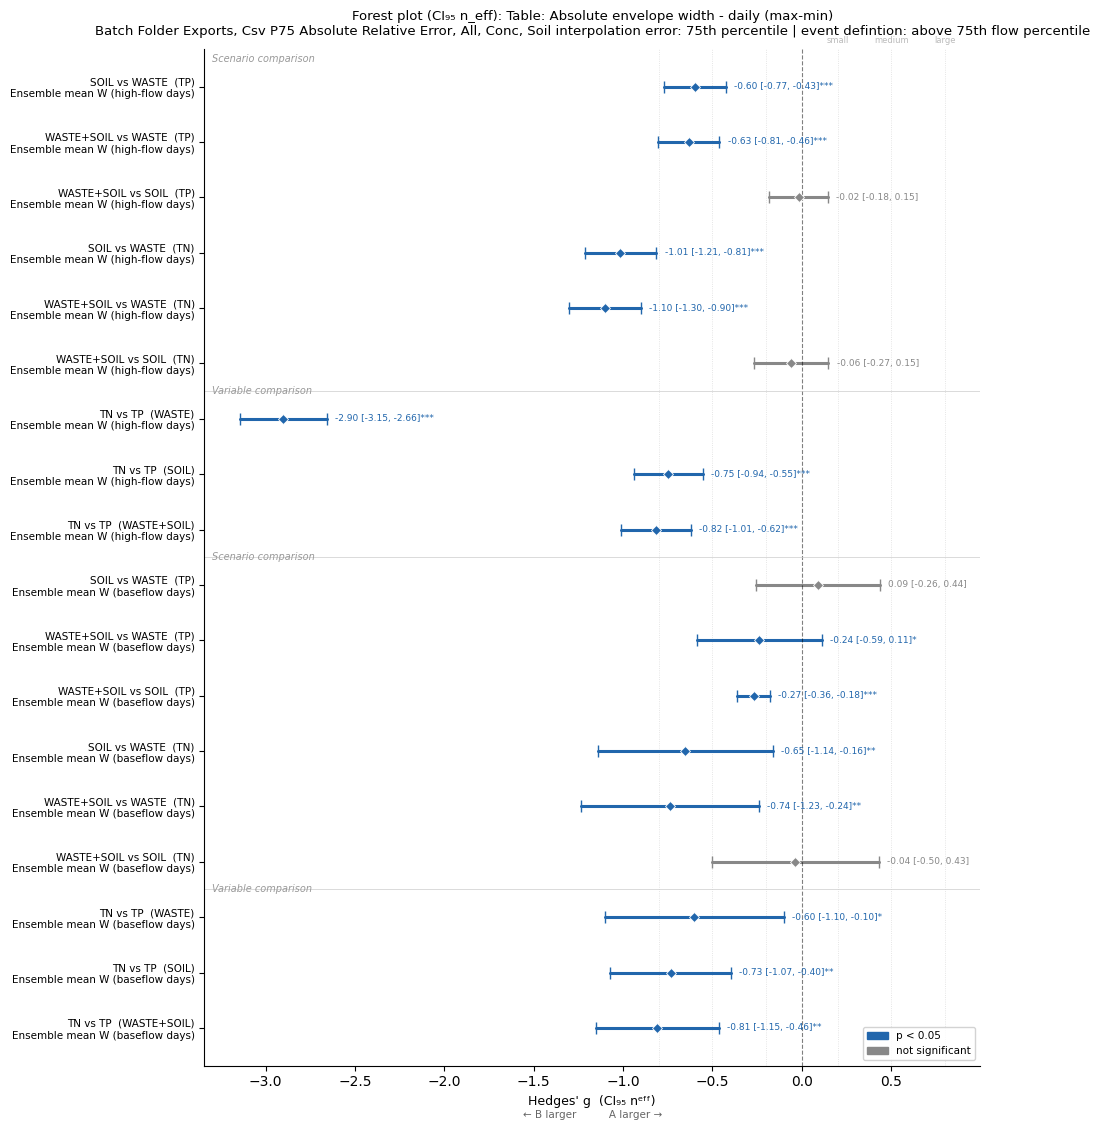

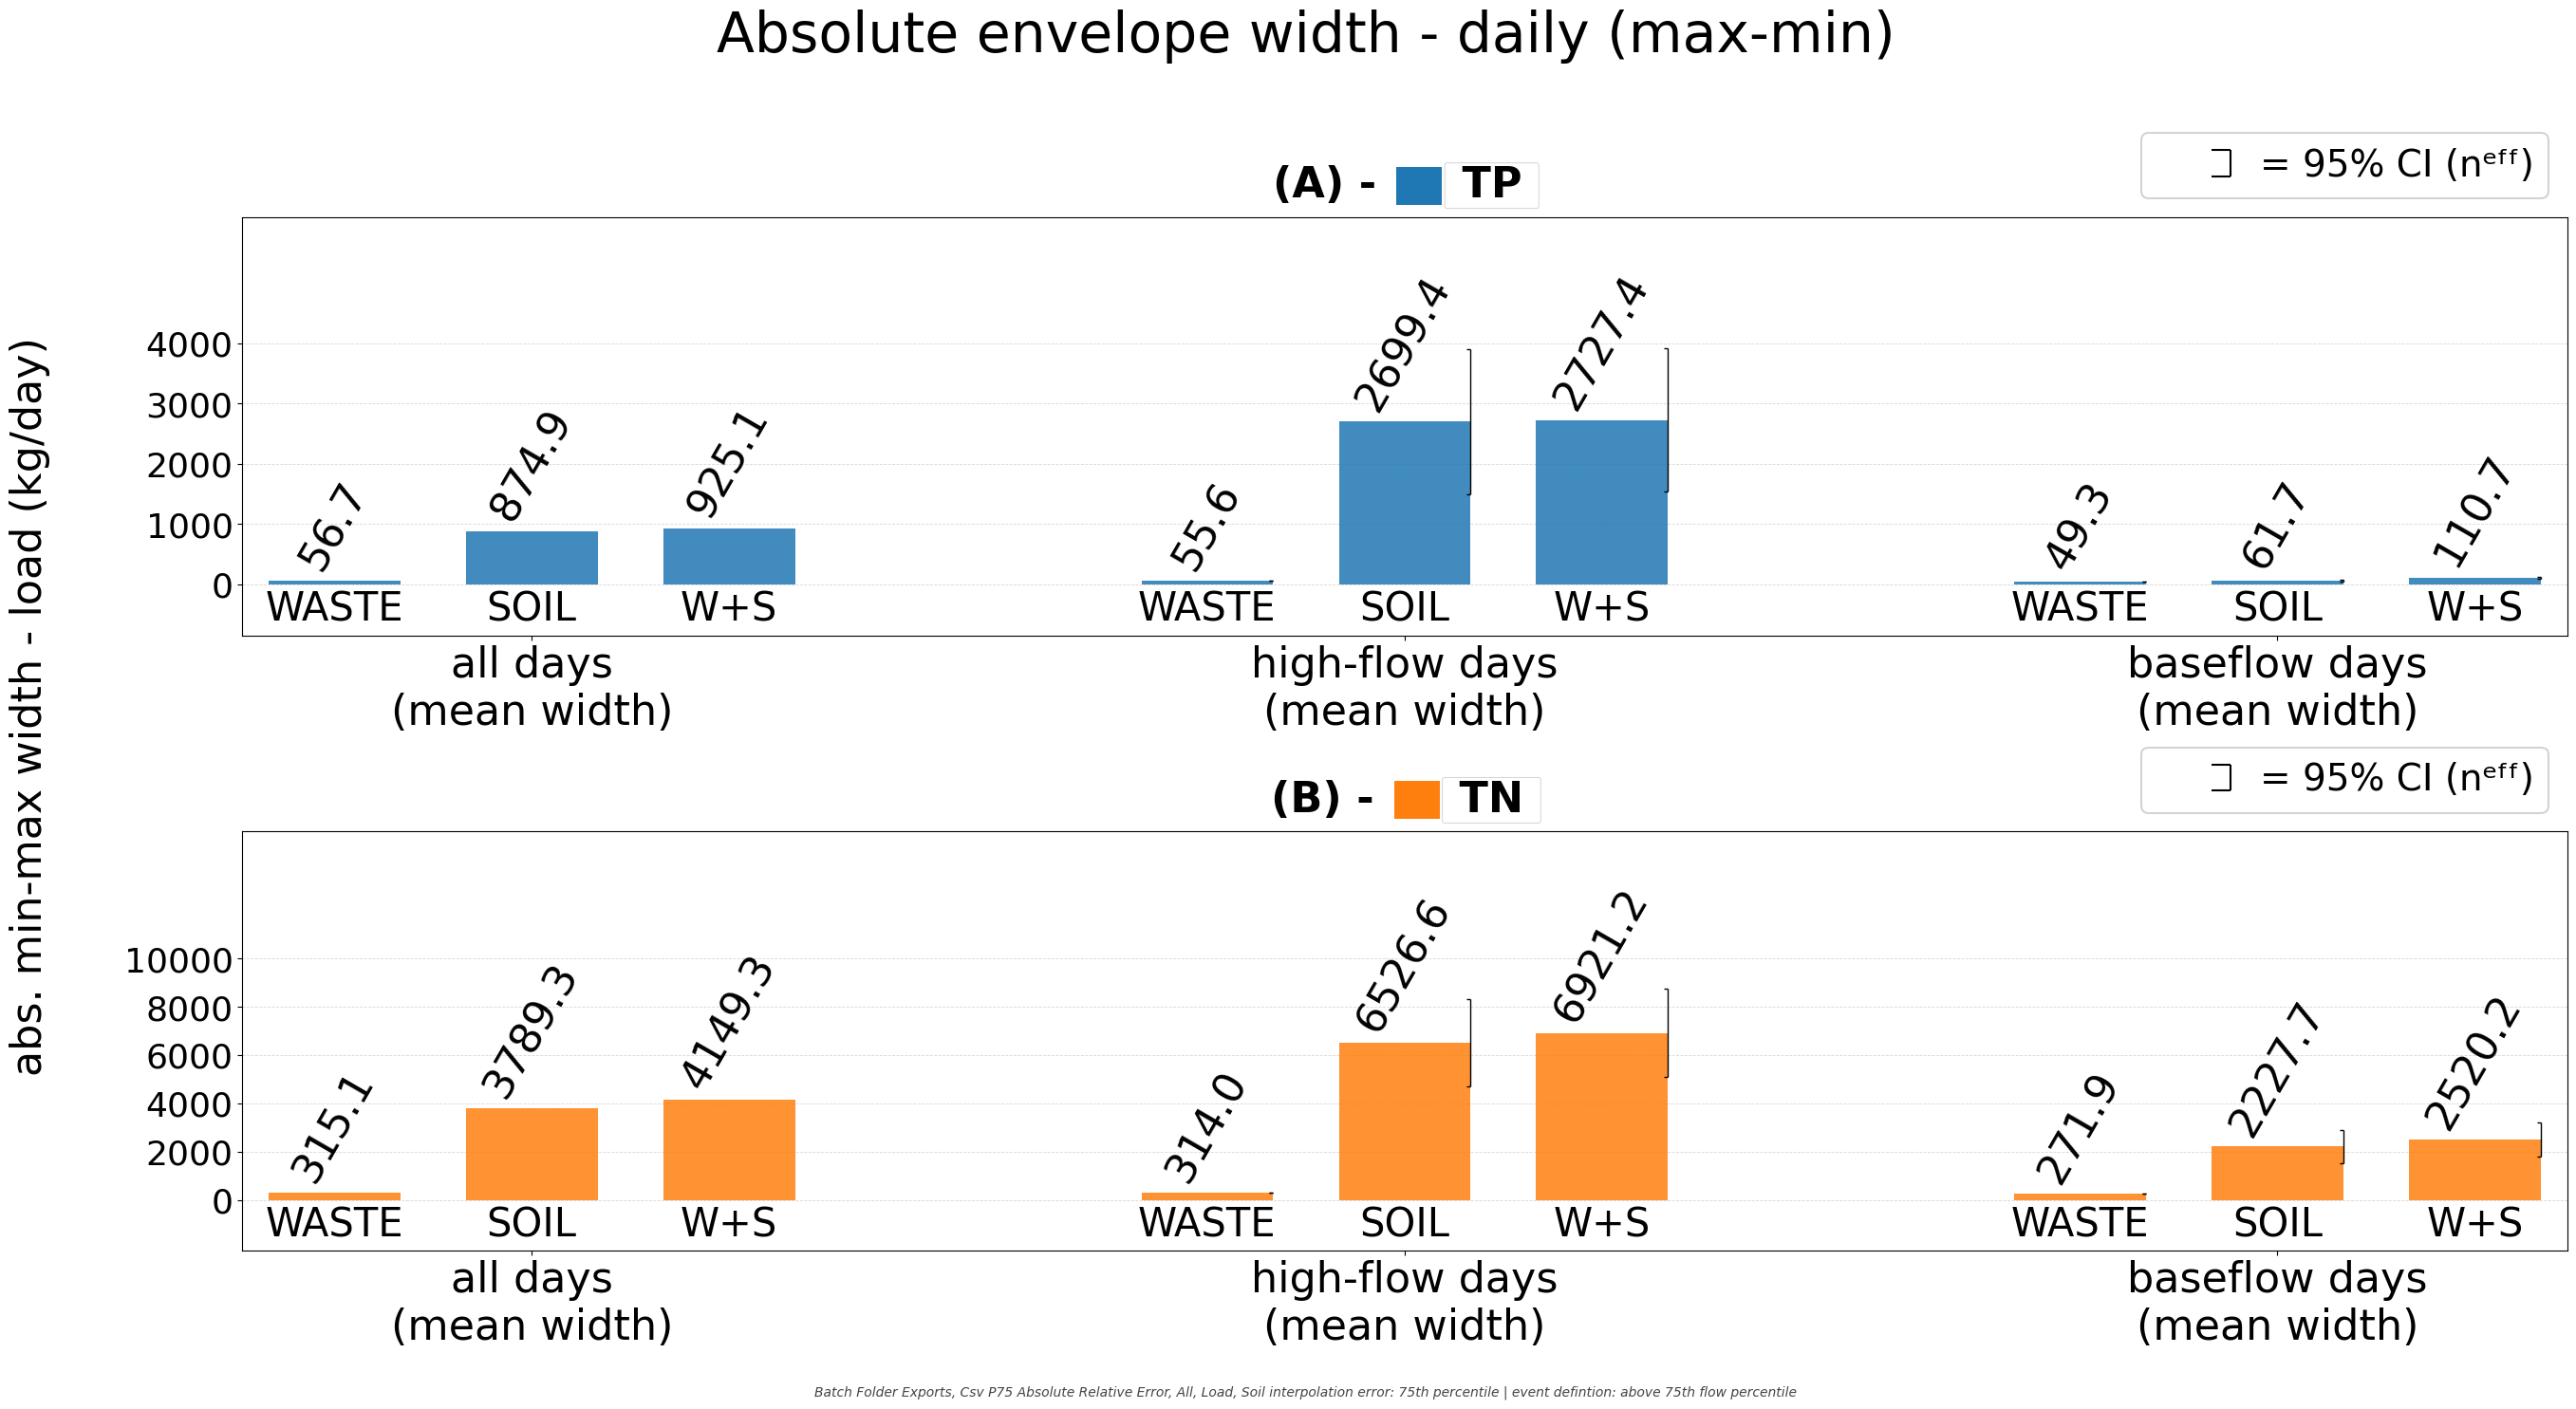


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - daily (max-min)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Model raw width mean (W),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-818,-93.5%,56.7,875,,
1,Model raw width mean (W),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-868,-93.9%,56.7,925,,
2,Model raw width mean (W),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-50.3,-5.4%,875,925,,
3,Model raw width mean (W),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-3.47e+03,-91.7%,315,3.79e+03,,
4,Model raw width mean (W),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-3.83e+03,-92.4%,315,4.15e+03,,
5,Model raw width mean (W),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-360,-8.7%,3.79e+03,4.15e+03,,
6,Model raw width mean (W),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,-258,-82.0%,56.7,315,,
7,Model raw width mean (W),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-2.91e+03,-76.9%,875,3.79e+03,,
8,Model raw width mean (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,-3.22e+03,-77.7%,925,4.15e+03,,
9,Ensemble mean W (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.26,-0.36,-0.15,-3.85e+03,-1.44e+03,-142.7%,...,1071,558,3930,3919,-2.64e+03,-97.9%,55.6,2.7e+03,6.29,1.45e+04


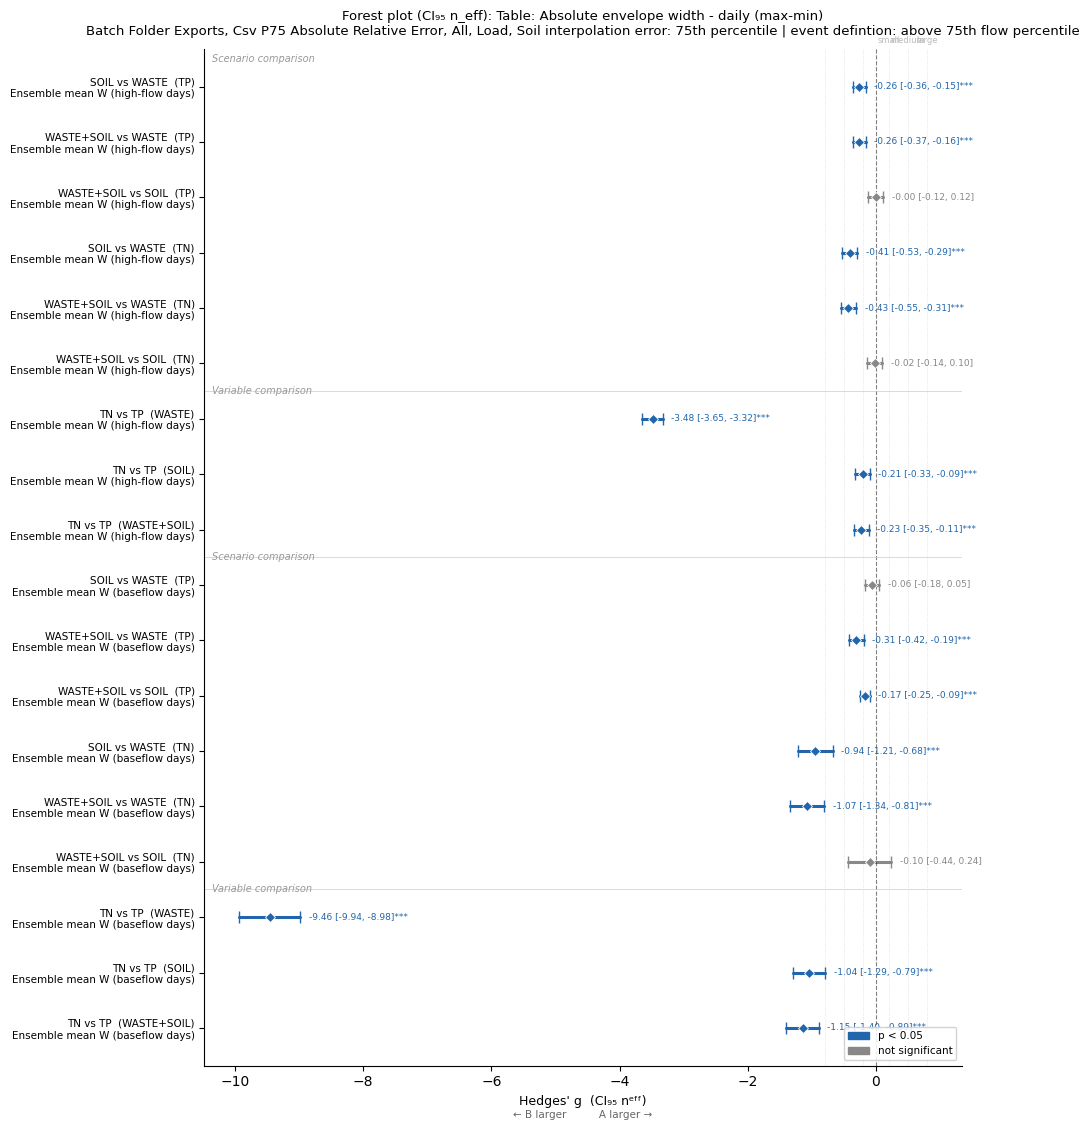


Finished chart 1 (a/b/c/d) for all configured folders.


In [15]:
chart_1_metrics_by_folder = {}
chart_1_logs = []

# ── Mean/median bar toggle ────────────────────────────────────────────────────
# True  → bars show the MEAN of daily R_t / W_t.  Fully consistent with
#         CI95(Δ) and Hedges’ g mean-based pairwise tests and with the
#         CI95-of-mean whiskers (error_mode="ci95_neff").
# False → bars show the MEDIAN (original robust-location approach).
#         To revert: flip to False and re-run this cell only.
CH1_USE_MEAN: bool = True


# "-- Chart configuration for 4 sub-charts "----------------------------------
_chart_1_variants = [
    # {
    #     "slug": "chart_1a_relative_width_median",
    #     "labels": ch1a_semantic_labels,
    #     "descriptor": "Relative sensitivity - median((p95ˆ'p05)/p50)",
    #     "y_label": "factor compared to envelope median",
    #     "stat_label_map": {
    #         "Model relative width median((p95-p05)/p50)": "all days",
    #         "Relative width (high-flow days)": "high flow",
    #         "Relative width (baseflow days)": "baseflow",
    #         "Flow ratio (ensemble spread)": "flow ratio",
    #     },
    #     "figsize": (16, 8),
    # },

    {
        # CH1_USE_MEAN = True  → ch1e (mean (max-min)/median)   ← active
        # CH1_USE_MEAN = False → ch1d (median (max-min)/median)  original
        "slug": "chart_1e_mean_maxmin_over_median" if CH1_USE_MEAN else "chart_1d_maxmin_over_median",
        "labels": ch1e_semantic_labels if CH1_USE_MEAN else ch1d_semantic_labels,
        "descriptor": "Relative envelope width - daily (max-min)/median",
        "y_label": "factor compared to envelope median",
        "stat_label_map": (
            {
                "Mean (max-min/median) (all days)": "all days\n(mean)",
                "Mean (max-min/median) (high-flow days)": "high-flow days\n(mean)",
                "Mean (max-min/median) (baseflow days)": "baseflow days\n(mean)",
            } if CH1_USE_MEAN else {
                "Median (max-min/median) (all days)": "all days\n(median)",
                "Median (max-min/median) (high-flow days)": "high-flow days\n(median)",
                "Median (max-min/median) (baseflow days)": "baseflow days\n(median)",
            }
        ),
        "figsize": (20, 8),
    },

    {
        # CH1_USE_MEAN = True  → ch1b_mean (mean W)    ← active
        # CH1_USE_MEAN = False → ch1b     (median W)   original
        "slug": "chart_1b_absolute_width",
        "labels": ch1b_mean_semantic_labels if CH1_USE_MEAN else ch1b_semantic_labels,
        "descriptor": "Absolute envelope width - daily (max-min)",
        "y_label": "min-max width",
        "y_label_mode_map": {
            "conc": {"suffix": "conc.", "units": "mg/L"},
            "load": {"suffix": "load", "units": "kg/day"},
        },
        "stat_label_map": (
            {
                "Model raw width mean (W)": "all days\n(mean width)",
                "Ensemble mean W (high-flow days)": "high-flow days\n(mean width)",
                "Ensemble mean W (baseflow days)": "baseflow days\n(mean width)",
            } if CH1_USE_MEAN else {
                "Model raw width median (W)": "all days\n(median width)",
                "Ensemble median W (high-flow days)": "high-flow days\n(median width)",
                "Ensemble median W (baseflow days)": "baseflow days\n(median width)",
            }
        ),
        "figsize": (14, 8),
    },
    # {
    #     "slug": "chart_1c_relative_width_mean",
    #     "labels": ch1c_semantic_labels,
    #     "descriptor": "Relative sensitivity" mean-based relative width",
    #     "y_label": "factor compared to envelope mean",
    #     "stat_label_map": {
    #         "Mean relative width (all days)": "all days",
    #         "Mean relative width (high-flow days)": "high-flow days",
    #         "Mean relative width (baseflow days)": "baseflow days",
    #     },
    #     "figsize": (14, 8),
    # },

]

ch_1_title_metadata_parts = [
    "folder_label",
    "event_threshold",
]

ch_1_title_folder_label_map = {
    "runs_187_200_202":      "Soil interpolation error: relative median",
    "runs_205_200_204":      "Soil interpolation error: absolute median",
    "runs_189_200_203":      "Soil interpolation error: relative RMSE",
    "runs_188_200_201":      "Soil interpolation error: 75th percentile",
    "runs_153_155_157":      "Original TFM (relative RMSE)",
    "drop_mdl":              None,
    "half_mdl":              None,
}

EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "event defintion: above 50th flow percentile",
    "p75": "event defintion: above 75th flow percentile",
    "p90": "event defintion: above 90th flow percentile",
    "abs": "event defintion: above absolute flow value",
}

# "-- Pass 1: pre-compute specs & metrics per folder "------------------------
_ch1_folder_data = {}
_last_ch1_compare_mode = None
for batch_folder in _ch12_batch_folders:
    _ch1_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch1_compare_mode != _last_ch1_compare_mode:
        _print_graph_group_separator(_ch1_compare_mode, chart_label='Chart 1')
        _last_ch1_compare_mode = _ch1_compare_mode
    _folder_key = str(batch_folder)
    generated_specs, build_log = _capture_stdout(
        build_export_specs_from_folder,
        batch_folder,
        run_to_scenario,
        variable_map,
        verbose=True,
    )

    _ch1_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))
    _ch1_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))
    _ch1_selected_scenarios = _ordered_present_values(_ch1_actual_scenarios, chart_scenario_order)
    _ch1_selected_variables = _ordered_present_values(_ch1_actual_variables, chart_variable_order)

    ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
        generated_specs,
        ch1_semantic_labels,
        semantic_label_map=example_semantic_label_map,
        scenario_order=_ch1_selected_scenarios,
        variable_order=_ch1_selected_variables,
        format_mode="metadata",
        verbose=False,
    )

    _ch1_folder_data[_folder_key] = {
        "batch_folder": batch_folder,
        "generated_specs": generated_specs,
        "build_log": build_log,
        "selected_scenarios": _ch1_selected_scenarios,
        "selected_variables": _ch1_selected_variables,
        "auto_metrics": ch_1_auto_metrics,
    }

    chart_1_metrics_by_folder[batch_folder.name] = ch_1_auto_metrics
    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_1_metrics"] = ch_1_auto_metrics

    chart_1_logs.append(f"Chart 1 folder: {batch_folder.name}")
    chart_1_logs.append(f"  scenarios: {_ch1_selected_scenarios}")
    chart_1_logs.append(f"  variables: {_ch1_selected_variables}")
    if build_log.strip():
        chart_1_logs.append(build_log.rstrip())
    chart_1_logs.append("")

# "-- Pass 2: for each variant, render all folders "--------------------------
for variant in _chart_1_variants:
    for fname, fdata in _ch1_folder_data.items():
        batch_folder = fdata["batch_folder"]
        generated_specs = fdata["generated_specs"]
        _ch1_selected_scenarios = fdata["selected_scenarios"]
        _ch1_selected_variables = fdata["selected_variables"]
        ch_1_auto_metrics = fdata["auto_metrics"]

        variant_metrics = {
            "metrics": {
                k: v for k, v in ch_1_auto_metrics["metrics"].items()
                if k in variant["labels"]
            }
        }

        chart_title, chart_subtitle = build_semantic_chart_title(
            batch_folder, generated_specs,
            variant["descriptor"],
            title_metadata_parts=ch_1_title_metadata_parts,
            title_folder_label_map=ch_1_title_folder_label_map,
        )


        # Use stat_label_map keys for error data to improve label mapping success
        _ch1_error_metric_labels = list(variant.get("stat_label_map", {}).keys()) if "stat_label_map" in variant else variant["labels"]
        _ch1_error_data = build_error_data_from_extended_stats(
            generated_specs, _ch1_error_metric_labels,
            error_mode="ci95_neff" if USE_NEFF_CI else "ci95",
        )

        # "-- Build per-panel y-axis labels when the variant defines a mode map "-
        _ch1_per_panel_y_labels = None
        _ylm = variant.get("y_label_mode_map")
        if _ylm:
            _mode = _resolve_batch_folder_compare_mode(batch_folder)
            _mi = _ylm.get(_mode)
            if _mi:
                _ch1_per_panel_y_labels = {
                    v: f"abs. {variant['y_label']} - {_mi['suffix']} ({_mi['units']})"
                    for v in _ch1_selected_variables
                }

        # In vertical stacking mode, collapse identical per-panel y-labels
        # into a single shared y_label so the function draws one centred label.
        _ch1_y_label_override = variant["y_label"]
        if chart_split_panel_stack_vertical and _ch1_per_panel_y_labels:
            _unique_labels = set(_ch1_per_panel_y_labels.values())
            _ch1_y_label_override = next(iter(_unique_labels))
            _ch1_per_panel_y_labels = None

        fig, ax = plot_nested_sensitivity_bars(
            variant_metrics,
            variables_order=_ch1_selected_variables,
            title=chart_title,
            subtitle=chart_subtitle,
            y_label=_ch1_y_label_override,
            small_value_threshold = 0.1,
            small_value_decimals = 2,
            figsize=variant["figsize"],
            scenarios_order=_ch1_selected_scenarios,
            stats_order=variant["labels"],
            stat_label_map=variant["stat_label_map"],
            abbreviations=chart_abbreviations,
            annotate_rotation=60,
            annot_fs=32,
            x_tick_fs=32,
            y_tick_fs=26,
            label_fs=32,
            title_fs=42,
            subtitle_fs=10,
            legend_fs=32,
            scenario_fs=30,
            scenario_label_rotation=0,
            scenario_spacing=0.06,
            legend_outside=False,
            legend_loc="upper right",
            legend_bbox=(0.98, 0.98),
            tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
            top_margin_px=10,
            bottom_margin_px=5,
            inside_legend_top_margin_scale=0.82,
            edge_bar_padding=0.70,
            subtitle_y=-0.0075,
            bottom_margin_for_labels=0.14,
            label_offset_scale=0.03,
            label_separation_scale=0.08,
            label_x_nudge_scale=0.09,
            scenario_label_y_scale=0.02,
            split_variable_panels=chart_split_variable_panels,
            split_panel_figsize=chart_split_panel_figsize,
            split_panel_wspace=chart_split_panel_wspace,
            split_panel_suptitle_y=chart_split_panel_suptitle_y,
            split_panel_suptitle_fs=chart_split_panel_suptitle_fs,
            split_panel_variable_title=chart_split_panel_variable_title,
            split_panel_variable_title_fs=chart_split_panel_variable_title_fs,
            split_panel_variable_title_bg=chart_split_panel_variable_title_bg,
            split_panel_variable_title_pad=chart_split_panel_variable_title_pad,
            split_panel_left_y_label_only=chart_split_panel_left_y_label_only,
            split_panel_per_panel_y_labels=_ch1_per_panel_y_labels,
            split_panel_legend_panel=chart_split_panel_legend_panel,
            split_panel_legend_side=chart_split_panel_legend_side,
            split_panel_tight_rect=chart_split_panel_tight_rect,
            split_panel_stack_vertical=chart_split_panel_stack_vertical,
            y_stretch = 1.8,                    # vertical stretch factor: >1 makes chart taller, amplifying bar differences
            error_data=_ch1_error_data,
            error_bar_legend_fs=28, # None -> uses 0.75 * legend_fs in split-panel mode
            error_bar_legend_label = ("= 95% CI (n\u1d49\u1da0\u1da0)" if USE_NEFF_CI else "= 95% CI (n)"),

        )
        plt.show()


        # "-- Significance table for this chart variant "--
        display_chart_significance_tables(
            variant_metrics,
            generated_specs,
            chart_title=f"Table: {chart_title}",
            chart_subtitle=chart_subtitle,
            comparison_modes=("scenarios", "variables"),
            scenarios=_ch1_selected_scenarios,
            variables=_ch1_selected_variables,
            metric_labels=variant["labels"],
            forest_plot=True,
        )
        saved_path, save_log = _capture_stdout(
            _save_chart_figure,
            fig,
            batch_folder.name,
            variant["slug"],
            save_enabled=save_individual_chart_images,
            output_root=saved_chart_root,
            dpi=saved_chart_dpi,
        )
        plt.close(fig)

        chart_results_by_folder.setdefault(batch_folder.name, {})[variant["slug"] + "_metrics"] = variant_metrics
        chart_results_by_folder[batch_folder.name][variant["slug"] + "_saved_path"] = saved_path

        if save_log.strip():
            chart_1_logs.append(save_log.rstrip())

print("\nFinished chart 1 (a/b/c/d) for all configured folders.")

In [16]:
# DEBUG: Check if ch1d metrics are in ch_1_auto_metrics
print("Checking Chart 1d metrics availability...")
ch1d_in_metrics = [label in ch_1_auto_metrics["metrics"] for label in ch1d_semantic_labels]
print(f"  ch1d_semantic_labels in ch_1_auto_metrics: {ch1d_in_metrics}")
if not all(ch1d_in_metrics):
    print("  WARNING: Some ch1d metrics are missing!")
    missing = [l for l in ch1d_semantic_labels if l not in ch_1_auto_metrics["metrics"]]
    print(f"  Missing: {missing}")
    print("\n  REBUILDING metrics with ch1_semantic_labels (which includes ch1d)...")
    
    # Get the first folder's data to rebuild
    if _ch1_folder_data:
        first_key = list(_ch1_folder_data.keys())[0]
        fdata = _ch1_folder_data[first_key]
        batch_folder = fdata["batch_folder"]
        generated_specs = fdata["generated_specs"]
        
        # Rebuild metrics including ch1d
        from contextlib import redirect_stdout
        import io
        buffer = io.StringIO()
        with redirect_stdout(buffer):
            ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
                generated_specs,
                ch1_semantic_labels,
                semantic_label_map=example_semantic_label_map,
                scenario_order=fdata["selected_scenarios"],
                variable_order=fdata["selected_variables"],
                format_mode="metadata",
                verbose=False,
            )
        
        # Update all folder data with rebuilt metrics
        for fname, fd in _ch1_folder_data.items():
            fd["auto_metrics"] = ch_1_auto_metrics
            chart_1_metrics_by_folder[fd["batch_folder"].name] = ch_1_auto_metrics
        
        ch1d_in_metrics_after = [label in ch_1_auto_metrics["metrics"] for label in ch1d_semantic_labels]
        print(f"  After rebuild - ch1d_semantic_labels in ch_1_auto_metrics: {ch1d_in_metrics_after}")
        if all(ch1d_in_metrics_after):
            print("SUCCESS: All ch1d metrics now available!")
        else:
            print("-- STILL MISSING AFTER REBUILD - may indicate data extraction issue")
else:
    print("All ch1d metrics available!")


Checking Chart 1d metrics availability...
  ch1d_semantic_labels in ch_1_auto_metrics: [True, True, True]
All ch1d metrics available!


In [17]:
# FIX: Ensure variant metrics are properly extracted - add fallback metric extraction
def _get_or_extract_metric(batch_folder, generated_specs, semantic_labels, display_label, scenario_order, variable_order):
    """Get a metric from local cache or extract it from specs if missing."""
    # Try to get from cache first
    if display_label in ch_1_auto_metrics["metrics"]:
        return ch_1_auto_metrics["metrics"][display_label]
    
    # If not in cache, extract this specific metric
    print(f"  Extracting missing metric: '{display_label}'")
    try:
        result = build_metrics_dict_from_stat_exports(
            generated_specs,
            [display_label],  # Extract just this one label
            semantic_label_map=example_semantic_label_map,
            scenario_order=scenario_order,
            variable_order=variable_order,
            format_mode="metadata",
            verbose=False,
        )
        if display_label in result["metrics"]:
            return result["metrics"][display_label]
    except Exception as e:
        print(f"  Error extracting metric '{display_label}': {e}")
    
    # Return empty placeholder if extraction fails
    return {scenario: {var: float('nan') for var in variable_order} for scenario in scenario_order}

# Rebuild variant metrics with proper fallback
_original_ch1_auto_metrics = ch_1_auto_metrics.copy()  # Keep original

print("Verifying all variant metrics are available...")
_all_labels = set()
for variant in _chart_1_variants:
    _all_labels.update(variant["labels"])

missing_labels = [l for l in _all_labels if l not in ch_1_auto_metrics["metrics"]]
if missing_labels:
    print(f"Missing {len(missing_labels)} metrics from ch_1_auto_metrics: {missing_labels[:3]}...")
    print("  ' Will extract missing metrics on-demand during rendering")
else:
    print("All variant metrics available in ch_1_auto_metrics")


Verifying all variant metrics are available...
All variant metrics available in ch_1_auto_metrics



----------------------------------------------------------------------------------------
Chart 2: Concentration graphs
----------------------------------------------------------------------------------------


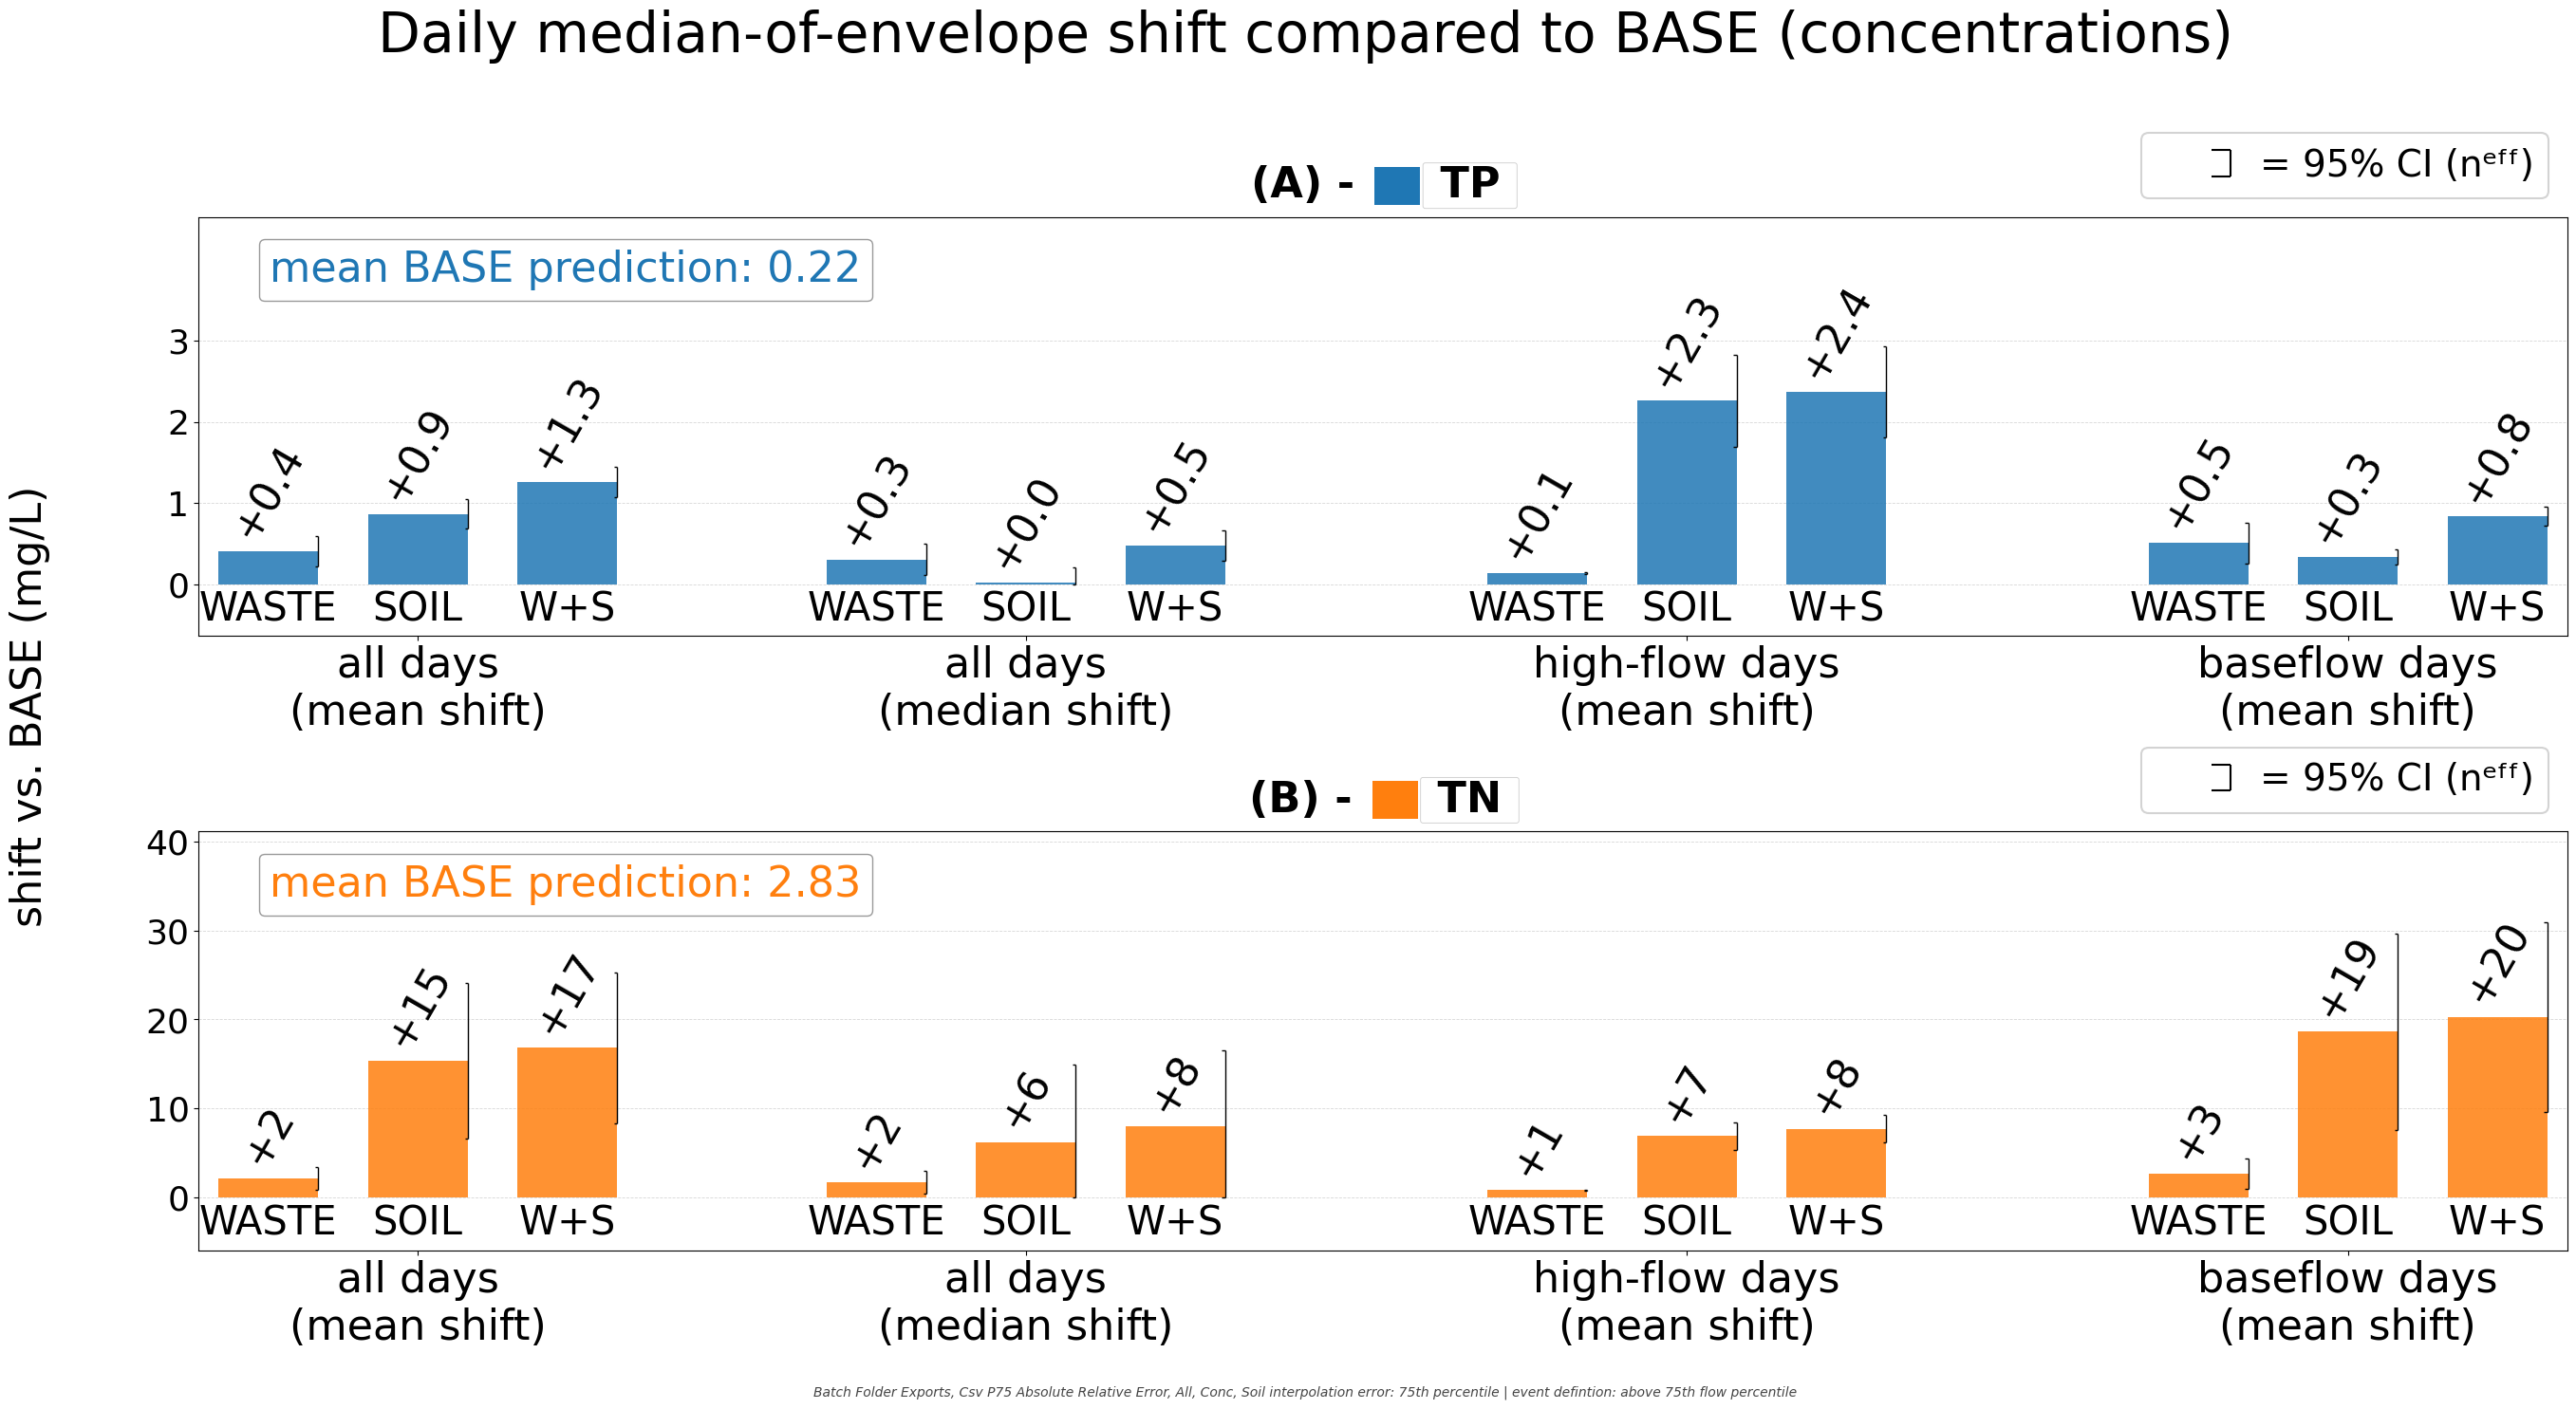


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Daily median-of-envelope shift compared to BASE (concentrations)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,Cohen’s d,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi","CI₉₅(g,n) hi",CI₉₅(nᵉᶠᶠ) lo,...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-0.21,,-0.49,+0.07,,-0.725,...,51,1048,14234,14234,-0.459,-52.9%,0.409,0.867,0.698,3.02
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-0.39,,-0.67,-0.11,,-1.12,...,51,978,14234,14234,-0.849,-67.5%,0.409,1.26,0.698,2.98
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-0.13,,-0.22,-0.04,,-0.652,...,1048,978,14234,14234,-0.39,-31.0%,0.867,1.26,3.02,2.98
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-0.59,,-1.05,-0.13,,-22.3,...,32,48,14234,14234,-13.3,-86.2%,2.13,15.4,3.72,31
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-0.69,,-1.15,-0.22,,-23.5,...,32,46,14234,14234,-14.7,-87.3%,2.13,16.8,3.72,29.6
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-0.05,,-0.45,+0.36,,-13.8,...,48,46,14234,14234,-1.4,-8.3%,15.4,16.8,31,29.6
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-0.63,,-1.09,-0.17,,-3.08,...,51,32,14234,14234,-1.72,-80.8%,0.409,2.13,0.698,3.72
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-0.65,,-0.94,-0.36,,-23.5,...,1048,48,14234,14234,-14.5,-94.4%,0.867,15.4,3.02,31
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.73,,-1.03,-0.43,,-24.3,...,978,46,14234,14234,-15.5,-92.5%,1.26,16.8,2.98,29.6
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),0.58,0.59,+0.28,+0.88,+0.60,+0.213,...,51,,14234,,+0.409,,0.409,0,0.698,


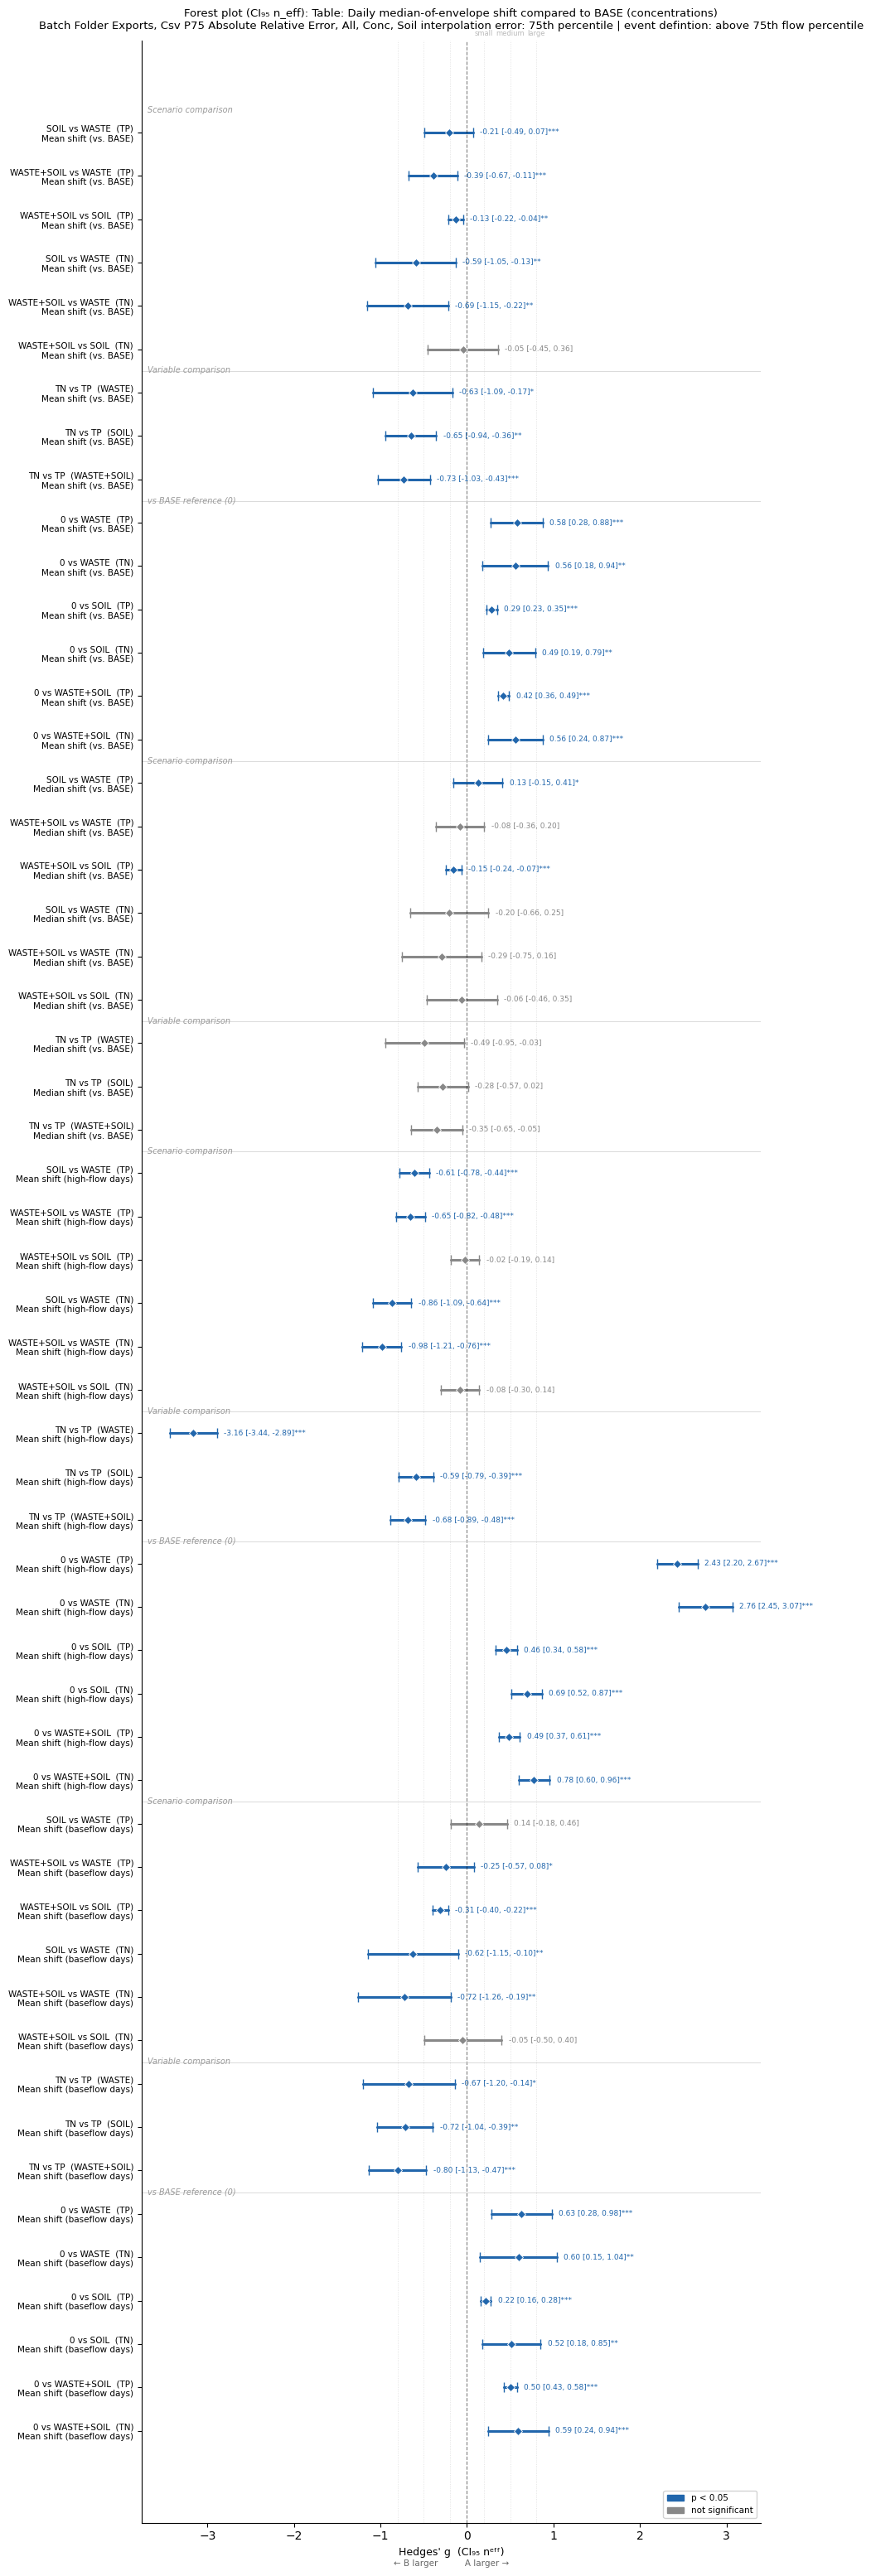


----------------------------------------------------------------------------------------
Chart 2: Load graphs
----------------------------------------------------------------------------------------


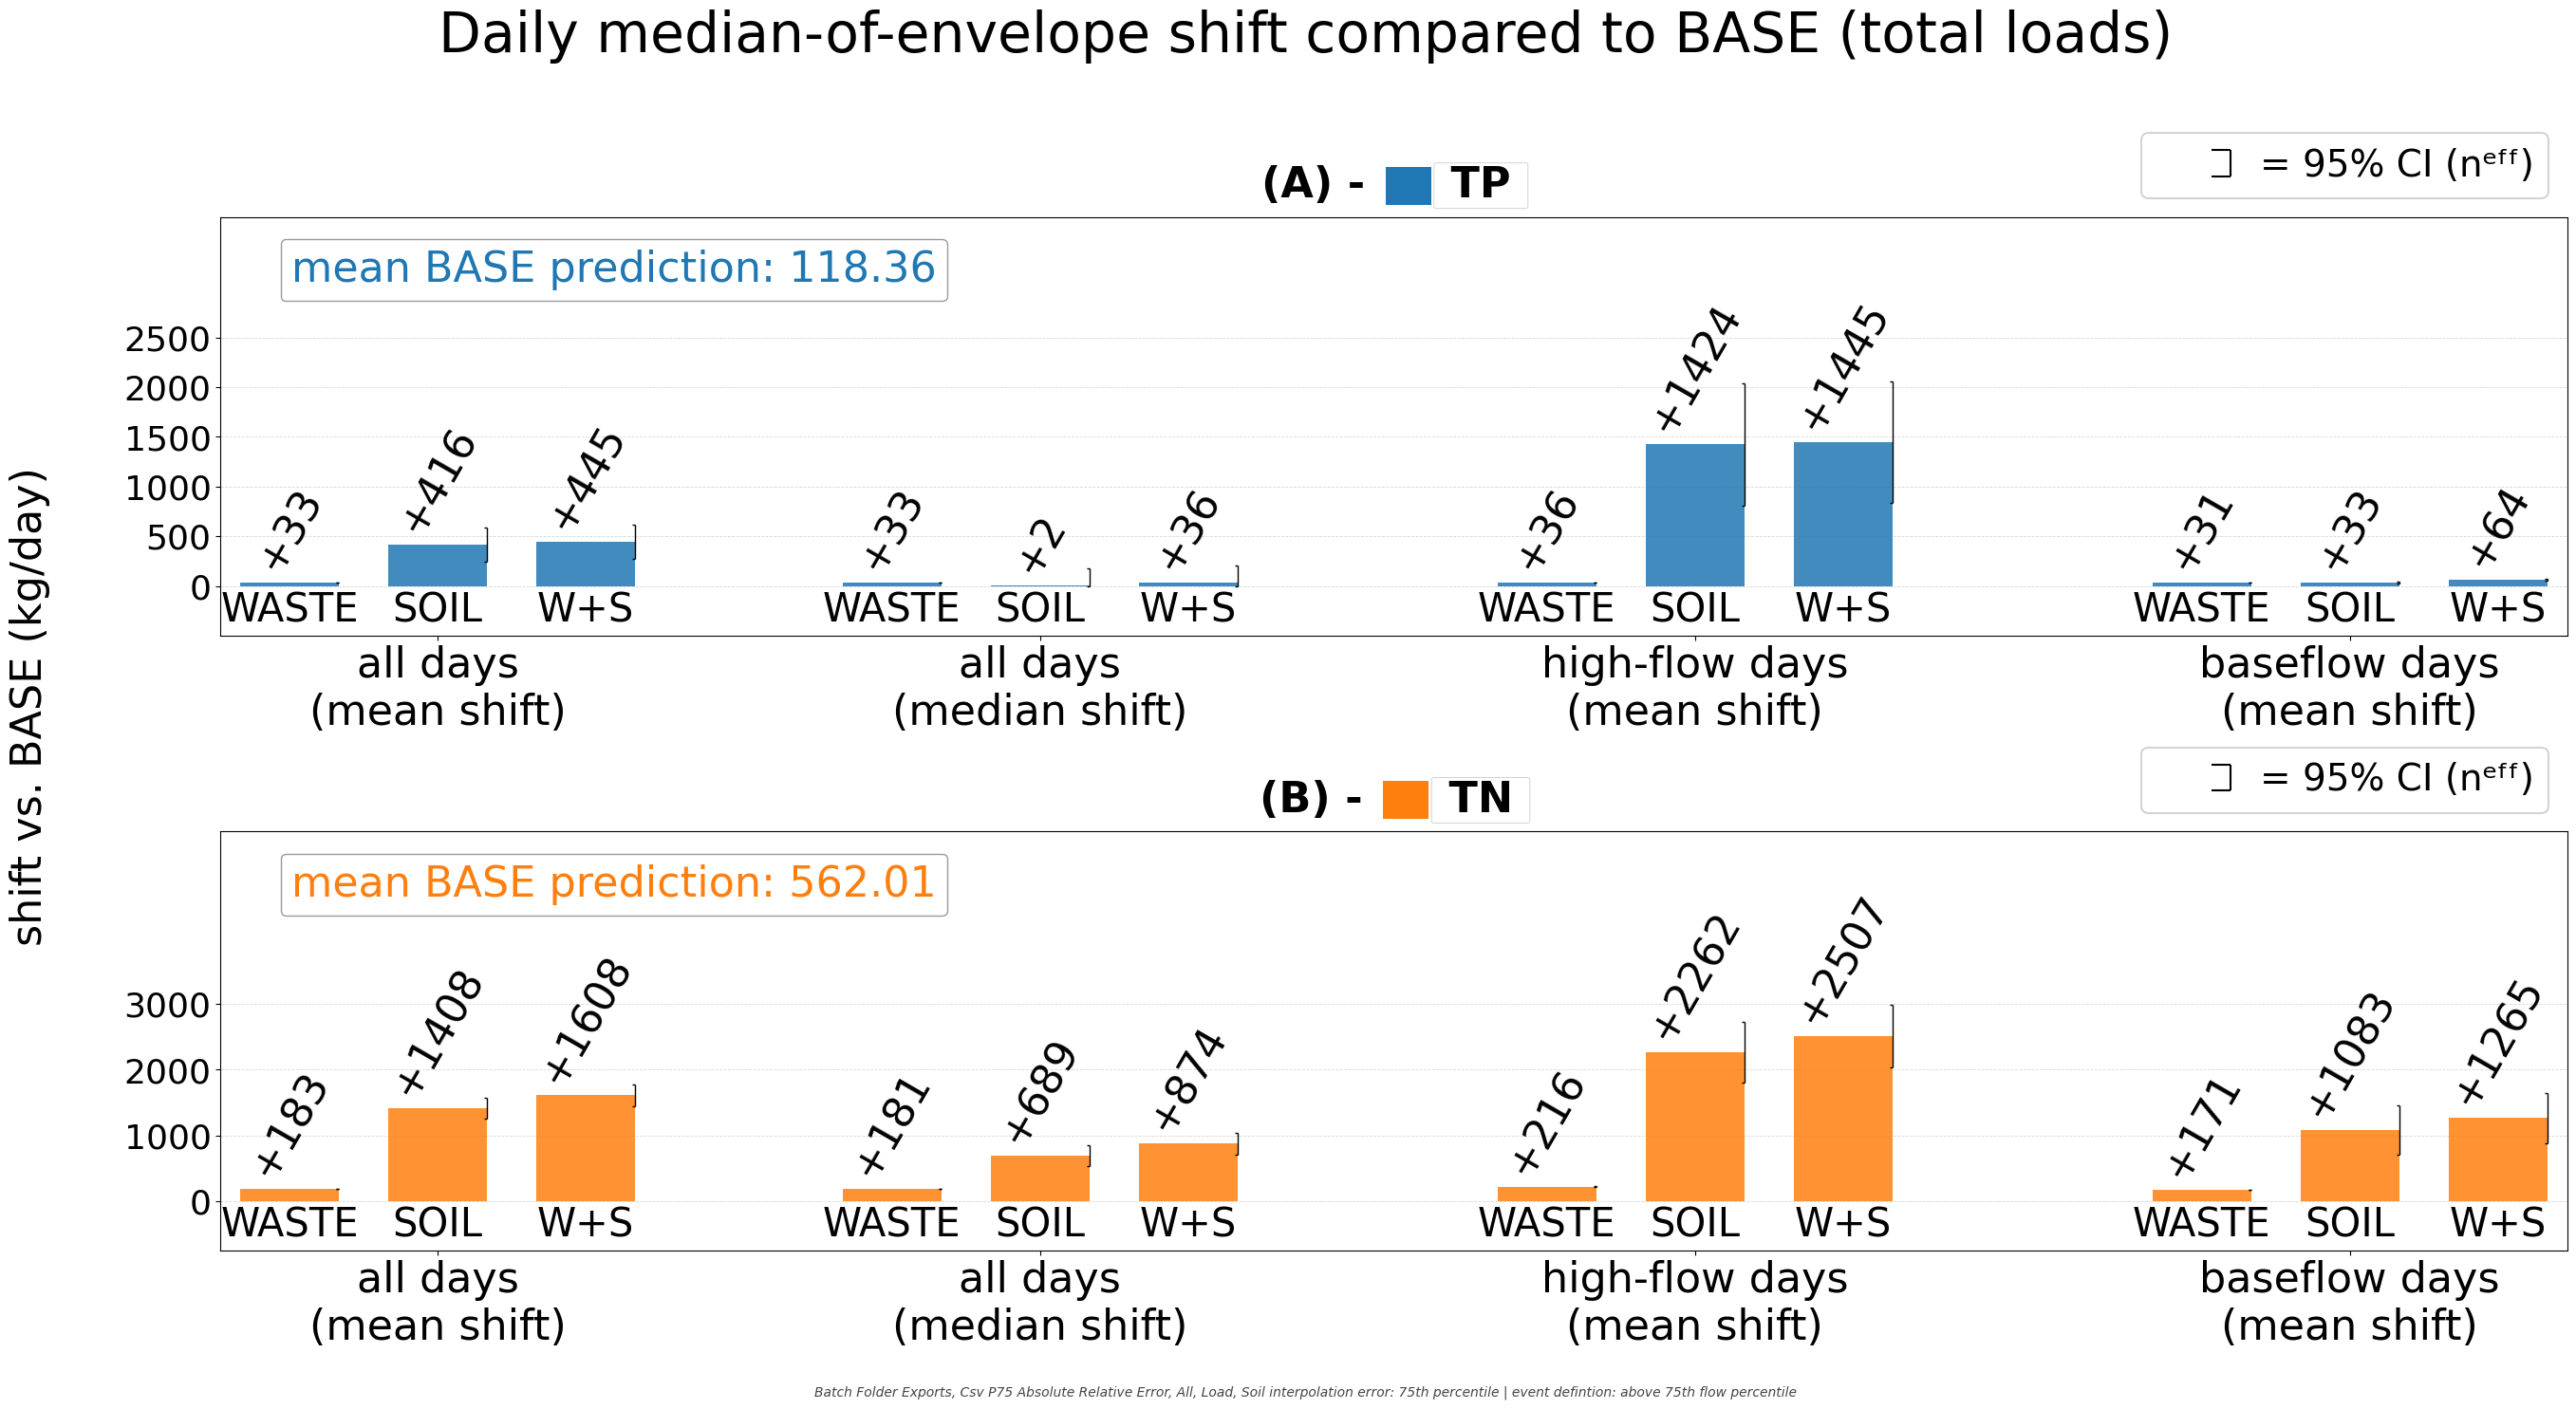


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Daily median-of-envelope shift compared to BASE (total loads)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,Cohen’s d,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi","CI₉₅(g,n) hi",CI₉₅(nᵉᶠᶠ) lo,...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-0.14,,-0.20,-0.07,,-558,...,1518,1955,14245,14245,-383,-92.2%,32.6,416,4.51,3.94e+03
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-0.15,,-0.22,-0.08,,-586,...,1518,1953,14245,14245,-412,-92.7%,32.6,445,4.51,3.9e+03
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-0.01,,-0.07,+0.06,,-275,...,1955,1953,14245,14245,-29.3,-6.6%,416,445,3.94e+03,3.9e+03
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-0.58,,-0.65,-0.50,,-1.39e+03,...,1311,1328,14245,14245,-1.22e+03,-87.0%,183,1.41e+03,55.8,3e+03
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-0.65,,-0.73,-0.57,,-1.59e+03,...,1311,1338,14245,14245,-1.42e+03,-88.6%,183,1.61e+03,55.8,3.1e+03
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-0.07,,-0.14,+0.01,,-432,...,1328,1338,14245,14245,-200,-12.5%,1.41e+03,1.61e+03,3e+03,3.1e+03
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-3.81,,-3.93,-3.68,,-154,...,1518,1311,14245,14245,-151,-82.2%,32.6,183,4.51,55.8
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-0.28,,-0.35,-0.21,,-1.23e+03,...,1955,1328,14245,14245,-992,-70.5%,416,1.41e+03,3.94e+03,3e+03
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.33,,-0.40,-0.26,,-1.4e+03,...,1953,1338,14245,14245,-1.16e+03,-72.3%,445,1.61e+03,3.9e+03,3.1e+03
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),7.21,7.22,+6.95,+7.48,+7.30,+32.3,...,1518,,14245,,+32.6,,32.6,0,4.51,


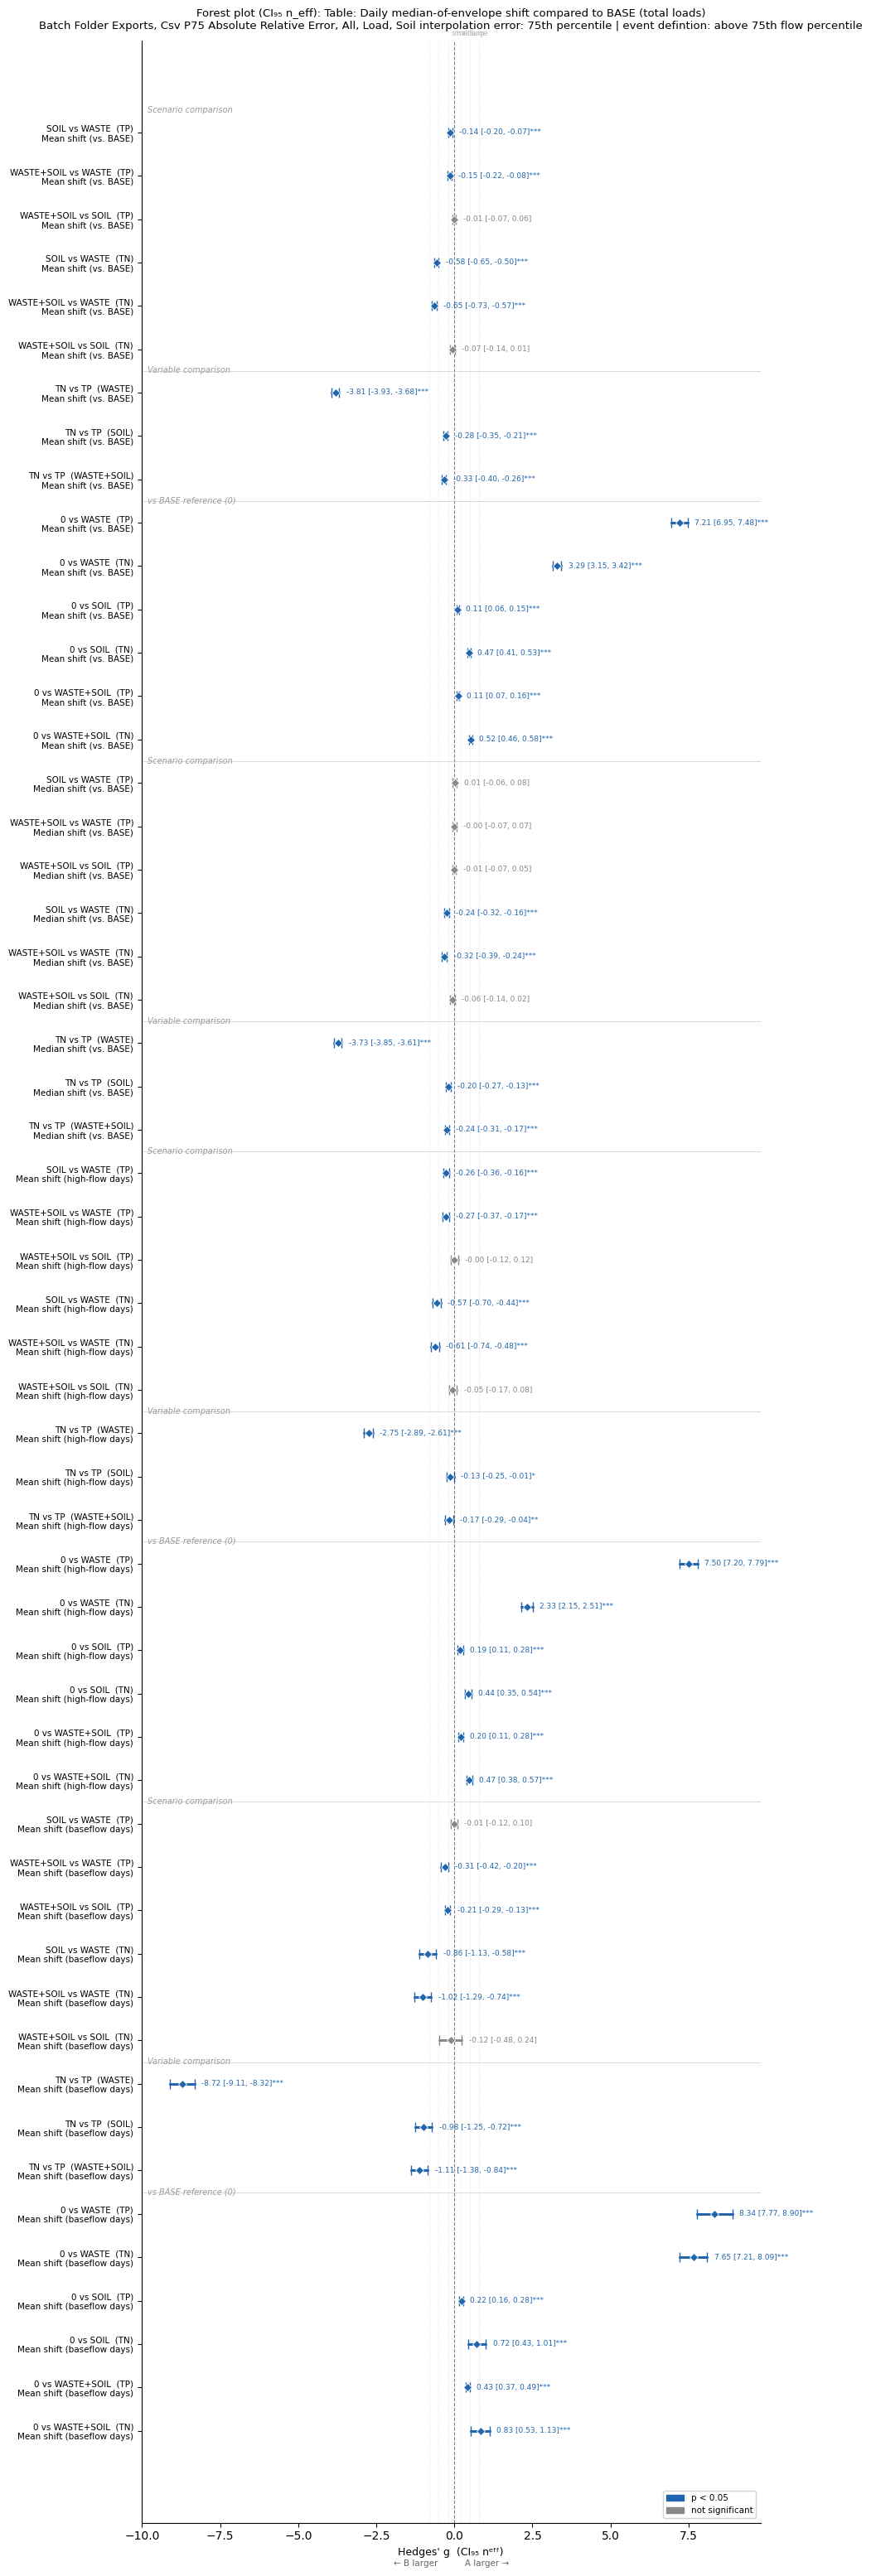


Finished chart 2 for all configured folders.
Chart 2 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  compare_mode: conc
  info box overlay stat: mean
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\batch_folder_exports\csv_p75_absolute_relative_error\half_mdl\all\conc\runs_188_200_201__vars_tot_nkg_tot_pkg
run-188: export_variable=tot-nkg scenario=SOIL, variable=TN
run-188: export_variable=tot-pkg scenario=SOIL, variable=TP
run-200: export_variable=tot-nkg scenario=WASTE, variable=TN
run-200: export_variable=tot-pkg scenario=WASTE, variable=TP
run-201: export_variable=tot-nkg scenario=WASTE+SOIL, variable=TN
run-201: export_variable=tot-pkg scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203, 204, 205]

Built 6 export s

In [18]:
chart_2_metrics_by_folder = {}

chart_2_logs = []


# "-- Info-box configuration (external BASE overlay metric shown per variable) "--
ch2_info_box_overlay_stat = "mean"                            # switch to "mean" to display the external BASE mean
_ch2_info_box_metric_options = {
    "median": {
        "metric_name": "overlay_p50",
        "label": "median BASE prediction",
    },
    "mean": {
        "metric_name": "overlay_mean",
        "label": "mean BASE prediction",
    },
}
ch2_info_box_overlay_stat = str(ch2_info_box_overlay_stat).strip().lower()
if ch2_info_box_overlay_stat not in _ch2_info_box_metric_options:
    raise ValueError(
        f"Unsupported ch2_info_box_overlay_stat={ch2_info_box_overlay_stat!r}. "
        f"Choose one of: {sorted(_ch2_info_box_metric_options)}"
    )
_ch2_info_box_metric_cfg = _ch2_info_box_metric_options[ch2_info_box_overlay_stat]
ch2_info_box_prefix = f"{_ch2_info_box_metric_cfg['label']}:"   # text before the numeric value
ch2_info_box_metric_name = _ch2_info_box_metric_cfg["metric_name"]
ch2_info_box_x = 0.025                                           # horizontal position (0-1 in axes coords)
ch2_info_box_y = 0.95                                            # vertical position (0-1 in axes coords)
ch2_info_box_metric_path = ("overlay_comparison", "BASE", ch2_info_box_metric_name)



_last_ch2_compare_mode = None
for batch_folder in _ch12_batch_folders:
    _ch2_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch2_compare_mode != _last_ch2_compare_mode:
        _print_graph_group_separator(_ch2_compare_mode, chart_label='Chart 2')
        _last_ch2_compare_mode = _ch2_compare_mode

    generated_specs, build_log = _capture_stdout(

        build_export_specs_from_folder,

        batch_folder,

        run_to_scenario,

        variable_map,

        verbose=True,

    )



    _ch2_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))

    _ch2_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))

    _ch2_selected_scenarios = _ordered_present_values(_ch2_actual_scenarios, chart_scenario_order)

    _ch2_selected_variables = _ordered_present_values(_ch2_actual_variables, chart_variable_order)



    ch_2_auto_metrics = build_metrics_dict_from_stat_exports(

        generated_specs,

        ch2_semantic_labels,

        semantic_label_map=example_semantic_label_map,

        scenario_order=_ch2_selected_scenarios,

        variable_order=_ch2_selected_variables,

        format_mode="metadata",

        verbose=False,

    )

    # Extract the selected external BASE overlay summary for the info box (first JSON per variable)
    _ch2_overlay_reference_value = {}
    for _spec in generated_specs:
        _loaded = _load_stat_export(_spec, verbose=False)
        _var = _loaded["variable"]
        if _var not in _ch2_overlay_reference_value:
            _val = _extract_metric_value(
                _loaded["stats"], ch2_info_box_metric_name,
                explicit_path=ch2_info_box_metric_path,
                verbose=False,
            )
            _ch2_overlay_reference_value[_var] = _val
    _ch2_var_colors = {"TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c", "TON": "#d62728", "PP": "#9467bd"}
    _ch2_info_box_lines = [
        (f"{var}: {ch2_info_box_prefix} {_ch2_overlay_reference_value[var]:.2f}", _ch2_var_colors.get(var, "black"))
        for var in _ch2_selected_variables
        if var in _ch2_overlay_reference_value
    ]



    _ch2_example_export = _load_stat_export(generated_specs[0], verbose=False)

    _ch2_dashboard_state = (

        _ch2_example_export["payload"].get("metadata", {}).get("dashboard_state")

        or _ch2_example_export["payload"].get("dashboard_state")

        or {}

    )

    _ch2_compare_mode = str(_ch2_dashboard_state.get("compare_mode") or "load").strip().lower()

    if _ch2_compare_mode == "conc":

        ch_2_chart_descriptor = "Daily median-of-envelope shift compared to BASE (concentrations)"
        ch_2_y_label = "shift vs. BASE (mg/L)"

        def _ch2_annotation_formatter(value, stat, scenario, variable, default_text):
            if variable == "TP":
                return f"{value:+.1f}"
            return default_text

    else:

        ch_2_chart_descriptor = "Daily median-of-envelope shift compared to BASE (total loads)"
        ch_2_y_label = "shift vs. BASE (kg/day)"
        _ch2_annotation_formatter = None



    ch_2_title_metadata_parts = [

    "folder_label",           # represents interpolation error and MDL handling policy

    #"view",                   # represents event vs non-event vs all days

    "event_threshold",        # defines event definition (e.g. P75, abs)

    #"measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")

    #"n",                      # number of measurements considere by above filter and mapping

    #"reach",                  # represents the reach being analysed (e.g. 13)

    #"measured_nonnum_policy", 

    ]



    ch_2_title_folder_label_map = {

        # exact-match shorthand  (token: label)

        "runs_187_200_202":      "Soil interpolation error: relative median",

        "runs_205_200_204":      "Soil interpolation error: absolute median",

        "runs_189_200_203":      "Soil interpolation error: relative RMSE",

        "runs_188_200_201":      "Soil interpolation error: 75th percentile",

        "runs_153_155_157":      "Original TFM (relative RMSE)",

        "drop_mdl":              None, #"drop-below-DL",

        "half_mdl":              None, #"half-DL",

    }





    EVENT_THRESHOLD_TITLE_ALIASES = {

    "p50": "event defintion: above 50th flow percentile",

    "p75": "event defintion: above 75th flow percentile",

    "p90": "event defintion: above 90th flow percentile",

    "abs": "event defintion: above absolute flow value",

    }       



    chart_title, chart_subtitle = build_semantic_chart_title(

        batch_folder, generated_specs,

        ch_2_chart_descriptor,

        title_metadata_parts=ch_2_title_metadata_parts,

        title_folder_label_map=ch_2_title_folder_label_map,

    )




    _ch2_error_data = build_error_data_from_extended_stats(
        generated_specs, ch2_semantic_labels,
        error_mode="ci95_neff" if USE_NEFF_CI else "ci95",
    )

    fig, ax = plot_nested_sensitivity_bars(

        ch_2_auto_metrics,

        title=chart_title,

        subtitle=chart_subtitle,

        small_value_threshold = 0.1,
        small_value_decimals = 2,

        variables_order=_ch2_selected_variables,

        scenarios_order=_ch2_selected_scenarios,

        abbreviations=chart_abbreviations,

        y_label=ch_2_y_label,

        figsize=(20, 8),

        stats_order=ch2_semantic_labels,
        stat_label_map={
            "Mean shift (vs. BASE)":  "all days\n(mean shift)",
            "Median shift (vs. BASE)": "all days\n(median shift)",
            "Mean shift (high-flow days)":      "high-flow days\n(mean shift)",
            "Mean shift (baseflow days)":  "baseflow days\n(mean shift)",
        },

        annotate_rotation=60,

        scenario_label_rotation=0,

        #tick_fs=24,

        annot_fs=32,
        x_tick_fs=32,
        y_tick_fs=26,
        label_fs=32,
        title_fs=42,
        subtitle_fs=10,
        legend_fs=32,
        scenario_fs=30,

        scenario_spacing=0.06,
        legend_outside=False,
        legend_loc="upper right",
        legend_bbox=(0.98, 0.98),
        tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
        top_margin_px=10, # pixels above highest annotation/whisker AND below lowest annotation/whisker (whichever is greater)
        bottom_margin_px=5, # pixels below lowest scenario label
        inside_legend_top_margin_scale=0.82,
        edge_bar_padding=0.70,
        subtitle_y=-0.0075,
        bottom_margin_for_labels=0.14,
        label_offset_scale=0.03,
        label_separation_scale=0.08,
        label_x_nudge_scale=0.09,
        scenario_label_y_scale=0.02,
        y_stretch = 1.8,                    # vertical stretch factor: >1 makes chart taller, amplifying bar differences
        error_bar_legend_fs=28, # None -> uses 0.75 * legend_fs in split-panel mode
        error_bar_legend_label = ("= 95% CI (n\u1d49\u1da0\u1da0)" if USE_NEFF_CI else "= 95% CI (n)"),


        


        annotation_formatter=_ch2_annotation_formatter,

        info_box_lines=_ch2_info_box_lines,
        info_box_x=ch2_info_box_x,
        info_box_y=ch2_info_box_y,
        info_box_top_margin_px=20,  # px margin between top of info box and top of plot area
        split_variable_panels=chart_split_variable_panels,
        split_panel_figsize=chart_split_panel_figsize,
        split_panel_wspace=chart_split_panel_wspace,
        split_panel_suptitle_y=chart_split_panel_suptitle_y,
        split_panel_suptitle_fs=chart_split_panel_suptitle_fs,
        split_panel_variable_title=chart_split_panel_variable_title,
        split_panel_variable_title_fs=chart_split_panel_variable_title_fs,
        split_panel_variable_title_bg=chart_split_panel_variable_title_bg,
        split_panel_variable_title_pad=chart_split_panel_variable_title_pad,
        split_panel_left_y_label_only=chart_split_panel_left_y_label_only,
        split_panel_legend_panel=chart_split_panel_legend_panel,
        split_panel_legend_side=chart_split_panel_legend_side,
        split_panel_tight_rect=chart_split_panel_tight_rect,
        split_panel_stack_vertical=chart_split_panel_stack_vertical,
        error_data=_ch2_error_data,
        
    )

    plt.show()


    # "-- Significance table for Chart 2 "--
    display_chart_significance_tables(
        ch_2_auto_metrics,
        generated_specs,
        chart_title=f"Table: {chart_title}",
        chart_subtitle=chart_subtitle,
        comparison_modes=("scenarios", "variables"),
        scenarios=_ch2_selected_scenarios,
        variables=_ch2_selected_variables,
        metric_labels=ch2_semantic_labels,
        forest_plot=True,
    )


    saved_path, save_log = _capture_stdout(

        _save_chart_figure,

        fig,

        batch_folder.name,

        "chart_2_shift",

        save_enabled=save_individual_chart_images,

        output_root=saved_chart_root,

        dpi=saved_chart_dpi,

    )

    plt.close(fig)



    chart_2_metrics_by_folder[str(batch_folder)] = ch_2_auto_metrics

    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_2_metrics"] = ch_2_auto_metrics

    chart_results_by_folder[batch_folder.name]["chart_2_saved_path"] = saved_path



    chart_2_logs.append(f"Chart 2 folder: {batch_folder.name}")

    chart_2_logs.append(f"  compare_mode: {_ch2_compare_mode}")

    chart_2_logs.append(f"  info box overlay stat: {ch2_info_box_overlay_stat}")

    chart_2_logs.append(f"  scenarios: {_ch2_selected_scenarios}")

    chart_2_logs.append(f"  variables: {_ch2_selected_variables}")

    if build_log.strip():

        chart_2_logs.append(build_log.rstrip())

    if save_log.strip():

        chart_2_logs.append(save_log.rstrip())

    chart_2_logs.append("")



print("\nFinished chart 2 for all configured folders.")

print("\n".join(line for line in chart_2_logs if line is not None))


----------------------------------------------------------------------------------------
Chart 3: Concentration graphs
----------------------------------------------------------------------------------------


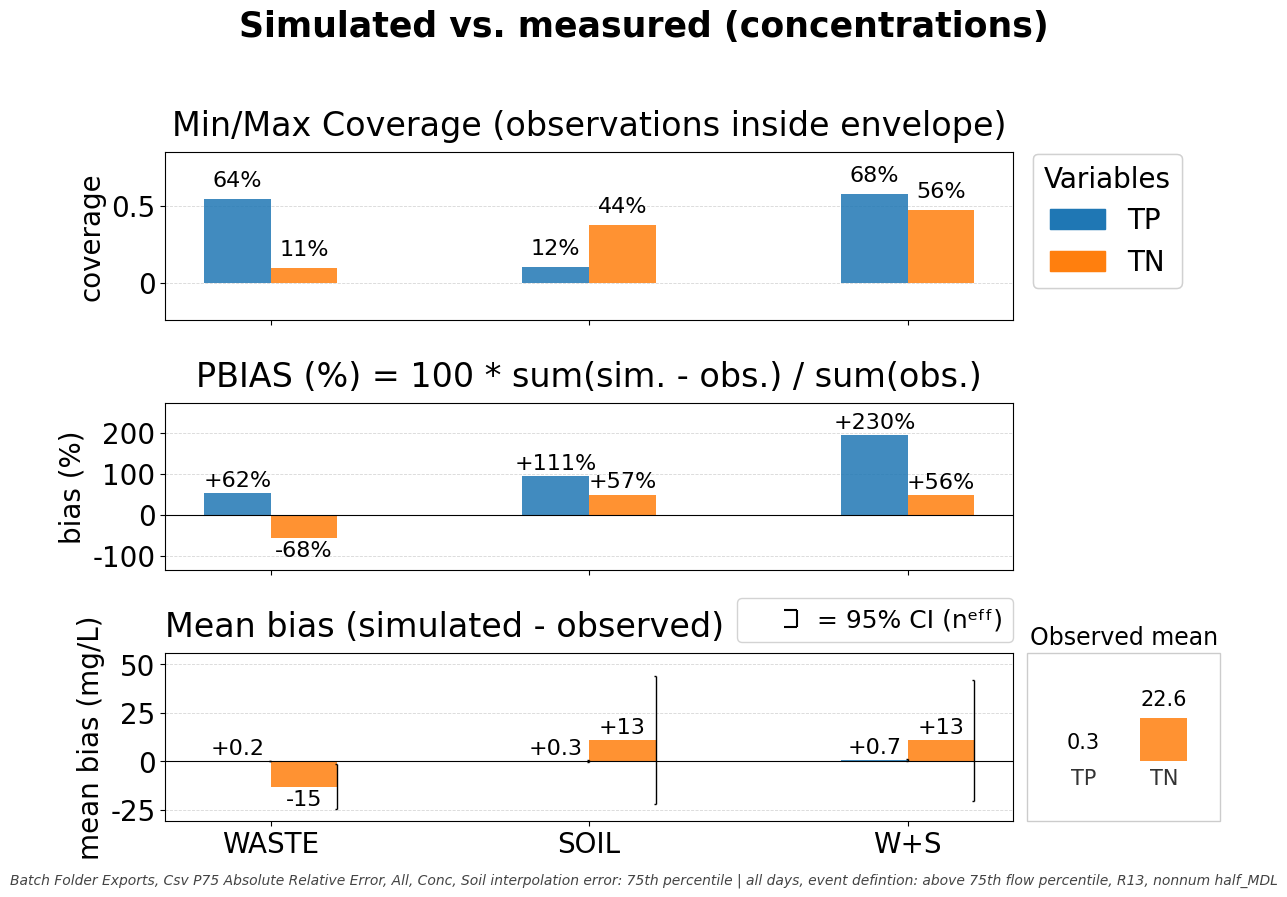


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (concentrations)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,Cohen’s d,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi","CI₉₅(g,n) lo","CI₉₅(g,n) hi",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.52,+433.3%,0.64,0.12,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.04,-5.9%,0.64,0.68,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.56,-82.4%,0.12,0.68,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-0.333,-75.0%,0.111,0.444,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.444,-80.0%,0.111,0.556,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.111,-20.0%,0.444,0.556,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.529,+476.0%,0.64,0.111,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-0.324,-73.0%,0.12,0.444,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,+0.124,+22.4%,0.68,0.556,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-48.4,-43.8%,62.1,111,,


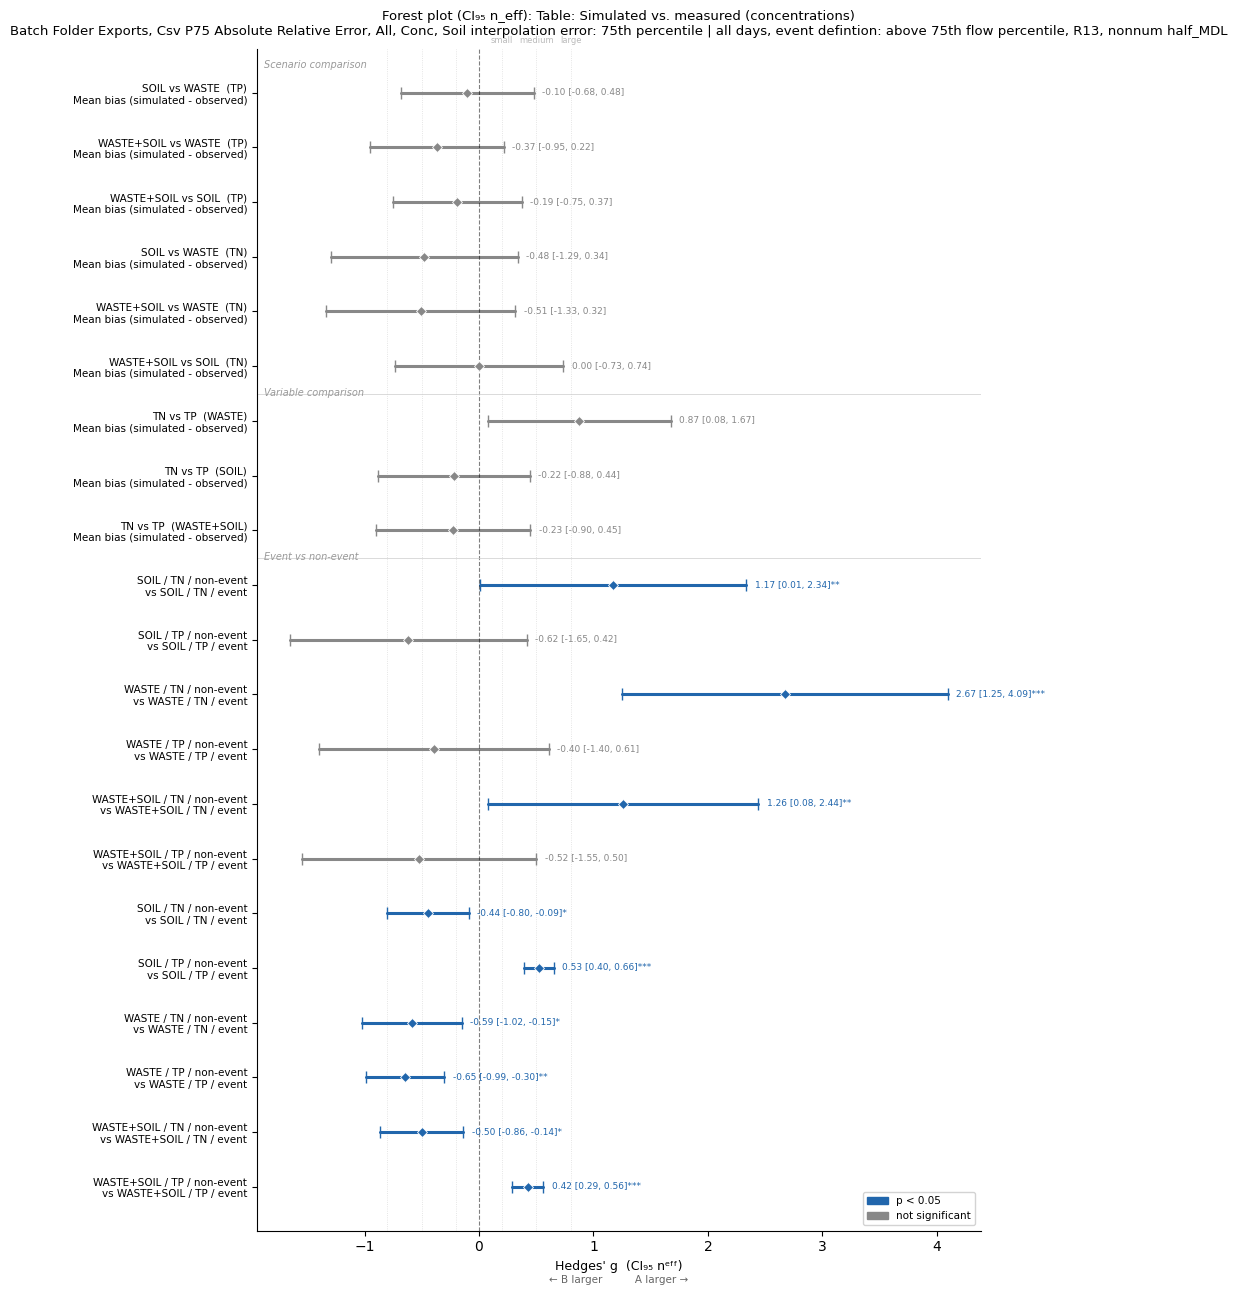

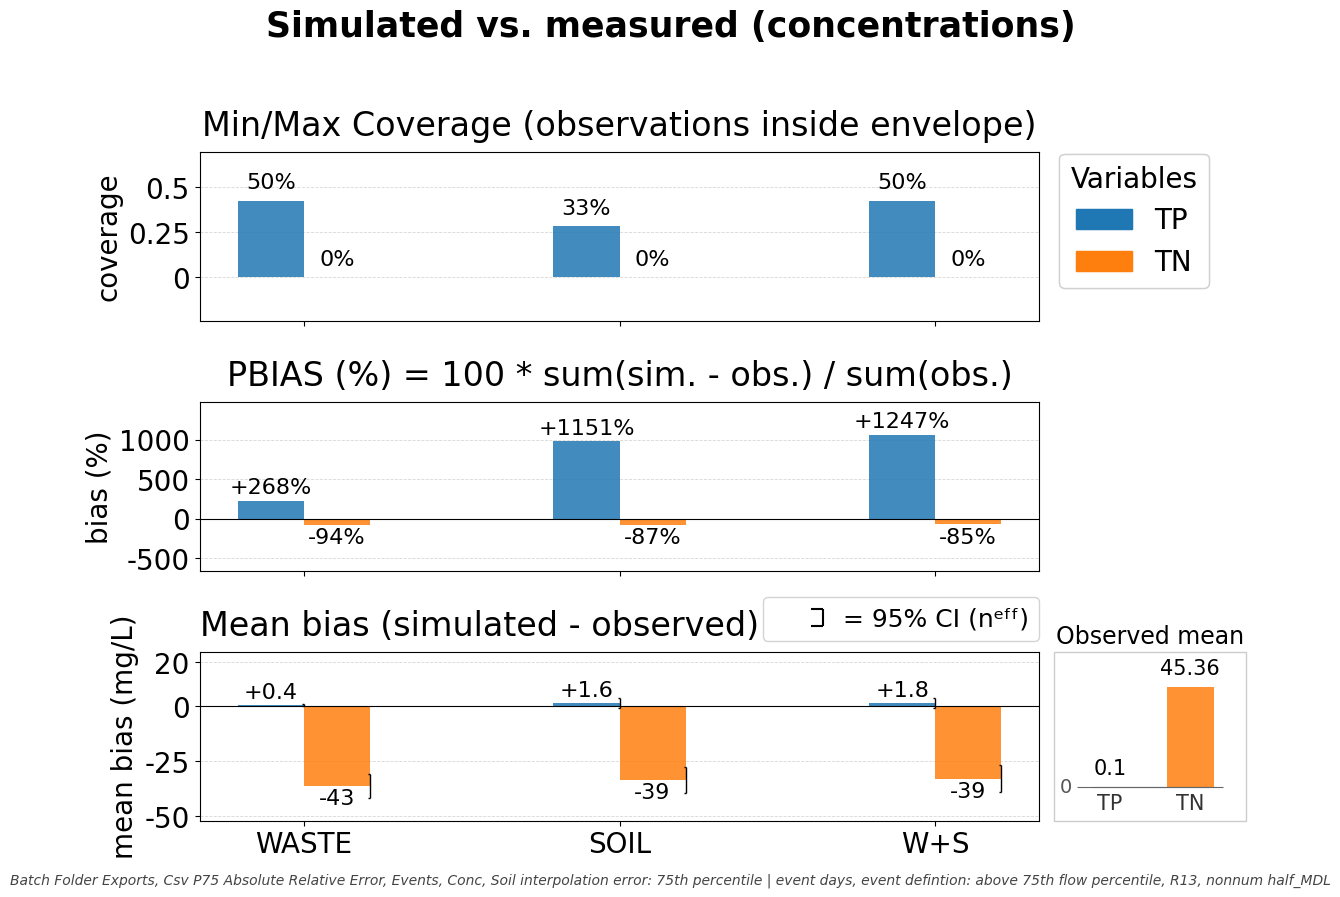


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (concentrations)
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Conc, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.167,+50.0%,0.5,0.333,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,+0,+0.0%,0.5,0.5,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.167,-33.3%,0.333,0.5,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.5,,0.5,0,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,+0.333,,0.333,0,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,+0.5,,0.5,0,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-884,-76.8%,268,1.15e+03,,


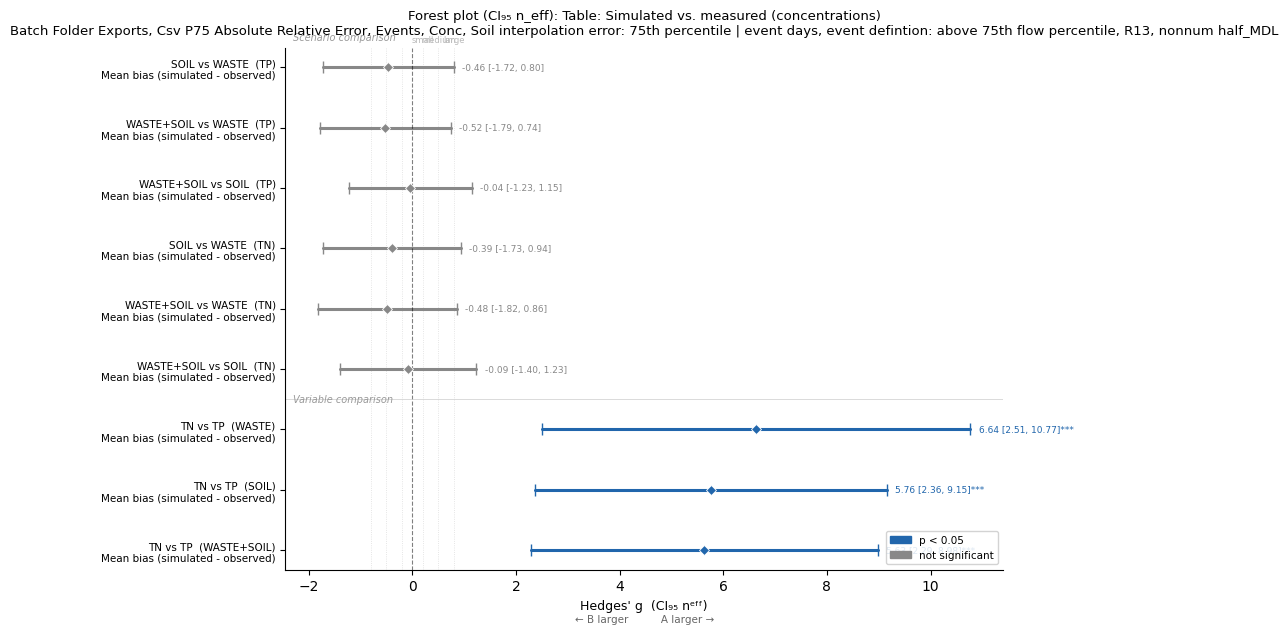

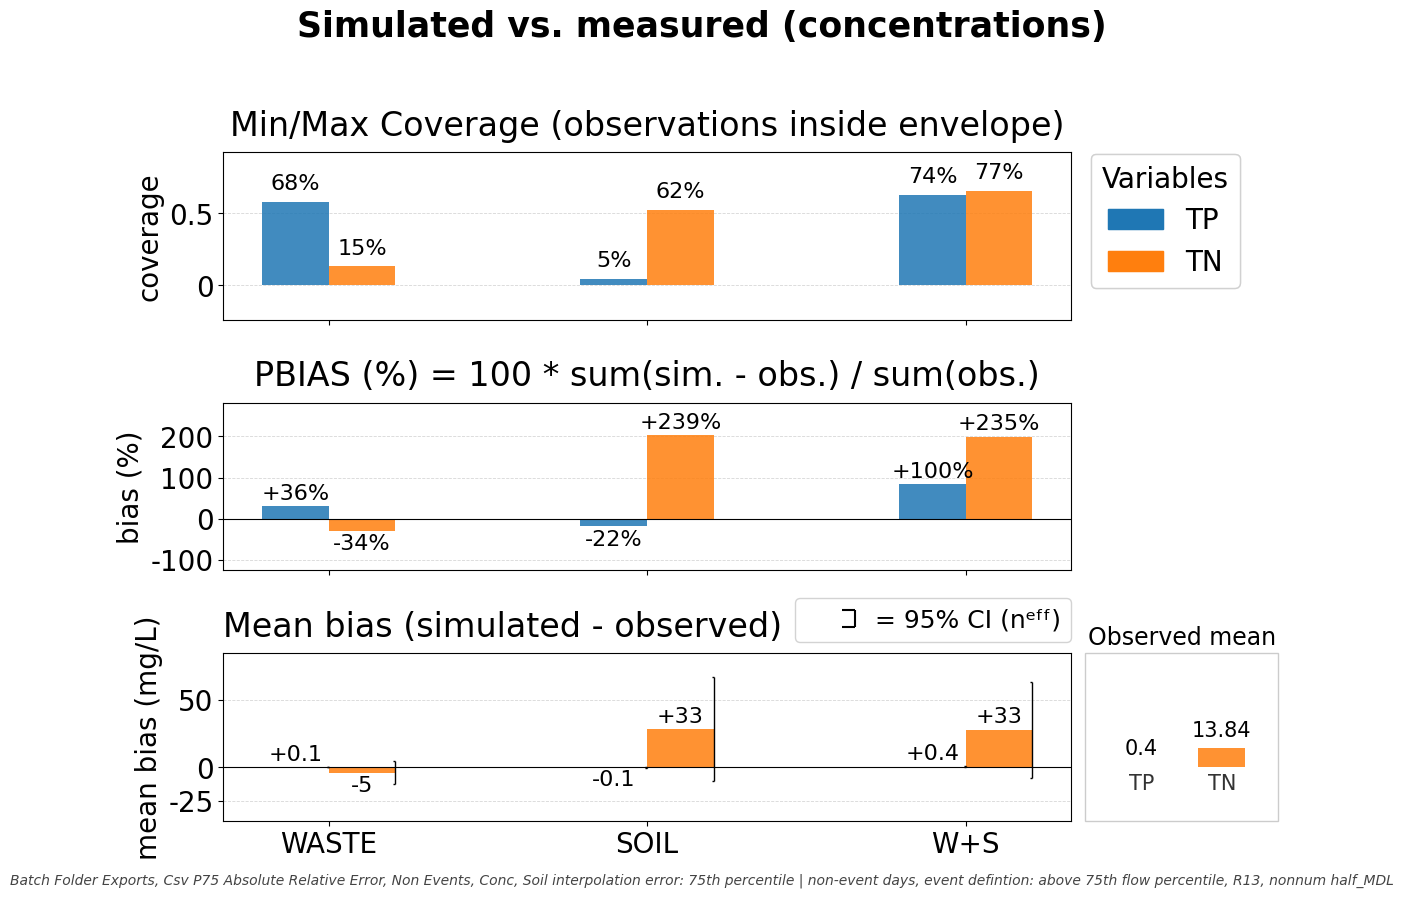


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (concentrations)
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Conc, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.632,+1200.0%,0.684,0.0526,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.0526,-7.1%,0.684,0.737,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.684,-92.9%,0.0526,0.737,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-0.462,-75.0%,0.154,0.615,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.615,-80.0%,0.154,0.769,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.154,-20.0%,0.615,0.769,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.53,+344.7%,0.684,0.154,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-0.563,-91.4%,0.0526,0.615,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,-0.0324,-4.2%,0.737,0.769,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+58.4,+259.8%,35.9,-22.5,,


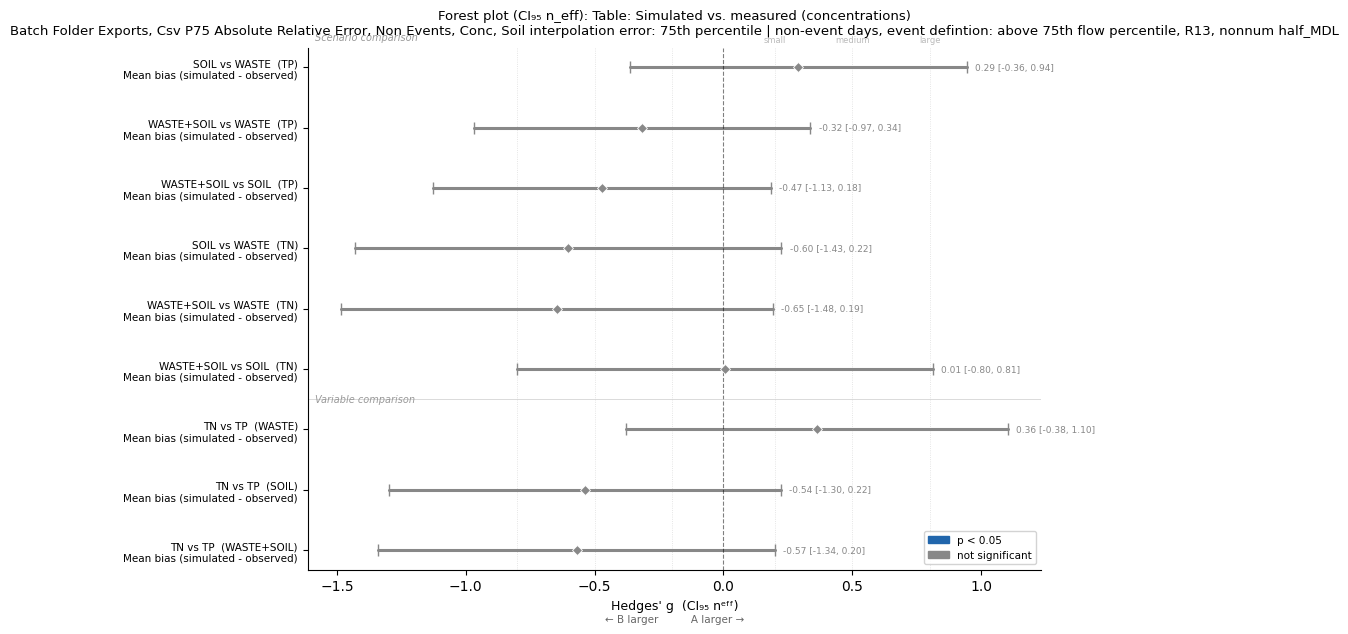


----------------------------------------------------------------------------------------
Chart 3: Load graphs
----------------------------------------------------------------------------------------


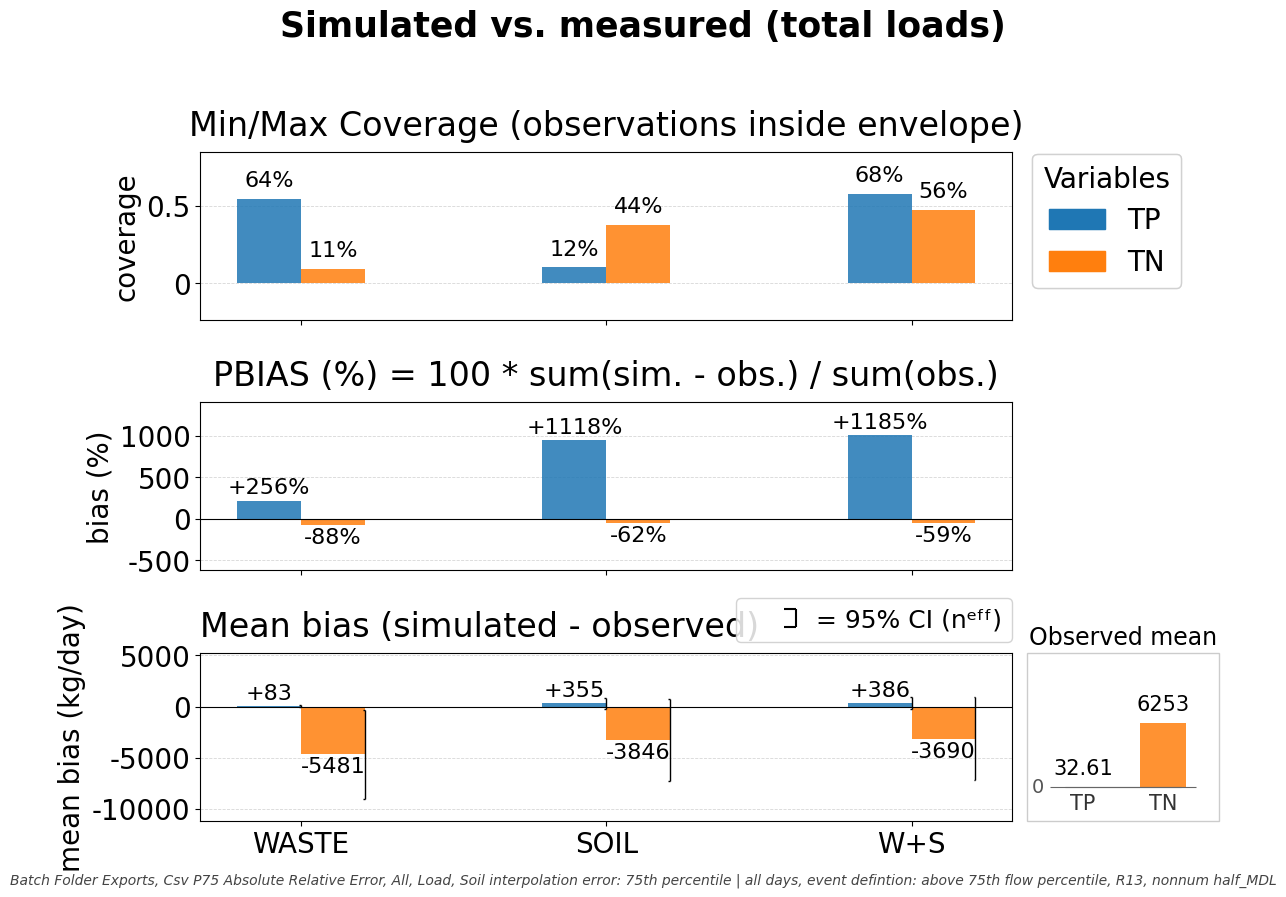


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (total loads)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,Cohen’s d,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi","CI₉₅(g,n) lo","CI₉₅(g,n) hi",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.52,+433.3%,0.64,0.12,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.04,-5.9%,0.64,0.68,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.56,-82.4%,0.12,0.68,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-0.333,-75.0%,0.111,0.444,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.444,-80.0%,0.111,0.556,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.111,-20.0%,0.444,0.556,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.529,+476.0%,0.64,0.111,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-0.324,-73.0%,0.12,0.444,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,+0.124,+22.4%,0.68,0.556,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-862,-77.1%,256,1.12e+03,,


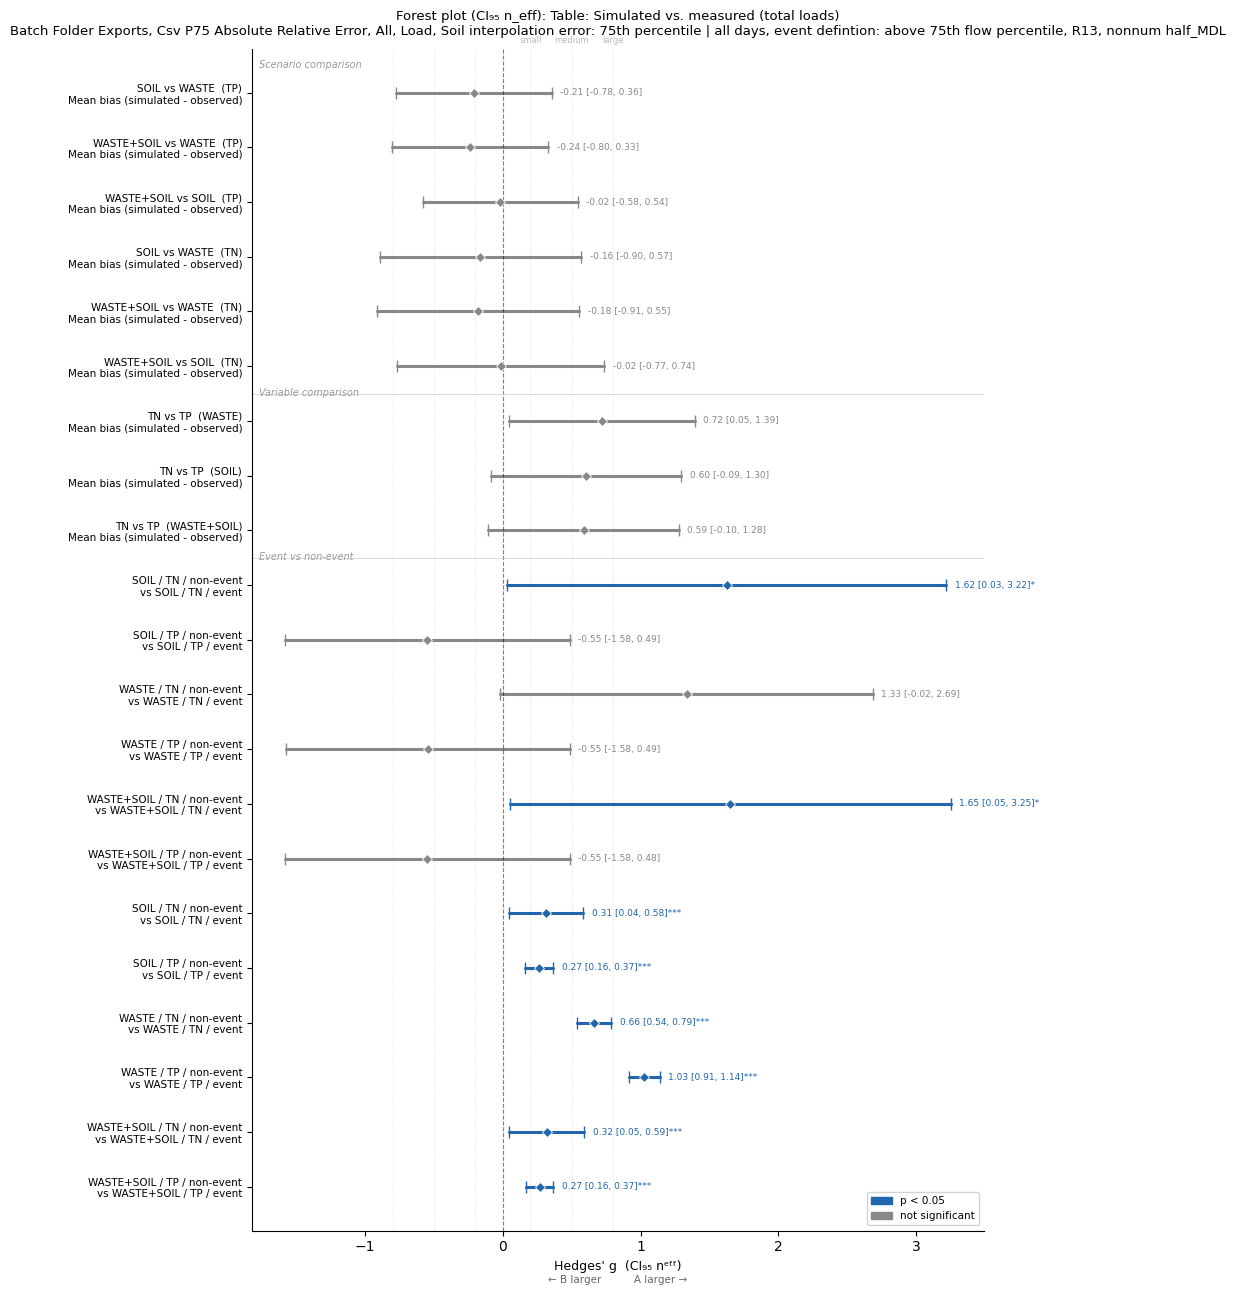

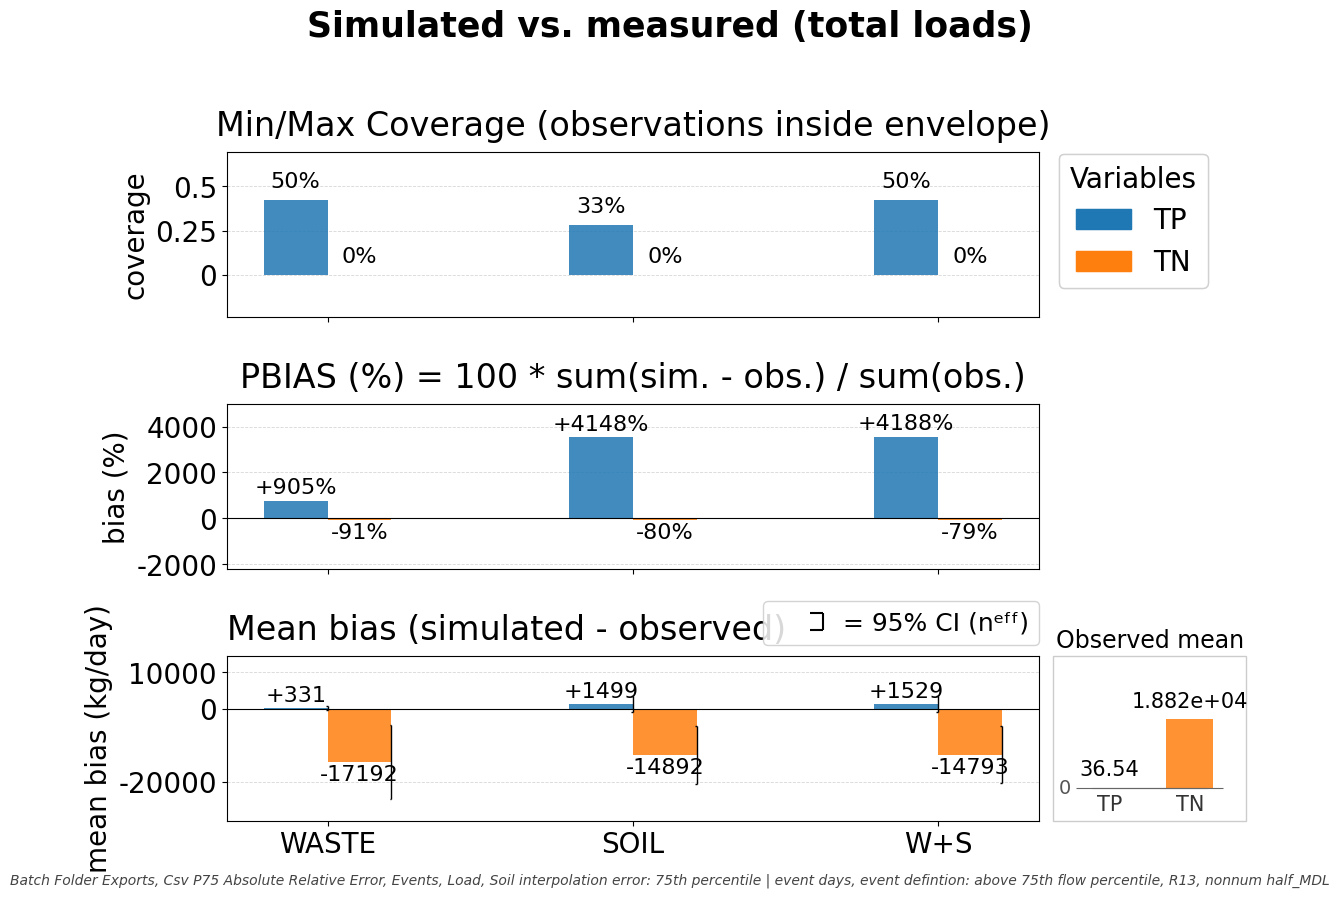


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (total loads)
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Load, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.167,+50.0%,0.5,0.333,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,+0,+0.0%,0.5,0.5,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.167,-33.3%,0.333,0.5,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,+0,,0,0,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.5,,0.5,0,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,+0.333,,0.333,0,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,+0.5,,0.5,0,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,-3.24e+03,-78.2%,905,4.15e+03,,


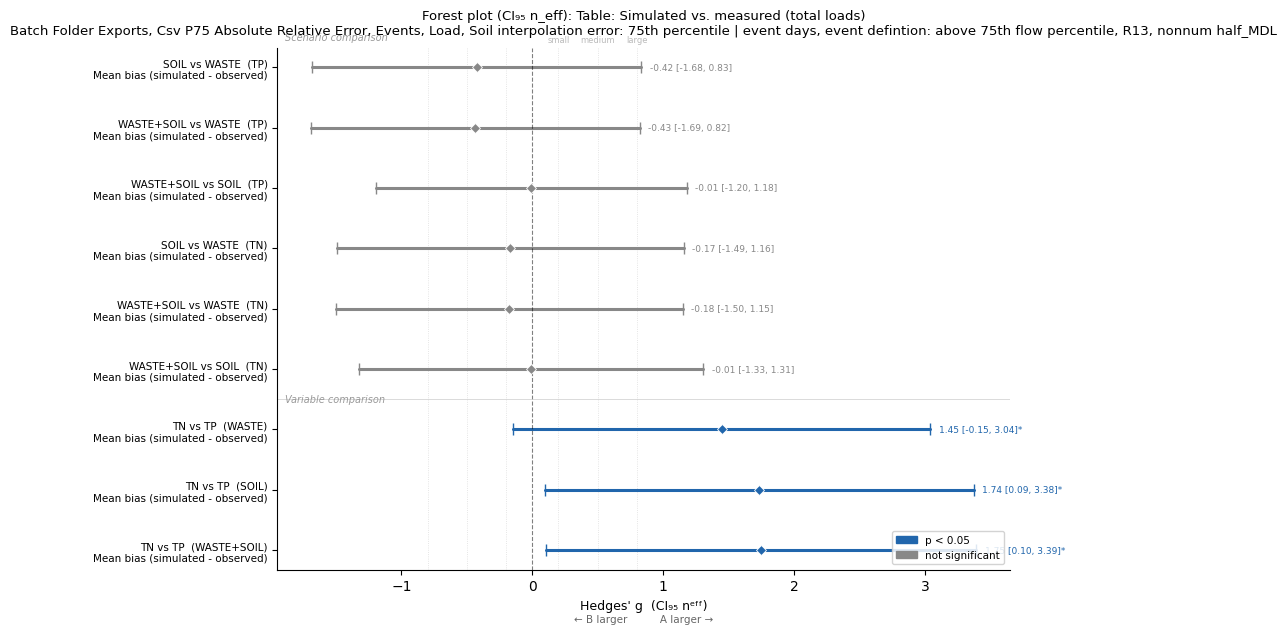

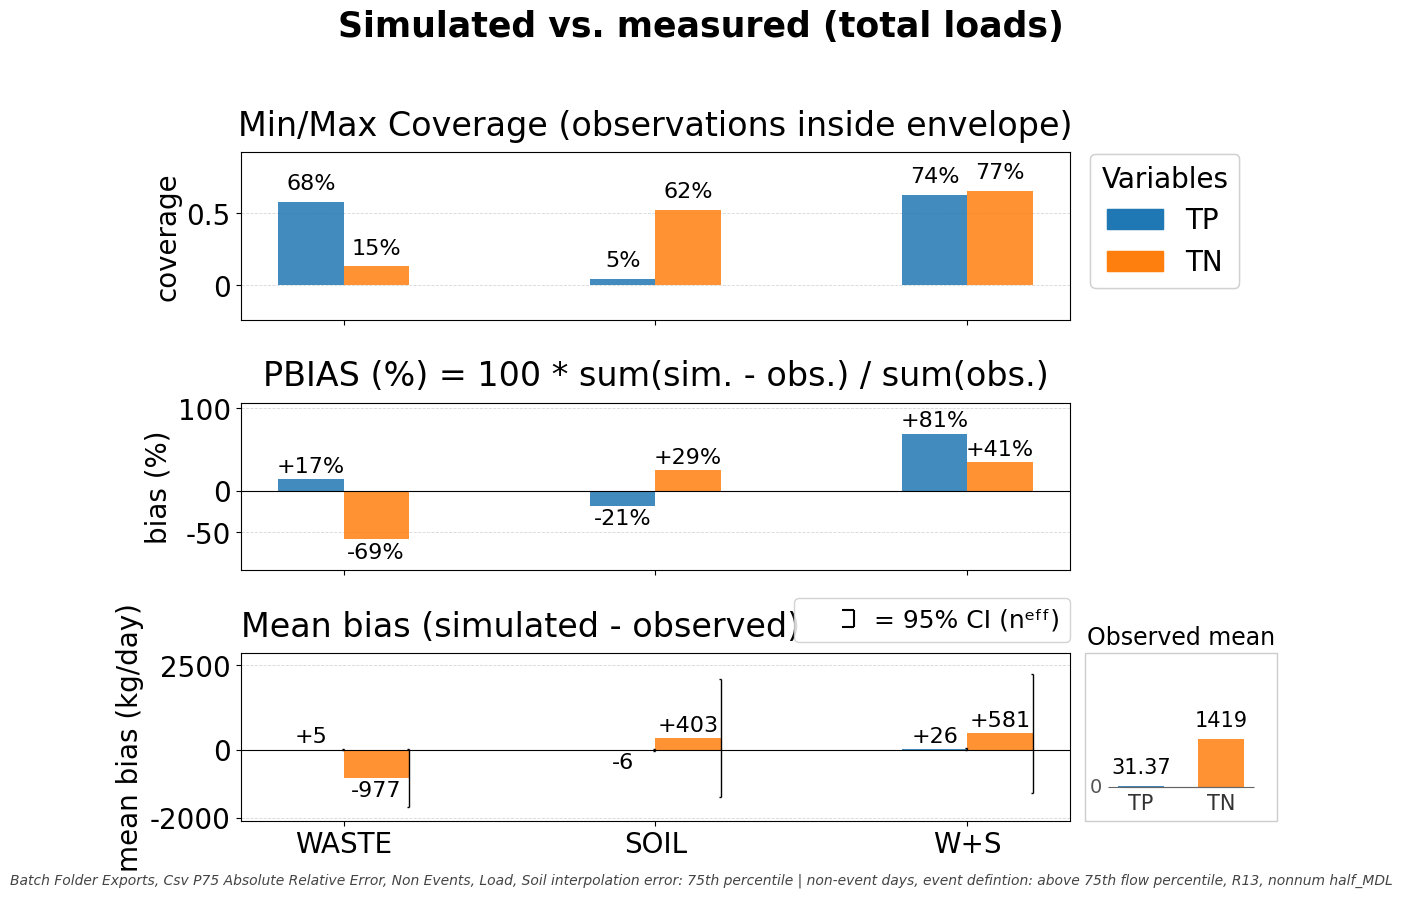


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Simulated vs. measured (total loads)
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Load, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Hedges’ g,"CI₉₅(g,nᵉᶠᶠ) lo","CI₉₅(g,nᵉᶠᶠ) hi",CI₉₅(nᵉᶠᶠ) lo,CI₉₅(nᵉᶠᶠ) hi,"CI₉₅(Δrel,nᵉᶠᶠ) lo",...,nᵉᶠᶠ(A),nᵉᶠᶠ(B),n(A),n(B),Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B)
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+0.632,+1200.0%,0.684,0.0526,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.0526,-7.1%,0.684,0.737,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,,,,,,,...,,,,,-0.684,-92.9%,0.0526,0.737,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,,,,,,,...,,,,,-0.462,-75.0%,0.154,0.615,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.615,-80.0%,0.154,0.769,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,,,,,,,...,,,,,-0.154,-20.0%,0.615,0.769,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,,,,,,,...,,,,,+0.53,+344.7%,0.684,0.154,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,,,,,,,...,,,,,-0.563,-91.4%,0.0526,0.615,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,,,,,,,...,,,,,-0.0324,-4.2%,0.737,0.769,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,,,,,,,...,,,,,+38.1,+179.2%,16.8,-21.3,,


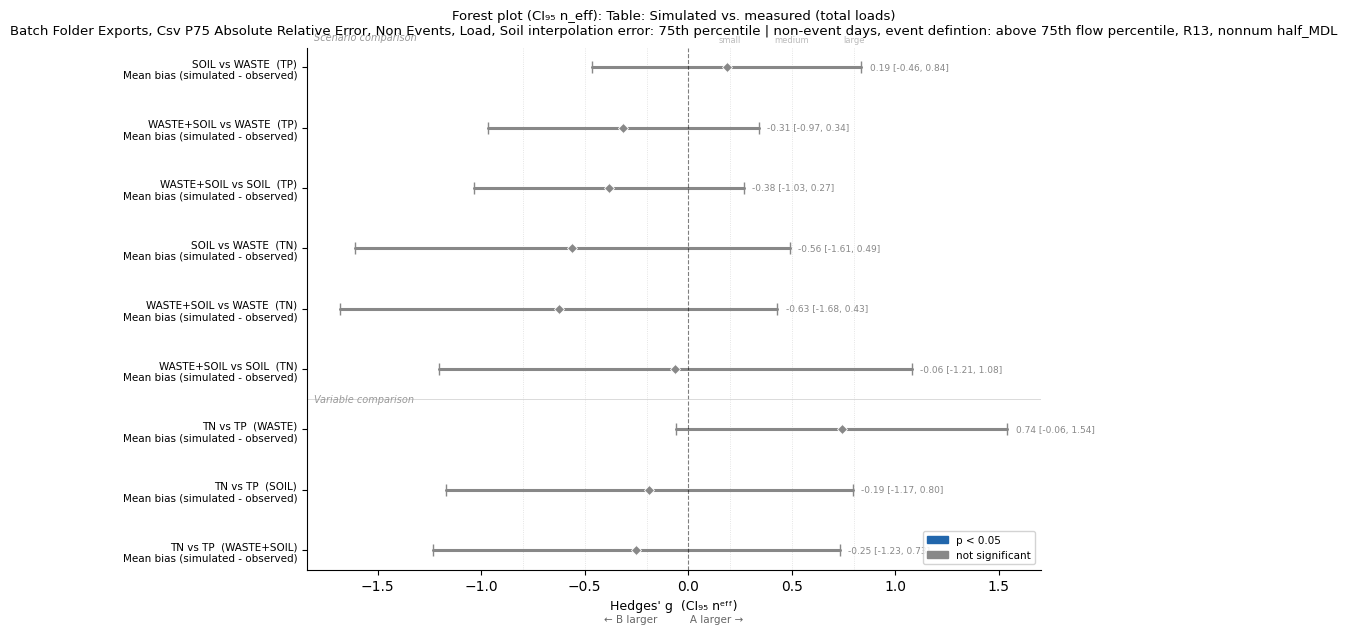


Fisnished chart 3 for all configured folders.
Chart 3 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  compare_mode: conc
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\batch_folder_exports\csv_p75_absolute_relative_error\half_mdl\all\conc\runs_188_200_201__vars_tot_nkg_tot_pkg
run-188: export_variable=tot-nkg scenario=SOIL, variable=TN
run-188: export_variable=tot-pkg scenario=SOIL, variable=TP
run-200: export_variable=tot-nkg scenario=WASTE, variable=TN
run-200: export_variable=tot-pkg scenario=WASTE, variable=TP
run-201: export_variable=tot-nkg scenario=WASTE+SOIL, variable=TN
run-201: export_variable=tot-pkg scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203, 204, 205]

Built 6 export specs

Chart 3 folder: runs_18

In [19]:
chart_3_metrics_by_folder = {}

chart_3_logs = []
chart_3_neff_diag_context_by_folder = {}



# For chart 3:

# - title controls the subplot title you see on the figure

# - source_title points to the exported metric label used to fetch the raw value

# - sign_multiplier lets you flip the displayed sign without changing the export files

three_metric_specs = [

    {

        "title": "Min/Max Coverage (observations inside envelope)",

    },

    {

        "source_title": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)",

        "title": "PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)",

        "sign_multiplier": -1,

    },

    {

        "source_title": "Mean bias (observed - simulated)",

        "title": "Mean bias (simulated - observed)",

        "sign_multiplier": -1,

    },

]



# Chart 3 y-axis label options:

# - chart_3_y_labels gives one label per subplot, top to bottom

# - chart_3_shared_y_label adds one label spanning all plotted subplots

# - set chart_3_show_individual_y_labels = False if you only want the shared label

chart_3_y_labels = [

    "coverage",

    "bias (%)",

    "mg/L or kg/day",

]

chart_3_shared_y_label = None

chart_3_show_individual_y_labels = True

chart_3_shared_y_label_x = 0.02



# Implied observed baseline diagnostic for chart 3:

# - set chart_3_show_implied_observed_panel = True to restore the separate fourth panel

# - set chart_3_show_implied_observed_annotations = True to show compact labels in the mean-bias panel

# - values are suppressed as chart_3_implied_observed_low_pbias_text when |PBIAS| is below the threshold

chart_3_show_implied_observed_panel = False

chart_3_show_implied_observed_annotations = True

chart_3_show_implied_observed_sidebox = True

chart_3_implied_observed_sidebox_title = "Observed mean"

chart_3_implied_observed_sidebox_title_fs = 17

chart_3_implied_observed_sidebox_value_fs = 15

chart_3_implied_observed_sidebox_label_fs = 15

chart_3_implied_observed_sidebox_gap = 0.012

chart_3_implied_observed_sidebox_bbox = None

chart_3_implied_observed_sidebox_shift_zero_mode = "auto"

chart_3_implied_observed_title = "Implied mean observed baseline"

chart_3_implied_observed_y_label = "implied mean obs."

chart_3_implied_observed_format = "{:.4g}"

chart_3_implied_observed_annotation_prefix = "obs~"

chart_3_implied_observed_annotation_offset_points = 18

chart_3_implied_observed_min_abs_pbias = 5.0

chart_3_implied_observed_low_pbias_text = "obs~n/a"

chart_3_third_metric_small_value_threshold = 3.0

chart_3_third_metric_small_value_decimals = 1

chart_3_show_implied_observed_annotation_legend = not chart_3_show_implied_observed_sidebox

chart_3_implied_observed_annotation_legend_title = "~obs ="

chart_3_implied_observed_annotation_legend_lines = [

    "mean of ",

    "measured",

    "values",

    #"n/a: |PBIAS| < 5%",

]

chart_3_implied_observed_annotation_legend_fs = 18

chart_3_implied_observed_annotation_legend_loc = "lower left"

chart_3_implied_observed_annotation_legend_bbox = (0.835, 0.07)

chart_3_error_bar_metric_titles = ["Mean bias (simulated - observed)"]

chart_3_error_bar_legend_label = ("= 95% CI (nᵉᶠᶠ)" if USE_NEFF_CI else "= 95% CI (n)")

chart_3_error_bar_legend_fs = 18

chart_3_error_bar_legend_loc = "lower right"

chart_3_error_bar_legend_bbox = None

chart_3_error_bar_legend_min_margin = 0.012





three_metric_semantic_label_map = {

    **semantic_label_map,

    **example_semantic_label_map,

    "coverage100": {

        "label": "Min/Max Coverage (observations inside envelope)",

        "path": ("same_day", "coverage100"),

    },

    "PBIAS%": {

        "label": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)",

        "path": ("same_day", "PBIAS%"),

    },

    "Bias(obs-pred)": {

        "label": "Mean bias (observed - simulated)",

        "path": ("same_day", "Bias(obs-pred)"),

    },

}





_last_ch3_compare_mode = None
for batch_folder in batch_folders:
    _ch3_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch3_compare_mode != _last_ch3_compare_mode:
        _print_graph_group_separator(_ch3_compare_mode, chart_label='Chart 3')
        _last_ch3_compare_mode = _ch3_compare_mode

    generated_specs, build_log = _capture_stdout(

        build_export_specs_from_folder,

        batch_folder,

        run_to_scenario,

        variable_map,

        verbose=True,

    )



    _ch3_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))

    _ch3_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))

    _ch3_selected_scenarios = _ordered_present_values(_ch3_actual_scenarios, chart_scenario_order)

    _ch3_selected_variables = _ordered_present_values(_ch3_actual_variables, chart_variable_order)



    _ch3_example_export = _load_stat_export(generated_specs[0], verbose=False)

    _ch3_dashboard_state = (

        _ch3_example_export["payload"].get("metadata", {}).get("dashboard_state")

        or _ch3_example_export["payload"].get("dashboard_state")

        or {}

    )

    _ch3_compare_mode = str(_ch3_dashboard_state.get("compare_mode") or "load").strip().lower()

    _ch3_y_labels = list(chart_3_y_labels)

    if _ch3_compare_mode == "conc":

        ch_3_chart_descriptor = "Simulated vs. measured (concentrations)"

        _ch3_y_labels[2] = "mean bias (mg/L)"

    else:

        ch_3_chart_descriptor = "Simulated vs. measured (total loads)"

        _ch3_y_labels[2] = "mean bias (kg/day)"



    ch_3_title_metadata_parts = [

    "folder_label",           # represents interpolation error and MDL handling policy

    "view",                   # represents event vs non-event vs all days

    "event_threshold",        # defines event definition (e.g. P75, abs)

    #"measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")

    #"n",                      # number of measurements considere by above filter and mapping

    "reach",                  # represents the reach being analysed (e.g. 13)

    "measured_nonnum_policy", 

    ]



    ch_3_title_folder_label_map = {

        # exact-match shorthand  (token: label)

        "runs_187_200_202":      "Soil interpolation error: relative median",

        "runs_205_200_204":      "Soil interpolation error: absolute median",

        "runs_189_200_203":      "Soil interpolation error: relative RMSE",

        "runs_188_200_201":      "Soil interpolation error: 75th percentile",

        "runs_153_155_157":      "Original TFM (relative RMSE)",

        "drop_mdl":              None, #"drop-below-DL",

        "half_mdl":              None, #"half-DL",

    }





    EVENT_THRESHOLD_TITLE_ALIASES = {

    "p50": "event defintion: above 50th flow percentile",

    "p75": "event defintion: above 75th flow percentile",

    "p90": "event defintion: above 90th flow percentile",

    "abs": "event defintion: above absolute flow value",

    }       



    chart_title, chart_subtitle = build_semantic_chart_title(

        batch_folder, generated_specs,

        ch_3_chart_descriptor,

        title_metadata_parts=ch_3_title_metadata_parts,

        title_folder_label_map=ch_3_title_folder_label_map,

    )

    chart_3_y_ticks_between_zero_and_extreme = 1  # preferred interior y-ticks per side between 0 and the active extreme




    _ch3_error_data = {}
    if chart_3_error_bar_metric_titles:
        _ch3_error_data = build_error_data_from_extended_stats(
            generated_specs,
            chart_3_error_bar_metric_titles,
            metric_label_to_technical={
                "Mean bias (simulated - observed)": "Bias(obs-pred)",
            },
            error_mode="ci95_neff" if USE_NEFF_CI else "ci95",
        )

    fig, ax, three_metric_stats = plot_three_metric_comparison(

        generated_specs,

        metric_specs=three_metric_specs,

        semantic_label_map=three_metric_semantic_label_map,

        variable_order=_ch3_selected_variables,

        scenario_order=_ch3_selected_scenarios,

        title=chart_title,


        subtitle=chart_subtitle,

        y_label="compared to msrmnts",

        y_labels=_ch3_y_labels,

        y_ticks_between_zero_and_extreme=chart_3_y_ticks_between_zero_and_extreme,

        shared_y_label=chart_3_shared_y_label,

        show_individual_y_labels=chart_3_show_individual_y_labels,

        shared_y_label_x=chart_3_shared_y_label_x,

        show_implied_observed_panel=chart_3_show_implied_observed_panel,

        show_implied_observed_annotations=chart_3_show_implied_observed_annotations,

        implied_observed_title=chart_3_implied_observed_title,

        implied_observed_y_label=chart_3_implied_observed_y_label,

        implied_observed_format=chart_3_implied_observed_format,

        implied_observed_annotation_prefix=chart_3_implied_observed_annotation_prefix,

        implied_observed_annotation_offset_points=chart_3_implied_observed_annotation_offset_points,

        implied_observed_min_abs_pbias=chart_3_implied_observed_min_abs_pbias,

        implied_observed_low_pbias_text=chart_3_implied_observed_low_pbias_text,

        third_metric_small_value_threshold=chart_3_third_metric_small_value_threshold,

        third_metric_small_value_decimals=chart_3_third_metric_small_value_decimals,



        show_implied_observed_annotation_legend=chart_3_show_implied_observed_annotation_legend,

        implied_observed_annotation_legend_title=chart_3_implied_observed_annotation_legend_title,

        implied_observed_annotation_legend_lines=chart_3_implied_observed_annotation_legend_lines,

        implied_observed_annotation_legend_fs=chart_3_implied_observed_annotation_legend_fs,

        implied_observed_annotation_legend_loc=chart_3_implied_observed_annotation_legend_loc,

        implied_observed_annotation_legend_bbox=chart_3_implied_observed_annotation_legend_bbox,

        show_implied_observed_sidebox=chart_3_show_implied_observed_sidebox,

        implied_observed_sidebox_title=chart_3_implied_observed_sidebox_title,

        implied_observed_sidebox_title_fs=chart_3_implied_observed_sidebox_title_fs,

        implied_observed_sidebox_value_fs=chart_3_implied_observed_sidebox_value_fs,

        implied_observed_sidebox_label_fs=chart_3_implied_observed_sidebox_label_fs,

        implied_observed_sidebox_gap=chart_3_implied_observed_sidebox_gap,

        implied_observed_sidebox_bbox=chart_3_implied_observed_sidebox_bbox,

        implied_observed_sidebox_shift_zero_mode=chart_3_implied_observed_sidebox_shift_zero_mode,

        error_data=_ch3_error_data,

        error_bar_metric_titles=chart_3_error_bar_metric_titles,

        error_bar_legend_label=chart_3_error_bar_legend_label,

        error_bar_legend_fs=chart_3_error_bar_legend_fs,

        error_bar_legend_loc=chart_3_error_bar_legend_loc,

        error_bar_legend_bbox=chart_3_error_bar_legend_bbox,

        error_bar_legend_min_margin=chart_3_error_bar_legend_min_margin,



        figsize=(12, 9),

        abbreviations=chart_abbreviations,

        annotate_rotation=60,
        scenario_label_rotation = 0,

        annot_fs=16,

        tick_fs=20,

        title_fs=24,
        title_fontweight= "bold",

        subtitle_fs=10,

        label_fs=20,

        legend_fs=20,

        title_pad=12,

        subplot_h_pad=1.1,

        positive_bar_h_pad_scale=1.8,

        legend_outside=False,

        legend_loc="upper right",

        legend_bbox=(0.96, 0.835),

        #chart_3_error_bar_legend_min_margin= 20,
        #chart_3_error_bar_legend_bbox = None,  


        tight_layout_rect=(0.0, 0.02, 0.82, 0.94),

        verbose=False,

        signed_positive_axis_fraction=0.32,

        signed_negative_axis_fraction=0.32,

        label_offset_scale=0.03,

        annotation_offset_points=6,

        signed_annotation_offset_points=2,

        top_margin_scale=0.22,

        top_margin_px=10, # minimum pixels between top of highest or lowest annotation/whisker and boudnding box (whichever is greater)

        height_scale=0.85,

    )

    if chart_3_show_implied_observed_sidebox:
        _sidebox_ax = next(
            (
                axis
                for axis in fig.axes
                if axis.get_title().strip() == str(chart_3_implied_observed_sidebox_title).strip()
            ),
            None,
        )
        if _sidebox_ax is None:
            _sidebox_ax = max(fig.axes, key=lambda axis: axis.get_position().x0, default=None)

        _main_plot_axes = [axis for axis in fig.axes if axis is not _sidebox_ax]
        if _sidebox_ax is not None and _main_plot_axes:
            _lower_panel_ax = min(_main_plot_axes, key=lambda axis: axis.get_position().y0)
            _left_lower, _left_upper = _lower_panel_ax.get_ylim()
            _visible_ticks = [
                float(tick)
                for tick in _lower_panel_ax.get_yticks()
                if math.isfinite(tick) and (_left_lower - 1e-9) <= float(tick) <= (_left_upper + 1e-9)
            ]
            _positive_ticks = [tick for tick in _visible_ticks if tick > 1e-9]
            _meaningful_positive_tick_space = False
            if _positive_ticks and _left_upper > 1e-9:
                _span = max(1e-9, _left_upper - _left_lower)
                try:
                    _axis_height_px = float(_lower_panel_ax.get_window_extent(fig.canvas.get_renderer()).height)
                except Exception:
                    _axis_height_px = None
                if _axis_height_px is None or _axis_height_px <= 1:
                    _meaningful_positive_tick_space = True
                else:
                    _positive_side_height_px = _axis_height_px * _left_upper / _span
                    _min_interval_px = 52.0
                    _positive_capacity = max(1, int(math.floor((_positive_side_height_px + 1e-9) / _min_interval_px)))
                    _meaningful_positive_tick_space = _positive_capacity > 1
            if not _meaningful_positive_tick_space:
                _observed_values = [
                    float(patch.get_height())
                    for patch in _sidebox_ax.patches
                    if math.isfinite(float(patch.get_height()))
                ]
                if _observed_values:
                    _span = max(1e-9, _left_upper - _left_lower)
                    _label_band_height = 0.1 * _span
                    _value_pad = 0.04 * _span
                    _zero_fraction_from_bottom = 0.2
                    _max_shift = max(0.0, -_left_lower - _label_band_height)
                    _target_lower = -max(_label_band_height, _zero_fraction_from_bottom * _span)
                    _visual_shift = max(0.0, _target_lower - _left_lower)
                    _overflow_shift = max(0.0, max(_observed_values) + _value_pad - _left_upper)
                    _shift = min(_max_shift, max(_visual_shift, _overflow_shift))
                    if _shift > 1e-9:
                        _sidebox_lower = _left_lower + _shift
                        _sidebox_upper = _left_upper + _shift
                        _sidebox_ax.set_ylim(_sidebox_lower, _sidebox_upper)
                        _sidebox_label_y = max(_sidebox_lower + 0.02 * _span, -0.4 * _label_band_height)
                        for _text in _sidebox_ax.texts:
                            if _text.get_text() in _ch3_selected_variables:
                                _text.set_y(_sidebox_label_y)
                        _x_left, _x_right = _sidebox_ax.get_xlim()
                        _zero_line_left = _x_left + 0.12 * (_x_right - _x_left)
                        _zero_line_right = _x_right - 0.12 * (_x_right - _x_left)
                        _sidebox_ax.hlines(
                            0,
                            _zero_line_left,
                            _zero_line_right,
                            colors="#666666",
                            linewidth=0.8,
                        )
                        _zero_label_x = 0.5 * (_x_left + _zero_line_left)
                        _existing_zero_texts = [
                            _text
                            for _text in _sidebox_ax.texts
                            if _text.get_text() == "0" and abs(float(_text.get_position()[1])) <= 1e-9
                        ]
                        if _existing_zero_texts:
                            _existing_zero_texts[0].set_x(_zero_label_x)
                            _existing_zero_texts[0].set_y(0)
                            _existing_zero_texts[0].set_ha("center")
                            _existing_zero_texts[0].set_va("center")
                            _existing_zero_texts[0].set_fontsize(
                                max(9, chart_3_implied_observed_sidebox_label_fs - 1)
                            )
                            _existing_zero_texts[0].set_color("#555555")
                            for _extra_zero_text in _existing_zero_texts[1:]:
                                _extra_zero_text.remove()
                        else:
                            _sidebox_ax.text(
                                _zero_label_x,
                                0,
                                "0",
                                ha="center",
                                va="center",
                                fontsize=max(9, chart_3_implied_observed_sidebox_label_fs - 1),
                                color="#555555",
                            )

    plt.show()


    # "-- Significance table for Chart 3 "--
    _ch3_event_regime_rows = build_event_regime_rows(
        generated_specs,
        batch_folder,
        run_to_scenario,
        variable_map,
        scenarios=_ch3_selected_scenarios,
        variables=_ch3_selected_variables,
    )
    display_chart_significance_tables(
        three_metric_stats,
        generated_specs,
        chart_title=f"Table: {chart_title}",
        chart_subtitle=chart_subtitle,
        comparison_modes=("scenarios", "variables"),
        scenarios=_ch3_selected_scenarios,
        variables=_ch3_selected_variables,
        metric_label_to_technical={
            "Min/Max Coverage (observations inside envelope)": "coverage100",
            "PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)": "PBIAS%",
            "Mean bias (simulated - observed)": "Bias(obs-pred)",
        },
        extra_comparison_rows=_ch3_event_regime_rows,
            forest_plot=True,
        )


    saved_path, save_log = _capture_stdout(

        _save_chart_figure,

        fig,

        batch_folder.name,

        "chart_3_three_metric",

        save_enabled=save_individual_chart_images,

        output_root=saved_chart_root,

        dpi=saved_chart_dpi,

    )

    plt.close(fig)



    chart_3_metrics_by_folder[batch_folder.name] = three_metric_stats

    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_3_metrics"] = three_metric_stats

    chart_results_by_folder[batch_folder.name]["chart_3_saved_path"] = saved_path

    chart_3_neff_diag_context_by_folder[batch_folder.name] = {
        "chart_title": chart_title,
        "chart_subtitle": chart_subtitle,
        "three_metric_stats": three_metric_stats,
        "generated_specs": generated_specs,
        "selected_scenarios": list(_ch3_selected_scenarios),
        "selected_variables": list(_ch3_selected_variables),
        "event_regime_rows": list(_ch3_event_regime_rows),
    }



    chart_3_logs.append(f"Chart 3 folder: {batch_folder.name}")

    chart_3_logs.append(f"  compare_mode: {_ch3_compare_mode}")

    chart_3_logs.append(f"  scenarios: {_ch3_selected_scenarios}")

    chart_3_logs.append(f"  variables: {_ch3_selected_variables}")

    if build_log.strip():

        chart_3_logs.append(build_log.rstrip())

    if save_log.strip():

        chart_3_logs.append(save_log.rstrip())

    chart_3_logs.append("")



print("\nFisnished chart 3 for all configured folders.")

print("\n".join(line for line in chart_3_logs if line is not None))


In [20]:
if "chart_3_neff_diag_context_by_folder" in globals() and chart_3_neff_diag_context_by_folder:
    _ch3_diag_context_items = list(chart_3_neff_diag_context_by_folder.items())
else:
    _required_chart3_context = [
        "three_metric_stats",
        "generated_specs",
        "chart_title",
        "chart_subtitle",
        "_ch3_selected_scenarios",
        "_ch3_selected_variables",
        "_ch3_event_regime_rows",
    ]
    _missing_chart3_context = [name for name in _required_chart3_context if name not in globals()]
    if _missing_chart3_context:
        raise RuntimeError(
            "Run the Chart 3 execution cell immediately above first. Missing variables: "
            + ", ".join(_missing_chart3_context)
        )
    _ch3_diag_context_items = [
        (
            "current_chart",
            {
                "chart_title": chart_title,
                "chart_subtitle": chart_subtitle,
                "three_metric_stats": three_metric_stats,
                "generated_specs": generated_specs,
                "selected_scenarios": list(_ch3_selected_scenarios),
                "selected_variables": list(_ch3_selected_variables),
                "event_regime_rows": list(_ch3_event_regime_rows),
            },
        )
    ]

_ch3_metric_label_to_technical = {
    "Min/Max Coverage (observations inside envelope)": "coverage100",
    "PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)": "PBIAS%",
    "Mean bias (simulated - observed)": "Bias(obs-pred)",
}

def _sig_label(p_value):
    if not np.isfinite(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


_diag_records = []
for _folder_name, _diag_context in _ch3_diag_context_items:
    _ch3_ext_stats = extract_extended_stats_for_chart(
        _diag_context["generated_specs"],
        list(set(_ch3_metric_label_to_technical.values())),
        verbose=False,
    )

    _ch3_diag_rows = build_comparison_rows(
        _diag_context["three_metric_stats"],
        comparison_modes=("scenarios", "variables"),
        scenarios=_diag_context["selected_scenarios"],
        variables=_diag_context["selected_variables"],
        extended_stats=_ch3_ext_stats,
        metric_label_to_technical=_ch3_metric_label_to_technical,
    )
    _event_regime_rows = _diag_context.get("event_regime_rows") or []
    if _event_regime_rows:
        _ch3_diag_rows.extend(_event_regime_rows)

    for _row in _ch3_diag_rows:
        _p_neff = _row.get("p_value", np.nan)
        _p_raw = _row.get("p_value_raw", np.nan)
        if not (np.isfinite(_p_neff) and np.isfinite(_p_raw)):
            continue

        _n_a = _row.get("n_A", np.nan)
        _n_b = _row.get("n_B", np.nan)
        _neff_a = _row.get("n_eff_A", np.nan)
        _neff_b = _row.get("n_eff_B", np.nan)

        _diag_records.append(
            {
                "Folder": _folder_name,
                "Metric": _row.get("metric", ""),
                "Comparison": _row.get("comparison", ""),
                "Group A": _row.get("group_A", ""),
                "Group B": _row.get("group_B", ""),
                "p (n)": _p_raw,
                "sig (n)": _sig_label(_p_raw),
                "p (n_eff)": _p_neff,
                "sig (n_eff)": _sig_label(_p_neff),
                "sig shift": f"{_sig_label(_p_raw)} -> {_sig_label(_p_neff)}",
                "p shift (n_eff - n)": _p_neff - _p_raw,
                "n(A)": _n_a,
                "n_eff(A)": _neff_a,
                "n_eff/n (A)": (_neff_a / _n_a) if np.isfinite(_n_a) and _n_a > 0 else np.nan,
                "n(B)": _n_b,
                "n_eff(B)": _neff_b,
                "n_eff/n (B)": (_neff_b / _n_b) if np.isfinite(_n_b) and _n_b > 0 else np.nan,
            }
        )

_ch3_neff_diag_df = pd.DataFrame(_diag_records)
if _ch3_neff_diag_df.empty:
    print(
        "Chart 3 diagnostic: no rows have both raw-n and n_eff significance estimates. "
        "This is expected for coverage100 and PBIAS%; only mean-bias rows currently export sd/n/rho1."
    )
else:
    from IPython.display import display as _ipy_display

    _ch3_neff_diag_df["_p_shift_abs"] = _ch3_neff_diag_df["p shift (n_eff - n)"].abs()
    _ch3_neff_diag_df = _ch3_neff_diag_df.sort_values("_p_shift_abs", ascending=False).drop(columns=["_p_shift_abs"])

    _ch3_display_df = _ch3_neff_diag_df.copy()
    for _col in ["p (n)", "p (n_eff)", "p shift (n_eff - n)"]:
        _ch3_display_df[_col] = _ch3_display_df[_col].map(lambda v: f"{v:+.4f}" if np.isfinite(v) else "")
    for _col in ["n(A)", "n_eff(A)", "n(B)", "n_eff(B)"]:
        _ch3_display_df[_col] = _ch3_display_df[_col].map(lambda v: f"{v:.0f}" if np.isfinite(v) else "")
    for _col in ["n_eff/n (A)", "n_eff/n (B)"]:
        _ch3_display_df[_col] = _ch3_display_df[_col].map(lambda v: f"{v:.2f}" if np.isfinite(v) else "")

    print("\n" + "-" * 88)
    print("  Chart 3 diagnostic: effect of n_eff on significance estimates")
    print("  Only rows with both p(n) and p(n_eff) are shown across all processed Chart 3 folders.")
    print("-" * 88)
    _ipy_display(_ch3_display_df)



----------------------------------------------------------------------------------------
  Chart 3 diagnostic: effect of n_eff on significance estimates
  Only rows with both p(n) and p(n_eff) are shown across all processed Chart 3 folders.
----------------------------------------------------------------------------------------


,Folder,Metric,Comparison,Group A,Group B,p (n),sig (n),p (n_eff),sig (n_eff),sig shift,p shift (n_eff - n),n(A),n_eff(A),n_eff/n (A),n(B),n_eff(B),n_eff/n (B)
8,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.4685,ns,+0.6192,ns,ns -> ns,+0.1507,19,19,1.00,13,6,0.49
3,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,WASTE / TN,SOIL / TN,+0.1302,ns,+0.2685,ns,ns -> ns,+0.1383,13,11,0.87,13,6,0.49
4,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,WASTE / TN,WASTE+SOIL / TN,+0.0928,ns,+0.2205,ns,ns -> ns,+0.1277,13,11,0.87,13,6,0.49
7,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),variable,SOIL / TP,SOIL / TN,+0.5864,ns,+0.7094,ns,ns -> ns,+0.1230,19,19,1.00,13,6,0.49
5,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,SOIL / TN,WASTE+SOIL / TN,+0.8658,ns,+0.9066,ns,ns -> ns,+0.0408,13,6,0.49,13,6,0.49
6,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),variable,WASTE / TP,WASTE / TN,+0.0638,ns,+0.0852,ns,ns -> ns,+0.0214,19,19,1.00,13,11,0.87
0,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,WASTE / TP,SOIL / TP,+0.5603,ns,+0.5603,ns,ns -> ns,+0.0000,19,19,1.00,19,19,1.00
1,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,WASTE / TP,WASTE+SOIL / TP,+0.3290,ns,+0.3290,ns,ns -> ns,+0.0000,19,19,1.00,19,19,1.00
2,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (simulated - observed),scenario,SOIL / TP,WASTE+SOIL / TP,+0.2360,ns,+0.2360,ns,ns -> ns,+0.0000,19,19,1.00,19,19,1.00


In [21]:
# Debug chart-3 resolved values for the most recent folder/variant
_last_folder = next(reversed(chart_3_metrics_by_folder))
_last_metrics = chart_3_metrics_by_folder[_last_folder]["metrics"]
print("Last folder:", _last_folder)
for _metric_label, _metric_block in _last_metrics.items():
    if str(_metric_label).startswith("__"):
        continue
    print("\n", _metric_label)
    for _scenario, _var_map in _metric_block.items():
        if str(_scenario).startswith("__"):
            continue
        _shown = {k: v for k, v in _var_map.items()}
        print(" ", _scenario, _shown)

Last folder: runs_188_200_201__vars_tot_nkg_tot_pkg

 Min/Max Coverage (observations inside envelope)
  WASTE {'TN': 0.15384615384615385, 'TP': 0.6842105263157895}
  SOIL {'TN': 0.6153846153846154, 'TP': 0.05263157894736842}
  WASTE+SOIL {'TN': 0.7692307692307693, 'TP': 0.7368421052631579}

 PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)
  WASTE {'TN': -68.88369188396138, 'TP': 16.84525619556619}
  SOIL {'TN': 29.088875477816128, 'TP': -21.257772109557738}
  WASTE+SOIL {'TN': 40.935101853691954, 'TP': 81.4028107208188}

 Mean bias (simulated - observed)
  WASTE {'TN': -977.3760855384616, 'TP': 5.285128690526313}
  SOIL {'TN': 402.75684923076915, 'TP': -6.456237629473684}
  WASTE+SOIL {'TN': 580.7579803076923, 'TP': 25.529480050526317}

 Implied mean observed baseline
  WASTE {'TP': 31.37458183578948, 'TN': 1418.878777846154}
  SOIL {'TP': 30.371186576842103, 'TN': 1384.5734584615386}
  WASTE+SOIL {'TP': 31.36191468631579, 'TN': 1418.7285581538463}


In [22]:
# Debug mapping from chart-3 labels to technical names/paths
_req_labels = [spec["source_title"] for spec in _normalise_three_metric_specs(three_metric_specs)]
_specs = _build_requested_metric_specs(_req_labels, _normalise_semantic_label_map(three_metric_semantic_label_map), format_val)
for _s in _specs:
    print(_s)

{'technical_name': 'coverage100', 'output_label': 'Min/Max Coverage (observations inside envelope)', 'format': '{:.0%}', 'path': ('same_day', 'coverage100')}
{'technical_name': 'PBIAS%', 'output_label': 'PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)', 'format': '{:+.0f}%', 'path': ('same_day', 'PBIAS%')}
{'technical_name': 'Bias(obs-pred)', 'output_label': 'Mean bias (observed - simulated)', 'format': '{:+.0f}', 'path': ('same_day', 'Bias(obs-pred)')}


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CROSS-REGIME SIGNIFICANCE  ─  HF vs BF within each scenario × variable
# ═══════════════════════════════════════════════════════════════════════════════
# Computes Welch t-test (n_eff-corrected), CI₉₅(Δ%), and Hedges' g for the
# contrast between high-flow days (HF) and baseflow days (BF) within each
# scenario for Charts 1, 2, and 3.
#
# All statistical machinery (_welch_t_test, extract_extended_stats_for_chart)
# is reused from cell 21 — no new pipeline logic is introduced here.
#
# Charts 1 & 2: metric values come from ch_1_auto_metrics and
#   chart_2_metrics_by_folder.  SD/n/rho₁ are read from the same JSON exports
#   via extract_extended_stats_for_chart, using the generated_specs stored in
#   _ch1_folder_data (the specs are identical for both charts).
# Chart 3: regime rows are unpacked from build_event_regime_rows output stored
#   in chart_3_neff_diag_context_by_folder["event_regime_rows"].
#
# Outputs
# -------
# regime_contrast_df  : pandas DataFrame, one row per comparison
#   Columns: Chart | Folder | Metric | Scenario | Variable
#            | HF mean | BF mean | Δ(HF−BF) | Δ rel
#            | CI₉₅(Δ%) lo | CI₉₅(Δ%) hi
#            | CI₉₅(Δ) lo  | CI₉₅(Δ) hi
#            | Hedges' g | CI₉₅(g) lo | CI₉₅(g) hi
#            | t | p | sig | n(HF) | n(BF) | n_eff(HF) | n_eff(BF)
#
# Prerequisite: run the Chart 1, Chart 2, and Chart 3 cells before this cell.
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np


def _sig_stars(p):
    if not np.isfinite(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def _make_regime_row(chart, folder, metric, scenario, variable,
                     val_hf, sd_hf, n_hf, rho1_hf,
                     val_bf, sd_bf, n_bf, rho1_bf):
    """Build one regime-contrast row dict (HF = group A, BF = group B)."""
    (t, p, ci_lo, ci_hi, ci_raw_lo, ci_raw_hi, t_raw, p_raw,
     d, g, nea, neb, cig_lo, cig_hi, *_) = _welch_t_test(
        val_hf, sd_hf, n_hf, val_bf, sd_bf, n_bf,
        rho1_a=rho1_hf, rho1_b=rho1_bf)
    diff = (val_hf - val_bf) if (np.isfinite(val_hf) and np.isfinite(val_bf)) else np.nan
    ref  = abs(val_bf) if (np.isfinite(val_bf) and abs(val_bf) > 1e-15) else np.nan
    return {
        "Chart":        chart,
        "Folder":       folder,
        "Metric":       metric,
        "Scenario":     scenario,
        "Variable":     variable,
        "HF mean":      val_hf,
        "BF mean":      val_bf,
        "Δ(HF−BF)":    diff,
        "Δ rel":        diff / ref  if (np.isfinite(diff)  and np.isfinite(ref)) else np.nan,
        "CI₉₅(Δ%) lo": ci_lo / ref if (np.isfinite(ci_lo) and np.isfinite(ref)) else np.nan,
        "CI₉₅(Δ%) hi": ci_hi / ref if (np.isfinite(ci_hi) and np.isfinite(ref)) else np.nan,
        "CI₉₅(Δ) lo":  ci_lo,
        "CI₉₅(Δ) hi":  ci_hi,
        "Hedges' g":    g,
        "CI₉₅(g) lo":  cig_lo,
        "CI₉₅(g) hi":  cig_hi,
        "t":            t,
        "p":            p,
        "sig":          _sig_stars(p),
        "n(HF)":        n_hf,
        "n(BF)":        n_bf,
        "n_eff(HF)":    nea,
        "n_eff(BF)":    neb,
    }


_regime_rows = []

# ── CHARTS 1 & 2 ─────────────────────────────────────────────────────────────
# Technical names for HF vs BF pairs (must match _EXTENDED_STATS_KEY_MAP)
_CH1_REL_HF = "bl_mean_maxmin_over_median_event"
_CH1_REL_BF = "bl_mean_maxmin_over_median_nonevent"
_CH1_ABS_HF = "bl_mean_W_event"
_CH1_ABS_BF = "bl_mean_W_nonevent"
_CH2_HF     = "delta_event_pairs_mean"
_CH2_BF     = "delta_non_event_pairs_mean"

# Display labels depend on CH1_USE_MEAN set in the Chart 1 config cell
_use_mean = globals().get("CH1_USE_MEAN", True)
_ch1_rel_hf_label = ("Mean (max-min/median) (high-flow days)"
                     if _use_mean else "Median (max-min/median) (high-flow days)")
_ch1_rel_bf_label = ("Mean (max-min/median) (baseflow days)"
                     if _use_mean else "Median (max-min/median) (baseflow days)")
_ch1_abs_hf_label = ("Ensemble mean W (high-flow days)"
                     if _use_mean else "Ensemble median W (high-flow days)")
_ch1_abs_bf_label = ("Ensemble mean W (baseflow days)"
                     if _use_mean else "Ensemble median W (baseflow days)")

_ch1_fdata_store = globals().get("_ch1_folder_data", {})
_ch2_store       = globals().get("chart_2_metrics_by_folder", {})
# Chart 2 HF/BF display labels (from ch2_semantic_labels)
_CH2_HF_LABEL = "Mean shift (high-flow days)"
_CH2_BF_LABEL = "Mean shift (baseflow days)"

for _fkey, _fdata in _ch1_fdata_store.items():
    _folder_name     = _fdata["batch_folder"].name
    _folder_key_full = str(_fdata["batch_folder"])  # full path - matches chart_2_metrics_by_folder key
    _gen_specs   = _fdata["generated_specs"]
    _scenarios   = _fdata["selected_scenarios"]
    _variables   = _fdata["selected_variables"]
    _mets1       = _fdata["auto_metrics"].get("metrics", {})

    # ── Chart 2: get metrics from stored dict or rebuild inline ──────────────
    _mets2_raw = _ch2_store.get(_folder_key_full, {})
    _mets2 = _mets2_raw.get("metrics", {}) if _mets2_raw else {}
    if not (_mets2.get(_CH2_HF_LABEL) or _mets2.get(_CH2_BF_LABEL)):
        # chart_2_metrics_by_folder is empty (Chart 2 cell errored) — rebuild now
        try:
            _m2 = build_metrics_dict_from_stat_exports(
                _gen_specs,
                [_CH2_HF_LABEL, _CH2_BF_LABEL],
                semantic_label_map=example_semantic_label_map,
                scenario_order=_scenarios,
                variable_order=_variables,
                format_mode="metadata",
                verbose=False,
            )
            _mets2 = _m2.get("metrics", {})
        except Exception as _e2:
            print(f"  [Chart 2 rebuild failed for {_folder_name}]: {_e2}")
            _mets2 = {}

    # One pass over JSON exports to get SD/n/rho₁ for all six technical names
    _ext = extract_extended_stats_for_chart(
        _gen_specs,
        [_CH1_REL_HF, _CH1_REL_BF, _CH1_ABS_HF, _CH1_ABS_BF, _CH2_HF, _CH2_BF],
        verbose=False,
    )

    def _get_ext_stats(sc, var, tech):
        e = _ext.get((sc, var, tech), {})
        return e.get("sd", np.nan), e.get("n", np.nan), e.get("rho1", np.nan)

    # Detect Chart 2 compare_mode (conc = mg/L, load = kg/day) for row labelling
    _ch2_mode = "load"
    try:
        _ex0 = _load_stat_export(_gen_specs[0], verbose=False)
        _ds0 = (_ex0["payload"].get("metadata", {}).get("dashboard_state")
                or _ex0["payload"].get("dashboard_state") or {})
        _ch2_mode = str(_ds0.get("compare_mode") or "load").strip().lower()
    except Exception:
        pass
    _ch2_chart_label = ("Chart 2 (conc shift)" if _ch2_mode == "conc"
                        else "Chart 2 (load shift)")

    for _sc in _scenarios:
        for _var in _variables:

            # ── Chart 1: relative width (mean (max-min)/median) ──────────────
            _v_hf = _mets1.get(_ch1_rel_hf_label, {}).get(_sc, {}).get(_var)
            _v_bf = _mets1.get(_ch1_rel_bf_label, {}).get(_sc, {}).get(_var)
            if _v_hf is not None and _v_bf is not None:
                _sd_h, _n_h, _r_h = _get_ext_stats(_sc, _var, _CH1_REL_HF)
                _sd_b, _n_b, _r_b = _get_ext_stats(_sc, _var, _CH1_REL_BF)
                if np.isfinite(_sd_h) and np.isfinite(_sd_b):
                    _regime_rows.append(_make_regime_row(
                        "Chart 1 (relative width)", _folder_name,
                        "mean (max-min)/median",
                        _sc, _var,
                        float(_v_hf), _sd_h, _n_h, _r_h,
                        float(_v_bf), _sd_b, _n_b, _r_b,
                    ))

            # ── Chart 1: absolute width (mean W) ─────────────────────────────
            _v_hf_w = _mets1.get(_ch1_abs_hf_label, {}).get(_sc, {}).get(_var)
            _v_bf_w = _mets1.get(_ch1_abs_bf_label, {}).get(_sc, {}).get(_var)
            if _v_hf_w is not None and _v_bf_w is not None:
                _sd_h_w, _n_h_w, _r_h_w = _get_ext_stats(_sc, _var, _CH1_ABS_HF)
                _sd_b_w, _n_b_w, _r_b_w = _get_ext_stats(_sc, _var, _CH1_ABS_BF)
                if np.isfinite(_sd_h_w) and np.isfinite(_sd_b_w):
                    _regime_rows.append(_make_regime_row(
                        "Chart 1 (absolute width)", _folder_name,
                        "mean W",
                        _sc, _var,
                        float(_v_hf_w), _sd_h_w, _n_h_w, _r_h_w,
                        float(_v_bf_w), _sd_b_w, _n_b_w, _r_b_w,
                    ))

            # ── Chart 2: mean shift (HF vs BF) ───────────────────────────────
            _v_hf_2 = _mets2.get("Mean shift (high-flow days)", {}).get(_sc, {}).get(_var)
            _v_bf_2 = _mets2.get("Mean shift (baseflow days)",  {}).get(_sc, {}).get(_var)
            if _v_hf_2 is not None and _v_bf_2 is not None:
                _sd_h2, _n_h2, _r_h2 = _get_ext_stats(_sc, _var, _CH2_HF)
                _sd_b2, _n_b2, _r_b2 = _get_ext_stats(_sc, _var, _CH2_BF)
                # Emit row even if SD unavailable - stats columns will be NaN
                _regime_rows.append(_make_regime_row(
                    _ch2_chart_label, _folder_name,
                    "mean shift vs BASE",
                    _sc, _var,
                    float(_v_hf_2), _sd_h2, _n_h2, _r_h2,
                    float(_v_bf_2), _sd_b2, _n_b2, _r_b2,
                ))


# ── CHART 2 (extra conc-mode): folders in chart_2_metrics_by_folder not in _ch1_fdata_store ──
# Chart 2 runs on _ch12_batch_folders which can include conc-mode (mg/L) folders
# that have no corresponding Chart 1 folder.  Process them here.
_ch2_covered = {str(_fd["batch_folder"]) for _fd in _ch1_fdata_store.values()}
_ch12_bfolder_map = {str(f): f for f in globals().get("_ch12_batch_folders", [])}

for _folder_key_ex, _mets2_raw_ex in _ch2_store.items():
    _folder_name_ex = Path(_folder_key_ex).name  # display name only
    if _folder_key_ex in _ch2_covered:
        continue  # already handled in main loop
    _bf_ex = _ch12_bfolder_map.get(_folder_key_ex)  # full path key
    if _bf_ex is None:
        continue
    _mets2_ex = _mets2_raw_ex.get("metrics", {}) if _mets2_raw_ex else {}
    if not _mets2_ex:
        continue
    try:
        _gen_specs_ex, _ = _capture_stdout(
            build_export_specs_from_folder,
            _bf_ex, run_to_scenario, variable_map, verbose=False,
        )
    except Exception as _e_ex:
        print(f"  [Chart 2 extra specs failed for {_folder_name_ex}]: {_e_ex}")
        continue
    _sc_ex_all  = list(dict.fromkeys(s["scenario"] for s in _gen_specs_ex))
    _var_ex_all = list(dict.fromkeys(s["variable"] for s in _gen_specs_ex))
    _sc_ex  = _ordered_present_values(_sc_ex_all,  chart_scenario_order)
    _var_ex = _ordered_present_values(_var_ex_all, chart_variable_order)
    _ext_ex = extract_extended_stats_for_chart(
        _gen_specs_ex, [_CH2_HF, _CH2_BF], verbose=False,
    )
    # Detect mode for label
    _ch2_mode_ex = "load"
    try:
        _ex0_ex = _load_stat_export(_gen_specs_ex[0], verbose=False)
        _ds0_ex = (_ex0_ex["payload"].get("metadata", {}).get("dashboard_state")
                   or _ex0_ex["payload"].get("dashboard_state") or {})
        _ch2_mode_ex = str(_ds0_ex.get("compare_mode") or "load").strip().lower()
    except Exception:
        pass
    _ch2_lbl_ex = "Chart 2 (conc shift)" if _ch2_mode_ex == "conc" else "Chart 2 (load shift)"
    for _sc in _sc_ex:
        for _var in _var_ex:
            _v_hf_ex = _mets2_ex.get("Mean shift (high-flow days)", {}).get(_sc, {}).get(_var)
            _v_bf_ex = _mets2_ex.get("Mean shift (baseflow days)",  {}).get(_sc, {}).get(_var)
            if _v_hf_ex is not None and _v_bf_ex is not None:
                _e_hf = _ext_ex.get((_sc, _var, _CH2_HF), {})
                _e_bf = _ext_ex.get((_sc, _var, _CH2_BF), {})
                _regime_rows.append(_make_regime_row(
                    _ch2_lbl_ex, _folder_name_ex,
                    "mean shift vs BASE",
                    _sc, _var,
                    float(_v_hf_ex), _e_hf.get("sd", np.nan), _e_hf.get("n", np.nan), _e_hf.get("rho1", np.nan),
                    float(_v_bf_ex), _e_bf.get("sd", np.nan), _e_bf.get("n", np.nan), _e_bf.get("rho1", np.nan),
                ))

# ── CHART 3 ──────────────────────────────────────────────────────────────────
# build_event_regime_rows is in the significance engine cell (already defined).
# Call it directly - no dependency on the Chart 3 rendering cell having run.
# It reads sibling events/ and non_events/ folders to compare Bias(obs-pred)
# between high-flow and baseflow days.

for _fkey, _fdata in _ch1_fdata_store.items():
    _folder_name  = _fdata["batch_folder"].name
    _gen_specs    = _fdata["generated_specs"]
    _scenarios    = _fdata["selected_scenarios"]
    _variables    = _fdata["selected_variables"]
    _batch_folder = _fdata["batch_folder"]
    try:
        _event_regime_rows = build_event_regime_rows(
            _gen_specs, _batch_folder,
            run_to_scenario, variable_map,
            scenarios=_scenarios, variables=_variables,
        )
    except Exception as _e3:
        print(f"  [Chart 3 regime rows skipped for {_folder_name}]: {_e3}")
        _event_regime_rows = []

    for _row in _event_regime_rows:
        _p    = _row.get("p_value", np.nan)
        _va   = _row.get("value_A", np.nan)
        _vb   = _row.get("value_B", np.nan)
        _ci_l = _row.get("ci95_lo",  np.nan)
        _ci_h = _row.get("ci95_hi",  np.nan)
        _ref  = abs(_vb) if (np.isfinite(_vb) and abs(_vb) > 1e-15) else np.nan
        _diff = (_va - _vb) if (np.isfinite(_va) and np.isfinite(_vb)) else np.nan
        # group_A label format: "SCENARIO / VARIABLE / event"
        _parts = [x.strip() for x in _row.get("group_A", "").split("/")]
        _sc  = _parts[0] if len(_parts) > 0 else ""
        _var = _parts[1] if len(_parts) > 1 else ""
        _regime_rows.append({
            "Chart":        "Chart 3 (bias)",
            "Folder":       _folder_name,
            "Metric":       _row.get("metric", ""),
            "Scenario":     _sc,
            "Variable":     _var,
            "HF mean":      _va,
            "BF mean":      _vb,
            "Δ(HF−BF)":    _diff,
            "Δ rel":        _diff / _ref if (np.isfinite(_diff) and np.isfinite(_ref)) else np.nan,
            "CI₉₅(Δ%) lo": _ci_l / _ref if (np.isfinite(_ci_l) and np.isfinite(_ref)) else np.nan,
            "CI₉₅(Δ%) hi": _ci_h / _ref if (np.isfinite(_ci_h) and np.isfinite(_ref)) else np.nan,
            "CI₉₅(Δ) lo":  _ci_l,
            "CI₉₅(Δ) hi":  _ci_h,
            "Hedges' g":    _row.get("hedges_g",  np.nan),
            "CI₉₅(g) lo":  _row.get("ci_g_lo",   np.nan),
            "CI₉₅(g) hi":  _row.get("ci_g_hi",   np.nan),
            "t":            _row.get("t_stat",    np.nan),
            "p":            _p,
            "sig":          _sig_stars(_p),
            "n(HF)":        _row.get("n_A", np.nan),
            "n(BF)":        _row.get("n_B", np.nan),
            "n_eff(HF)":    _row.get("n_eff_A", np.nan),
            "n_eff(BF)":    _row.get("n_eff_B", np.nan),
        })

# ── Assemble, display, and save ───────────────────────────────────────────────
regime_contrast_df = pd.DataFrame(_regime_rows)

if regime_contrast_df.empty:
    print(
        "No regime-contrast rows produced.\n"
        "Run the Chart 1, Chart 2, and Chart 3 cells first, then re-run this cell."
    )
else:
    from IPython.display import display as _ipy_display

    _display_df = regime_contrast_df.copy()
    for _col in ["HF mean", "BF mean", "Δ(HF−BF)"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:.3g}" if np.isfinite(v) else "")
    for _col in ["Δ rel", "CI₉₅(Δ%) lo", "CI₉₅(Δ%) hi"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:+.1%}" if np.isfinite(v) else "")
    for _col in ["Hedges' g", "CI₉₅(g) lo", "CI₉₅(g) hi"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:+.2f}" if np.isfinite(v) else "")
    for _col in ["t"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:.2f}" if np.isfinite(v) else "")
    for _col in ["p"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:.4f}" if np.isfinite(v) else "")
    for _col in ["n_eff(HF)", "n_eff(BF)"]:
        _display_df[_col] = _display_df[_col].map(
            lambda v: f"{v:.0f}" if np.isfinite(v) else "")

    _show_cols = [
        "Chart", "Folder", "Metric", "Scenario", "Variable",
        "HF mean", "BF mean", "Δ(HF−BF)", "Δ rel",
        "CI₉₅(Δ%) lo", "CI₉₅(Δ%) hi",
        "Hedges' g", "CI₉₅(g) lo", "CI₉₅(g) hi",
        "t", "p", "sig",
        "n_eff(HF)", "n_eff(BF)",
    ]
    _display_df = _display_df[[c for c in _show_cols if c in _display_df.columns]]

    _n_rows = len(regime_contrast_df)
    _n_sig  = (regime_contrast_df["sig"].isin(["*", "**", "***"])).sum()
    print(f"\n{'='*88}")
    print(f"  Cross-regime contrast (HF vs BF): {_n_rows} comparisons, "
          f"{_n_sig} significant at p < 0.05")
    print(f"  n_eff-corrected Welch t-test (Zwiers & von Storch, 1995)")
    print(f"{'='*88}")

    for _chart_name in _display_df["Chart"].unique():
        print(f"\n{'─'*60}")
        print(f"  {_chart_name}")
        print(f"{'─'*60}")
        _sub = _display_df[_display_df["Chart"] == _chart_name].drop(columns=["Chart"])
        _ipy_display(_sub.reset_index(drop=True))

    # Save raw numeric values for downstream table population
    _csv_path = Path("regime_contrast_hf_vs_bf.csv")
    regime_contrast_df.to_csv(_csv_path, index=False)
    print(f"\nRaw numeric results saved to: {_csv_path}")



  Cross-regime contrast (HF vs BF): 60 comparisons, 47 significant at p < 0.05
  n_eff-corrected Welch t-test (Zwiers & von Storch, 1995)

────────────────────────────────────────────────────────────
  Chart 1 (relative width)
────────────────────────────────────────────────────────────


,Folder,Metric,Scenario,Variable,HF mean,BF mean,Δ(HF−BF),Δ rel,CI₉₅(Δ%) lo,CI₉₅(Δ%) hi,Hedges' g,CI₉₅(g) lo,CI₉₅(g) hi,t,p,sig,n_eff(HF),n_eff(BF)
0,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE,TP,0.969,1.61,-0.641,-39.8%,-46.2%,-33.4%,-1.31,-1.50,-1.11,-12.22,0.0000,***,152,577
1,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE,TN,0.648,1.01,-0.366,-36.1%,-44.7%,-27.5%,-1.11,-1.39,-0.82,-8.26,0.0000,***,136,90
2,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,SOIL,TP,1.56,1.11,0.448,+40.2%,+31.2%,+49.2%,+0.95,+0.72,+1.18,8.80,0.0000,***,149,176
3,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,SOIL,TN,1.89,1.91,-0.018,-0.9%,-2.3%,+0.4%,-0.22,-0.54,+0.09,-1.41,0.1604,ns,121,59
4,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE+SOIL,TP,1.67,1.74,-0.0649,-3.7%,-4.6%,-2.9%,-1.04,-1.24,-0.83,-8.80,0.0000,***,129,482
5,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE+SOIL,TN,1.88,1.89,-0.0124,-0.7%,-1.8%,+0.5%,-0.17,-0.48,+0.14,-1.13,0.2609,ns,108,64
6,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE,TP,0.969,1.61,-0.641,-39.8%,-46.2%,-33.4%,-1.31,-1.50,-1.11,-12.22,0.0000,***,152,577
7,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,WASTE,TN,0.648,1.01,-0.366,-36.1%,-44.7%,-27.5%,-1.11,-1.39,-0.82,-8.26,0.0000,***,136,90
8,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,SOIL,TP,1.56,1.11,0.448,+40.2%,+31.2%,+49.2%,+0.95,+0.72,+1.18,8.80,0.0000,***,149,176
9,runs_188_200_201__vars_tot_nkg_tot_pkg,mean (max-min)/median,SOIL,TN,1.89,1.91,-0.018,-0.9%,-2.3%,+0.4%,-0.22,-0.54,+0.09,-1.41,0.1604,ns,121,59



────────────────────────────────────────────────────────────
  Chart 1 (absolute width)
────────────────────────────────────────────────────────────


,Folder,Metric,Scenario,Variable,HF mean,BF mean,Δ(HF−BF),Δ rel,CI₉₅(Δ%) lo,CI₉₅(Δ%) hi,Hedges' g,CI₉₅(g) lo,CI₉₅(g) hi,t,p,sig,n_eff(HF),n_eff(BF)
0,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE,TP,0.225,0.843,-0.618,-73.3%,-138.5%,-8.2%,-0.55,-0.92,-0.18,-2.29,0.0286,*,260,33
1,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE,TN,1.25,4.66,-3.4,-73.1%,-138.8%,-7.5%,-0.54,-0.91,-0.17,-2.27,0.0301,*,272,33
2,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,SOIL,TP,4.27,0.63,3.64,+577.2%,+398.5%,+755.9%,+0.52,+0.38,+0.65,6.36,0.0000,***,284,1170
3,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,SOIL,TN,16.7,37.9,-21.2,-56.0%,-119.0%,+7.1%,-0.40,-0.76,-0.04,-1.80,0.0801,ns,179,36
4,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE+SOIL,TP,4.43,1.45,2.99,+206.7%,+129.4%,+284.0%,+0.43,+0.29,+0.56,5.26,0.0000,***,284,776
5,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE+SOIL,TN,17.9,40.5,-22.5,-55.7%,-112.6%,+1.3%,-0.44,-0.81,-0.08,-1.98,0.0553,ns,179,35
6,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE,TP,55.6,49.3,6.31,+12.8%,+11.4%,+14.2%,+1.05,+0.93,+1.17,18.16,0.0000,***,1071,385
7,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,WASTE,TN,314,272,42.1,+15.5%,+11.9%,+19.0%,+0.54,+0.41,+0.67,8.61,0.0000,***,510,437
8,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,SOIL,TP,2.7e+03,61.7,2.64e+03,+4275.4%,+2317.9%,+6232.8%,+0.26,+0.16,+0.36,4.29,0.0000,***,558,1180
9,runs_188_200_201__vars_tot_nkg_tot_pkg,mean W,SOIL,TN,6.53e+03,2.23e+03,4.3e+03,+193.0%,+106.4%,+279.5%,+0.28,+0.03,+0.54,4.38,0.0000,***,542,67



────────────────────────────────────────────────────────────
  Chart 2 (conc shift)
────────────────────────────────────────────────────────────


...


────────────────────────────────────────────────────────────
  Chart 2 (load shift)
────────────────────────────────────────────────────────────


,Folder,Metric,Scenario,Variable,HF mean,BF mean,Δ(HF−BF),Δ rel,CI₉₅(Δ%) lo,CI₉₅(Δ%) hi,Hedges' g,CI₉₅(g) lo,CI₉₅(g) hi,t,p,sig,n_eff(HF),n_eff(BF)
0,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,WASTE,TP,35.8,31.3,4.41,+14.1%,+12.7%,+15.5%,+1.03,+0.91,+1.14,19.72,0.0000,***,1292,434
1,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,WASTE,TN,216,171,44.6,+26.1%,+21.0%,+31.2%,+0.66,+0.54,+0.79,10.04,0.0000,***,452,597
2,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,SOIL,TP,1.42e+03,32.9,1.39e+03,+4235.2%,+2351.5%,+6118.9%,+0.27,+0.16,+0.37,4.42,0.0000,***,554,1178
3,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,SOIL,TN,2.26e+03,1.08e+03,1.18e+03,+108.7%,+53.6%,+163.8%,+0.31,+0.04,+0.58,3.88,0.0001,***,473,59
4,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,WASTE+SOIL,TP,1.44e+03,64,1.38e+03,+2155.8%,+1200.7%,+3110.9%,+0.27,+0.16,+0.37,4.43,0.0000,***,555,1205
5,runs_188_200_201__vars_tot_nkg_tot_pkg,mean shift vs BASE,WASTE+SOIL,TN,2.51e+03,1.27e+03,1.24e+03,+98.1%,+49.6%,+146.7%,+0.32,+0.05,+0.59,3.98,0.0001,***,473,59



────────────────────────────────────────────────────────────
  Chart 3 (bias)
────────────────────────────────────────────────────────────


,Folder,Metric,Scenario,Variable,HF mean,BF mean,Δ(HF−BF),Δ rel,CI₉₅(Δ%) lo,CI₉₅(Δ%) hi,Hedges' g,CI₉₅(g) lo,CI₉₅(g) hi,t,p,sig,n_eff(HF),n_eff(BF)
0,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),SOIL,TN,39.5,-33.1,72.6,+219.3%,+65.9%,+372.7%,+1.17,+0.01,+2.34,3.11,0.0089,**,5,13
1,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),SOIL,TP,-1.65,0.0794,-1.73,-2173.2%,-6440.7%,+2094.2%,-0.62,-1.65,+0.42,-1.29,0.2507,ns,6,19
2,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),WASTE,TN,42.8,4.72,38.1,+806.6%,+540.7%,+1072.4%,+2.67,+1.25,+4.09,6.44,0.0000,***,5,13
3,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),WASTE,TP,-0.383,-0.127,-0.256,-201.5%,-771.9%,+368.8%,-0.40,-1.40,+0.61,-0.86,0.4211,ns,6,19
4,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),WASTE+SOIL,TN,38.7,-32.6,71.3,+218.9%,+73.7%,+364.1%,+1.26,+0.08,+2.44,3.29,0.0066,**,5,12
5,runs_188_200_201__vars_tot_nkg_tot_pkg,Mean bias (event vs non-event days),WASTE+SOIL,TP,-1.78,-0.353,-1.43,-405.6%,-1344.3%,+533.1%,-0.52,-1.55,+0.50,-1.09,0.3213,ns,6,19
6,runs_188_200_201__vars_tot_nkg_tot_pkg,Ensemble shift (event vs non-event),SOIL,TN,6.89,18.6,-11.7,-63.0%,-124.7%,-1.3%,-0.44,-0.80,-0.09,-2.06,0.0455,*,155,40
7,runs_188_200_201__vars_tot_nkg_tot_pkg,Ensemble shift (event vs non-event),SOIL,TP,2.26,0.338,1.92,+568.5%,+397.2%,+739.7%,+0.53,+0.40,+0.66,6.53,0.0000,***,286,1173
8,runs_188_200_201__vars_tot_nkg_tot_pkg,Ensemble shift (event vs non-event),WASTE,TN,0.799,2.63,-1.83,-69.6%,-138.0%,-1.3%,-0.59,-1.02,-0.15,-2.11,0.0461,*,193,24
9,runs_188_200_201__vars_tot_nkg_tot_pkg,Ensemble shift (event vs non-event),WASTE,TP,0.14,0.511,-0.372,-72.7%,-123.3%,-22.1%,-0.65,-0.99,-0.30,-2.91,0.0060,**,277,39



Raw numeric results saved to: regime_contrast_hf_vs_bf.csv
